Fase 1: Preparación, limpieza y análisis de datos - EDA

In [1]:
# ============================================================
# FASE 1: CARGA, LIMPIEZA Y PREPROCESAMIENTO DEL DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder

In [2]:
df = pd.read_excel("Dataset_micorrizas_Tesis.xlsx")

print("Dataset cargado correctamente")
print("Dimensiones iniciales:", df.shape)

df.head()

Dataset cargado correctamente
Dimensiones iniciales: (1981, 27)


,familia,genero,nombre_cientifico,tamaño_espora,plantas_hospederas,forma,color,numero_paredes,reaccion_melzer,conexion_hifal,...,ph_suelo,conductividad,nitrogeno,textura_suelo,temperatura,cluster_ITS,cluster_genetico,genetic_similarity_pct,informacion_especie,particularidad
0,Acaulosporaceae,Acaulospora,Acaulospora paulinae,60.0-95.0 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,5.8-6.4,Media,Alto,Arenoso,21-29 °C,Acaulospora_paulinae_ITS_7108,GEN_513,97.9,"Forman agujeros en la espora, presentan reacci...",Comparada con A. undulata y A. alpina por los ...
1,Acaulosporaceae,Acaulospora,Acaulospora paulinae,60.0-96.0 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,6.4,Media,Alto,Arenoso,22.5 °C,Acaulospora_paulinae_ITS_7108,GEN_513,97.64,"Forman agujeros en la espora, presentan reacci...",Comparada con A. undulata y A. alpina por los ...
2,Acaulosporaceae,Acaulospora,Acaulospora paulinae,60.0-95.0 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,5.9,Media,Alto,Arenoso,27.9 °C,Acaulospora_paulinae_ITS_7108,GEN_513,97.71,"Forman agujeros en la espora, presentan reacci...",Comparada con A. undulata y A. alpina por los ...
3,Acaulosporaceae,Acaulospora,Acaulospora paulinae,60.0-95.0 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,6.0,Media,Alto,Arenoso,22.1 °C,Acaulospora_paulinae_ITS_7108,GEN_513,98.03,"Forman agujeros en la espora, presentan reacci...",Comparada con A. undulata y A. alpina por los ...
4,Acaulosporaceae,Acaulospora,Acaulospora paulinae,63.4-84.3 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,6.2,Media,Alto,Arenoso,21.1 °C,Acaulospora_paulinae_ITS_7108,GEN_513,97.76,"Forman agujeros en la espora, presentan reacci...",Comparada con A. undulata y A. alpina por los ...


In [3]:
df.tail()

,familia,genero,nombre_cientifico,tamaño_espora,plantas_hospederas,forma,color,numero_paredes,reaccion_melzer,conexion_hifal,...,ph_suelo,conductividad,nitrogeno,textura_suelo,temperatura,cluster_ITS,cluster_genetico,genetic_similarity_pct,informacion_especie,particularidad
1976,Diversisporaceae,Corymbiglomus,Corymbiglomus tortuosum,150-300 µm,"Plantas forestales y de matorral (Araucaria, B...",Irregular a globosa,Amarillo-café,2,Negativa,Hifa muy ramificada y tortuosa,...,5.0-6.0,Baja,Bajo,Franco-Arenoso,22-32 °C,Corymbiglomus_clade_31,Diversisporaceae_cluster_8917,97.78,Forma esporocarpos densos en la rizosfera.,Reportado en estudios de restauración de dunas...
1977,Diversisporaceae,Corymbiglomus,Corymbiglomus tortuosum,150-300 µm,"Plantas forestales y de matorral (Araucaria, B...",Irregular a globosa,Amarillo-café,2,Negativa,Hifa muy ramificada y tortuosa,...,4.5-5.5,Media,Medio,Arenoso,17-24 °C,Corymbiglomus_clade_29,Diversisporaceae_cluster_1264,97.54,Forma esporocarpos densos en la rizosfera.,Reportado en estudios de restauración de dunas...
1978,Diversisporaceae,Corymbiglomus,Corymbiglomus tortuosum,150-300 µm,"Plantas forestales y de matorral (Araucaria, B...",Irregular a globosa,Amarillo-café,2,Negativa,Hifa muy ramificada y tortuosa,...,5.0-6.0,Alta,Alto,Franco-Arenoso,19-33 °C,Corymbiglomus_clade_46,Diversisporaceae_cluster_4920,99.54,Forma esporocarpos densos en la rizosfera.,Reportado en estudios de restauración de dunas...
1979,Diversisporaceae,Corymbiglomus,Corymbiglomus tortuosum,150-300 µm,"Plantas forestales y de matorral (Araucaria, B...",Irregular a globosa,Amarillo-café,2,Negativa,Hifa muy ramificada y tortuosa,...,4.5-5.5,Alta,Bajo,Arenoso,19-25 °C,Corymbiglomus_clade_35,Diversisporaceae_cluster_5073,99.3,Forma esporocarpos densos en la rizosfera.,Reportado en estudios de restauración de dunas...
1980,Diversisporaceae,Corymbiglomus,Corymbiglomus tortuosum,150-300 µm,"Plantas forestales y de matorral (Araucaria, B...",Irregular a globosa,Amarillo-café,2,Negativa,Hifa muy ramificada y tortuosa,...,5.0-6.0,Media,Alto,Franco-Arenoso,22-34 °C,Corymbiglomus_clade_35,Diversisporaceae_cluster_8643,96.81,Forma esporocarpos densos en la rizosfera.,Reportado en estudios de restauración de dunas...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1981 entries, 0 to 1980
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   familia                 1981 non-null   object
 1   genero                  1981 non-null   object
 2   nombre_cientifico       1981 non-null   object
 3   tamaño_espora           1981 non-null   object
 4   plantas_hospederas      1981 non-null   object
 5   forma                   1981 non-null   object
 6   color                   1981 non-null   object
 7   numero_paredes          1981 non-null   int64 
 8   reaccion_melzer         1981 non-null   object
 9   conexion_hifal          1981 non-null   object
 10  textura                 1981 non-null   object
 11  tipo_pared              1981 non-null   object
 12  habitat                 1980 non-null   object
 13  vegetacion              1980 non-null   object
 14  pais                    1980 non-null   object
 15  loca

In [5]:
df.describe()

,numero_paredes
count,1981.000000
mean,2.735487
std,0.997318
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,6.000000


In [6]:
print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['familia', 'genero', 'nombre_cientifico', 'tamaño_espora', 'plantas_hospederas', 'forma', 'color', 'numero_paredes', 'reaccion_melzer', 'conexion_hifal', 'textura', 'tipo_pared', 'habitat', 'vegetacion', 'pais', 'localidad', 'altitud_msnm', 'ph_suelo', 'conductividad', 'nitrogeno', 'textura_suelo', 'temperatura', 'cluster_ITS', 'cluster_genetico', 'genetic_similarity_pct', 'informacion_especie', 'particularidad']


In [7]:
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
familia                   object
genero                    object
nombre_cientifico         object
tamaño_espora             object
plantas_hospederas        object
forma                     object
color                     object
numero_paredes             int64
reaccion_melzer           object
conexion_hifal            object
textura                   object
tipo_pared                object
habitat                   object
vegetacion                object
pais                      object
localidad                 object
altitud_msnm              object
ph_suelo                  object
conductividad             object
nitrogeno                 object
textura_suelo             object
temperatura               object
cluster_ITS               object
cluster_genetico          object
genetic_similarity_pct    object
informacion_especie       object
particularidad            object
dtype: object


In [8]:
df["forma"].unique()

array(['Globosa a subglobosa, ovoides',
       'Globosas a subglobosas, raramente ovoides a irregulares',
       'Globosas a subglobosas', 'Subglobosa', 'Globosa',
       'Globosa a subglobosa, ligeramente irregular',
       'Globosa a subglobosa', 'Globosas a subglobosas, sésiles',
       'Globoide a subglobosa, algo irregular', 'Globosa a subglobosa.',
       'Globosas a subglobosas, elipsoides a reniformes',
       'Globosas a subglobosas, ocasionalmente ovoides',
       'Globosas a subglobosas, ocasionalmente irregulares',
       'Globosas a subglobosas.',
       'Globosas a subglobosas, ocasionalmente elipsoides o irregulares',
       'Globosa a subglobosa; algunas oblongas o irregulares',
       'globosa a subglobosa; ocasionalmente elipsoide',
       'Globosas a subglobosas, raramente ovoides',
       'Globosa a subglobosa, ocasionalmente irregular',
       'Globosa a subglobosa; ocasionalmente irregular',
       'Globosa a subglobosa; también cilíndrica, ovoide, piriforme o irr

In [9]:
df["color"].unique()

array(['Hialinas a pálido amarillento',
       'Color amarillo a naranja intenso',
       'Amarillo oscuro, anaranjado o café', 'Amarillo oscuro',
       'Amarillo oscuro, anaranjado ', 'Amarillo pálido a marrón claro',
       'Amarillo a marrón claro', 'Marrón claro', 'Amarillo pálido',
       'Marrón amarillento', 'Amarillo claro',
       'Marrón cremoso a marrón claro', 'Marrón claro a crema',
       'Crema a marrón claro', 'Marrón cremoso', 'Crema a marrón',
       'Anaranjado claro a café amarillento', 'Anaranjado claro ',
       'café amarillento', 'Anaranjado claro a café ', 'Amarillo dorado',
       'Amarillo a marrón', 'Marrón dorado',
       'Marrón anaranjado a marrón rojizo oscuro. El color medio es naranja rojizo',
       'Rojo anaranjado a rojo pimienta', 'Marrón rojizo', 'Ocre',
       'Miel Ámbar', 'Amarillo o Ámbar', 'Amarillo yema a marrón claro',
       'Amarillo yemoso a café brillante',
       'Amarillo pálido a Marrón cremoso',
       'Hialinas a subhialinas, páli

In [10]:
df["plantas_hospederas"].unique()

array(['Múltiples plantas (asociación vesículo-arbuscular)',
       'Carex curvula y Nardus stricta', 'Plukenetia volubilis',
       'Sorbus hybrida', 'Artemisia umbelliformis',
       'Hippocrepis nevadensis', 'Prunus ramburii',
       'Rosmarinus officinalis', 'Thymus mastichina',
       'Lavandula latifolia',
       'Múltiples plantas (Sorbus, Lavandula, Thymus)',
       'Múltiples plantas (gramíneas, herbáceas y cultivos)',
       'Gramíneas tropicales', 'Zea mays', 'Glycine max',
       'Coffea arabica', 'Pastos tropicales', 'Manihot esculenta',
       'Theobroma cacao', 'Trifolium pratense',
       'Múltiples plantas (gramíneas, herbáceas y árboles/arbustos)',
       'Salix triandra y Thuja occidentalis',
       'Múltiples plantas (herbáceas, cultivos y vegetación tropical',
       'Múltiples plantas (cultivos, pastos y árboles nativos tropicales)',
       'Allium vineale, Anthoxanthum odoratum, Plantago lanceolata, Panicum sphaerocarpum',
       'Cereales (gramíneas cultivadas)'

In [11]:
df["reaccion_melzer"].unique()

array(['Positiva', 'Negativa', 'Positiva + Negativa', 'No reportada'],
      dtype=object)

In [12]:
df["nombre_cientifico"].value_counts()

,count
nombre_cientifico,
Acaulospora capsicula,19
Acaulospora rehmii,16
Scutellospora spinosissima,16
Acaulospora foveata,15
Acaulospora splendida,15
...,...
Glomus minutum,3
Glomus intraradices,3
Glomus dimorphicum,3


In [13]:
df["genero"].value_counts()

,count
genero,
Acaulospora,488
Glomus,391
Scutellospora,154
Glomus,102
Funneliformis,84
Ambispora,79
Rhizophagus,69
Diversispora,68
Racocetra,64


In [14]:
df["familia"].value_counts()

,count
familia,
Glomeraceae,758
Acaulosporaceae,488
Gigasporaceae,322
Diversisporaceae,119
Ambisporaceae,79
Claroideoglomeraceae,54
Pacisporaceae,44
Paraglomeraceae,41
Archaeosporaceae,39


In [15]:
print("Valores nulos por columna:")
df.isnull().sum()

Valores nulos por columna:


,0
familia,0
genero,0
nombre_cientifico,0
tamaño_espora,0
plantas_hospederas,0
forma,0
color,0
numero_paredes,0
reaccion_melzer,0
conexion_hifal,0


In [16]:
print("Filas duplicadas antes de limpieza:", df.duplicated().sum())

Filas duplicadas antes de limpieza: 168


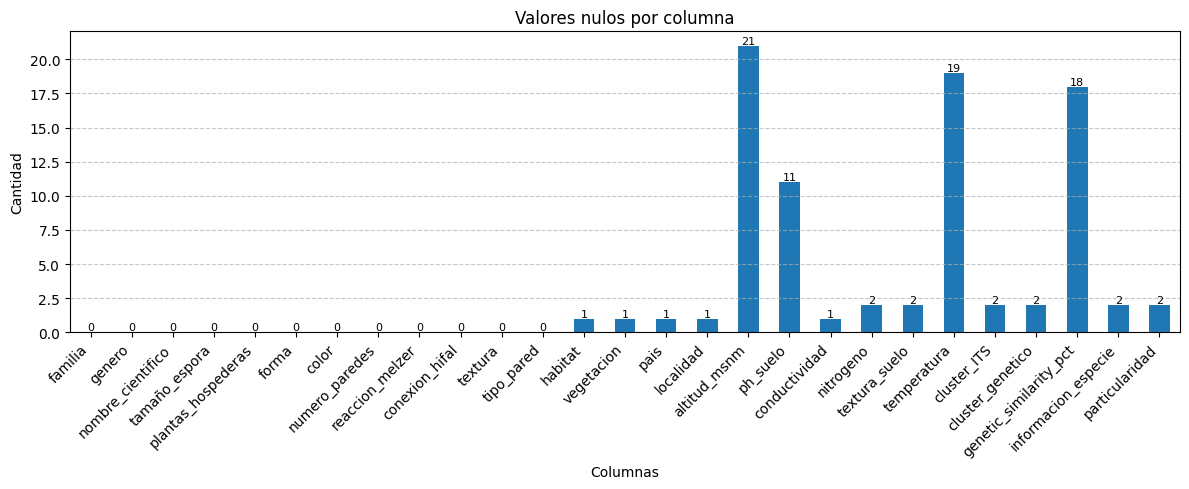

In [17]:
plt.figure(figsize=(12,5))

conteo_nulos = df.isnull().sum()
ax = conteo_nulos.plot(kind="bar")

plt.title("Valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad")

for barra in ax.patches:
    ax.annotate(
        str(int(barra.get_height())),
        (barra.get_x() + barra.get_width()/2, barra.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
def normalizar_texto(texto):

    if pd.isna(texto):
        return ""

    texto = str(texto).strip()

    texto = texto.replace("–", "-")
    texto = texto.replace("—", "-")

    texto = texto.replace("°c", "°C")

    texto = re.sub(
        r"[^a-zA-ZáéíóúÁÉÍÓÚüÜñÑ0-9\s,;().°µμ/_-]",
        " ",
        texto
    )

    texto = re.sub(r"\s+", " ", texto).strip()

    texto = re.sub(
        r"(\d+(?:\.\d+)?)\s+(\d+(?:\.\d+)?)\s*(µm|μm|um)",
        r"\1-\2 \3",
        texto
    )

    return texto

In [19]:
columnas_texto = [
    "familia", "genero", "nombre_cientifico", "tamaño_espora",
    "plantas_hospederas", "forma", "color", "reaccion_melzer",
    "conexion_hifal", "textura", "tipo_pared", "habitat",
    "vegetacion", "pais", "localidad", "altitud_msnm",
    "ph_suelo", "conductividad", "nitrogeno", "textura_suelo",
    "temperatura", "cluster_ITS", "cluster_genetico",
    "genetic_similarity_pct", "informacion_especie", "particularidad"
]

for col in columnas_texto:

    if col in df.columns:

        df[col] = (
            df[col]
            .apply(normalizar_texto)
        )

In [20]:
print("Filas antes de eliminar duplicados:", len(df))

df = df.drop_duplicates()

df = df.drop_duplicates(subset=[
    "familia",
    "genero",
    "nombre_cientifico",
    "tamaño_espora",
    "plantas_hospederas",
    "forma",
    "color",
    "numero_paredes",
    "reaccion_melzer",
    "conexion_hifal",
    "textura"
])

print("Filas después de eliminar duplicados:", len(df))

Filas antes de eliminar duplicados: 1981
Filas después de eliminar duplicados: 1377


In [21]:
df = df.dropna(subset=["familia", "genero", "nombre_cientifico"])

for col in columnas_texto:
    if col in df.columns:
        df[col] = df[col].replace("", np.nan)
        df[col] = df[col].fillna("no reportada")

df["numero_paredes"] = pd.to_numeric(df["numero_paredes"], errors="coerce")
df["numero_paredes"] = df["numero_paredes"].fillna(df["numero_paredes"].median())

print("Valores nulos después de limpieza:")
print(df.isnull().sum())

print("Duplicados finales:", df.duplicated().sum())

Valores nulos después de limpieza:
familia                   0
genero                    0
nombre_cientifico         0
tamaño_espora             0
plantas_hospederas        0
forma                     0
color                     0
numero_paredes            0
reaccion_melzer           0
conexion_hifal            0
textura                   0
tipo_pared                0
habitat                   0
vegetacion                0
pais                      0
localidad                 0
altitud_msnm              0
ph_suelo                  0
conductividad             0
nitrogeno                 0
textura_suelo             0
temperatura               0
cluster_ITS               0
cluster_genetico          0
genetic_similarity_pct    0
informacion_especie       0
particularidad            0
dtype: int64
Duplicados finales: 0


In [22]:
def procesar_rango(texto):

    if pd.isna(texto):
        return np.nan, np.nan

    texto = normalizar_texto(texto).lower()

    texto = texto.replace("µm", "")
    texto = texto.replace("μm", "")
    texto = texto.replace("um", "")

    texto = texto.replace("msnm", "")
    texto = texto.replace("m.s.n.m", "")

    texto = texto.replace("°c", "")
    texto = texto.replace(" c", "")

    texto = texto.replace(" a ", "-")
    texto = texto.replace("hasta", "-")

    texto = texto.replace(",", ".")

    texto = re.sub(
        r"^(\d+(?:\.\d+)?)\s+(\d+(?:\.\d+)?)$",
        r"\1-\2",
        texto
    )

    if re.fullmatch(r"\d{4}", texto):
        texto = texto[:2] + "-" + texto[2:]

    elif re.fullmatch(r"\d{5}", texto):
        texto = texto[:2] + "-" + texto[2:]

    elif re.fullmatch(r"\d{6}", texto):
        texto = texto[:3] + "-" + texto[3:]

    numeros = re.findall(r"\d+\.?\d*", texto)

    if len(numeros) >= 2:
        return float(numeros[0]), float(numeros[1])

    elif len(numeros) == 1:
        valor = float(numeros[0])
        return valor, valor

    return np.nan, np.nan

In [23]:
# Tamaño de espora
df[["tam_min", "tam_max"]] = df["tamaño_espora"].apply(
    lambda x: pd.Series(procesar_rango(x))
)

df["tam_promedio"] = (df["tam_min"] + df["tam_max"]) / 2

df[["tamaño_espora", "tam_min", "tam_max", "tam_promedio"]].head(10)

,tamaño_espora,tam_min,tam_max,tam_promedio
0,60.0-95.0 µm,60.0,95.0,77.50
1,60.0-96.0 µm,60.0,96.0,78.00
4,63.4-84.3 µm,63.4,84.3,73.85
5,68.1-91.9 µm,68.1,91.9,80.00
6,60.4-94.4 µm,60.4,94.4,77.40
7,53.0-110.0 µm,53.0,110.0,81.50
8,53.0-110.0 µm,53.0,110.0,81.50
9,53.6-76.1 µm,53.6,76.1,64.85
10,71.9-97.8 µm,71.9,97.8,84.85
11,60.6-105.6 µm,60.6,105.6,83.10


In [24]:
# pH del suelo
df[["ph_min", "ph_max"]] = df["ph_suelo"].apply(
    lambda x: pd.Series(procesar_rango(x))
)

df["ph_promedio"] = (df["ph_min"] + df["ph_max"]) / 2

df[["ph_suelo", "ph_min", "ph_max", "ph_promedio"]].head(10)

,ph_suelo,ph_min,ph_max,ph_promedio
0,5.8-6.4,5.8,6.4,6.1
1,6.4,6.4,6.4,6.4
4,6.2,6.2,6.2,6.2
5,6.0,6.0,6.0,6.0
6,6.0,6.0,6.0,6.0
7,3.5-5.5,3.5,5.5,4.5
8,4.3-5.1,4.3,5.1,4.7
9,4.7,4.7,4.7,4.7
10,4.4,4.4,4.4,4.4
11,4.4,4.4,4.4,4.4


In [25]:
# Altitud
df[["alt_min", "alt_max"]] = df["altitud_msnm"].apply(
    lambda x: pd.Series(procesar_rango(x))
)

df["alt_promedio"] = (df["alt_min"] + df["alt_max"]) / 2

df[["altitud_msnm", "alt_min", "alt_max", "alt_promedio"]].head(10)

,altitud_msnm,alt_min,alt_max,alt_promedio
0,3211-3940,3211.0,3940.0,3575.5
1,3771.9,3771.9,3771.9,3771.9
4,3258.0,3258.0,3258.0,3258.0
5,3764.6,3764.6,3764.6,3764.6
6,3254.7,3254.7,3254.7,3254.7
7,"1,600-2,800",1.6,2.8,2.2
8,1693-3458,1693.0,3458.0,2575.5
9,2520.5,2520.5,2520.5,2520.5
10,3300.5,3300.5,3300.5,3300.5
11,2460.8,2460.8,2460.8,2460.8


In [26]:
# Temperatura
df[["temp_min", "temp_max"]] = df["temperatura"].apply(
    lambda x: pd.Series(procesar_rango(x))
)

df["temp_promedio"] = (df["temp_min"] + df["temp_max"]) / 2

df[["temperatura", "temp_min", "temp_max", "temp_promedio"]].head(10)

,temperatura,temp_min,temp_max,temp_promedio
0,21-29 °C,21.0,29.0,25.0
1,22.5 °C,22.5,22.5,22.5
4,21.1 °C,21.1,21.1,21.1
5,29.0 °C,29.0,29.0,29.0
6,24.2 °C,24.2,24.2,24.2
7,85-12 °C,85.0,12.0,48.5
8,28-33 °C,28.0,33.0,30.5
9,32.3 °C,32.3,32.3,32.3
10,32.4 °C,32.4,32.4,32.4
11,28.3 °C,28.3,28.3,28.3


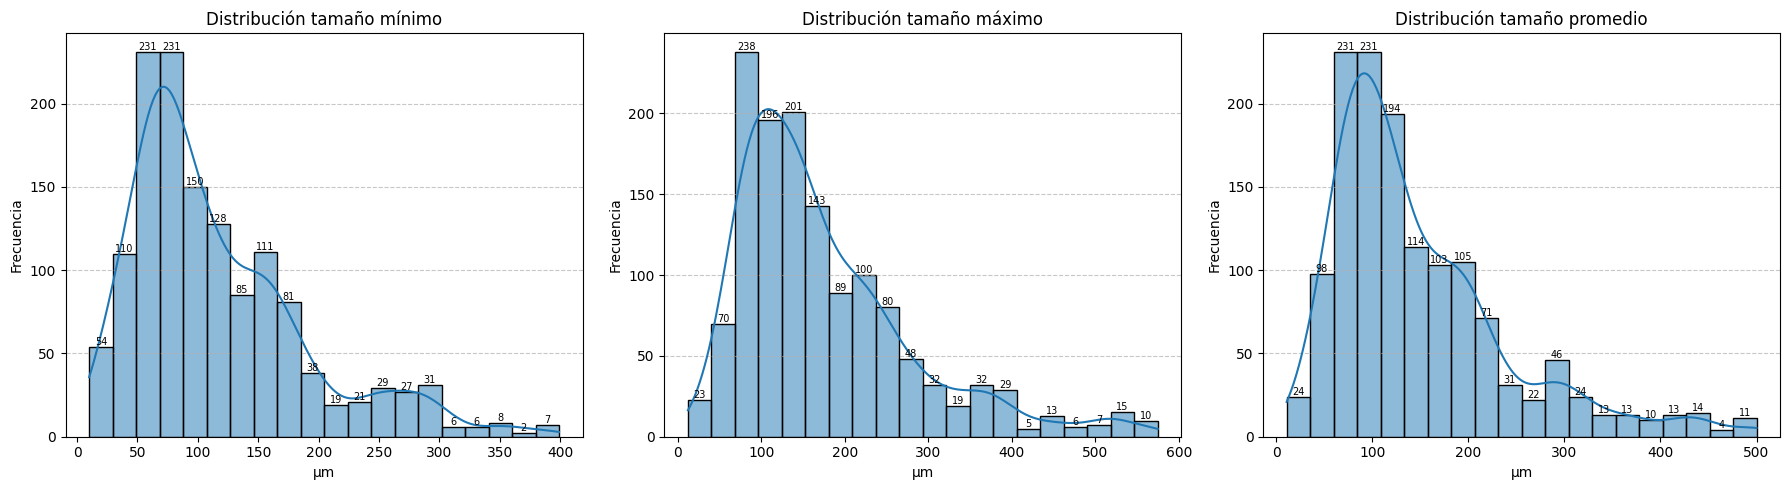

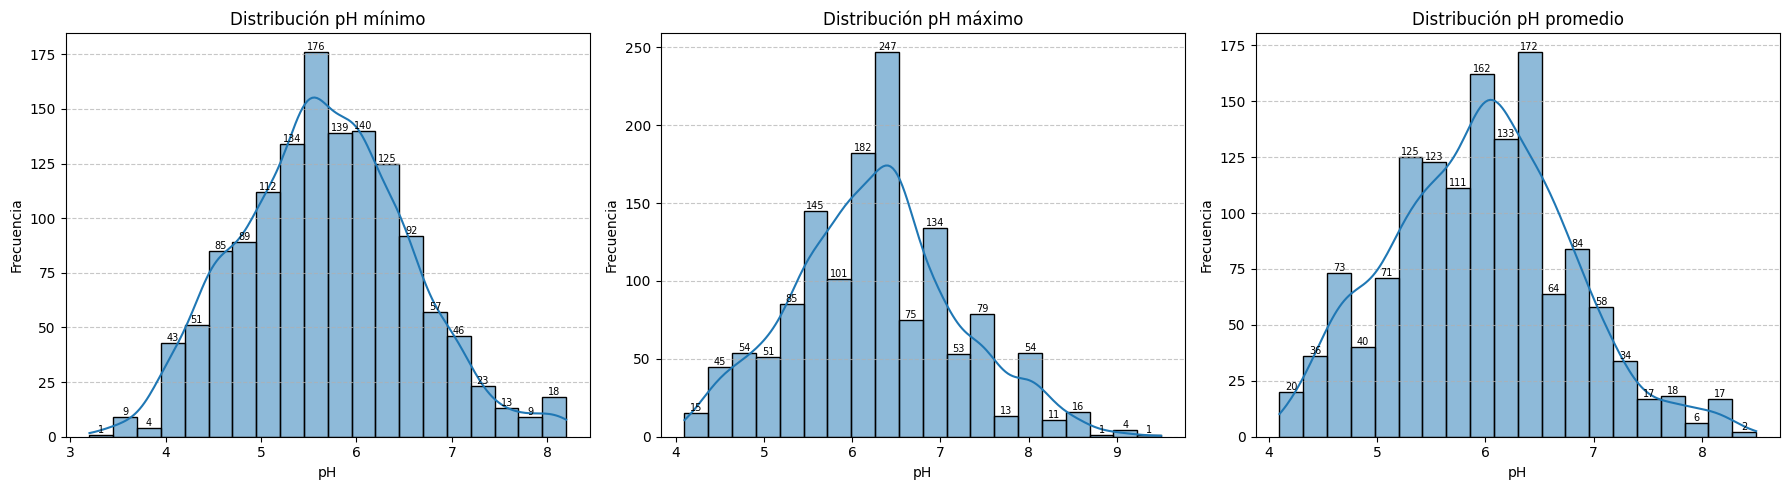

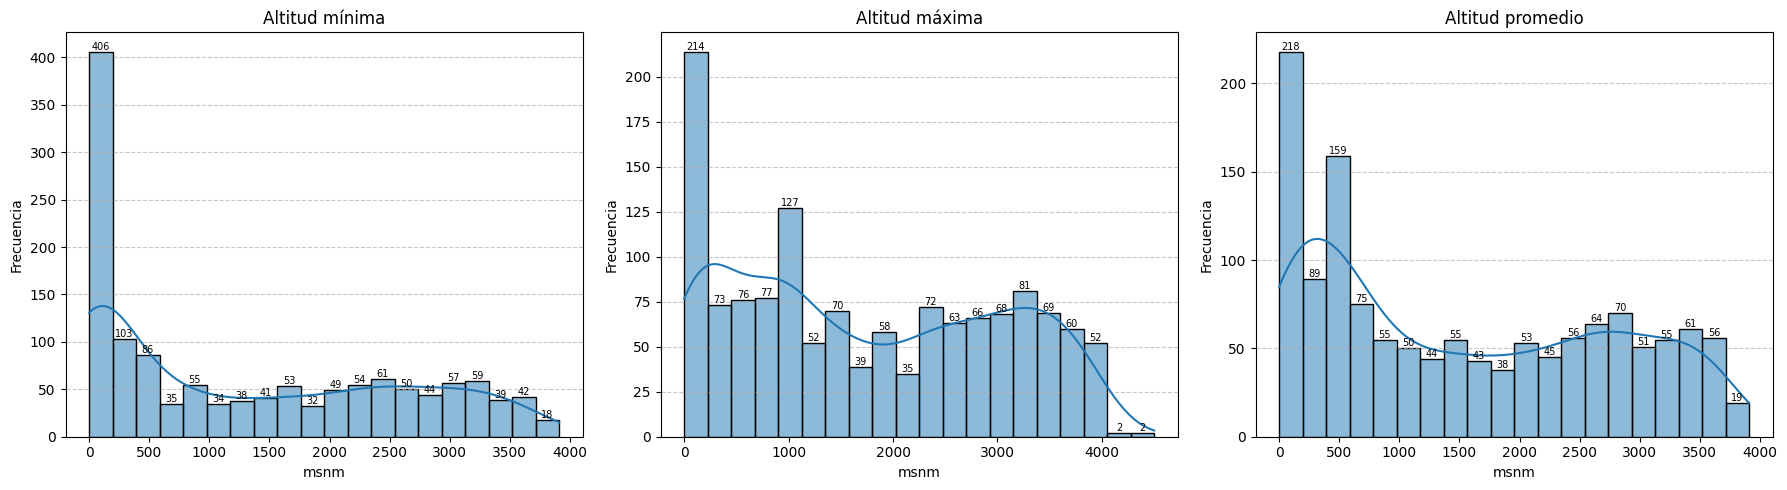

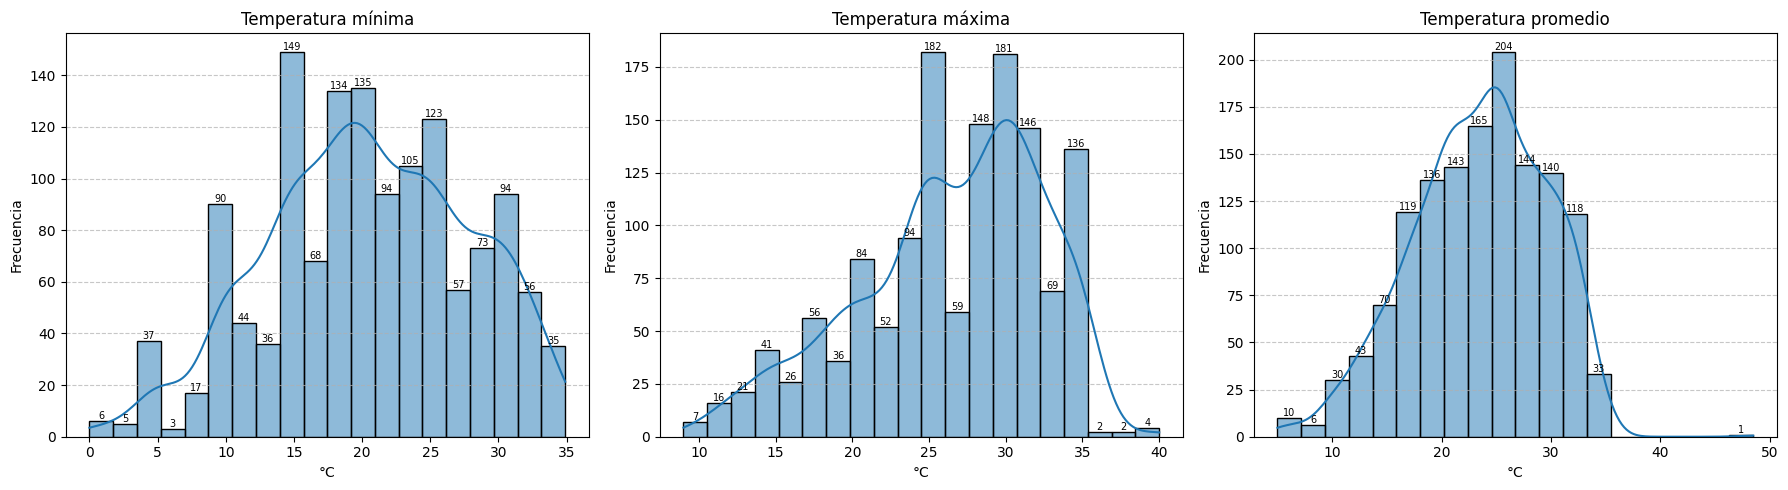

In [27]:
def histogramas_grupo(columnas, titulos, xlabel, limites=None):

    fig, axes = plt.subplots(1, len(columnas), figsize=(18,5))

    for i, (ax, col, titulo) in enumerate(zip(axes, columnas, titulos)):

        data = df[col].dropna()

        if limites and limites[i]:
            data = data[data <= limites[i]]

        sns.histplot(
            data,
            bins=20,
            kde=True,
            ax=ax
        )

        ax.set_title(titulo)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecuencia")

        for barra in ax.patches:

            altura = barra.get_height()

            if altura > 0:

                ax.annotate(
                    str(int(altura)),
                    (barra.get_x()+barra.get_width()/2, altura),
                    ha="center",
                    va="bottom",
                    fontsize=7
                )

        ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()


# ===================================
# TAMAÑO
# ===================================

histogramas_grupo(
    ["tam_min","tam_max","tam_promedio"],
    [
        "Distribución tamaño mínimo",
        "Distribución tamaño máximo",
        "Distribución tamaño promedio"
    ],
    "µm",
    [400,600,500]
)


# ===================================
# pH
# ===================================

histogramas_grupo(
    ["ph_min","ph_max","ph_promedio"],
    [
        "Distribución pH mínimo",
        "Distribución pH máximo",
        "Distribución pH promedio"
    ],
    "pH"
)


# ===================================
# ALTITUD
# ===================================

histogramas_grupo(
    ["alt_min","alt_max","alt_promedio"],
    [
        "Altitud mínima",
        "Altitud máxima",
        "Altitud promedio"
    ],
    "msnm",
    [5000,5000,5000]
)


# ===================================
# TEMPERATURA
# ===================================

histogramas_grupo(
    ["temp_min","temp_max","temp_promedio"],
    [
        "Temperatura mínima",
        "Temperatura máxima",
        "Temperatura promedio"
    ],
    "°C",
    [50,50,50]
)

In [28]:
df[[
    "tamaño_espora", "tam_min", "tam_max", "tam_promedio",
    "ph_suelo", "ph_min", "ph_max", "ph_promedio",
    "altitud_msnm", "alt_min", "alt_max", "alt_promedio",
    "temperatura", "temp_min", "temp_max", "temp_promedio"
]].head(10)

,tamaño_espora,tam_min,tam_max,tam_promedio,ph_suelo,ph_min,ph_max,ph_promedio,altitud_msnm,alt_min,alt_max,alt_promedio,temperatura,temp_min,temp_max,temp_promedio
0,60.0-95.0 µm,60.0,95.0,77.50,5.8-6.4,5.8,6.4,6.1,3211-3940,3211.0,3940.0,3575.5,21-29 °C,21.0,29.0,25.0
1,60.0-96.0 µm,60.0,96.0,78.00,6.4,6.4,6.4,6.4,3771.9,3771.9,3771.9,3771.9,22.5 °C,22.5,22.5,22.5
4,63.4-84.3 µm,63.4,84.3,73.85,6.2,6.2,6.2,6.2,3258.0,3258.0,3258.0,3258.0,21.1 °C,21.1,21.1,21.1
5,68.1-91.9 µm,68.1,91.9,80.00,6.0,6.0,6.0,6.0,3764.6,3764.6,3764.6,3764.6,29.0 °C,29.0,29.0,29.0
6,60.4-94.4 µm,60.4,94.4,77.40,6.0,6.0,6.0,6.0,3254.7,3254.7,3254.7,3254.7,24.2 °C,24.2,24.2,24.2
7,53.0-110.0 µm,53.0,110.0,81.50,3.5-5.5,3.5,5.5,4.5,"1,600-2,800",1.6,2.8,2.2,85-12 °C,85.0,12.0,48.5
8,53.0-110.0 µm,53.0,110.0,81.50,4.3-5.1,4.3,5.1,4.7,1693-3458,1693.0,3458.0,2575.5,28-33 °C,28.0,33.0,30.5
9,53.6-76.1 µm,53.6,76.1,64.85,4.7,4.7,4.7,4.7,2520.5,2520.5,2520.5,2520.5,32.3 °C,32.3,32.3,32.3
10,71.9-97.8 µm,71.9,97.8,84.85,4.4,4.4,4.4,4.4,3300.5,3300.5,3300.5,3300.5,32.4 °C,32.4,32.4,32.4
11,60.6-105.6 µm,60.6,105.6,83.10,4.4,4.4,4.4,4.4,2460.8,2460.8,2460.8,2460.8,28.3 °C,28.3,28.3,28.3


In [29]:
diccionario_forma = {

    # GLOBOSA
    "Globosa": "Globosa",
    "Globosas": "Globosa",
    "Globoide": "Globosa",
    "Globoides": "Globosa",
    "Globoidal": "Globosa",
    "Esférica": "Globosa",
    "Esféricas": "Globosa",
    "Redonda": "Globosa",
    "Redondas": "Globosa",
    "Círculo": "Globosa",
    "Círculos": "Globosa",
    "Circular": "Globosa",
    "Circulares": "Globosa",
    "Globosa con Escudo hialino": "Globosa",
    "Globosa con endiduras": "Globosa",
    "Globosas pequeñas lisas": "Globosa",

    # SUBGLOBOSA
    "Subglobosa": "Subglobosa",
    "Subglobosas": "Subglobosa",
    "Sub Globosa": "Subglobosa",
    "Sub-Globosa": "Subglobosa",
    "Sub-Globosas": "Subglobosa",
    "Subgloboidal": "Subglobosa",
    "Subgloboide": "Subglobosa",
    "Subgloboides": "Subglobosa",
    "Subgloboidas": "Subglobosa",
    "Subgloboidal": "Subglobosa",
    "Subgloboidas": "Subglobosa",
    "Subglobóidal": "Subglobosa",
    "Subglobóidas": "Subglobosa",
    "Subglobóide": "Subglobosa",
    "Subglobóides": "Subglobosa",
    "Subglobosa a globosa": "Subglobosa",
    "Subglobosa a oblongo": "Subglobosa",
    "Subglobosa a elíptica": "Subglobosa",
    "Subglobosa a irregular": "Subglobosa",
    "Subglobosa regular": "Subglobosa",

    # OVOIDE
    "Ovoide": "Ovoide",
    "Ovoides": "Ovoide",
    "Ovoidea": "Ovoide",
    "Ovoideas": "Ovoide",
    "Ovoideo": "Ovoide",
    "Ovoideos": "Ovoide",
    "Ovada": "Ovoide",
    "Ovadas": "Ovoide",
    "Oval": "Ovoide",
    "Ovales": "Ovoide",
    "Obovada": "Ovoide",
    "Obovoide": "Ovoide",
    "Ovalada": "Ovoide",
    "Ovaladas": "Ovoide",
    "Obalada": "Ovoide",
    "Obaladas": "Ovoide",
    "Ligeramente ovoide": "Ovoide",
    "Ovoide a irregular": "Ovoide",
    "Ovoide a elipsoidal": "Ovoide",
    "Ovoide a elipsoide": "Ovoide",

    # ELIPSOIDE
    "Elipsoide": "Elipsoide",
    "Elipsoides": "Elipsoide",
    "Elipsoidal": "Elipsoide",
    "Elipsoidales": "Elipsoide",
    "Elíptica": "Elipsoide",
    "Elípticas": "Elipsoide",
    "Eliptica": "Elipsoide",
    "Elipticas": "Elipsoide",
    "Elipsóide": "Elipsoide",
    "Elipsóides": "Elipsoide",
    "Elipsóidal": "Elipsoide",
    "Elipsóidas": "Elipsoide",
    "Amplia": "Elipsoide",
    "Amplias": "Elipsoide",
    "Amplias elípticas": "Elipsoide",
    "Elipsoide a oblonga": "Elipsoide",
    "Elipsoide a oblongas": "Elipsoide",
    "Elipsoides a oblongas": "Elipsoide",

    # PIRIFORME
    "Piriforme": "Piriforme",
    "Piriformes": "Piriforme",
    "Periforme": "Piriforme",
    "Periformes": "Piriforme",
    "Subpiriforme": "Piriforme",
    "Subpiriformes": "Piriforme",
    "Subpirformes": "Piriforme",
    "Subperiforme": "Piriforme",
    "Subperiformes": "Piriforme",
    "Subpiríforme": "Piriforme",
    "Subpiríformes": "Piriforme",
    "Subperíforme": "Piriforme",
    "Subperíformes": "Piriforme",
    "Piríforme": "Piriforme",
    "Piríformes": "Piriforme",
    "Ligeramente piriforme": "Piriforme",
    "Globosas a piriformes": "Piriforme",
    "Globosa o piriforme": "Piriforme",
    "Obovada piriforme": "Piriforme",

    # CILINDROIDE
    "Cilindroide": "Cilindroide",
    "Cilindroides": "Cilindroide",
    "Cilindroidal": "Cilindroide",
    "Cilindroidas": "Cilindroide",

    # CLAVADA
    "Clavada": "Clavada",
    "Clavadas": "Clavada",
    "Claviforme": "Clavada",
    "Claviformes": "Clavada",
    "Subclavada": "Clavada",
    "Subclavadas": "Clavada",
    "Subclaviforme": "Clavada",
    "Subclaviformes": "Clavada",
    "Globosa o claviforme": "Clavada",
    "Clavadas ovoideas o elípticas": "Clavada",
    "Clavada a cilíndrica": "Clavada",
    "Cilindro-clavada": "Clavada",
    "Cilindro-clavadas": "Clavada",
    "Cilindro-Clavada": "Clavada",
    "Cilindro-Clavadas": "Clavada",

    # CILÍNDRICA
    "Cilíndrica": "Cilíndrica",
    "Cilíndricas": "Cilíndrica",
    "Cilíndrico": "Cilíndrica",
    "Cilindrica": "Cilíndrica",
    "Cilindricas": "Cilíndrica",
    "Subcilíndrica": "Cilíndrica",
    "Subcilindrica": "Cilíndrica",
    "Cilindro-Clavadas": "Cilíndrica",
    "Cilindro-Claviforme": "Cilíndrica",
    "Cilindro-Claviformes": "Cilíndrica",
    "Cilindro-Clavada": "Cilíndrica",

    # OBLONGA
    "Oblonga": "Oblonga",
    "Oblongas": "Oblonga",
    "Oblongo": "Oblonga",
    "Oblongos": "Oblonga",
    "Oblongada": "Oblonga",
    "Oblongadas": "Oblonga",
    "Oblongóide": "Oblonga",
    "Oblongóides": "Oblonga",
    "Oblongóidal": "Oblonga",
    "Oblongóidas": "Oblonga",
    "Subglobosa a oblongo": "Oblonga",
    "Oblongas elipsoides subpiriformes": "Oblonga",
    "Elipsoides a oblongas ovoides": "Oblonga",

    # OVAL
    "Oval": "Oval",
    "Ovales": "Oval",
    "Obovada": "Oval",
    "Obovoide": "Oval",
    "Ovalada": "Oval",
    "Ovaladas": "Oval",
    "Obalada": "Oval",
    "Obaladas": "Oval",

    # RENIFORME
    "Reniforme": "Reniforme",
    "Reniformes": "Reniforme",
    "Subreniforme": "Reniforme",
    "Subreniformes": "Reniforme",
    "Subreníforme": "Reniforme",
    "Subreníformes": "Reniforme",
    "Reníforme": "Reniforme",
    "Reníformes": "Reniforme",

    # FUSIFORME
    "Fusiforme": "Fusiforme",
    "Fusiformes": "Fusiforme",
    "Subfusiforme": "Fusiforme",
    "Subfusiformes": "Fusiforme",
    "Fusiforme amplia": "Fusiforme",

    # TRIANGULAR
    "Triangular": "Triangular",
    "Triangulares": "Triangular",
    "Triángulo": "Triangular",
    "Triángulos": "Triangular",

    # RECTANGULAR
    "Rectangular": "Rectangular",
    "Rectangulares": "Rectangular",

    # RECTA / CURVADA
    "Recta": "Recta",
    "Curvada": "Curvada",
    "Curva": "Curvada",
    "Curvas": "Curvada",
    "Recurvada": "Recurvada",
    "Recurvas": "Recurvada",
    "Recurve": "Recurvada",
    "Recurves": "Recurvada",

    # IRREGULAR
    "Irregular": "Irregular",
    "Irregulares": "Irregular",
    "Polimórfica": "Irregular",
    "Polimórficas": "Irregular",
    "Polimorficas": "Irregular",
    "Dimórfica": "Irregular",
    "Dimórficas": "Irregular",
    "Dimorficas": "Irregular",
    "Irregular a globosa": "Irregular",
    "Globosas e Irregulares": "Irregular",
    "Globosas e irregulares": "Irregular",
    "Globosas algunas irregulares": "Irregular",

    # OTRAS
    "Múltiples": "Múltiples",
    "Cerebriforme": "Cerebriforme",
    "Cerebriformes": "Cerebriforme",
    "Subcerebriforme": "Cerebriforme",
    "Subcerebriformes": "Cerebriforme",
    "Glomoide": "Glomoide",
    "Glomoides": "Glomoide",
    "Hipógea": "Hipógea",
    "Hipógeas": "Hipógea",
    "Tuberculada": "Tuberculada",
    "Tuberculadas": "Tuberculada",
    "Alargada": "Alargada",
    "Alargadas": "Alargada",
    "Sésil": "Sésil",
    "Sésiles": "Sésil",
    "Sesil": "Sésil",
    "Sesiles": "Sésil",
    "Fig-like": "Fig-like",
    "Escudo hialino": "Escudo hialino",
    "Endiduras": "Endiduras",
    "Hendiduras": "Endiduras"
}

In [30]:
def normalizar_forma(texto):

    if pd.isna(texto):
        return "No reportada"

    texto_original = str(texto).strip()

    if texto_original.lower() in [
        "no reportada",
        "no reportado",
        "n/a",
        ""
    ]:
        return "No reportada"

    texto = normalizar_texto(texto_original).lower()

    for palabra, normalizada in diccionario_forma.items():

        palabra_limpia = normalizar_texto(
            palabra
        ).lower()

        if re.search(
            r'\b' + re.escape(palabra_limpia) + r'\b',
            texto
        ):
            return normalizada

    return "Otro"

In [31]:
df["forma_std"] = df["forma"].apply(normalizar_forma)

df["forma_std"].value_counts()

,count
forma_std,
Globosa,1116
Subglobosa,180
Ovoide,26
Clavada,17
Irregular,13
Elipsoide,12
Cerebriforme,4
Oval,4
Cilíndrica,4


In [32]:
def tokenizar_forma(texto):

    if pd.isna(texto):
        return ["No reportada"]

    texto_original = str(texto).strip()

    if texto_original.lower() in [
        "no reportada",
        "no reportado",
        "n/a",
        "na",
        ""
    ]:
        return ["No reportada"]

    texto = normalizar_texto(texto_original).lower()

    formas_detectadas = []

    for palabra, normalizada in diccionario_forma.items():

        palabra_limpia = normalizar_texto(
            palabra
        ).lower()

        if re.search(
            r'\b' + re.escape(palabra_limpia) + r'\b',
            texto
        ):
            formas_detectadas.append(normalizada)

    if len(formas_detectadas) == 0:
        return ["Otro"]

    return list(dict.fromkeys(formas_detectadas))

In [33]:
df["forma_token"] = df["forma"].apply(
    tokenizar_forma
)

mlb_forma = MultiLabelBinarizer()

forma_encoded = mlb_forma.fit_transform(
    df["forma_token"]
)

df_forma = pd.DataFrame(
    forma_encoded,

    columns=[
        "forma_" +
        normalizar_texto(c)
        .replace("á","a")
        .replace("é","e")
        .replace("í","i")
        .replace("ó","o")
        .replace("ú","u")
        .replace("ñ","n")
        .replace(" ","_")

        for c in mlb_forma.classes_
    ],

    index=df.index
)

df = pd.concat(
    [df, df_forma],
    axis=1
)

df = df.loc[
    :,
    ~df.columns.duplicated()
]


display(
    df[
        ["forma", "forma_std", "forma_token"]
    ].head()
)

,forma,forma_std,forma_token
0,"Globosa a subglobosa, ovoides",Globosa,"[Globosa, Subglobosa, Ovoide]"
1,"Globosa a subglobosa, ovoides",Globosa,"[Globosa, Subglobosa, Ovoide]"
4,"Globosa a subglobosa, ovoides",Globosa,"[Globosa, Subglobosa, Ovoide]"
5,"Globosa a subglobosa, ovoides",Globosa,"[Globosa, Subglobosa, Ovoide]"
6,"Globosa a subglobosa, ovoides",Globosa,"[Globosa, Subglobosa, Ovoide]"


In [34]:
[
    col
    for col in df.columns
    if col.startswith("forma_")
]

['forma_std',
 'forma_token',
 'forma_Alargada',
 'forma_Cerebriforme',
 'forma_Cilindrica',
 'forma_Clavada',
 'forma_Elipsoide',
 'forma_Endiduras',
 'forma_Escudo_hialino',
 'forma_Fig-like',
 'forma_Fusiforme',
 'forma_Globosa',
 'forma_Glomoide',
 'forma_Irregular',
 'forma_Oblonga',
 'forma_Oval',
 'forma_Ovoide',
 'forma_Piriforme',
 'forma_Rectangular',
 'forma_Reniforme',
 'forma_Subglobosa',
 'forma_Sesil',
 'forma_Triangular',
 'forma_Tuberculada']

In [35]:
colores_base = [

    # ==========================
    # CLAROS
    # ==========================

    "Hialino",
    "Subhialino",
    "Transparente",
    "Blanco",
    "Blanquecino",
    "Crema",
    "Beige",
    "Marfil",
    "Lechoso",
    "Translúcido",
    "Translúcida",
    "Escarchado",


    # ==========================
    # AMARILLOS
    # ==========================

    "Amarillo",
    "Amarillento",
    "Amarillo Claro",
    "Amarillo Oscuro",
    "Amarillo Pálido",
    "Amarillo Pastel",
    "Amarillo Verdoso",
    "Amarillo Marrón",
    "Amarillo Dorado",
    "Amarillo Limón",
    "Amarillo Maíz",
    "Amarillo Girasol",
    "Amarillo Mantequilla",
    "Amarillo Albaricoque",
    "Amarillo Parduzco",
    "Amarillo Rojizo",
    "Amarillo-Marrón",

    # ==========================
    # DORADO
    # ==========================

    "Dorado",
    "Dorado Oscuro",
    "Dorado Metálico",
    "Oro",
    "Oro Claro",
    "Oro Oscuro",
    "Oro Marrón",
    "Oro Dorado",
    "Oro Amarillento",
    "Oro Rojizo",
    "Oro-Marrón",
    "Oro Metálico",
    "Metálico",


    # ==========================
    # OCRE
    # ==========================
    "Ocre",
    "Ocráceo",
    "Ocrácea",
    "Luteo",
    "Luteo Claro",
    "Luteo Oscuro",
    "Luteous",
    "Luteous Claro",
    "Luteous Oscuro",

    # ==========================
    # ÁMBAR
    # ==========================
    "Ámbar",
    "Ámbar Claro",
    "Ámbar Oscuro",
    "Ámbar Marrón",
    "Ámbar-Marrón",

    # ==========================
    # MIEL
    # ==========================
    "Miel",
    "Miel Claro",
    "Miel Oscuro",
    "Miel Amarillento",
    "Miel Rojizo",
    "Miel Marrón",
    "Miel-Marrón",


    # ==========================
    # NARANJAS
    # ==========================

    "Naranja",
    "Anaranjado",
    "Anaranjada",
    "Anaranjadas",
    "Naranja Claro",
    "Naranja Amarillento",
    "Naranja Oscuro",
    "Naranja Pálido",
    "Naranja Rojizo",
    "Naranja Marrón",
    "Naranja-Marrón",
    "Anaranjado-Marrón",


    # ==========================
    # ROJOS
    # ==========================

    "Rojo",
    "Rojizo",
    "Rojo Claro",
    "Rojo Oscuro",
    "Rojo Ladrillo",
    "Rojo Marrón",
    "Rojo-Marrón",
    "Rojo Anaranjado",
    "Salmón",
    "Óxido",

    # ==========================
    # ROSA
    # ==========================
    "Rosado",
    "Rosa",
    "Rosa Claro",
    "Rosa Oscuro",
    "Rosa Pálido",
    "Rosa Brillante",
    "Rosa Intenso",
    "Rosa Pastel",
    "Rosa Verdoso",

    # ==========================
    # CAFÉS
    # ==========================

    "Café",
    "Café Claro",
    "Café Oscuro",
    "Café Anaranjado",
    "Café Amarillento",
    "Café Rojizo",
    "Café Rojizo Oscuro",
    "Café Negruzco",
    "Pardo",
    "Cafezusco",
    "Sienna",
    "Café-Marrón",

    # ==========================
    # MARRONES
    # ==========================

    "Marrón Claro",
    "Marrón Oscuro",
    "Marrón Pálido",
    "Marrón Amarillento",
    "Marrón Rojizo",
    "Marrón Marrón",
    "Marrón",
    "Marrón-Marrón",
    "Marrón Anaranjado",

    "Castaño",
    "Castaño Rojizo",
    "Parduzco",

    # ==========================
    # GRISES
    # ==========================

    "Gris",
    "Gris Claro",
    "Gris Oscuro",
    "Gris Amarillento",
    "Gris Anaranjado",
    "Gris Rojizo",
    "Gris Marrón",
    "Gris-Marrón",
    "Grisáceo",
    "Grisácea",

    # ==========================
    # NEGROS
    # ==========================
    "Negro",
    "Negro Claro",
    "Negro Opaco"
    "Negro Oscuro",
    "Negro Amarillento",
    "Negro Anaranjado",
    "Negro Rojizo",
    "Negruzco",
    "Negro Brillante",
    "Negro Claro",
    "Negro Oscuro",
    "Negro Pálido",
    "Negro Brillante",
    "Negro Intenso",
    "Negro Pastel",
    "Negro Verdoso",
    "Negro Amarillento",
    "Negro Rojizo",
    "Negro Marrón",
    "Negro-Marrón",

    # ==========================
    # VERDES
    # ==========================

    "Verde",
    "Verdoso",
    "Verdosa",
    "Verde Claro",
    "Verde Oscuro",
    "Verde Amarillento",
    "Verde Turquesa",
    "Oliva",

    # ==========================
    # MODIFICADORES
    # ==========================

    "Pálido",
    "Brillante",
    "Opaco",
    "Intenso",
    "Natural",
    "Leve",
    "Variación",
    "Variaciones",
    "Madura",
    "Madurez",
    "Maduramente"
]

In [36]:
diccionario_color = {

    # HIALINO
    "Hialino": "Hialino",
    "Hialina": "Hialino",
    "Hialinas": "Hialino",
    "Subhialino": "Hialino",
    "Subhialina": "Hialino",
    "Subhialinas": "Hialino",
    "Sub-Hialina": "Hialino",
    "Transparente": "Hialino",
    "Transparentes": "Hialino",
    "Trasparente": "Hialino",
    "Trasparentes": "Hialino",
    "Incoloro": "Hialino",
    "Incolora": "Hialino",
    "Translúcido": "Hialino",
    "Translúcida": "Hialino",
    "Escarchado": "Hialino",
    "Hialinas Brillantes": "Hialino",
    "Hialina Brillante": "Hialino",
    "Hialiano": "Hialino",
    "Hialiano a Banco": "Hialino",
    "Hialina a Subhialina": "Hialino",
    "Hialinas a Subhialinas": "Hialino",
    "Hialinas a Amarillo Pálido": "Hialino",
    "Hialino a Amarillo Pálido": "Hialino",
    "Hialina a Amarillo Pálido": "Hialino",
    "Hialinas a Blanco Amarillento": "Hialino",
    "Hialina a Blanca": "Hialino",
    "Hialinas a Blancas": "Hialino",
    "Hialina a Amarilla": "Hialino",
    "Subhialinas a Amarillo Pálido": "Hialino",
    "Subhialina a Blanca": "Hialino",
    "Subhialinas a Pálido Amarillentas": "Hialino",
    "Incolora a Blanco Escarchado": "Hialino",
    "Blanco Translúcido": "Hialino",
    "Trasparentes y Levementes Amarillas": "Hialino",

    # BLANCO
    "Blanco": "Blanco",
    "Blanca": "Blanco",
    "Blancas": "Blanco",
    "Blanquecino": "Blanco",
    "Blanquecina": "Blanco",
    "Blanco Amarillento": "Blanco",
    "Blanco Crema": "Blanco",
    "Blanco Opaco": "Blanco",
    "Blanco Lácteo": "Blanco",
    "Marfil": "Blanco",
    "Lácteo": "Blanco",
    "Leche": "Blanco",
    "Blancas a Crema": "Blanco",
    "Blanco Brillante": "Blanco",
    "Blanco Pálido": "Blanco",
    "Blanco Lácteo": "Blanco",
    "Blanco Escarchado": "Blanco",
    "Blanco Translúcido": "Blanco",
    "Blanco Amarillentas": "Blanco",
    "Blanco Amarillento a Crema": "Blanco",
    "Blanco Amarillento a Amarillo Pálido": "Blanco",
    "Blanco Amarillento a Amarillo Dorado": "Blanco",
    "Blanco a Amarillo": "Blanco",
    "Blanco a Amarillo Pálido": "Blanco",
    "Blanco a Tono Amarillo Pálido": "Blanco",
    "Blanco a Café Amarillento": "Blanco",
    "Blanco a Marrón Amarillento": "Blanco",
    "Blanco Anaranjado": "Blanco",
    "Blanco Opaco a Amarillo Cremoso": "Blanco",

    # CREMA
    "Crema": "Crema",
    "Cremoso": "Crema",
    "Cremosa": "Crema",
    "Cremosas": "Crema",
    "Crema Claro": "Crema",
    "Crema Amarillento": "Crema",
    "Cremoso": "Crema",
    "Crema Claro": "Crema",
    "Crema Amarillento": "Crema",
    "Crema a Amarillo": "Crema",
    "Crema a Marrón": "Crema",
    "Crema a Marrón Claro": "Crema",
    "Crema a Marrón Anaranjado": "Crema",
    "Crema a Café-Anaranjado": "Crema",
    "Crema Rosado Pálido": "Crema",
    "Crema con Tintes Verde Pálido": "Crema",
    "Blanco Cremoso": "Crema",
    "Hialina a Cremosa": "Crema",

    # AMARILLO
    "Amarillo": "Amarillo",
    "Amarilla": "Amarillo",
    "Amarillas": "Amarillo",
    "Amarillento": "Amarillo",
    "Amarillenta": "Amarillo",
    "Amarillentas": "Amarillo",
    "Amarillo Claro": "Amarillo",
    "Amarillo Oscuro": "Amarillo",
    "Amarillo Pálido": "Amarillo",
    "Amarillo Brillante": "Amarillo",
    "Amarillo Intenso": "Amarillo",
    "Amarillo Pastel": "Amarillo",
    "Amarillo Limón": "Amarillo",
    "Amarillo Maíz": "Amarillo",
    "Amarillo Yema": "Amarillo",
    "Amarillo Girasol": "Amarillo",
    "Amarillo Mantequilla": "Amarillo",
    "Amarillo Albaricoque": "Amarillo",
    "Amarillo Parduzco": "Amarillo",
    "Amarillo Blanquecino": "Amarillo",
    "Amarillo Verdoso": "Amarillo",
    "Amarillo Rojizo": "Amarillo",
    "Amarillo Marrón": "Amarillo",
    "Amarillo-Marrón": "Amarillo",
    "Amarilo": "Amarillo",
    "Amarillo-Café": "Amarillo",
    "Amarillo-Café Claro": "Amarillo",
    "Amarillo-Café Oscuro": "Amarillo",
    "Amarillo-Café Amarillento": "Amarillo",
    "Amarillo-Café Rojizo": "Amarillo",
    "Amarillo-Café Negruzco": "Amarillo",
    "Amarillo-Castaño": "Amarillo",
    "Amarillo-Castaño Rojizo": "Amarillo",
    "Amarillo-Pardo": "Amarillo",
    "Amarillo-Cafezusco": "Amarillo",
    "Amarillo-Sienna": "Amarillo",
    "Amarillo-Café-Marrón": "Amarillo",
    "Amarillo-Negro": "Amarillo",
    "Amarillo-Negro Claro": "Amarillo",
    "Amarillo-Negro Opaco": "Amarillo",
    "Amarillo-Negro Oscuro": "Amarillo",
    "Amarillo-Negro Amarillento": "Amarillo",
    "Amarillo-Negro Anaranjado": "Amarillo",
    "Amarillo-Negro Rojizo": "Amarillo",
    "Amarillo-Negro Negruzco": "Amarillo",
    "Amarillo-Negro Brillante": "Amarillo",
    "Amarillo-Negro Pálido": "Amarillo",
    "Amarillo-Negro Brillante": "Amarillo",
    "Amarillo-Negro Intenso": "Amarillo",
    "Amarillo-Negro Pastel": "Amarillo",
    "Amarillo-Negro Verdoso": "Amarillo",
    "Amarillo a Marrón": "Amarillo",
    "Amarillo a Marrón Claro": "Amarillo",
    "Amarillo a Marrón Oscuro": "Amarillo",
    "Amarillo a Marrón Amarillento": "Amarillo",
    "Amarillo a Café": "Amarillo",
    "Amarillo a Café Amarillento": "Amarillo",
    "Amarillo a Café Oscuro": "Amarillo",
    "Amarillo a Café Anaranjado": "Amarillo",
    "Amarillo a Anaranjado": "Amarillo",
    "Amarillo Anaranjado": "Amarillo",
    "Amarillo Naranja": "Amarillo",
    "Amarillo-Naranja": "Amarillo",
    "Amarillo Huevo": "Amarillo",
    "Amarillo Yemoso": "Amarillo",
    "Amarillo Desvanecido": "Amarillo",
    "Amarillo Algodonoso": "Amarillo",
    "Amarillo Parduzco": "Amarillo",
    "Amarillo Ocre": "Amarillo",
    "Amarillo Oliva": "Amarillo",
    "Amarillo Pálido a Amarillo Oscuro": "Amarillo",
    "Amarillo Pálido a Amarillo Limón": "Amarillo",
    "Amarillo Pálido a Amarillo Maíz": "Amarillo",
    "Amarillo Pálido a Girasol": "Amarillo",
    "Amarillo Pálido a Dorado": "Amarillo",
    "Amarillo Pálido a Café Amarillento": "Amarillo",
    "Amarillo Pálido a Café Claro": "Amarillo",
    "Amarillo Pálido a Marrón": "Amarillo",
    "Amarillo Pálido a Marrón Claro": "Amarillo",
    "Amarillo Pálido a Marrón Amarillento": "Amarillo",
    "Amarillo Pálido a Anaranjado": "Amarillo",
    "Amarillo Pálido a Naranja Grisácea": "Amarillo",
    "Amarillo Pálido con Tinte Verdoso": "Amarillo",
    "Amarillo Claro a Amarillo Anaranjado": "Amarillo",
    "Amarillo Claro a Ocre": "Amarillo",
    "Amarillo Claro a Amarillo Ocre": "Amarillo",
    "Amarillo Claro a Marrón Claro": "Amarillo",
    "Amarillo Brillante a Naranja-Amarillo": "Amarillo",
    "Amarillo Girasol a Amarillo Albaricoque": "Amarillo",
    "Amarillo Girasol a Anaranjado": "Amarillo",
    "Amarillo Albaricoque a Café Amarillento": "Amarillo",
    "Amarillo Maíz a Marrón Anaranjado": "Amarillo",
    "Amarillas a Cafés": "Amarillo",
    "Amarillas a Café Amarillentas": "Amarillo",
    "Amarillas a Café Rojizas": "Amarillo",
    "Amarilo de Tono Pálido u Oliva": "Amarillo",
    "Amarilo de Tono Café Claro y Oscuro": "Amarillo",
    "Amarilo de Tono Oliva o Gris": "Amarillo",

    # DORADO
    "Dorado": "Dorado",
    "Dorada": "Dorado",
    "Amarillo Dorado": "Dorado",
    "Oro": "Dorado",
    "Oro Claro": "Dorado",
    "Oro Oscuro": "Dorado",
    "Oro Marrón": "Dorado",
    "Oro Amarillento": "Dorado",
    "Oro Rojizo": "Dorado",
    "Oro Metálico": "Dorado",
    "Metálico": "Dorado",
    "Amarillo a Amarillo Dorado": "Dorado",
    "Amarillo Pálido a Amarillo Dorado": "Dorado",
    "Anaranjado Claro a Amarillo Dorado": "Dorado",
    "Pálido Anaranjado a Amarillo Dorado": "Dorado",
    "Blanco Amarillento a Dorado": "Dorado",
    "Blanco Amarillento a Amarillo Dorado": "Dorado",
    "Amarillo Dorado a Castaño Rojizo": "Dorado",
    "Oro Metálico a Sienna": "Dorado",


    # OCRE
    "Ocre": "Ocre",
    "Ocráceo": "Ocre",
    "Ocrácea": "Ocre",
    "Ocres": "Ocre",
    "Luteo Claro": "Ocre",
    "Luteo Oscuro": "Ocre",
    "Luteo": "Ocre",
    "Luteous": "Ocre",
    "Luteous Claro": "Ocre",
    "Luteous Oscuro": "Ocre",
    "Hialina a Amarillo Ocre": "Ocre",
    "Hialina a Pálido Ocre": "Ocre",
    "Hialina a Pálido Ocráceo": "Ocre",
    "Pálido Ocráceo": "Ocre",
    "Pálido Ocráceas": "Ocre",
    "Ocre a Naranja-Marrón": "Ocre",
    "Ocre a Luteous": "Ocre",
    "Marfil a Ocre": "Ocre",
    "Anaranjado a Ocre Natural": "Ocre",

    # ÁMBAR
    "Ámbar": "Ámbar",
    "Ambar": "Ámbar",
    "Ámbar Claro": "Ámbar",
    "Ámbar Amarillento": "Ámbar",
    "Ámbar Oscuro": "Ámbar",
    "Ámbar Marrón": "Ámbar",
    "Ámbar Pálido": "Ámbar",
    "Ámbar-Marrón": "Ámbar",
    "Ámbar-Café": "Ámbar",
    "Ámbar-Café Claro": "Ámbar",
    "Ámbar-Café Oscuro": "Ámbar",
    "Ámbar-Café Amarillento": "Ámbar",
    "Ámbar-Café Rojizo": "Ámbar",
    "Ámbar-Café Negruzco": "Ámbar",
    "Ámbar-Castaño": "Ámbar",
    "Ámbar-Castaño Rojizo": "Ámbar",
    "Ámbar-Pardo": "Ámbar",
    "Ámbar-Cafezusco": "Ámbar",
    "Ámbar-Sienna": "Ámbar",
    "Ámbar-Café-Marrón": "Ámbar",

    # MIEL
    "Miel": "Miel",
    "Miel Claro": "Miel",
    "Miel Oscuro": "Miel",
    "Miel Amarillento": "Miel",
    "Miel Rojizo": "Miel",
    "Miel Marrón": "Miel",
    "Miel-Marrón": "Miel",
    "Miel-Café": "Miel",
    "Miel-Café Claro": "Miel",
    "Miel-Café Oscuro": "Miel",
    "Miel-Café Amarillento": "Miel",
    "Miel-Café Rojizo": "Miel",
    "Miel-Café Negruzco": "Miel",
    "Miel-Castaño": "Miel",
    "Miel-Castaño Rojizo": "Miel",
    "Miel-Pardo": "Miel",
    "Miel-Cafezusco": "Miel",
    "Miel-Sienna": "Miel",
    "Miel-Café-Marrón": "Miel",

    # NARANJA
    "Naranja": "Naranja",
    "Anaranjado": "Naranja",
    "Anaranjada": "Naranja",
    "Anaranjadas": "Naranja",
    "Naranja Claro": "Naranja",
    "Naranja Oscuro": "Naranja",
    "Naranja Pálido": "Naranja",
    "Naranja Rojizo": "Naranja",
    "Naranja Grisácea": "Naranja",
    "Naranja-Marrón": "Naranja",
    "Anaranjado-Marrón": "Naranja",
    "Salmón": "Naranja",
    "Óxido": "Naranja",
    "Naranja-Café": "Naranja",
    "Naranja-Café Claro": "Naranja",
    "Naranja-Café Oscuro": "Naranja",
    "Naranja-Café Amarillento": "Naranja",
    "Naranja-Café Rojizo": "Naranja",
    "Naranja-Café Negruzco": "Naranja",
    "Naranja-Castaño": "Naranja",
    "Naranja-Castaño Rojizo": "Naranja",
    "Naranja-Pardo": "Naranja",
    "Naranja-Cafezusco": "Naranja",
    "Naranja-Sienna": "Naranja",
    "Naranja-Café-Marrón": "Naranja",
    "Anaranjado Claro": "Naranja",
    "Anaranjado Oscuro": "Naranja",
    "Anaranjado Intenso": "Naranja",
    "Anaranjado Claro a Café": "Naranja",
    "Anaranjado Claro a Café Amarillento": "Naranja",
    "Anaranjado Claro a Anaranjado": "Naranja",
    "Anaranjado de Tono Amarillo Rojizo": "Naranja",
    "Amarillo a Naranja": "Naranja",
    "Amarillo Pastel a Anaranjado": "Naranja",
    "Amarillo Pastel a Naranja Oscuro": "Naranja",
    "Naranja Claro a Oscuro": "Naranja",
    "Naranja Pálido a Naranja": "Naranja",
    "Naranja a Marrón": "Naranja",
    "Naranja a Marrón Claro": "Naranja",
    "Naranja a Marrón Rojizo": "Naranja",
    "Naranja a Rojo Parduzco": "Naranja",
    "Naranja de Tono Rojo Amarillento": "Naranja",
    "Naranja Grisácea": "Naranja",
    "Naranja Grisáceas": "Naranja",
    "Naranja Parduzco": "Naranja",
    "Naranja Cafezusco": "Naranja",
    "Naranja Cafezusco a Café": "Naranja",
    "Naranja Cafezusco a Café Rojizo": "Naranja",
    "Café Naranja": "Naranja",
    "Café-Naranja": "Naranja",
    "Café Anaranjado": "Naranja",
    "Café Anaranjada": "Naranja",
    "Café Anaranjado Pálido": "Naranja",
    "Café Anaranjado Oscuro": "Naranja",
    "Café Anaranjado Pálido a Oscuro": "Naranja",
    "Marrón Anaranjado Pálido": "Naranja",
    "Marrón Anaranjado Oscuro": "Naranja",
    "Marrón Anaranjado Pálido a Marrón Anaranjado Oscuro": "Naranja",
    "Salmón a Marrón Anaranjado": "Naranja",
    "Salmón a Café Anaranjado Pálido": "Naranja",
    "Blanco a Amarillo Anaranjado": "Naranja",

    # ROJO
    "Rojo": "Rojo",
    "Rojizo": "Rojo",
    "Rojiza": "Rojo",
    "Rojo Anaranjado": "Rojo",
    "Rojo Marrón": "Rojo",
    "Rojo-Marrón": "Rojo",
    "Rojo Café": "Rojo",
    "Rojo-Café": "Rojo",
    "Rojo-Café Claro": "Rojo",
    "Rojo-Café Oscuro": "Rojo",
    "Rojo-Café Amarillento": "Rojo",
    "Rojo-Café Rojizo": "Rojo",
    "Rojo-Café Negruzco": "Rojo",
    "Rojo-Castaño": "Rojo",
    "Rojo-Castaño Rojizo": "Rojo",
    "Ladrillo": "Rojo",
    "Óxido": "Rojo",
    "Rosado": "Rojo",
    "Rosa": "Rojo",
    "Rosa Claro": "Rojo",
    "Rosa Oscuro": "Rojo",
    "Rosa Pálido": "Rojo",
    "Rosa Brillante": "Rojo",
    "Rosa Intenso": "Rojo",
    "Rosa Pastel": "Rojo",
    "Rojizas": "Rojo",
    "Rojizo Anaranjado": "Rojo",
    "Rojo-Anaranjado": "Rojo",
    "Rojo Pimienta": "Rojo",
    "Rojo Café Oscuro": "Rojo",
    "Rojo-Café Oscuro": "Rojo",
    "Rojo Ladrillo": "Rojo",
    "Rojo Amarillento": "Rojo",
    "Café Rojiza": "Rojo",
    "Café Rojizas": "Rojo",
    "Café-Rojizo": "Rojo",
    "Café-Rojizo de Tono Oscuro": "Rojo",
    "Café Rojizo de Tono Rojo Oscuro": "Rojo",
    "Café Rojizo de Tono Rojo Amarillento": "Rojo",
    "Café Rojizo Negro": "Rojo",
    "Café Rojizo Negro de Tono Café-Rojizo Oscuro": "Rojo",
    "Marrón Rojizo a Marrón Oscuro": "Rojo",
    "Marrón Rojizo Oscuro a Negro": "Rojo",
    "Naranja Rojizo": "Rojo",
    "Naranja Oscuro a Rojo-Marrón": "Rojo",
    "Amarillo a Amarillo Rojizo": "Rojo",
    "Amarillo Rojizo a Rojo Marrón": "Rojo",
    "Amarillo Rojizo a Tono Marrón Opaco": "Rojo",
    "Óxido": "Rojo",

    # MARRÓN
    "Marrón": "Marrón",
    "Marrones": "Marrón",
    "Marrón Claro": "Marrón",
    "Marrón Oscuro": "Marrón",
    "Marrón Amarillento": "Marrón",
    "Marrón Anaranjado": "Marrón",
    "Marrón Pálido": "Marrón",
    "Marrón Rojizo": "Marrón",
    "Marrón-Marrón": "Marrón",
    "Marrón Marrón": "Marrón",
    "Marrón-Café": "Marrón",
    "Marrón-Café Claro": "Marrón",
    "Marrón-Café Oscuro": "Marrón",
    "Marrón-Café Amarillento": "Marrón",
    "Marrón-Café Rojizo": "Marrón",
    "Marrón-Café Negruzco": "Marrón",
    "Marrón-Castaño": "Marrón",
    "Marrón-Castaño Rojizo": "Marrón",
    "Marrón-Pardo": "Marrón",
    "Marrón-Cafezusco": "Marrón",
    "Marrón-Sienna": "Marrón",
    "Marrón-Café-Marrón": "Marrón",
    "Marrón-Negro": "Marrón",
    "Marrón-Negro Claro": "Marrón",
    "Marrón-Negro Opaco": "Marrón",
    "Marrón-Negro Oscuro": "Marrón",
    "Marrón-Negro Amarillento": "Marrón",
    "Marrón-Negro Anaranjado": "Marrón",
    "Marrón-Negro Rojizo": "Marrón",
    "Marrón-Negro Negruzco": "Marrón",
    "Marrón-Negro Brillante": "Marrón",

    #CAFÉ
    "Café": "Marrón",
    "Cafés": "Marrón",
    "Café Claro": "Marrón",
    "Café Oscuro": "Marrón",
    "Café Amarillento": "Marrón",
    "Café Anaranjado": "Marrón",
    "Café Rojizo": "Marrón",
    "Café Rojizo Oscuro": "Marrón",
    "Café Negruzco": "Marrón",
    "Castaño": "Marrón",
    "Castaño Rojizo": "Marrón",
    "Pardo": "Marrón",
    "Pardo Claro": "Marrón",
    "Pardo Oscuro": "Marrón",
    "Pardo Amarillento": "Marrón",
    "Pardo Anaranjado": "Marrón",
    "Pardo Rojizo": "Marrón",
    "Parduzco": "Marrón",
    "Cafezusco": "Marrón",
    "Sienna": "Marrón",
    "Café Amarillenta": "Marrón",
    "Café Amarillentas": "Marrón",
    "Café Amarillento Pálido": "Marrón",
    "Café Pálido": "Marrón",
    "Café Tenue": "Marrón",
    "Café Intenso": "Marrón",
    "Café con Variaciones": "Marrón",
    "Café al Madurar": "Marrón",
    "Café Oscura": "Marrón",
    "Café Oscuro al Madurar": "Marrón",
    "Café Claro a Café": "Marrón",
    "Café Claro a Café Oscuro": "Marrón",
    "Café Claro Café Oscuro a Casi Negro": "Marrón",
    "Café Oscuro o Negro": "Marrón",
    "Café Oscuro a Negra": "Marrón",
    "Café Oscuro de Tono Oliva": "Marrón",
    "Café Negruzco": "Marrón",
    "Café Amarillento a Café": "Marrón",
    "Café Amarillenta a Café": "Marrón",
    "Café Anaranjado a Café Rojizo": "Marrón",
    "Café Rojizo a Café Oscuro": "Marrón",
    "Café Rojizo a Negras": "Marrón",
    "Café Rojizo Oscuro a Café Oscuro": "Marrón",
    "Café Rojizo Oscuro a Café Amarillento Pálido": "Marrón",
    "Castaño Rojizo a Café Oscuro": "Marrón",
    "Marrón Cremoso": "Marrón",
    "Marrón Cremoso a Marrón Claro": "Marrón",
    "Marrón Amarillento a Marrón Anaranjado": "Marrón",
    "Marrón Claro a Crema": "Marrón",
    "Marrón Claro a Marrón Oscuro": "Marrón",
    "Marrón Oscuro a Negro": "Marrón",
    "Marrón a Negro": "Marrón",
    "Marrón Negro": "Marrón",
    "Marrón Dorado": "Marrón",
    "Marrón Anaranjado a Marrón Rojizo Oscuro": "Marrón",
    "Marrón Amarillento Oscuro": "Marrón",
    "Amarillo Marrón Claro": "Marrón",
    "Amarillo-Marrón a Marrón Amarillento": "Marrón",
    "Amarillo Pálido-Marrón": "Marrón",
    "Amarillo Pálido-Marrón a Marrón Anaranjado Oscuro": "Marrón",
    "Naranja Parduzco a Marrón": "Marrón",
    "Paja Pálido a Marrón Anaranjado": "Marrón",
    "Paja": "Marrón",
    "Color Paja": "Marrón",

    # NEGRO
    "Negro": "Negro",
    "Negra": "Negro",
    "Negras": "Negro",
    "Negro Claro": "Negro",
    "Negro Opaco": "Negro",
    "Negro Oscuro": "Negro",
    "Negro Pálido": "Negro",
    "Casi Negro": "Negro",
    "Negro Brillante": "Negro",
    "Negruzco": "Negro",
    "Café Oscuro a Negra": "Negro",
    "Café Rojizo a Negras": "Negro",
    "Marrón Oscuro a Negro": "Negro",
    "Marrón a Negro": "Negro",
    "Marrón Negro": "Negro",
    "Negro de Tono a Café Oscuro": "Negro",
    "Negro de Tono a Café Oscuro y Rojo Amarillento": "Negro",
    "Casi Negro": "Negro",

    # VERDE / OLIVA
    "Verde": "Verdoso",
    "Verdoso": "Verdoso",
    "Verdosa": "Verdoso",
    "Verde Claro": "Verdoso",
    "Verde Amarillento": "Verdoso",
    "Verde Turquesa": "Verdoso",
    "Turquesa": "Verdoso",
    "Oliva": "Verdoso",
    "Amarillo Oliva": "Verdoso",
    "Verdosas": "Verdoso",
    "Tinte Verdoso": "Verdoso",
    "Tintes Verdes": "Verdoso",
    "Tintes Verde Pálido": "Verdoso",
    "Verde Pálido": "Verdoso",
    "Oliva Pálido": "Verdoso",
    "Oliva Pálido de Tono Amarillo Claro": "Verdoso",
    "Amarilo de Tono Pálido u Oliva": "Verdoso",
    "Amarilo de Tono Oliva o Gris": "Verdoso",
    "Café Oscuro de Tono Oliva": "Verdoso",

    # GRIS
    "Gris": "Gris",
    "Grisáceo": "Gris",
    "Grisácea": "Gris",
    "Gris Claro": "Gris",
    "Gris Oscuro": "Gris",
    "Naranja Grisácea": "Gris",
    "Naranja Grisáceas": "Gris",
    "Amarilo de Tono Oliva o Gris": "Gris",
    "Gris Amarillento": "Gris",
    "Gris Anaranjado": "Gris",
    "Gris Rojizo": "Gris",
    "Gris Marrón": "Gris",

    #ROSA
    "Rosa": "Rosa",
    "Rosa Claro": "Rosa",
    "Rosa Oscuro": "Rosa",
    "Rosa Pálido": "Rosa",
    "Rosa Brillante": "Rosa",
    "Rosa Intenso": "Rosa",
    "Rosa Pastel": "Rosa",
    "Rosa-Marrón": "Rosa",
    "Rosa-Café": "Rosa",
    "Rosa-Café Claro": "Rosa",
    "Rosado Pálido": "Rosa",
    "Crema Rosado Pálido": "Rosa",
    "Tintes Rosas": "Rosa",
    "Rosa-Café Oscuro": "Rosa"

  }

In [37]:
STOP = set([

    # =========================
    # CONECTORES
    # =========================

    "a","de","del","y","o","en","con","sin",
    "para","por","entre","hasta","desde",
    "hacia","sobre","segun","según",


    # =========================
    # DESCRIPTORES GENERALES
    # =========================

    "tono","tinte","tonos","tintes",

    "claro","clara","claros","claras",
    "oscuro","oscura","oscuros","oscuras",

    "palido","pálido",
    "palida","pálida",
    "palidos","pálidos",
    "palidas","pálidas",

    "intenso","intensa",
    "intensos","intensas",

    "brillante","brillantes",

    "opaco","opaca",
    "opacos","opacas",

    "natural","naturales",

    "leve","levemente",

    "variacion","variación",
    "variaciones",
    "ligero","ligera",
    "ligeros","ligeras",

    "uniforme",
    "uniformes",

    "tenue",
    "tenues",

    "algodonoso",
    "algodonosa",

    "desvanecido",
    "desvanecida",

    # =========================
    # ESTADOS BIOLÓGICOS
    # =========================

    "inmadura","inmaduras",
    "madura","maduras",

    "joven","jóven",
    "jovenes","jóvenes",

    "vieja","viejas",
    "viejo","viejos",

    # =========================
    # OBSERVACIONES
    # =========================

    "contenido",
    "pared",
    "paredes",

    "capa",
    "capas",

    "espora",
    "esporas",

    "aspecto",
    "apariencia",

    "observado",
    "observada",

    "observados",
    "observadas",

    "registrado",
    "registrada",

    "registrados",
    "registradas",

    "descrito",
    "descrita",

    "descritos",
    "descritas",

    # =========================
    # MICROSCOPÍA
    # =========================

    "luz",
    "reflejada",
    "reflejado",

    "translucida",
    "translúcida",

    "translucido",
    "translúcido",

    "transparente",
    "transparentes",

    # =========================
    # PALABRAS FRECUENTES
    # =========================

    "mas","más",
    "menos",
    "casi",
    "muy",

    "medio",
    "medios",

    "algunas",
    "algunos",

    "predominantemente",
    "principalmente",

    "generalmente",

    "comunmente",
    "comúnmente",

    "frecuentemente",

    "ocasionalmente",

    "predomina",
    "predominan",

    "presenta",
    "presentan",

    "adquiere",
    "adquieren",

    # =========================
    # EXPRESIONES COMUNES
    # =========================

    "madurar",
    "madurez",

    "tornandose",
    "tornándose",
    "torna",
    "tornan",

    "tornado",
    "tornada",

    "volviendose",
    "volviéndose",

    "cambiando",

    "cambio",
    "cambios",

    "desarrolla",
    "desarrollan",

    "color",
    "colores",


    # =========================
    # RESIDUOS
    # =========================

    "tipo",
    "forma",
    "general",
    "principal",
    "predominante",
    "similar",
    "similares",

    "semejante",
    "semejantes",

    "caracteristico",
    "característico",

    "caracteristicos",
    "característicos",

    "tonalidad",
    "tonalidades",

    "de_tono",

    # =========================
    # UNIDADES
    # =========================

    "um",
    "µm",
    "°c",
    "msnm"
])

In [38]:
def extraer_colores_base(color_texto):

    if pd.isna(color_texto):
        return ["No Reportada"]

    txt_original = str(color_texto).strip()

    txt = normalizar_texto(
        txt_original
    ).lower()

    if txt in [
        "",
        "no reportada",
        "no reportado",
        "sin reporte",
        "s n",
        "s/n",
        "nr",
        "na",
        "nan"
    ]:
        return ["No Reportada"]

    # Separar mejor textos con / - , ; ( )
    txt_limpio = re.sub(
        r"[/,;:()\-]",
        " ",
        txt
    )

    tokens = [

        t for t in txt_limpio.split()

        if t.lower() not in [
            x.lower()
            for x in STOP
        ]
    ]

    encontrados = []

    # ======================
    # BUSQUEDA POR TOKEN
    # ======================

    for t in tokens:

        for palabra, color_base in diccionario_color.items():

            palabra_limpia = normalizar_texto(
                palabra
            ).lower()

            if t == palabra_limpia:

                encontrados.append(
                    color_base
                )

    # ======================
    # BUSQUEDA POR FRASES
    # ======================

    for palabra, color_base in diccionario_color.items():

        palabra_limpia = normalizar_texto(
            palabra
        ).lower()

        if palabra_limpia in txt:

            encontrados.append(
                color_base
            )

    if len(encontrados) == 0:

        return ["Otro"]

    encontrados = [

        c for c in encontrados

        if c in colores_base
        or c == "No Reportada"
        or c == "Otro"
    ]

    if len(encontrados) == 0:

        return ["Otro"]

    return list(
        dict.fromkeys(
            encontrados
        )
    )

In [39]:
def normalizar_color(texto):

    colores = extraer_colores_base(
        texto
    )

    if len(colores) == 0:

        return "Otro"

    return colores[0]

In [40]:
df["color_std"] = df["color"].apply(normalizar_color)

df["color_std"].value_counts()

,count
color_std,
Amarillo,434
Marrón,306
Hialino,268
Blanco,122
Naranja,101
Crema,45
Negro,33
Rojo,32
Verdoso,16


In [41]:
df["color_token"] = df["color"].apply(extraer_colores_base)

mlb_color = MultiLabelBinarizer()

color_encoded = mlb_color.fit_transform(df["color_token"])

df_color = pd.DataFrame(
    color_encoded,
    columns=[
        "color_" +
        normalizar_texto(c)
        .replace("á","a")
        .replace("é","e")
        .replace("í","i")
        .replace("ó","o")
        .replace("ú","u")
        .replace("ñ","n")
        .replace(" ","_")
        for c in mlb_color.classes_
    ],
    index=df.index
)

df = pd.concat([df, df_color], axis=1)

df = df.loc[:, ~df.columns.duplicated()]

display(
    df[["color", "color_std", "color_token"]].head()
)

,color,color_std,color_token
0,Hialinas a pálido amarillento,Hialino,"[Hialino, Amarillo]"
1,Hialinas a pálido amarillento,Hialino,"[Hialino, Amarillo]"
4,Hialinas a pálido amarillento,Hialino,"[Hialino, Amarillo]"
5,Hialinas a pálido amarillento,Hialino,"[Hialino, Amarillo]"
6,Hialinas a pálido amarillento,Hialino,"[Hialino, Amarillo]"


In [42]:
#columnas binarias generadas
[
    col
    for col in df.columns
    if col.startswith("color_")
]

['color_std',
 'color_token',
 'color_Amarillo',
 'color_Blanco',
 'color_Crema',
 'color_Dorado',
 'color_Gris',
 'color_Hialino',
 'color_Marron',
 'color_Miel',
 'color_Naranja',
 'color_Negro',
 'color_No_Reportada',
 'color_Ocre',
 'color_Rojo',
 'color_Rosa',
 'color_Verdoso',
 'color_Ámbar']

In [43]:
diccionario_plantas = {

    # =========================
    # POACEAE
    # =========================
    "Zea mays": "Poaceae",
    "Maíz": "Poaceae",
    "Triticum aestivum": "Poaceae",
    "Trigo": "Poaceae",
    "Hordeum vulgare": "Poaceae",
    "Sorghum": "Poaceae",
    "Sorghum bicolor": "Poaceae",
    "Sorghum vulgare": "Poaceae",
    "Sorghum sudanense": "Poaceae",
    "S. vulgare": "Poaceae",
    "Brachiaria": "Poaceae",
    "Brachiaria brizantha": "Poaceae",
    "Brachiaria decumbens": "Poaceae",
    "Andropogon": "Poaceae",
    "Andropogon gerardii": "Poaceae",
    "Andropogon spp.": "Poaceae",
    "Sorghastrum nutans": "Poaceae",
    "Lolium": "Poaceae",
    "Lolium perenne": "Poaceae",
    "Raygrass": "Poaceae",
    "Miscanthus": "Poaceae",
    "Miscanthus sinensis": "Poaceae",
    "Panicum": "Poaceae",
    "Panicum sphaerocarpum": "Poaceae",
    "Paspalum": "Poaceae",
    "Paspalum maritimum": "Poaceae",
    "Spartina": "Poaceae",
    "Spartina ciliata": "Poaceae",
    "Nardus": "Poaceae",
    "Nardus stricta": "Poaceae",
    "Trisetum": "Poaceae",
    "Trisetum flavescens": "Poaceae",
    "Anthoxanthum": "Poaceae",
    "Anthoxanthum odoratum": "Poaceae",
    "Avena sativa": "Poaceae",
    "Festuca": "Poaceae",
    "Festuca rubra": "Poaceae",
    "Stipa": "Poaceae",
    "Stipa tenacissima": "Poaceae",
    "Glyceria": "Poaceae",
    "Glyceria maxima": "Poaceae",
    "Poa trivialis": "Poaceae",
    "Ammophila": "Poaceae",
    "Ammophila arenaria": "Poaceae",
    "Ammophila breviligulata": "Poaceae",
    "Elymus": "Poaceae",
    "Elymus arenarius": "Poaceae",
    "Corynephorus": "Poaceae",
    "Corynephorus canescens": "Poaceae",
    "Corynephorus sp.": "Poaceae",
    "Uniola": "Poaceae",
    "Saccharum officinarum": "Poaceae",
    "Phyllostachys heterocycla": "Poaceae",
    "Bambusa sp.": "Poaceae",
    "Bambú": "Poaceae",
    "Bambú (Poaceae)": "Poaceae",
    "Poaceae": "Poaceae",
    "Poaceae spp.": "Poaceae",
    "Gramínea": "Poaceae",
    "Gramíneas": "Poaceae",
    "Gramíneas tropicales": "Poaceae",
    "Gramíneas nativas": "Poaceae",
    "Gramíneas costeras": "Poaceae",
    "Gramíneas de costa": "Poaceae",
    "Gramíneas de duna": "Poaceae",
    "Gramíneas de dunas": "Poaceae",
    "Gramíneas silvestres": "Poaceae",
    "Gramíneas de pastizal": "Poaceae",
    "Gramíneas cultivadas": "Poaceae",
    "Gramíneas y cultivos": "Poaceae",
    "Gramíneas y plantas herbáceas": "Poaceae",
    "Gramíneas y juncos": "Poaceae",
    "Pastos": "Poaceae",
    "Pasto": "Poaceae",
    "Pastos tropicales": "Poaceae",
    "Pastos alpinos": "Poaceae",
    "Pastos de montaña": "Poaceae",
    "Pastos de duna": "Poaceae",
    "Pastizal": "Poaceae",
    "Pastizales": "Poaceae",
    "Cereales": "Poaceae",
    "Cereales (gramíneas cultivadas)": "Poaceae",
    "Secale cereale": "Poaceae",
    "Agrostis stolonifera": "Poaceae",
    "Helictotrichon pubescens": "Poaceae",
    "Paspalum notatum": "Poaceae",
    "Maíz, Sorgo": "Poaceae",
    "Sorgo": "Poaceae",
    "Caña de azúcar": "Poaceae",
    "Sacharum officinarum": "Poaceae",
    "Sacharum officinarum (caña de azúcar)": "Poaceae",
    "Poáceas": "Poaceae",
    "Poáceas y Fabáceas": "Poaceae",
    "Gramíneas (pastos)": "Poaceae",
    "Gramíneas (pastos finos)": "Poaceae",
    "Gramíneas (silvestres/nativas)": "Poaceae",
    "Gramíneas (principal)": "Poaceae",
    "Gramíneas (incluye cultivos como Zea mays)": "Poaceae",
    "Gramíneas (pastos nativos y cultivados)": "Poaceae",
    "Pastos de duna (Ammophila arenaria)": "Poaceae",
    "Pastos de duna (Helichrysum arenarium)": "Poaceae",
    "Pastos de duna (Hieracium umbellatum)": "Poaceae",
    "Pastos de duna (Petasites spurius)": "Poaceae",
    "Gramíneas y juncos de ambientes de duna": "Poaceae",
    "Gramíneas y juncos de ambientes húmedos y arenosos": "Poaceae",
    "Gramíneas y cultivos agrícolas": "Poaceae",
    "Gramíneas y plantas agrícolas": "Poaceae",
    "Gramíneas y plantas forestales tropicales": "Poaceae",
    "Gramíneas y vegetación nativa del Cerrado": "Poaceae",

    # =========================
    # FABACEAE
    # =========================
    "Glycine max": "Fabaceae",
    "Glycine max (soja)": "Fabaceae",
    "Soja": "Fabaceae",
    "Soya": "Fabaceae",
    "Medicago": "Fabaceae",
    "Medicago sativa": "Fabaceae",
    "Alfalfa": "Fabaceae",
    "Alfalfa (Medicago sativa)": "Fabaceae",
    "Trifolium": "Fabaceae",
    "Trébol": "Fabaceae",
    "Trébol (Trifolium)": "Fabaceae",
    "Trifolium pratense": "Fabaceae",
    "Trifolium subterraneum": "Fabaceae",
    "Pueraria": "Fabaceae",
    "Pueraria phaseolides": "Fabaceae",
    "Pueraria phaseoloides": "Fabaceae",
    "Arachis": "Fabaceae",
    "Arachis hypogaea": "Fabaceae",
    "Vigna": "Fabaceae",
    "Vigna unguiculata": "Fabaceae",
    "Vicia": "Fabaceae",
    "Vicia faba": "Fabaceae",
    "Mimosa": "Fabaceae",
    "Mimosa sp.": "Fabaceae",
    "Mimosa caesalpiniifolia": "Fabaceae",
    "Stylosanthes": "Fabaceae",
    "Stylosanthes guianensis": "Fabaceae",
    "Lathyrus sylvestris": "Fabaceae",
    "Lupinus luteus": "Fabaceae",
    "Pisum sativum": "Fabaceae",
    "Canavalia sp.": "Fabaceae",
    "Cannavalia sp.": "Fabaceae",
    "Inga edulis": "Fabaceae",
    "Ingaedulis": "Fabaceae",
    "Inga thibaudiana": "Fabaceae",
    "Parkia sp.": "Fabaceae",
    "Senna reticulata": "Fabaceae",
    "Abarema jupunba": "Fabaceae",
    "Acacia spp.": "Fabaceae",
    "Fabaceae": "Fabaceae",
    "Leguminosa": "Fabaceae",
    "Leguminosas": "Fabaceae",
    "Leguminosas tropicales": "Fabaceae",
    "Leguminosas nativas": "Fabaceae",
    "Leguminosas costeras": "Fabaceae",
    "Leguminosas de costa": "Fabaceae",
    "Leguminosas de duna": "Fabaceae",
    "Leguminosas de dunas": "Fabaceae",
    "Leguminosas silvestres": "Fabaceae",
    "Leguminosas de pastizal": "Fabaceae",
    "Leguminosas cultivadas": "Fabaceae",
    "Leguminosas y cultivos": "Fabaceae",
    "Leguminosas y plantas herbáceas": "Fabaceae",
    "Leguminosas y juncos": "Fabaceae",
    "Leguminosas y plantas de pastizal": "Fabaceae",
    "Leguminosas y plantas de duna": "Fabaceae",
    "Leguminosas y plantas de costa": "Fabaceae",
    "Leguminosas y plantas costeras": "Fabaceae",
    "Leguminosas y plantas nativas": "Fabaceae",
    "Leguminosas y plantas tropicales": "Fabaceae",
    "Leguminosas y plantas cultivadas": "Fabaceae",
    "Leguminosas y plantas silvestres": "Fabaceae",
    "Phaseolus vulgaris": "Fabaceae",
    "Phaseolus phaseoloides": "Fabaceae",
    "Hippocrepis nevadensis": "Fabaceae",
    "Mimosa tenuifolia": "Fabaceae",
    "Prosopis laevigata": "Fabaceae",
    "Mimosa luisana": "Fabaceae",
    "Senna bacillaris": "Fabaceae",
    "Senna bacillaris y Brachiaria decumbens": "Fabaceae",
    "Senna reticulata": "Fabaceae",
    "Cassia grandis": "Fabaceae",
    "Dimorphandra cuprea": "Fabaceae",
    "Enterolobium sp.": "Fabaceae",
    "Inga sp.": "Fabaceae",
    "Inga alba": "Fabaceae",
    "Inga striolata": "Fabaceae",
    "Inga leptocarpa": "Fabaceae",
    "Inga cayennensis": "Fabaceae",
    "Inga umbellifera": "Fabaceae",
    "Inga umbillifera": "Fabaceae",
    "Inga sp., Cannavalia sp": "Fabaceae",
    "Inga edulis, Inga thibaudiana": "Fabaceae",
    "Ingaedulis, Inga thibaudiana": "Fabaceae",
    "Abarema jupumba": "Fabaceae",
    "Arachis glabrata": "Fabaceae",
    "Poáceas y Fabáceas": "Fabaceae",

    # =========================
    # RUBIACEAE
    # =========================
    "Coffea": "Rubiaceae",
    "Coffea arabica": "Rubiaceae",
    "Café": "Rubiaceae",
    "Coprosma robusta": "Rubiaceae",
    "Genipa americana": "Rubiaceae",
    "Rubiaceae": "Rubiaceae",
    "Rubiaceae spp.": "Rubiaceae",
    "Rubiaceae sp.": "Rubiaceae",
    "Coprosma robusta": "Rubiaceae",
    "Rubiaceae (Coffea)": "Rubiaceae",

    # =========================
    # MALVACEAE
    # =========================
    "Theobroma": "Malvaceae",
    "Theobroma grandiflorum": "Malvaceae",
    "Theobroma cacao": "Malvaceae",
    "Cacao": "Malvaceae",
    "Ochroma sp.": "Malvaceae",
    "Bombacopsis quinata": "Malvaceae",
    "Malvaceae": "Malvaceae",
    "Malvaceae spp.": "Malvaceae",
    "Malvaceae sp.": "Malvaceae",
    "Malvaceae (Theobroma)": "Malvaceae",
    "Malvaceae (Theobroma cacao)": "Malvaceae",
    "Malvaceae (Bombacopsis quinata)": "Malvaceae",
    "Malvaceae (Ochroma)": "Malvaceae",
    "Malvaceae (Cacao)": "Malvaceae",
    "Malvaceae (Coffea)": "Malvaceae",
    "Malvaceae (Coffea arabica)": "Malvaceae",

    # =========================
    # CARICACEAE
    # =========================
    "Carica": "Caricaceae",
    "Carica papaya": "Caricaceae",
    "Papaya": "Caricaceae",

    # =========================
    # EUPHORBIACEAE
    # =========================
    "Manihot": "Euphorbiaceae",
    "Manihot esculenta": "Euphorbiaceae",
    "Yuca": "Euphorbiaceae",
    "Plukenetia": "Euphorbiaceae",
    "Plukenetia volubilis": "Euphorbiaceae",
    "Hevea brasiliensis": "Euphorbiaceae",
    "Euphorbia heterophylla": "Euphorbiaceae",
    "Hevea brasiliensis": "Euphorbiaceae",
    "Euphorbia heterophylla": "Euphorbiaceae",


    # =========================
    # SOLANACEAE
    # =========================
    "Solanum": "Solanaceae",
    "Solanum tuberosum": "Solanaceae",
    "Solanum tuberosum (papa)": "Solanaceae",
    "Solanum lycopersicum": "Solanaceae",
    "Papa": "Solanaceae",
    "Solanum lycopersicum": "Solanaceae",
    "Lycopersicum esculentum": "Solanaceae",
    "Capsicum frutescens": "Solanaceae",
    "Tomate": "Solanaceae",
    "Capsicum sp.": "Solanaceae",
    "Capsicum annuum": "Solanaceae",
    "Capsicum chinense": "Solanaceae",

    # =========================
    # ROSACEAE
    # =========================
    "Rosa": "Rosaceae",
    "Rosa canina": "Rosaceae",
    "Rosa rugosa": "Rosaceae",
    "Sorbus": "Rosaceae",
    "Sorbus hybrida": "Rosaceae",
    "Prunus": "Rosaceae",
    "Fresa": "Rosaceae",
    "Prunus ramburii": "Rosaceae",
    "Malus domestica": "Rosaceae",
    "Fragaria sp.": "Rosaceae",


    # =========================
    # FAGACEAE
    # =========================
    "Quercus": "Fagaceae",
    "Quercus humboldtii": "Fagaceae",
    "Quercus costaricensis": "Fagaceae",
    "Quercus spp.": "Fagaceae",
    "Fagaceae": "Fagaceae",
    "Fagaceae spp.": "Fagaceae",
    "Fagaceae sp.": "Fagaceae",
    "Fagaceae (Quercus)": "Fagaceae",
    "Fagaceae (Quercus costaricensis)": "Fagaceae",
    "Fagaceae (Quercus humboldtii)": "Fagaceae",
    "Fagaceae (Quercus ramosis)": "Fagaceae",

    # =========================
    # ASTERACEAE
    # =========================
    "Artemisia": "Asteraceae",
    "Artemisia campestris": "Asteraceae",
    "Artemisia maritima": "Asteraceae",
    "Artemisia umbelliformis": "Asteraceae",
    "Asteriscus": "Asteraceae",
    "Asteriscus maritimus": "Asteraceae",
    "Aster tripolium": "Asteraceae",
    "Hieracium": "Asteraceae",
    "Hieracium pilosella": "Asteraceae",
    "Hieracium umbellatum": "Asteraceae",
    "Solidago sempervirens": "Asteraceae",
    "Xanthium cf. spinosum": "Asteraceae",
    "Baccharis": "Asteraceae",
    "Baccharis (Thola)": "Asteraceae",
    "Senecio sp.": "Asteraceae",
    "Bellis perennis": "Asteraceae",
    "Helichrysum arenarium": "Asteraceae",
    "Hypochaeris radicata": "Asteraceae",
    "Asteraceae spp.": "Asteraceae",
    "Asteraceae sp.": "Asteraceae",
    "Asteraceae (Baccharis)": "Asteraceae",
    "Asteraceae (Senecio)": "Asteraceae",
    "Asteraceae (Thola)": "Asteraceae",
    "Asteraceae (Xanthium)": "Asteraceae",
    "Petasites spurius": "Asteraceae",
    "Rizósfera de Petasites spurius": "Asteraceae",
    "Solidago virgaurea": "Asteraceae",
    "Arctotheca populifolia": "Asteraceae",
    "Calocephalus brownii": "Asteraceae",
    "Especies de Asteraceae": "Asteraceae",

    # =========================
    # PLANTAGINACEAE
    # =========================
    "Plantago": "Plantaginaceae",
    "Plantago lanceolata": "Plantaginaceae",
    "Plantago lanceolata L.": "Plantaginaceae",
    "Plantago lanceolata (cultivo trampa)": "Plantaginaceae",
    "Plantago major": "Plantaginaceae",
    "Plantago maritima": "Plantaginaceae",
    "Plantago maritima L.": "Plantaginaceae",
    "Plantago maritima (cultivo trampa)": "Plantaginaceae",
    "Plantaginaceae": "Plantaginaceae",
    "Plantaginaceae spp.": "Plantaginaceae",
    "Plantaginaceae sp.": "Plantaginaceae",
    "Plantaginaceae (Plantago)": "Plantaginaceae",
    "Plantaginaceae (Plantago lanceolata)": "Plantaginaceae",
    "Plantaginaceae (Plantago major)": "Plantaginaceae",
    "Plantaginaceae (Plantago maritima)": "Plantaginaceae",


    # =========================
    # LAMIACEAE
    # =========================
    "Rosmarinus": "Lamiaceae",
    "Rosmarinus officinalis": "Lamiaceae",
    "Thymus": "Lamiaceae",
    "Thymus mastichina": "Lamiaceae",
    "Lavandula": "Lamiaceae",
    "Lavandula latifolia": "Lamiaceae",
    "Lavandula spp.": "Lamiaceae",
    "Lamiaceae": "Lamiaceae",
    "Lamiaceae spp.": "Lamiaceae",
    "Lamiaceae sp.": "Lamiaceae",
    "Lamiaceae (Lavandula)": "Lamiaceae",
    "Lamiaceae (Lavandula latifolia)": "Lamiaceae",
    "Lamiaceae (Thymus)": "Lamiaceae",
    "Lamiaceae (Thymus mastichina)": "Lamiaceae",
    "Lamiaceae (Rosmarinus)": "Lamiaceae",
    "Lamiaceae (Rosmarinus officinalis)": "Lamiaceae",
    "Lamiaceae (Lavandula latifolia)": "Lamiaceae",
    "Lamiaceae (Lavandula spp.)": "Lamiaceae",
    "Lamiaceae (Thymus mastichina)": "Lamiaceae",
    "Lamiaceae (Thymus)": "Lamiaceae",
    "Lamiaceae (Lavandula)": "Lamiaceae",

    # =========================
    # RUTACEAE
    # =========================
    "Agathosma": "Rutaceae",
    "Agathosma betulina": "Rutaceae",
    "Murraya": "Rutaceae",
    "Murraya paniculata": "Rutaceae",
    "Citrus": "Rutaceae",
    "Citrus sinensis": "Rutaceae",
    "Rutaceae": "Rutaceae",
    "Rutaceae spp.": "Rutaceae",
    "Rutaceae sp.": "Rutaceae",
    "Rutaceae (Agathosma)": "Rutaceae",
    "Rutaceae (Agathosma betulina)": "Rutaceae",
    "Rutaceae (Murraya)": "Rutaceae",
    "Rutaceae (Murraya paniculata)": "Rutaceae",
    "Rutaceae (Citrus)": "Rutaceae",
    "Rutaceae (Citrus sinensis)": "Rutaceae",
    "Rutaceae (Rutaceae)": "Rutaceae",
    "Rutaceae (Rutaceae spp.)": "Rutaceae",
    "Rutaceae (Rutaceae sp.)": "Rutaceae",
    "Rutaceae (Agathosma betulina)": "Rutaceae",
    "Rutaceae (Murraya)": "Rutaceae",
    "Rutaceae (Murraya paniculata)": "Rutaceae",

    # =========================
    # CYPERACEAE
    # =========================
    "Carex": "Cyperaceae",
    "Carex curvula": "Cyperaceae",
    "Cyperaceae": "Cyperaceae",
    "Cyperaceae sp.": "Cyperaceae",
    "Ciperáceas": "Cyperaceae",
    "Cyperaceae spp.": "Cyperaceae",
    "Cyperaceae sp.": "Cyperaceae",

    # =========================
    # JUNCACEAE
    # =========================
    "Juncos": "Juncaceae",
    "Juncaceae": "Juncaceae",
    "Juncus": "Juncaceae",
    "Juncaceae spp.": "Juncaceae",
    "Juncaceae sp.": "Juncaceae",
    "Juncaceae (Juncos)": "Juncaceae",
    "Juncaceae (Juncus)": "Juncaceae",
    "Juncaceae (Juncaceae)": "Juncaceae",
    "Juncaceae (Juncaceae spp.)": "Juncaceae",
    "Juncaceae (Juncaceae sp.)": "Juncaceae",

    # =========================
    # PINACEAE
    # =========================
    "Pinus": "Pinaceae",
    "Pinus oaxacana": "Pinaceae",
    "Tsuga": "Pinaceae",
    "Tsuga chinensis": "Pinaceae",
    "Tsuga chinensis var. formosana": "Pinaceae",
    "Coníferas": "Pinaceae",
    "Coníferas (Pinos, Abetos)": "Pinaceae",
    "Pinaceae": "Pinaceae",
    "Pinaceae spp.": "Pinaceae",
    "Pinaceae sp.": "Pinaceae",
    "Pinaceae (Tsuga)": "Pinaceae",
    "Pinaceae (Tsuga chinensis)": "Pinaceae",
    "Pinaceae (Tsuga chinensis var. formosana)": "Pinaceae",

    # =========================
    # CUPRESSACEAE
    # =========================
    "Thuja": "Cupressaceae",
    "Thuja occidentalis": "Cupressaceae",
    "Thuya occidentalis": "Cupressaceae",
    "Taiwania": "Cupressaceae",
    "Taiwania cryptomerioides": "Cupressaceae",
    "Chamaecyparis lawsoniana": "Cupressaceae",
    "Chamaecyparis nootkatensis": "Cupressaceae",
    "Juniperus communis": "Cupressaceae",
    "Juniperus sp.": "Cupressaceae",
    "Juniperus": "Cupressaceae",
    "Cupressaceae": "Cupressaceae",
    "Cupressaceae spp.": "Cupressaceae",
    "Cupressaceae sp.": "Cupressaceae",
    "Cupressaceae (Juniperus)": "Cupressaceae",
    "Cupressaceae (Juniperus communis)": "Cupressaceae",
    "Cupressaceae (Juniperus sp.)": "Cupressaceae",
    "Cupressaceae (Taiwania)": "Cupressaceae",
    "Cupressaceae (Taiwania cryptomerioides)": "Cupressaceae",
    "Cupressaceae (Chamaecyparis lawsoniana)": "Cupressaceae",
    "Cupressaceae (Chamaecyparis nootkatensis)": "Cupressaceae",

    # =========================
    # MYRTACEAE
    # =========================
    "Eucalyptus": "Myrtaceae",
    "Eucalyptus spp.": "Myrtaceae",
    "Melaleuca uncinata": "Myrtaceae",
    "Leptospermum scoparium": "Myrtaceae",
    "Metrosideros umbellata": "Myrtaceae",
    "Myrtaceae": "Myrtaceae",
    "Myrtaceae spp.": "Myrtaceae",
    "Myrtaceae sp.": "Myrtaceae",
    "Myrtaceae (Eucalyptus)": "Myrtaceae",
    "Myrtaceae (Leptospermum scoparium)": "Myrtaceae",
    "Myrtaceae (Metrosideros umbellata)": "Myrtaceae",
    "Myrtaceae (Myrtaceae)": "Myrtaceae",
    "Myrtaceae (Myrtaceae spp.)": "Myrtaceae",
    "Myrtaceae (Myrtaceae sp.)": "Myrtaceae",
    "Eugenia stipitata": "Myrtaceae",
    "Eugenia malacensis": "Myrtaceae",

    # =========================
    # OTRAS FAMILIAS
    # =========================
    "Allium": "Amaryllidaceae",
    "Allium vineale": "Amaryllidaceae",
    "Allium porrum": "Amaryllidaceae",
    "Allium cepa": "Amaryllidaceae",
    "Dioscorea": "Dioscoreaceae",
    "Dioscorea rotundata": "Dioscoreaceae",
    "Dioscorea cayenensis": "Dioscoreaceae",
    "Dioscorea spp.": "Dioscoreaceae",
    "Salix": "Salicaceae",
    "Salix triandra": "Salicaceae",
    "Acer": "Sapindaceae",
    "Acer flabellatum": "Sapindaceae",
    "Nothofagus": "Nothofagaceae",
    "Nothofagus dombeyi": "Nothofagaceae",
    "Nothofagus alpina": "Nothofagaceae",
    "Epilobium": "Onagraceae",
    "Epilobium fleischeri": "Onagraceae",
    "Epilobium hirsutum": "Onagraceae",
    "Epilobium spp.": "Onagraceae",
    "Oenothera drummondii": "Onagraceae",
    "Oenothera drummondi": "Onagraceae",
    "Vellozia": "Velloziaceae",
    "Vellozia squamata": "Velloziaceae",
    "Velloziaceae": "Velloziaceae",
    "Lindera": "Lauraceae",
    "Lindera obtusiloba": "Lauraceae",
    "Styrax": "Styracaceae",
    "Styrax obassia": "Styracaceae",
    "Salsola": "Amaranthaceae",
    "Salsola persica": "Amaranthaceae",
    "Tetraena qatarense": "Zygophyllaceae",
    "Spondias": "Anacardiaceae",
    "Spondias tuberosa": "Anacardiaceae",
    "Musa": "Musaceae",
    "Musa sp.": "Musaceae",
    "Musa paradisiaca": "Musaceae",
    "Euterpe": "Arecaceae",
    "Euterpe precatoria": "Arecaceae",
    "Bactris gasipaes": "Arecaceae",
    "Protea": "Proteaceae",
    "Protea cynaroides": "Proteaceae",
    "Rapateaceae": "Rapateaceae",
    "Melastomataceae": "Melastomataceae",
    "Clusiaceae": "Clusiaceae",
    "Pistacia vera": "Anacardiaceae",
    "Viola tricolor": "Violaceae",
    "Ceanothus velutinus": "Rhamnaceae",
    "Furshia tridentata": "Rhamnaceae",
    "Hippophae rhamnoides": "Elaeagnaceae",
    "Taxus baccata": "Taxaceae",
    "Eriophorum angustifolium": "Cyperaceae",
    "Molinia caerulea": "Poaceae",
    "Weinmannia recemosa": "Cunoniaceae",
    "Cunninghamia lanceolata": "Cupressaceae",
    "Alnus acuminata": "Betulaceae",
    "Espeletia schultzii": "Asteraceae",
    "Arenaria": "Caryophyllaceae",
    "Galium aparine": "Rubiaceae",
    "Petasites spurius": "Asteraceae",
    "Wahlenbergia sp.": "Campanulaceae",
    "Scaevoia sericea": "Goodeniaceae",
    "Scaevola sericea": "Goodeniaceae",
    "Ipomoea stolonifera": "Convolvulaceae",
    "Caryodendron sp.": "Euphorbiaceae",
    "Oenocarpus bacaba": "Arecaceae",
    "Anacardium occidentale": "Anacardiaceae",
    "Cedrela odorata": "Meliaceae",
    "Cedrelinga catenaeformis": "Fabaceae",
    "Euterpe oleraceae": "Arecaceae",
    "Euterpe oleracea": "Arecaceae",
    "Apium graveolens": "Apiaceae",
    "Citrus sp.": "Rutaceae",
    "Boraginaceae": "Boraginaceae",
    "Cistaceae": "Cistaceae",
    "Clausena exacavata": "Rutaceae",
    "Clausena excavata": "Rutaceae",
    "Liquidambar": "Altingiaceae",
    "Araucaria": "Araucariaceae",
    "Banksia": "Proteaceae",
    "Plantas desérticas": "Cactaceae",
    "Plantas desérticas (cactáceas)": "Cactaceae",
    "Cactáceas": "Cactaceae",
    "Esclerófilas": "Esclerófilas",


    # =========================
    # GENERALES
    # =========================

    "Vegetación tropical": "Vegetación tropical",
    "Vegetacion tropical": "Vegetación tropical",
    "vegetación tropical": "Vegetación tropical",
    "vegetacion tropical": "Vegetación tropical",

    "Múltiples plantas (gramíneas y vegetación tropical)": "Vegetación tropical",
    "Múltiples plantas (herbáceas, cultivos y vegetación tropical": "Vegetación tropical",

    "Vegetación tropical)": "Vegetación tropical",
    "vegetación tropical)": "Vegetación tropical",
    "vegetacion tropical)": "Vegetación tropical",

    "Bosque tropical": "Vegetación tropical",
    "Bosques tropicales": "Vegetación tropical",
    "Selva tropical": "Vegetación tropical",
    "Selvas tropicales": "Vegetación tropical",

    "Múltiples plantas": "Múltiples",
    "Múltiples plantas (asociación vesículo-arbuscular)": "Múltiples",
    "Diversas plantas": "Múltiples",
    "Diversas": "Múltiples",
    "Generalista": "Múltiples",
    "Generalista (Maíz, Soja, Gramíneas)": "Múltiples",
    "Generalista (Capsicum sp., Poáceas y otras especies)": "Múltiples",

    "Vegetación mixta": "Vegetación Mixta",
    "Vegetación costera": "Vegetación Costera",
    "Vegetación nativa": "Vegetación Nativa",
    "Vegetación arbustiva": "Vegetación Arbustiva",
    "Vegetación arbustiva/arbórea": "Vegetación Arbustiva Arbórea",
    "Vegetación nativa del Cerrado": "Vegetación Nativa del Cerrado",

    "Plantas nativas": "Plantas Nativas",
    "Plantas nativas andinas": "Plantas Nativas",
    "Plantas silvestres": "Plantas Silvestres",
    "Plantas herbáceas": "Herbáceas",
    "Herbáceas": "Herbáceas",
    "Plantas leñosas": "Plantas Leñosas",
    "Especies leñosas": "Plantas Leñosas",
    "Plantas agrícolas": "Cultivos",
    "Cultivos": "Cultivos",
    "Cultivos mixtos": "Cultivos",
    "Cultivos agrícolas": "Cultivos",
    "Cultivo trampa": "Cultivos",

    "Árboles": "Árboles",
    "Árboles tropicales": "Árboles",
    "Árboles nativos tropicales": "Árboles",
    "Árboles forestales": "Árboles",
    "Arbustos": "Arbustos",
    "Arbóreas": "Árboles",

    "Plantas de dunas": "Plantas de Dunas",
    "Plantas de dunas marítimas": "Plantas de Dunas",
    "Plantas de playa": "Plantas de Playa",
    "Plantas costeras": "Plantas Costeras",
    "Plantas halófitas": "Halófitas",
    "Halófitas": "Halófitas",
    "Plantas de humedal": "Plantas de Humedal",
    "Forrajeras": "Forrajeras",
    "Coníferas y Maderables": "Coníferas y Maderables",
    "Plántulas en vivero": "Vivero",
    "Helechos": "Helechos",

    "Plantas mixtas": "Múltiples",
    "Múltiples plantas (maíz, soya, gramíneas)": "Múltiples",
    "Múltiples plantas (maíz, café, gramíneas, árboles)": "Múltiples",
    "Múltiples plantas (árboles, bambú, gramíneas)": "Múltiples",
    "Múltiples plantas (cultivos y gramíneas)": "Múltiples",
    "Múltiples plantas (cultivos, gramíneas y especies forestales)": "Múltiples",
    "Múltiples plantas (cultivos, gramíneas y árboles forestales)": "Múltiples",
    "Múltiples plantas (cultivos, gramíneas y plantas tolerantes a estrés)": "Múltiples",
    "Múltiples plantas (cultivos, gramíneas y especies silvestres)": "Múltiples",
    "Múltiples plantas (leguminosas, gramíneas, árboles tropicales como Quercus humboldtii, cultivos como café y cacao)": "Múltiples",
    "Múltiples plantas (Acacia, gramíneas y árboles forestales)": "Múltiples",
    "Múltiples plantas (incluye Ammophila breviligulata)": "Múltiples",
    "Múltiples plantas (gramíneas, cultivos y especies forestales)": "Múltiples",
    "Múltiples plantas (gramíneas, cultivos y plantas leñosas)": "Múltiples",
    "Múltiples plantas (gramíneas, cultivos y herbáceas)": "Múltiples",
    "Múltiples plantas (gramíneas, herbáceas y arbóreas)": "Múltiples",
    "Múltiples plantas (gramíneas, herbáceas y cultivos mixtos)": "Múltiples",
    "Múltiples plantas (gramíneas y árboles forestales)": "Múltiples",
    "Múltiples plantas (gramíneas y leguminosas tropicales)": "Múltiples",
    "Fabaceae, Gramíneas, Árboles tropicales": "Múltiples",
    "Quercus costaricensis, Soya, Maíz, Gramíneas nativas": "Múltiples",
    "Ammophila, Uniola, Quercus humboldtii, Zea mays, Alnus acuminata, Gramíneas nativas": "Múltiples",
    "Gramíneas nativas, pastos nativos, Espeletia schultzii, Quercus humboldtii": "Múltiples",
    "Artemisia campestris, Zea mays, Quercus humboldtii, Gramíneas nativas": "Múltiples",
    "Maíz, Soya, Tomate, Fresa": "Cultivos",
    "Alfalfa (Medicago sativa), sorgo (Sorghum vulgare)": "Cultivos",
    "Plantas aromáticas": "Plantas Aromáticas",
    "Plantas aromáticas (Lavandula, Thymus, Rosmarinus)": "Plantas Aromáticas",
    "Plantas forestales y de matorral": "Plantas Forestales",
    "Plantas forestales y de matorral (Araucaria, Banksia)": "Plantas Forestales",
    "Plantas forestales tropicales": "Plantas Forestales",
    "Especies forestales": "Plantas Forestales",
    "Maderables": "Plantas Leñosas",
    "Otros Maderables": "Plantas Leñosas",

    # =========================================
    # PASTIZAL
    # =========================================

    "Pastizal": "Pastizal",
    "Pastizales": "Pastizal",
    "Pastura": "Pastizal",
    "Pasturas": "Pastizal",
    "Pradera": "Pastizal",
    "Praderas": "Pastizal",
    "Gramíneas": "Pastizal",
    "Gramineas": "Pastizal",
    "Pasto": "Pastizal",
    "Pastos": "Pastizal"


}

In [44]:
def normalizar_plantas(texto):

    if pd.isna(texto):

        return "No Reportada"

    texto = normalizar_texto(
        texto
    )

    txt = texto.lower().strip()

    if txt in [
        "",
        "no reportada",
        "no reportado",
        "sin reporte",
        "desconocida",
        "desconocido",
        "nan"
    ]:

        return "No Reportada"

    for palabra, etiqueta in diccionario_plantas.items():

        palabra_limpia = normalizar_texto(
            palabra
        )

        if palabra_limpia in texto:

            return etiqueta

    return "Otro"

In [45]:
def tokenizar_plantas(texto):

    if pd.isna(texto):

        return ["No Reportada"]

    texto = normalizar_texto(
        texto
    )

    txt = texto.lower().strip()

    if txt in [
        "",
        "no reportada",
        "no reportado",
        "sin reporte",
        "desconocida",
        "desconocido",
        "nan"
    ]:

        return ["No Reportada"]

    resultado = []

    for palabra, etiqueta in diccionario_plantas.items():

        palabra_limpia = normalizar_texto(
            palabra
        )

        if palabra_limpia in texto:

            resultado.append(
                etiqueta
            )

    if len(resultado) == 0:

        return ["Otro"]

    return list(
        dict.fromkeys(
            resultado
        )
    )

In [46]:
from sklearn.preprocessing import MultiLabelBinarizer

df["plantas_std"] = df["plantas_hospederas"].apply(
    normalizar_plantas
)
df["plantas_std"].value_counts()

,count
plantas_std,
Poaceae,485
Múltiples,294
Fabaceae,98
No Reportada,70
Plantaginaceae,50
...,...
Plantas Costeras,1
Plantas de Playa,1
Esclerófilas,1


In [47]:
df["plantas_token"] = df["plantas_hospederas"].apply(
    tokenizar_plantas
)

mlb_plantas = MultiLabelBinarizer()

plantas_encoded = mlb_plantas.fit_transform(
    df["plantas_token"]
)

df_plantas = pd.DataFrame(
    plantas_encoded,
    columns=[
        "planta_" +
        normalizar_texto(c)
        .replace("á","a")
        .replace("é","e")
        .replace("í","i")
        .replace("ó","o")
        .replace("ú","u")
        .replace("ñ","n")
        .replace(" ","_")
        for c in mlb_plantas.classes_
    ],
    index=df.index
)

df = pd.concat([df, df_plantas], axis=1)

df = df.loc[:, ~df.columns.duplicated()]

display(
    df[["plantas_hospederas", "plantas_std", "plantas_token"]].head(20)
)

,plantas_hospederas,plantas_std,plantas_token
0,Múltiples plantas (asociación vesículo-arbuscu...,Múltiples,[Múltiples]
1,Múltiples plantas (asociación vesículo-arbuscu...,Múltiples,[Múltiples]
4,Múltiples plantas (asociación vesículo-arbuscu...,Múltiples,[Múltiples]
5,Múltiples plantas (asociación vesículo-arbuscu...,Múltiples,[Múltiples]
6,Múltiples plantas (asociación vesículo-arbuscu...,Múltiples,[Múltiples]
7,Carex curvula y Nardus stricta,Poaceae,"[Poaceae, Cyperaceae]"
8,Carex curvula y Nardus stricta,Poaceae,"[Poaceae, Cyperaceae]"
9,Carex curvula y Nardus stricta,Poaceae,"[Poaceae, Cyperaceae]"
10,Carex curvula y Nardus stricta,Poaceae,"[Poaceae, Cyperaceae]"
11,Carex curvula y Nardus stricta,Poaceae,"[Poaceae, Cyperaceae]"


In [48]:
[
    col
    for col in df.columns
    if col.startswith("planta_")
]

['planta_Altingiaceae',
 'planta_Amaranthaceae',
 'planta_Amaryllidaceae',
 'planta_Anacardiaceae',
 'planta_Apiaceae',
 'planta_Araucariaceae',
 'planta_Arbustos',
 'planta_Arecaceae',
 'planta_Asteraceae',
 'planta_Betulaceae',
 'planta_Boraginaceae',
 'planta_Cactaceae',
 'planta_Campanulaceae',
 'planta_Caricaceae',
 'planta_Caryophyllaceae',
 'planta_Cistaceae',
 'planta_Clusiaceae',
 'planta_Convolvulaceae',
 'planta_Coniferas_y_Maderables',
 'planta_Cultivos',
 'planta_Cunoniaceae',
 'planta_Cupressaceae',
 'planta_Cyperaceae',
 'planta_Dioscoreaceae',
 'planta_Elaeagnaceae',
 'planta_Esclerofilas',
 'planta_Euphorbiaceae',
 'planta_Fabaceae',
 'planta_Fagaceae',
 'planta_Forrajeras',
 'planta_Goodeniaceae',
 'planta_Halofitas',
 'planta_Helechos',
 'planta_Herbaceas',
 'planta_Juncaceae',
 'planta_Lamiaceae',
 'planta_Lauraceae',
 'planta_Malvaceae',
 'planta_Melastomataceae',
 'planta_Meliaceae',
 'planta_Musaceae',
 'planta_Myrtaceae',
 'planta_Multiples',
 'planta_No_Reporta

In [49]:
df["reaccion_melzer"] = (
    df["reaccion_melzer"]
    .replace(
        "Positiva Negativa",
        "Positiva + Negativa"
    )
)

In [50]:
def normalizar_melzer(texto):

    if pd.isna(texto):
        return "Ninguna"

    texto = normalizar_texto(
        texto
    ).lower()

    # =========================
    # POSITIVA + NEGATIVA
    # =========================

    if (
        ("positiv" in texto and "negativ" in texto)
        or "positiva + negativa" in texto
        or "positiva negativa" in texto
        or "positiva y negativa" in texto
        or "positiva/negativa" in texto
        or "+" in texto
    ):

        return "Ambas"

    # =========================
    # POSITIVA
    # =========================

    elif "positiv" in texto:

        return "Positiva"

    # =========================
    # NEGATIVA
    # =========================

    elif "negativ" in texto:

        return "Negativa"

    # =========================
    # NO REPORTADA
    # =========================

    elif (
        "no report" in texto
        or "sin reporte" in texto
        or "ninguna" in texto
        or "ningun" in texto
        or texto.strip() == ""
    ):

        return "Ninguna"

    # =========================
    # OTRO
    # =========================

    return "Ninguna"

In [51]:
df["reaccion_melzer_std"] = (
    df["reaccion_melzer"]
    .apply(normalizar_melzer)
)

df["reaccion_melzer_std"].value_counts()

,count
reaccion_melzer_std,
Positiva,770
Negativa,584
Ninguna,15
Ambas,8


In [52]:
def tokenizar_melzer(texto):

    return [
        normalizar_melzer(texto)
    ]

In [53]:
# =========================================
# TOKENIZAR REACCIÓN DE MELZER
# =========================================

df["reaccion_melzer_token"] = df["reaccion_melzer"].apply(
    tokenizar_melzer
)

mlb_melzer = MultiLabelBinarizer()

melzer_encoded = mlb_melzer.fit_transform(
    df["reaccion_melzer_token"]
)

df_melzer = pd.DataFrame(
    melzer_encoded,
    columns=[
        "melzer_" +
        normalizar_texto(c)
        .lower()
        .replace("á","a")
        .replace("é","e")
        .replace("í","i")
        .replace("ó","o")
        .replace("ú","u")
        .replace("ñ","n")
        .replace(" ","_")
        for c in mlb_melzer.classes_
    ],
    index=df.index
)

df = pd.concat([df, df_melzer], axis=1)

df = df.loc[:, ~df.columns.duplicated()]

display(
    df[
        [
            "reaccion_melzer",
            "reaccion_melzer_std",
            "reaccion_melzer_token"
        ]
    ].head(240)
)

,reaccion_melzer,reaccion_melzer_std,reaccion_melzer_token
0,Positiva,Positiva,[Positiva]
1,Positiva,Positiva,[Positiva]
4,Positiva,Positiva,[Positiva]
5,Positiva,Positiva,[Positiva]
6,Positiva,Positiva,[Positiva]
...,...,...,...
313,Positiva + Negativa,Ambas,[Ambas]
314,Positiva + Negativa,Ambas,[Ambas]
315,Positiva + Negativa,Ambas,[Ambas]
316,Positiva + Negativa,Ambas,[Ambas]


In [54]:
[
    col
    for col in df.columns
    if col.startswith("melzer_")
]

['melzer_ambas', 'melzer_negativa', 'melzer_ninguna', 'melzer_positiva']

In [55]:
label_encoder_especie = LabelEncoder()

df["especie_encoded"] = label_encoder_especie.fit_transform(df["nombre_cientifico"])

print(label_encoder_especie.classes_)

df[["nombre_cientifico", "especie_encoded"]].tail(10)

['Acaulospora alpina' 'Acaulospora aspera' 'Acaulospora baetica'
 'Acaulospora bireticulata' 'Acaulospora brasiliensis'
 'Acaulospora capsicula' 'Acaulospora cavernata' 'Acaulospora colliculosa'
 'Acaulospora colombiana' 'Acaulospora colossica' 'Acaulospora delicata'
 'Acaulospora denticulata' 'Acaulospora dilatata' 'Acaulospora elegans'
 'Acaulospora entreriana' 'Acaulospora excavata' 'Acaulospora fanjing'
 'Acaulospora flava' 'Acaulospora foveata' 'Acaulospora gedanensis'
 'Acaulospora herrerae' 'Acaulospora ignota' 'Acaulospora jejuensis'
 'Acaulospora kentinensis' 'Acaulospora koreana' 'Acaulospora koskei'
 'Acaulospora lacunosa' 'Acaulospora laevis' 'Acaulospora longula'
 'Acaulospora mellea' 'Acaulospora mendoncae' 'Acaulospora minuta'
 'Acaulospora morrowiae' 'Acaulospora myriocarpa' 'Acaulospora nicolsonii'
 'Acaulospora papillosa' 'Acaulospora paulinae' 'Acaulospora polonica'
 'Acaulospora punctata' 'Acaulospora reducta' 'Acaulospora rehmii'
 'Acaulospora rugosa' 'Acaulospora 

,nombre_cientifico,especie_encoded
1960,Paraglomus pernambucanum,214
1961,Paraglomus pernambucanum,214
1962,Paraglomus pernambucanum,214
1963,Paraglomus pernambucanum,214
1964,Otospora boreai,203
1969,Otospora boreai,203
1970,Otospora boreai,203
1971,Otospora boreai,203
1972,Otospora boreai,203
1973,Corymbiglomus tortuosum,76


In [56]:
estructura_dict = {
    # =====================================
    # ESTRUCTURA DE PARED
    # =====================================

    "Laminada": "Laminada",
    "Finamente Laminada": "Laminada",
    "Laminada y Lisa": "Laminada",
    "Lisa y Laminada": "Laminada",

    "Membranosa": "Membranosa",
    "Estratificada": "Estratificada",

    "Sublaminada": "Sublaminada",

    "Con Subcapas": "Subcapas",
    "Subcapas": "Subcapas",
    "Múltiples Subcapas": "Subcapas",

    "Multicapas": "Multicapas",

    "Evanescente": "Evanescente",

    # =====================================
    # TEXTURA GENERAL
    # =====================================

    "Lisa": "Lisa",
    "Rugosa": "Rugosa",
    "Granulada": "Granulada",
    "Ornamentada": "Ornamentada",
    "Reticulada": "Reticulada",
    "Foveada": "Foveada",
    "Punteada": "Punteada",
    "Espinosa": "Espinosa",
    "Verrugosa": "Verrugosa",
    "Papilada": "Papilada",
    "Fibrilosa": "Fibrilosa",
    "Pilosa": "Pilosa",
    "Mucilaginosa": "Mucilaginosa",
    "Flexible": "Flexible",
    "Semiflexible": "Semiflexible",
    "Semirrígida": "Semirrígida",
    "Rígida": "Rígida",
    "Frágil": "Frágil",
    "Quebradiza": "Quebradiza",
    "Alveolada": "Alveolada",
    "Porosa": "Porosa",
    "Anular": "Anular",
    "Cerebriforme": "Cerebriforme",
    "Laberintiforme": "Laberintiforme",
    "Hialina": "Hialina",
    "Brillante": "Brillante",
    "Opaca": "Opaca",
    "Gruesa": "Gruesa",
    "Delgada": "Delgada",
    "Áspera": "Áspera",
    "Suave": "Suave",
    "Perforada": "Perforada",
    "Plegada": "Plegada",
    "Ondulada": "Ondulada",
    "Protuberancias": "Protuberancias",
    "Tubercular": "Tubercular",
    "Crestada": "Crestada",
    "Cóncava": "Cóncava",
    "Abollada": "Abollada",
    "Compacta": "Compacta",
    "Uniforme": "Uniforme",
    "Plástica": "Plástica",
    "Coreácea": "Coreácea",
    "Cristalina": "Cristalina",
    "Sensitiva": "Sensitiva",
    "Concolorada": "Concolorada",
    "Homogénea": "Homogénea",
    "Amorfa": "Amorfa",
    "Degradable": "Degradable",
    "Semipermanente": "Semipermanente",
    "Resistente": "Resistente",
    "Duradera": "Duradera",
    "Densa": "Densa",
    "Firme": "Firme",
    "Sólida": "Sólida",
    "Semi-flexible": "Semiflexible",
    "Granular Interna": "Granulada",
    "Interna Flexible": "Flexible",
    "Externa Rugosa": "Rugosa",
    "Interna Irregular": "Irregular",
    "Irregular": "Irregular",
    "Peridio": "Peridio",
    "Estrías": "Estrías",
    "Nudosa": "Nudosa",
    "Baciliforme": "Baciliforme",
    "Tubular": "Tubular",
    "Geométrica": "Geométrica",
    "Poligonal": "Poligonal",
    "Convexa": "Convexa",
    "Dentada": "Dentada",
    "Cónica": "Cónica",
    "Semicircular": "Semicircular",
    "Ovalada": "Ovalada",
    "Globosa": "Globosa",
    "Manto Hifal": "Manto_Hifal",

    "Ornamentación": "Ornamentada",
    "Ornamentaciones": "Ornamentada",

    "Flexible": "Flexible",
    "Flexibles": "Flexible",

    "Gruesa": "Gruesa",
    "Gruesas": "Gruesa",

    "Laminada": "Laminada",
    "Laminadas": "Laminada",

    "Pared Delgada": "Pared_Delgada",
    "Paredes Delgadas": "Pared_Delgada",

    "Pared Gruesa": "Pared_Gruesa",
    "Paredes Gruesas": "Pared_Gruesa",

    "Canal": "Canal",
    "Canales": "Canal",

    "Detritos": "Detritos",
    "Restos": "Detritos",
    "Residuos": "Detritos",

    "Colapso": "Colapso",
    "Colapsado": "Colapso",
    "Colapsada": "Colapso",

    "Desprendimiento": "Desprendimiento",
    "Desprendido": "Desprendimiento",
    "Desprendida": "Desprendimiento",

    "Cicatriz Basal": "Cicatriz_Basal",
    "Cicatriz Circular": "Cicatriz_Circular",
    "Cicatriz Denticulada": "Cicatriz_Denticulada",
    "Cicatriz Prominente": "Cicatriz_Prominente",

    # =====================================
    # VARIANTES ADICIONALES
    # =====================================

    "Pared Laminada": "Laminada",
    "Pared Finamente Laminada": "Laminada",
    "Pared Membranosa": "Membranosa",
    "Pared Estratificada": "Estratificada",
    "Pared Sublaminada": "Sublaminada",

    "Capas": "Multicapas",
    "Múltiples Capas": "Multicapas",
    "Multilaminada": "Multicapas",
    "Multilaminadas": "Multicapas",

    "Pared Evanescente": "Evanescente",
    "Evanescente Externa": "Evanescente",

    "Lisas": "Lisa",
    "Rugosas": "Rugosa",
    "Granulosa": "Granulada",
    "Granulosas": "Granulada",
    "Ornamentadas": "Ornamentada",
    "Reticuladas": "Reticulada",
    "Foveadas": "Foveada",
    "Punteadas": "Punteada",
    "Espinosas": "Espinosa",
    "Verrugosas": "Verrugosa",
    "Papiladas": "Papilada",
    "Alveoladas": "Alveolada",
    "Porosas": "Porosa",
    "Estriada": "Estrías",
    "Estriado": "Estrías",
    "Estriados": "Estrías",
    "Estriadas": "Estrías",

    "Gruesas": "Gruesa",
    "Delgadas": "Delgada",
    "Ásperas": "Áspera",
    "Aspera": "Áspera",
    "Asperas": "Áspera",
    "Suaves": "Suave",

    "Irregulares": "Irregular",
    "Onduladas": "Ondulada",
    "Plegadas": "Plegada",
    "Dentadas": "Dentada",
    "Compactas": "Compacta",
    "Uniformes": "Uniforme",
    "Homogéneas": "Homogénea",
    "Homogenea": "Homogénea",
    "Homogeneas": "Homogénea",

    "Permanente": "Duradera",
    "Persistente": "Duradera",
    "Persistentes": "Duradera",

    "Semirrigida": "Semirrígida",
    "Semirrigidas": "Semirrígida",
    "Semirrígidas": "Semirrígida",
    "Rigida": "Rígida",
    "Rigidas": "Rígida",
    "Rígidas": "Rígida",

    "Fragiles": "Frágil",
    "Frágiles": "Frágil",
    "Quebradizas": "Quebradiza",

    "Escudo hialino": "Escudo_hialino",
    "Hendiduras": "Hendiduras",
    "Endiduras": "Hendiduras",
    "Multicapas": "Múltiples"
}

In [57]:
forma_dict = {

    # =========================
    # GLOBOSA
    # =========================

    "Globosa": "Globosa",
    "Globosas": "Globosa",
    "Globoide": "Globosa",
    "Globoides": "Globosa",
    "Esférica": "Globosa",
    "Esféricas": "Globosa",
    "Redonda": "Globosa",
    "Redondas": "Globosa",

    # =========================
    # SUBGLOBOSA
    # =========================

    "Subglobosa": "Subglobosa",
    "Subglobosas": "Subglobosa",
    "Sub Globosa": "Subglobosa",
    "Sub-Globosa": "Subglobosa",
    "Globosa a Subglobosa": "Subglobosa",
    "Globosas a Subglobosas": "Subglobosa",
    "Subglobosa a Globosa": "Subglobosa",
    "Globosa, Subglobosa": "Subglobosa",
    "Globosas, Subglobosas": "Subglobosa",

    "Subgloboidal": "Subglobosa",
    "Subgloboide": "Subglobosa",
    "Subgloboides": "Subglobosa",
    "Subglobóide": "Subglobosa",
    "Subglobóides": "Subglobosa",

    # =========================
    # OVOIDE
    # =========================

    "Ovoide": "Ovoide",
    "Ovoides": "Ovoide",
    "Ovoidea": "Ovoide",
    "Ovoideas": "Ovoide",
    "Ovada": "Ovoide",
    "Ovadas": "Ovoide",
    "Oval": "Ovoide",
    "Ovales": "Ovoide",
    "Ovalada": "Ovoide",
    "Ovaladas": "Ovoide",
    "Obovada": "Ovoide",
    "Obovoide": "Ovoide",

    "Obalada": "Ovoide",
    "Obaladas": "Ovoide",
    "Ligeramente Ovoide": "Ovoide",
    "Ovoide Amplia": "Ovoide",
    "Ovoide Ancha": "Ovoide",

    # =========================
    # ELIPSOIDE
    # =========================

    "Elipsoide": "Elipsoide",
    "Elipsoides": "Elipsoide",
    "Elipsoidal": "Elipsoide",
    "Elipsoidales": "Elipsoide",
    "Elíptica": "Elipsoide",
    "Elípticas": "Elipsoide",
    "Elíptico": "Elipsoide",
    "Elípticos": "Elipsoide",

    "Elipsóide": "Elipsoide",
    "Elipsóides": "Elipsoide",
    "Elipsóidal": "Elipsoide",

    "Eliptica": "Elipsoide",
    "Elipticas": "Elipsoide",
    "Eliptico": "Elipsoide",
    "Elipticos": "Elipsoide",

    "Elipsoide Amplia": "Elipsoide",
    "Elipsoide Ancha": "Elipsoide",

    # =========================
    # GLOMOIDE
    # =========================

    "Glomoide": "Glomoide",
    "Glomoides": "Glomoide",
    "Glomoidal": "Glomoide",
    "Glomoidales": "Glomoide",

    "Glomóide": "Glomoide",
    "Glomóides": "Glomoide",
    "Glomóidal": "Glomoide",

    "Glomosa": "Glomoide",

    # =========================
    # OBLONGA
    # =========================

    "Oblonga": "Oblonga",
    "Oblongas": "Oblonga",
    "Oblongo": "Oblonga",
    "Oblongos": "Oblonga",

    "Oblongada": "Oblonga",
    "Oblongadas": "Oblonga",

    "Oblongóide": "Oblonga",
    "Oblongóides": "Oblonga",

    # =========================
    # PIRIFORME
    # =========================

    "Piriforme": "Piriforme",
    "Piriformes": "Piriforme",
    "Periforme": "Piriforme",
    "Periformes": "Piriforme",

    "Subpiriforme": "Piriforme",
    "Subpiriformes": "Piriforme",

    "Piríforme": "Piriforme",
    "Piríformes": "Piriforme",

    "Subpiríforme": "Piriforme",
    "Subpiríformes": "Piriforme",

    "Subperiforme": "Piriforme",
    "Subperiformes": "Piriforme",

    # =========================
    # RENIFORME
    # =========================

    "Reniforme": "Reniforme",
    "Reniformes": "Reniforme",

    # =========================
    # FUSIFORME
    # =========================

    "Fusiforme": "Fusiforme",
    "Fusiformes": "Fusiforme",
    "Fusiforme Amplia": "Fusiforme",

    # =========================
    # CLAVADA
    # =========================

    "Clavada": "Clavada",
    "Clavadas": "Clavada",

    "Claviforme": "Clavada",
    "Claviformes": "Clavada",

    "Subclavada": "Clavada",
    "Subclavadas": "Clavada",

    "Subclaviforme": "Clavada",
    "Subclaviformes": "Clavada",

    # =========================
    # CILÍNDRICA
    # =========================

    "Cilíndrica": "Cilíndrica",
    "Cilíndricas": "Cilíndrica",
    "Cilíndrico": "Cilíndrica",
    "Cilíndricos": "Cilíndrica",

    "Subcilíndrica": "Cilíndrica",
    "Subcilíndricas": "Cilíndrica",

    "Cilindrica": "Cilíndrica",
    "Cilindricas": "Cilíndrica",
    "Cilindrico": "Cilíndrica",
    "Cilindricos": "Cilíndrica",

    "Subcilindrica": "Cilíndrica",
    "Subcilindricas": "Cilíndrica",

    "Cilindro-Clavada": "Cilíndrica",
    "Cilindro-Clavadas": "Cilíndrica",

    # =========================
    # TRIANGULAR
    # =========================

    "Triangular": "Triangular",
    "Triangulares": "Triangular",
    "Triangularizada": "Triangular",

    "Triángulo": "Triangular",
    "Triángulos": "Triangular",

    # =========================
    # RECTA / CURVADA
    # =========================

    "Recta": "Recta",

    "Curvada": "Curvada",
    "Curva": "Curvada",
    "Curvas": "Curvada",

    "Recurvada": "Recurvada",
    "Recurvado": "Recurvada",
    "Recurvas": "Recurvada",
    "Recurve": "Recurvada",
    "Recurves": "Recurvada",
    "Ligeramente Recurvada": "Recurvada",

    # =========================
    # IRREGULAR
    # =========================

    "Irregular": "Irregular",
    "Irregulares": "Irregular",

    "Polimórfica": "Irregular",
    "Polimórficas": "Irregular",

    "Dimórfica": "Irregular",
    "Dimórficas": "Irregular",

    "Polimorficas": "Irregular",
    "Dimorficas": "Irregular",

    # =========================
    # ALARGADA
    # =========================

    "Alargada": "Alargada",
    "Alargadas": "Alargada",

    # =========================
    # RECTANGULAR
    # =========================

    "Rectangular": "Rectangular",
    "Rectangulares": "Rectangular",
    "Rectangularizada": "Rectangular",

    # =========================
    # CEREBRIFORME
    # =========================

    "Cerebriforme": "Cerebriforme",
    "Cerebriformes": "Cerebriforme",
    "Cerebroide": "Cerebriforme",
    "Cerebroides": "Cerebriforme",

    # =========================
    # HIPÓGEA
    # =========================

    "Hipógea": "Hipógea",
    "Hipógeas": "Hipógea",
    "Hipóide": "Hipógea",
    "Hipóides": "Hipógea",

    # =========================
    # TUBERCULADA
    # =========================

    "Tuberculada": "Tuberculada",
    "Tuberculadas": "Tuberculada",
    "Tuberculoide": "Tuberculada",
    "Tuberculoides": "Tuberculada",
    "Tuberculoidal": "Tuberculada",

    # =========================
    # SÉSIL
    # =========================

    "Sésil": "Sésil",
    "Sésiles": "Sésil",
    "Sesil": "Sésil",
    "Sesiles": "Sésil",

    # =========================
    # FIG-LIKE
    # =========================

    "Fig-like": "Fig_like",
    "Fig-likes": "Fig_like",

    # =========================
    # MÚLTIPLES
    # =========================

    "Múltiples": "Múltiples",
    "Multiples": "Múltiples",
    "Forma Múltiple": "Múltiples",
    "Formas Múltiples": "Múltiples",
    "Morfología Múltiple": "Múltiples"
}

In [58]:
septo_dict = {

    # =========================
    # SIN SEPTO
    # =========================

    "Sin Septo": "Sin_Septo",
    "Sin Septos": "Sin_Septo",
    "Sin tabicación": "Sin_Septo",
    "Sin Tabicación": "Sin_Septo",
    "Sin separación": "Sin_Septo",
    "Sin Separación": "Sin_Septo",

    "No Tiene Septo": "Sin_Septo",
    "No Presenta Septo": "Sin_Septo",
    "No Forma Septo": "Sin_Septo",
    "No Septada": "Sin_Septo",
    "No Septado": "Sin_Septo",
    "No Tabicada": "Sin_Septo",
    "No Tabicado": "Sin_Septo",

    "Aseptada": "Sin_Septo",
    "Aseptado": "Sin_Septo",
    "Aseptadas": "Sin_Septo",
    "Aseptados": "Sin_Septo",

    "Ausente": "Sin_Septo",
    "Ausencia de Septo": "Sin_Septo",

    "Sin Tabique": "Sin_Septo",
    "Sin Tabiques": "Sin_Septo",

    # =========================
    # CON SEPTO
    # =========================

    "Con Septo": "Con_Septo",
    "Con Septos": "Con_Septo",
    "Presenta Septo": "Con_Septo",
    "Presencia de Septo": "Con_Septo",

    "Septo": "Con_Septo",
    "Septos": "Con_Septo",
    "Septada": "Con_Septo",
    "Septado": "Con_Septo",
    "Septadas": "Con_Septo",
    "Septados": "Con_Septo",

    "Tabique": "Con_Septo",
    "Tabiques": "Con_Septo",
    "Tabicada": "Con_Septo",
    "Tabicado": "Con_Septo",
    "Tabicadas": "Con_Septo",
    "Tabicados": "Con_Septo",

    "Con Tabique": "Con_Septo",
    "Con Tabiques": "Con_Septo",

    "Oclusión por Septo": "Con_Septo",
    "Ocluido por Septo": "Con_Septo",
    "Separado por Septo": "Con_Septo",

    # =========================
    # TIPOS DE SEPTO
    # =========================

    "Septo Laminado": "Septo_Laminado",
    "Laminado": "Septo_Laminado",
    "Laminada": "Septo_Laminado",

    "Septo Transversal": "Septo_Transversal",
    "Transversal": "Septo_Transversal",

    "Septo Curvado": "Septo_Curvado",
    "Septo Curvo": "Septo_Curvado",
    "Septo Curveado": "Septo_Curvado",
    "Septo Arqueado": "Septo_Curvado",
    "Curvado": "Septo_Curvado",
    "Curvo": "Septo_Curvado",
    "Curveado": "Septo_Curvado",
    "Arqueado": "Septo_Curvado",

    "Septo Continuo": "Septo_Continuo",
    "Continuo": "Septo_Continuo",

    "Septo Grueso": "Septo_Grueso",
    "Grueso": "Septo_Grueso",
    "Gruesa": "Septo_Grueso",

    "Septo Delgado": "Septo_Delgado",
    "Delgado": "Septo_Delgado",
    "Delgada": "Septo_Delgado",

    "Septo Simple": "Septo_Simple",
    "Simple": "Septo_Simple",

    "Septo Completo": "Septo_Completo",
    "Completo": "Septo_Completo",

    "Septo Parcial": "Septo_Parcial",
    "Parcial": "Septo_Parcial",

    "Septo Interno": "Septo_Interno",
    "Interno": "Septo_Interno",
    "Interna": "Septo_Interno",

    # =========================
    # TAPÓN / OCLUSIÓN
    # =========================

    "Tapón": "Tapón",
    "Tapones": "Tapón",
    "Taponado": "Tapón",
    "Taponada": "Tapón",

    "Oclusión": "Tapón",
    "Ocluido": "Tapón",
    "Ocluida": "Tapón",

    "Poro Ocluido": "Tapón",
    "Poro Cerrado": "Tapón",
    "Poro Obturado": "Tapón",

    "Obturado": "Tapón",
    "Obturada": "Tapón",

    "Sellado": "Tapón",
    "Sellada": "Tapón"
}

In [59]:
poro_dict = {

    # =========================
    # PORO ABIERTO
    # =========================

    "Poro Abierto": "Poro_Abierto",
    "Poros Abiertos": "Poro_Abierto",
    "Poro Libre": "Poro_Abierto",
    "Poro Visible": "Poro_Abierto",
    "Poro Permeable": "Poro_Abierto",
    "Poro Funcional": "Poro_Abierto",
    "Poro Sin Oclusión": "Poro_Abierto",
    "Poro Sin Obstrucción": "Poro_Abierto",
    "Poro No Ocluido": "Poro_Abierto",
    "No Ocluido": "Poro_Abierto",
    "Poro Despejado": "Poro_Abierto",

    # =========================
    # PORO CERRADO
    # =========================

    "Poro Cerrado": "Poro_Cerrado",
    "Poros Cerrados": "Poro_Cerrado",
    "Poro Sellado": "Poro_Cerrado",
    "Poro Bloqueado": "Poro_Cerrado",
    "Poro Obturado": "Poro_Cerrado",
    "Poro Cubierto": "Poro_Cerrado",
    "Poro Inactivo": "Poro_Cerrado",

    # =========================
    # PORO OCLUIDO
    # =========================

    "Poro Ocluido": "Poro_Ocluido",
    "Poro Ocluida": "Poro_Ocluido",
    "Poros Ocluidos": "Poro_Ocluido",
    "Poros Ocluidas": "Poro_Ocluido",

    "Poro Con Oclusión": "Poro_Ocluido",
    "Oclusión del Poro": "Poro_Ocluido",

    "Poro Tapado": "Poro_Ocluido",
    "Poro Taponado": "Poro_Ocluido",

    "Poro Obstruido": "Poro_Ocluido",

    "Ocluido": "Poro_Ocluido",
    "Ocluida": "Poro_Ocluido",

    "Oclusión": "Poro_Ocluido",

    "Tapado": "Poro_Ocluido",
    "Tapada": "Poro_Ocluido",

    "Taponado": "Poro_Ocluido",
    "Taponada": "Poro_Ocluido",

    "Obstruido": "Poro_Ocluido",
    "Obstruida": "Poro_Ocluido",

    # =========================
    # PORO SEPTADO
    # =========================

    "Poro Septado": "Poro_Septado",
    "Poro Septada": "Poro_Septado",

    "Poro Con Septo": "Poro_Septado",

    "Poro Tabicado": "Poro_Septado",
    "Poro Tabicada": "Poro_Septado",

    "Poro Cerrado por Septo": "Poro_Septado",

    "Poro Obstruido por Septo": "Poro_Septado",

    "Poro Dividido por Septo": "Poro_Septado",

    # =========================
    # GERMINACIÓN
    # =========================

    "Poro para Germinación": "Poro_Germinación",

    "Poro Germinativo": "Poro_Germinación",

    "Poro de Germinación": "Poro_Germinación",

    "Germ Pore": "Poro_Germinación",

    "Poro Germinal": "Poro_Germinación",

    "Germinativo": "Poro_Germinación",
    "Germinativa":"Poro_Germinación",

    "Germinación": "Poro_Germinación",

    "Poro Germinacion": "Poro_Germinación",

    # =========================
    # SIMPLE
    # =========================

    "Poro Simple": "Poro_Simple",

    # =========================
    # MÚLTIPLE
    # =========================

    "Poro Múltiple": "Poro_Múltiple",
    "Poros Múltiples": "Poro_Múltiple",
    "Múltiples Poros": "Poro_Múltiple",
    "Multiples Poros": "Poro_Múltiple"

}

In [60]:
extra_dict = {

    # =========================
    # SÉSIL
    # =========================

    "Sésil": "Sésil",
    "Sésiles": "Sésil",
    "Sesil": "Sésil",
    "Sesiles": "Sésil",

    # =========================
    # CICATRIZ
    # =========================

    "Cicatriz": "Cicatriz",
    "Cicatrix": "Cicatriz",

    "Cicatriz Prominente": "Cicatriz_Prominente",
    "Cicatriz Visible": "Cicatriz_Prominente",
    "Cicatriz Marcada": "Cicatriz_Prominente",
    "Cicatriz Evidente": "Cicatriz_Prominente",
    "Cicatriz Notoria": "Cicatriz_Prominente",

    "Cicatriz Basal": "Cicatriz_Basal",
    "Cicatriz Central": "Cicatriz_Central",
    "Cicatriz Apical": "Cicatriz_Central",
    "Cicatriz Circular": "Cicatriz_Circular",

    # =========================
    # DENTICULADA
    # =========================

    "Cicatriz Denticulada": "Cicatriz_Denticulada",
    "Ornamentaciones Denticuladas": "Cicatriz_Denticulada",
    "Denticulada": "Cicatriz_Denticulada",
    "Denticuladas": "Cicatriz_Denticulada",
    "Denticulado": "Cicatriz_Denticulada",
    "Denticulados": "Cicatriz_Denticulada",
    "Dentada": "Cicatriz_Denticulada",
    "Dentadas": "Cicatriz_Denticulada",
    "Denticula": "Cicatriz_Denticulada",

    # =========================
    # CANAL
    # =========================

    "Canal": "Canal",
    "Canales": "Canal",
    "Canal Interno": "Canal",
    "Canal Central": "Canal",
    "Canal Externo": "Canal",
    "Canal Germinativo": "Canal",
    "Canal de Germinación": "Canal",
    "Canal de Germinacion": "Canal",

    # =========================
    # DETRITOS
    # =========================

    "Detritos": "Detritos",
    "Restos": "Detritos",
    "Residuos": "Detritos",
    "Fragmentos": "Detritos",
    "Restos Orgánicos": "Detritos",
    "Restos Organicos": "Detritos",
    "Material Adherido": "Detritos",
    "Partículas": "Detritos",
    "Particulas": "Detritos",

    # =========================
    # COLAPSO
    # =========================

    "Colapso": "Colapso",
    "Colapsa": "Colapso",
    "Colapsado": "Colapso",
    "Colapsada": "Colapso",
    "Colapsados": "Colapso",
    "Colapsadas": "Colapso",
    "Deformado": "Colapso",
    "Deformada": "Colapso",
    "Deformados": "Colapso",
    "Deformadas": "Colapso",

    # =========================
    # DESPRENDIMIENTO
    # =========================

    "Desprendimiento": "Desprendimiento",
    "Desprendida": "Desprendimiento",
    "Desprendido": "Desprendimiento",
    "Desprendidas": "Desprendimiento",
    "Desprendidos": "Desprendimiento",
    "Separación": "Desprendimiento",
    "Separada": "Desprendimiento",
    "Separado": "Desprendimiento",
    "Separadas": "Desprendimiento",
    "Separados": "Desprendimiento",

    # =========================
    # ORNAMENTACIÓN
    # =========================

    "Ornamentada": "Ornamentada",
    "Ornamentado": "Ornamentada",
    "Ornamentadas": "Ornamentada",
    "Ornamentados": "Ornamentada",
    "Ornamentaciones": "Ornamentada",
    "Ornamentación": "Ornamentada",
    "Ornamentacion": "Ornamentada",

    # =========================
    # SUPERFICIE
    # =========================

    "Lisa": "Lisa",
    "Lisas": "Lisa",

    "Rugosa": "Rugosa",
    "Rugosas": "Rugosa",

    "Granulada": "Granulada",
    "Granulosa": "Granulada",
    "Granulosas": "Granulada",

    "Reticulada": "Reticulada",
    "Reticuladas": "Reticulada",

    "Verrugosa": "Verrugosa",
    "Verrugosas": "Verrugosa",

    # =========================
    # TEXTURA / PARED
    # =========================

    "Membranosa": "Membranosa",
    "Membranosas": "Membranosa",

    "Laminada": "Laminada",
    "Laminadas": "Laminada",

    "Estratificada": "Estratificada",
    "Estratificadas": "Estratificada",

    "Sublaminada": "Sublaminada",
    "Sublaminadas": "Sublaminada",

    "Multicapas": "Multicapas",
    "Multicapa": "Multicapas",
    "Multilaminada": "Multicapas",
    "Multilaminadas": "Multicapas",

    "Pared Gruesa": "Pared_Gruesa",
    "Pared Gruesas": "Pared_Gruesa",
    "Paredes Gruesas": "Pared_Gruesa",

    "Pared Delgada": "Pared_Delgada",
    "Pared Delgadas": "Pared_Delgada",
    "Paredes Delgadas": "Pared_Delgada",

    "Doble Pared": "Doble_Pared",
    "Pared Doble": "Doble_Pared",

    "Pared Múltiple": "Pared_Múltiple",
    "Paredes Múltiples": "Pared_Múltiple",
    "Paredes Multiples": "Pared_Múltiple",

    # =========================
    # POROS
    # =========================

    "Poro Visible": "Poro_Visible",
    "Poro Evidente": "Poro_Visible",

    "Poro Inconspicuo": "Poro_Inconspicuo",
    "Poro Poco Visible": "Poro_Inconspicuo",
    "Poro No Visible": "Poro_Inconspicuo",

    # =========================
    # COLOR / APARIENCIA
    # =========================

    "Hialina": "Hialina",
    "Hialinas": "Hialina",

    "Pigmentada": "Pigmentada",
    "Pigmentado": "Pigmentada",
    "Pigmentadas": "Pigmentada",
    "Pigmentados": "Pigmentada",

    "Translúcida": "Translúcida",
    "Translúcido": "Translúcida",
    "Translucida": "Translúcida",
    "Translucido": "Translúcida",
    "Translucidas": "Translúcida",
    "Translucidos": "Translúcida",

    "Brillante": "Brillante",
    "Brillantes": "Brillante",

    "Opaca": "Opaca",
    "Opacas": "Opaca",

    "Flexible": "Flexible",
    "Flexibles": "Flexible",

    "Semiflexible": "Semiflexible",
    "Semiflexibles": "Semiflexible",
    "Semi-flexible": "Semiflexible",
    "Semi Flexibles": "Semiflexible",

    "Rígida": "Rígida",
    "Rígidas": "Rígida",
    "Rigida": "Rígida",
    "Rigidas": "Rígida",

    "Frágil": "Frágil",
    "Frágiles": "Frágil",
    "Fragiles": "Frágil",

    "Porosa": "Porosa",
    "Porosas": "Porosa",

    "Alveolada": "Alveolada",
    "Alveoladas": "Alveolada",

    "Plegada": "Plegada",
    "Plegadas": "Plegada",

    "Ondulada": "Ondulada",
    "Onduladas": "Ondulada",

    "Perforada": "Perforada",
    "Perforadas": "Perforada",

    "Tuberculada": "Tuberculada",
    "Tuberculadas": "Tuberculada",

    "Crestada": "Crestada",
    "Crestadas": "Crestada",

    "Papilada": "Papilada",
    "Papiladas": "Papilada",

    # =========================
    # ESPINOSA
    # =========================

    "Espinosa": "Espinosa",
    "Espinosas": "Espinosa",
    "Espinoso": "Espinosa",
    "Espinosos": "Espinosa",

    "Espinosa Fina": "Espinosa",
    "Espinosas Finas": "Espinosa",
    "Espinosa Densa": "Espinosa",
    "Espinosas Densas": "Espinosa",

    "Espinulada": "Espinosa",
    "Espinulado": "Espinosa",
    "Espinuladas": "Espinosa",
    "Espinulados": "Espinosa",

    "Espinas": "Espinosa",
    "Espina": "Espinosa",
    "Con Espinas": "Espinosa",
    "Con Espínulas": "Espinosa",
    "Con Espinulas": "Espinosa",

    "Ornamentada con Espinas": "Espinosa",
    "Ornamentado con Espinas": "Espinosa",
    "Ornamentadas con Espinas": "Espinosa",
    "Ornamentados con Espinas": "Espinosa",

    "Ornamentada con Espínulas": "Espinosa",
    "Ornamentada con Espinulas": "Espinosa"
}

In [61]:
conexion_hifal_dict = {

    # =========================
    # LATERAL
    # =========================

    "Lateral": "Lateral",
    "Hifa Lateral": "Lateral",
    "Conexión Lateral": "Lateral",
    "Conexion Lateral": "Lateral",
    "Conexión Hifal Lateral": "Lateral",
    "Conexion Hifal Lateral": "Lateral",
    "Hifa Sustentora Lateral": "Lateral",
    "Hifa Subtendente Lateral": "Lateral",
    "Lateral al Saco Esporífero": "Lateral",
    "Lateral al Saco Esporifero": "Lateral",
    "Lateral en el Cuello del Saco": "Lateral",
    "Desarrollo Lateral": "Lateral",
    "Diferenciación Lateral": "Lateral",
    "Diferenciacion Lateral": "Lateral",
    "Conectada Lateralmente": "Lateral",
    "Espora Formada Lateralmente": "Lateral",
    "Conexión Lateral Breve": "Lateral",
    "Conexion Lateral Breve": "Lateral",
    "Lateral desde Sáculo Esporífero": "Lateral",
    "Lateral desde Saculo Esporifero": "Lateral",

    # =========================
    # SÁCULO / SACO ESPORÍFERO
    # =========================

    "Sáculo Esporífero": "Saculo_Esporifero",
    "Saculo Esporifero": "Saculo_Esporifero",
    "Saco Esporífero": "Saco_Esporifero",
    "Saco Esporifero": "Saco_Esporifero",
    "Sáculo": "Saculo_Esporifero",
    "Saculo": "Saculo_Esporifero",
    "Saco": "Saco_Esporifero",

    "Cuello del Saco": "Saco_Esporifero",
    "Cuello del Sáculo": "Saculo_Esporifero",
    "Cuello del Saculo": "Saculo_Esporifero",

    "La Conexión es a partir del Sáculo Esporífero": "Saculo_Esporifero",
    "La Conexion es a partir del Saculo Esporifero": "Saculo_Esporifero",

    "Espora Formada desde Sáculo Esporífero": "Saculo_Esporifero",
    "Espora Formada desde Saculo Esporifero": "Saculo_Esporifero",

    "Formación desde Sáculo Esporífero": "Saculo_Esporifero",
    "Formacion desde Saculo Esporifero": "Saculo_Esporifero",

    "Asociada al Saco Esporífero": "Saco_Esporifero",
    "Asociada al Saco Esporifero": "Saco_Esporifero",

    "Sáculo lateral": "Saculo_Esporifero",
    "Saculo lateral": "Saculo_Esporifero",
    "Saco esporífero lateral": "Saco_Esporifero",
    "Saco esporifero lateral": "Saco_Esporifero",

    "Cuello de saco esporífero": "Saco_Esporifero",
    "Cuello de saco esporifero": "Saco_Esporifero",
    "Cuello de sáculo esporífero": "Saculo_Esporifero",
    "Cuello de saculo esporifero": "Saculo_Esporifero",
    "Cuello de sáculo": "Saculo_Esporifero",
    "Cuello de saculo": "Saculo_Esporifero",

    "Continúa con el cuello del saco esporífero": "Saco_Esporifero",
    "Continua con el cuello del saco esporifero": "Saco_Esporifero",
    "Conexión continua con el cuello del saco esporífero": "Saco_Esporifero",
    "Conexion continua con el cuello del saco esporifero": "Saco_Esporifero",

    # =========================
    # HIFA SUBTENDENTE
    # =========================

    "Hifa Subtendente": "Hifa_Subtendente",
    "Subtendente": "Hifa_Subtendente",
    "Hifa Subtendente Simple": "Hifa_Subtendente",
    "Hifa Subtendente Lateral": "Hifa_Subtendente",
    "Hifa subtendente lateral": "Hifa_Subtendente",
    "Hifa subtendente con constricción marcada": "Hifa_Subtendente",
    "Hifa subtendente con constriccion marcada": "Hifa_Subtendente",

    # =========================
    # HIFA SIMPLE
    # =========================

    "Hifa Simple": "Hifa_Simple",
    "Hifas Simples": "Hifa_Simple",
    "Hifa simple suspensora": "Hifa_Simple",

    # =========================
    # HIFA SUSPENSORA / SUSTENTORA
    # =========================

    "Hifa Suspensora": "Hifa_Suspensora",
    "Hifas Suspensoras": "Hifa_Suspensora",
    "Hifa Sustentora": "Hifa_Sustentora",
    "Hifa Sustentadora": "Hifa_Sustentora",

    "Hifa Delgada": "Hifa_Sustentora",
    "Hifa Fina": "Hifa_Sustentora",
    "Hifa Filiforme": "Hifa_Sustentora",
    "Hifa Corta": "Hifa_Sustentora",
    "Hifa Corta y Persistente": "Hifa_Sustentora",
    "Hifa Conectada": "Hifa_Sustentora",

    "Hifa sustentora ligeramente engrosada": "Hifa_Sustentora",
    "Hifa sustentora corta": "Hifa_Sustentora",
    "Hifa sustentora lateral": "Hifa_Sustentora",
    "Hifa sustentora lateral corta": "Hifa_Sustentora",
    "Hifa sustentora tubular": "Hifa_Sustentora",
    "Hifa sustentora recta": "Hifa_Sustentora",
    "Hifa sustentora curvada": "Hifa_Sustentora",
    "Hifa sustentora recta o curvada": "Hifa_Sustentora",
    "Hifa sustentora recta o recurvada": "Hifa_Sustentora",
    "Hifa sustentora recta o acampanada": "Hifa_Sustentora",
    "Hifa sustentora recta, curvada o acampanada": "Hifa_Sustentora",
    "Hifa sustentora simple": "Hifa_Sustentora",

    "Hifa suspensora simple": "Hifa_Suspensora",
    "Hifas suspensoras múltiples": "Hifa_Suspensora",
    "Hifas suspensoras multiples": "Hifa_Suspensora",
    "Hifa suspensora conectada a la espora": "Hifa_Suspensora",
    "Hifa suspensora recta": "Hifa_Suspensora",
    "Hifa suspensora curvada": "Hifa_Suspensora",
    "Hifa suspensora recta o curvada": "Hifa_Suspensora",
    "Hifa suspensora recta o recurvada": "Hifa_Suspensora",
    "Hifa suspensora cilíndrica": "Hifa_Suspensora",
    "Hifa suspensora cilindrica": "Hifa_Suspensora",
    "Hifa suspensora cilíndrica o acampanada": "Hifa_Suspensora",
    "Hifa suspensora cilindrica o acampanada": "Hifa_Suspensora",
    "Hifa suspensora en forma de embudo": "Hifa_Suspensora",

    # =========================
    # PEDICELO
    # =========================

    "Pedicelo": "Pedicelo",
    "Pedicelo Corto": "Pedicelo",
    "Pedicelo Persistente": "Pedicelo",
    "Pedicelo Robusto": "Pedicelo",
    "Pedicelo Ancho": "Pedicelo",
    "Pedicelo Lateral": "Pedicelo",
    "Pedicelo Conectado": "Pedicelo",
    "Pedicelo Conectando al Saco": "Pedicelo",
    "Pedicelo conectado al micelio": "Pedicelo",
    "Crece sobre un pedicelo corto": "Pedicelo",
    "Pedicelo hialino": "Pedicelo",

    # =========================
    # CÉLULA BULBOSA
    # =========================

    "Célula Bulbosa": "Celula_Bulbosa",
    "Celula Bulbosa": "Celula_Bulbosa",
    "Suspensor Bulboso": "Celula_Bulbosa",
    "Bulbosa": "Celula_Bulbosa",
    "Base Bulbosa": "Celula_Bulbosa",
    "Célula Esporógena Bulbosa": "Celula_Bulbosa",
    "Celula Esporogena Bulbosa": "Celula_Bulbosa",

    "Terminal sobre una Célula Bulbosa": "Celula_Bulbosa",
    "Terminal sobre una Celula Bulbosa": "Celula_Bulbosa",
    "Terminal sobre célula bulbosa": "Celula_Bulbosa",
    "Terminal sobre celula bulbosa": "Celula_Bulbosa",
    "Terminal o lateral sobre célula bulbosa": "Celula_Bulbosa",
    "Terminal o lateral sobre celula bulbosa": "Celula_Bulbosa",
    "Terminal o lateral sobre una base bulbosa": "Celula_Bulbosa",
    "Conectada terminalmente o lateralmente a una célula bulbosa": "Celula_Bulbosa",
    "Conectada terminalmente o lateralmente a una celula bulbosa": "Celula_Bulbosa",
    "Formada terminalmente en una célula bulbosa esporógena": "Celula_Bulbosa",
    "Formada terminalmente en una celula bulbosa esporogena": "Celula_Bulbosa",
    "Formada terminal o lateralmente en una célula bulbosa esporógena": "Celula_Bulbosa",
    "Formada terminal o lateralmente en una celula bulbosa esporogena": "Celula_Bulbosa",

    "Célula suspensoria en forma de bulbo": "Celula_Bulbosa",
    "Celula suspensoria en forma de bulbo": "Celula_Bulbosa",
    "Célula suspensoria en forma de perilla": "Celula_Bulbosa",
    "Celula suspensoria en forma de perilla": "Celula_Bulbosa",
    "Suspensor bulboso inclinado": "Celula_Bulbosa",
    "Suspensor bulboso angular": "Celula_Bulbosa",
    "Bulbosa gigante": "Celula_Bulbosa",
    "Célula bulbosa con escudo de germinación": "Celula_Bulbosa",
    "Celula bulbosa con escudo de germinacion": "Celula_Bulbosa",

    # =========================
    # CLAVIFORME
    # =========================

    "Claviforme": "Claviforme",
    "Célula Esporógena Claviforme": "Claviforme",
    "Celula Esporogena Claviforme": "Claviforme",
    "Ovoide a Claviforme": "Claviforme",

    # =========================
    # INTRAHIFAL / EXTRARADICAL
    # =========================

    "Intrahifal": "Intrahifal",
    "Dentro del Saco Esporífero": "Intrahifal",
    "Dentro del Saco Esporifero": "Intrahifal",
    "Dentro del Cuello del Saco": "Intrahifal",
    "Desarrollada en el Interior": "Intrahifal",

    "Extraradical": "Extraradical",
    "Intrarradical": "Intrarradical",

    # =========================
    # EMBUDO / ACAMPANADA
    # =========================

    "Embudo": "Embudo",
    "Forma de Embudo": "Embudo",
    "En embudo": "Embudo",
    "Funnel-shaped": "Embudo",
    "Infundibuliforme": "Embudo",
    "Recta o infundibuliforme": "Embudo",

    "Acampanada": "Acampanada",

    # =========================
    # CURVATURA / FORMA DE HIFA
    # =========================

    "Recta": "Recta",
    "Curvada": "Curvada",
    "Curva": "Curvada",
    "Curveada": "Curvada",
    "Recurvada": "Recurvada",
    "Recurvado": "Recurvada",
    "Reculvado": "Recurvada",

    "Sigmoidal": "Sigmoidal",
    "Sigmoidea": "Sigmoidal",
    "Hifa con morfología sigmoidea": "Sigmoidal",

    # =========================
    # PLEXO / APÉNDICE / RAMIFICACIONES
    # =========================

    "Plexo Central": "Plexo_Central",
    "Plexus Central": "Plexo_Central",
    "Plexo Hifal Central": "Plexo_Central",
    "Conectada a un plexo central": "Plexo_Central",
    "Conectada a un plexo hifal central": "Plexo_Central",
    "Hifas proyectadas desde un plexus central": "Plexo_Central",

    "Manto Hifal": "Manto_Hifal",
    "Manto hifal": "Manto_Hifal",

    "Apéndice": "Apendice",
    "Apendice": "Apendice",
    "Apéndice en el saco esporífero": "Apendice",
    "Apendice en el saco esporifero": "Apendice",
    "Apéndice delgado": "Apendice",
    "Apendice delgado": "Apendice",

    "Ramificaciones hifales": "Ramificaciones",
    "Ramificada": "Ramificaciones",
    "Ramificadas": "Ramificaciones",
    "Hifa muy ramificada": "Ramificaciones",

    # =========================
    # OTROS
    # =========================

    "Doble": "Doble",
    "Sencilla": "Simple",
    "Simple": "Simple",
    "Variable": "Variable",
    "Ensanchada": "Ensanchada",
    "Ligeramente ensanchada": "Ensanchada",
    "Constricta": "Constricta",
    "Ligera constricción": "Constricta",
    "Ligera constriccion": "Constricta",

    "Presente": "Presente",
    "Terminal": "Terminal",
    "Terminal o Lateral": "Múltiples"
}

In [62]:
habitat_dict = {

    # =========================
    # FORESTALES
    # =========================

    "Suelo Forestal": "Forestal",
    "Suelos Forestales": "Forestal",
    "Bosque": "Forestal",
    "Bosques": "Forestal",
    "Bosque Forestal": "Forestal",

    "Bosque Tropical": "Bosque Tropical",
    "Bosques Tropicales": "Bosque Tropical",

    "Bosque Húmedo": "Bosque Húmedo",
    "Bosques Húmedos": "Bosque Húmedo",
    "Bosques Humedos": "Bosque Húmedo",

    "Selva Humeda": "Selva Humeda",
    "Selva Húmeda": "Selva Humeda",
    "Selva Tropical": "Selva Humeda",

    "Bosque Seco": "Bosque Seco",
    "Bosques Secos": "Bosque Seco",
    "Bosque Tropical Seco": "Bosque Seco",
    "Bosque Seco Tropical": "Bosque Seco",
    "Bosques Seco": "Bosque Seco",
    "Caatinga / Bosque Seco": "Bosque Seco",
    "Bosque Chaqueño": "Bosque Seco",

    "Bosque Subtropical": "Bosque Subtropical",
    "Subtropical / Tropical": "Bosque Subtropical",
    "Ecosistema Subtropical": "Bosque Subtropical",

    "Bosque Templado": "Bosque Templado",
    "Bosques Templados": "Bosque Templado",

    "Bosque Montano": "Bosque Montano",
    "Bosque Montano Húmedo": "Bosque Montano Húmedo",
    "Suelo Montano": "Bosque Montano",

    "Bosque Nuboso": "Bosque Nuboso",
    "Bosques Nublados": "Bosque Nuboso",
    "Bosques Nublados / Páramo": "Bosque Nuboso",

    "Bosque Altoandino": "Bosque Altoandino",

    "Bosque Atlántico": "Bosque Atlántico",
    "Mata Atlántica": "Bosque Atlántico",
    "Mata Atlantica": "Bosque Atlántico",
    "Bosque Atlántico / Restinga": "Bosque Atlántico",

    "Bosque Ribereño": "Bosque Ribereño",
    "Bosque Primario": "Bosque Primario",
    "Bosque Caducifolio": "Bosque Caducifolio",
    "Bosque Perennifolio": "Bosque Perennifolio",

    "Bosque De Montaña": "Bosque Montaña",
    "Bosques De Montaña": "Bosque Montaña",

    "Bosque De Coníferas": "Bosque Coníferas",
    "Bosque De Pino-encino": "Bosque Coníferas",

    "Bosques Mixtos": "Bosque Mixto",
    "Bosque Enano": "Bosque Enano",
    "Bosque Enano Montano": "Bosque Enano Montano",

    "Bosque Boreal": "Bosque Boreal",
    "Ecosistemas Boreales": "Bosque Boreal",
    "Templado / Boreal / Agro": "Bosque Boreal",

    "Bosque Subantártico": "Bosque Subantártico",

    "Rizosfera de Bosque": "Rizosfera Forestal",

    "Bosque de Bambú": "Bosque Bambú",
    "Bosques de Bambú": "Bosque Bambú",

    "Bosques y Jardines": "Bosque Jardines",
    "Bosques y Matorrales": "Bosque Matorral",
    "Bosques y Pastizales": "Bosque Pastizal",
    "Bosques Costeros y Dunas.": "Costero",

    # =========================
    # AGRÍCOLAS
    # =========================

    "Suelo Agrícola": "Agrícola",
    "Suelos Agricolas": "Agrícola",
    "Suelos Agrícolas": "Agrícola",
    "Campo Agrícola": "Agrícola",
    "Agricultural": "Agrícola",
    "Agrícola Semiárido": "Agrícola",
    "Suelo Agrícola Tropical": "Agrícola",
    "Suelo Agrícola Templado": "Agrícola",
    "Suelo Agrícola No Calcáreo": "Agrícola",
    "Suelos Agrícolas Tropicales": "Agrícola",
    "Suelos Agrícolas Templados": "Agrícola",
    "Suelos Agrícolas / Bosques": "Agrícola",
    "Suelos Agrícolas / Praderas": "Agrícola",
    "Suelos Agrícolas / Pastizales": "Agrícola",
    "Suelos Agrícolas / Degradados": "Agrícola",
    "Suelos Agrícolas / Carbón": "Agrícola",
    "Suelos Agrícolas / Ácidos": "Agrícola",
    "Agrícola / Dunas": "Agrícola",
    "Agrícola / Praderas": "Agrícola",
    "Praderas y Agrícola": "Agrícola",

    "Cultivo": "Cultivo",
    "Cultivos": "Cultivo",
    "Cultivo Tropical": "Cultivo Tropical",
    "Cultivo Experimental": "Cultivo Experimental",
    "Cultivo Perenne": "Cultivo Perenne",
    "Cultivo Cereal": "Cultivo Cereal",
    "Cultivo Reciente": "Cultivo",
    "Cultivo Previo": "Cultivo",
    "Cultivo En Maceta": "Cultivo",
    "Suelo Cultivado": "Cultivo",
    "Suelos Cultivados": "Cultivo",
    "Campos de Cultivo": "Cultivo",
    "Cultivo Agrícola": "Cultivo",
    "Cultivo de Maíz": "Cultivo",
    "Cultivo de Caupí": "Cultivo",
    "Cultivo de Yam": "Cultivo",
    "Cultivo Cebo": "Cultivo",
    "Cultivo Trampa": "Cultivo",
    "Suelo de Cultivo Cebo": "Cultivo",
    "Sabanas Ácidas y Cultivos": "Cultivo",
    "Suelos Ácidos, Dunas y Cultivos.": "Cultivo",

    "Cultivo En Invernadero": "Cultivo Invernadero",

    "Agroecosistema": "Agroecosistema",
    "Agroecosistemas": "Agroecosistema",
    "Agroecosystem": "Agroecosistema",
    "Agrosistemas": "Agroecosistema",
    "Agrosistemas de Cereal": "Agroecosistema",
    "Agroecosistemas Templados.": "Agroecosistema",
    "Agroforestería": "Agroecosistema",
    "Agroecosistema Tropical": "Agroecosistema Tropical",
    "Agroecosistemas De Montaña": "Agroecosistema Montaña",
    "Agrosistemas Intensivos": "Agroecosistema Intensivo",

    "Agricultura Tropical": "Agricultura Tropical",
    "Agricultura Intensiva": "Agricultura Intensiva",
    "Suelo Agrícola Intensivo": "Agricultura Intensiva",

    "Rotación De Cultivos": "Rotacion Cultivos",
    "Campo de Rotación": "Rotacion Cultivos",
    "Sistema Agrícola": "Sistema Agrícola",
    "Sistema de Labranza de Conservación": "Sistema Agrícola",

    "Plantacion": "Plantacion",
    "Plantación": "Plantacion",
    "Plantación Agrícola": "Plantacion Agrícola",
    "Plantación Tropical": "Plantacion Tropical",
    "Plantacion Amazonica": "Plantacion Tropical",
    "Plantación Forestal": "Plantacion Forestal",

    "Cafetal Amazónico": "Cafetal",
    "Cafetal Amazonico": "Cafetal",
    "Cafetales": "Cafetal",

    "Olivar": "Olivar",
    "Viñedos": "Vinedo",
    "Viñedos / Frutales": "Vinedo Frutal",
    "Huertos Frutales": "Huerto Frutal",
    "Huertos Cítricos": "Huerto Cítrico",

    # =========================
    # PASTIZALES / PRADERAS
    # =========================

    "Pastizal": "Pastizal",
    "Pastizales": "Pastizal",
    "Pastizal Natural": "Pastizal",
    "Pastizales Naturales": "Pastizal",
    "Pastizal De Altura": "Pastizal Altura",
    "Pastizal De Montaña": "Pastizal Montaña",
    "Pastizal Altoandino": "Pastizal Altoandino",
    "Pastizal Alpino": "Pastizal Alpino",
    "Pastizal Subalpino": "Pastizal Subalpino",
    "Pastizal Montañoso": "Pastizal Montaña",
    "Pradera/Pastizal": "Pastizal",
    "Praderas y Pastizales": "Pastizal",
    "Pastizal Permanente": "Pastizal",
    "Pastizal Manejado": "Pastizal",
    "Pastizales Ganaderos": "Pastizal",
    "Pastizales Ácidos": "Pastizal",
    "Pastizales en Suelo Calcáreo": "Pastizal",

    "Pradera": "Pradera",
    "Praderas": "Pradera",
    "Praderas Naturales": "Pradera",
    "Praderas Cultivadas": "Pradera",
    "Praderas De Pastoreo": "Pradera Pastoreo",
    "Dunas Costeras / Praderas": "Pradera",
    "Praderas / Sabanas": "Pradera",

    # =========================
    # SABANAS / CERRADO
    # =========================

    "Sabana": "Sabana",
    "Sabanas": "Sabana",
    "Sabana Natural": "Sabana",
    "Sabana Tropical": "Sabana Tropical",
    "Bosque Tropical y Sabana": "Sabana Tropical",
    "Sabanas Acidas": "Sabana Acida",
    "Sabanas Ácidas": "Sabana Acida",
    "Sabanas Y Agroecosistemas": "Sabana Agro",

    "Cerrado": "Cerrado",
    "Cerrado Brasileño": "Cerrado",
    "Campos Rupestres": "Cerrado",
    "Campos Rupestres (Cerrado)": "Cerrado",
    "Suelos Tropicales Cerrado": "Cerrado",
    "Suelos Tropicales / Cerrado": "Cerrado",
    "Cerrado / Suelos Ácidos": "Cerrado",

    "Caatinga": "Caatinga",
    "Zona de Transición Caatinga": "Caatinga",

    # =========================
    # PÁRAMO / ANDINO
    # =========================

    "Páramo": "Páramo",
    "Páramos": "Páramo",
    "Páramos / Puna": "Páramo",
    "Páramo y Alta Montaña": "Páramo",

    "Alta Montaña": "Alta Montaña",
    "Alta Montaña Mediterránea": "Alta Montaña",
    "Alta Montaña Mediterranea": "Alta Montaña",
    "Suelo de Alta Montaña": "Alta Montaña",

    "Valle Interandino": "Valle Interandino",
    "Valle Sagrado": "Valle Interandino",

    "Altiplano Andino": "Andino",
    "Ecosistema Andino": "Andino",
    "Región Andina": "Andino",

    "Zona Alpina": "Alpino",
    "Suelo Alpino": "Alpino",
    "Ecosistema Alpino": "Alpino",
    "Suelo Forestal Alpino": "Alpino",

    "Zona Proglacial": "Proglacial",
    "Zona Proglacial Alpina": "Proglacial",
    "Zona Proglacial Montana": "Proglacial",

    "Puna": "Puna",

    # =========================
    # DUNAS / COSTERO
    # =========================

    "Dunas": "Dunas",
    "Dunas Costeras": "Dunas Costeras",
    "Dunas Costera": "Dunas Costeras",
    "Dunas Costeras.": "Dunas Costeras",
    "Dunas de Arena / Costas": "Dunas Costeras",

    "Dunas Marítimas": "Dunas Marítimas",
    "Dunas Marinas": "Dunas Marítimas",
    "Dunas Mediterráneas": "Dunas Marítimas",

    "Dunas Salinas": "Dunas Salinas",
    "Suelos Salinos / Dunas": "Dunas Salinas",
    "Dunas Costeras Salinas": "Dunas Salinas",
    "Suelo Dunar Salino": "Dunas Salinas",

    "Dunas De Arena": "Dunas Arenosas",
    "Dunas de Arena / Suelos Áridos": "Dunas Arenosas",
    "Dunas / Suelos Arenosos": "Dunas Arenosas",
    "Suelos Arenosos / Dunas": "Dunas Arenosas",

    "Dunas Interiores": "Dunas Interiores",

    "Dunas Móviles": "Dunas Móviles",
    "Dunas Móviles (Arena Blanca)": "Dunas Móviles",

    "Dunas Estabilizadas": "Dunas Estabilizadas",
    "Ecosistema Dunar": "Dunar",

    "Ecosistema Costero": "Costero",
    "Zona Costera": "Costero",
    "Zona Costera Arenosa": "Costero",
    "Costal_lowland": "Costero",
    "Coastal_lowland": "Costero",
    "Suelos Arenosos Costeros": "Costero",

    "Arena Salina": "Salino",
    "Salinas / Marismas": "Salino",

    # =========================
    # ÁRIDOS / SEMIÁRIDOS
    # =========================

    "Semiárido": "Semiárido",
    "Zonas Semiáridas": "Semiárido",
    "Zona Semiárida": "Semiárido",
    "Zona Semiarida": "Semiárido",
    "Suelo Semiárido": "Semiárido",
    "Suelo Arenoso Semiárido": "Semiárido",
    "Zona Semiárida Arenosa": "Semiárido",
    "Matorral Semiárido": "Semiárido",
    "Zonas Semiáridas / Desiertos": "Semiárido",
    "Zonas Semiáridas / Sabana.": "Semiárido",

    "Zona Árida": "Arido",
    "Suelo Árido": "Arido",
    "Zonas Áridas y Agrícolas": "Arido",
    "Zonas Áridas / Salinas": "Arido",
    "Suelos Áridos / Salinos": "Arido",
    "Suelo Seco": "Arido",
    "Oasis de Niebla": "Arido",

    "Suelo Desértico": "Desierto",
    "Desierto": "Desierto",
    "Desiertos": "Desierto",
    "Desierto Sonorense": "Desierto",
    "Desierto De La Tatacoa": "Desierto",
    "Desiertos / Zonas Áridas": "Desierto",
    "Desiertos Fríos / Estepas": "Desierto",

    "Matorral Xerófilo": "Xerofilo",
    "Matorral Xerófito": "Xerofilo",
    "Matorral Xerofilo": "Xerofilo",

    "Matorral Mediterráneo": "Matorral Mediterraneo",
    "Matorral Espinoso": "Matorral Espinoso",

    "Subarbustal Mediterráneo": "Subarbustal",
    "Subarbustal": "Subarbustal",

    # =========================
    # HUMEDALES
    # =========================

    "Humedales": "Humedal",
    "Pantanos": "Humedal",
    "Zonas Húmedas": "Humedal",
    "Zonas Humedas": "Humedal",
    "Hábitats Húmedos": "Humedal",
    "Habitats Humedos": "Humedal",
    "Turberas": "Humedal",
    "Selva Inundable": "Humedal",
    "Pantanos / Zonas Húmedas": "Humedal",
    "Humedales / Turberas": "Humedal",

    "Trópico Húmedo": "Tropico Humedo",
    "Trópico / Invernaderos": "Tropico Humedo",
    "Ambientes Húmedos Tropicales": "Tropico Humedo",

    # =========================
    # RIZOSFERA
    # =========================

    "Rizosfera": "Rizosfera",
    "Rizósfera": "Rizosfera",
    "Suelo De Rizosfera": "Rizosfera",
    "Suelos Rizosféricos": "Rizosfera",
    "Suelos Rizosfericos": "Rizosfera",
    "Rizósfera Ornamental": "Rizosfera",
    "Suelos Rizosféricos Ácidos": "Rizosfera",
    "Suelos Rizosféricos; Sistemas Naturales y Cultivados": "Rizosfera",
    "Suelos Rizosféricos; Ambientes Naturales y Agrícolas": "Rizosfera",
    "Suelos Rizosféricos Ácidos; Ambientes Naturales y Agrícolas": "Rizosfera",

    "Rizosfera Agrícola": "Rizosfera Agrícola",
    "Rizósfera Agrícola": "Rizosfera Agrícola",
    "Rizosfera de Plantación de Café": "Rizosfera Agrícola",

    "Rizosfera Forestal": "Rizosfera Forestal",

    "Rizósfera Tropical": "Rizosfera Tropical",
    "Rizosfera Tropical": "Rizosfera Tropical",
    "Suelos Rizosféricos Tropicales": "Rizosfera Tropical",
    "Suelos Rizosféricos de Plantas Tropicales y Cultivos": "Rizosfera Tropical",
    "Suelos Rizosféricos en Ambientes Húmedos Tropicales y Forestales": "Rizosfera Tropical",

    # =========================
    # ESPECIALES
    # =========================

    "Fynbos": "Fynbos",
    "Heathland": "Heathland",
    "Tepui": "Tepui",

    "Jardines Botánicos": "Jardin Botanico",
    "Jardines Botanicos": "Jardin Botanico",

    "Reserva Biológica": "Reserva",
    "Reserva Natural": "Reserva",

    "Cosmopolita": "Cosmopolita",
    "Cosmopolita Tropical": "Cosmopolita Tropical",
    "Cosmopolita Universal": "Cosmopolita",
    "Cosmopolita / Universal": "Cosmopolita",
    "Cosmopolita (Agrícola)": "Cosmopolita",
    "Cosmopolita ": "Cosmopolita",

    "Variable": "Variable",
    "Restinga": "Restinga",
    "Ruderal": "Ruderal",
    "Suelos Baldíos / Ruderal": "Ruderal",

    "Tundra Subantártica": "Tundra",
    "Suelos Polares / Tundra": "Tundra",

    # =========================
    # SUELOS
    # =========================

    "Suelo Tropical": "Suelo Tropical",
    "Suelos Tropicales": "Suelo Tropical",
    "Suelos Lavados Tropicales": "Suelo Tropical",

    "Suelo Tropical Húmedo": "Suelo Tropical Húmedo",

    "Suelo Húmedo": "Suelo Húmedo",

    "Suelo Arenoso": "Suelo Arenoso",
    "Suelos Arenosos": "Suelo Arenoso",
    "Suelos Arenosos Forestales": "Suelo Arenoso",

    "Suelo Ácido": "Suelo Ácido",
    "Suelos Ácidos": "Suelo Ácido",
    "Suelos Ácidos Tropicales": "Suelo Ácido",
    "Suelos Ácidos Tropicales y Subtropicales": "Suelo Ácido",
    "Suelos Ácidos / Bosques": "Suelo Ácido",
    "Suelos Ácidos / Minas": "Suelo Ácido",
    "Suelos Agrícolas / Ácidos": "Suelo Ácido",

    "Suelo Salino": "Suelo Salino",
    "Suelo Calcáreo": "Suelo Calcareo",
    "Suelo Calcareo": "Suelo Calcareo",

    "Suelo Laterítico": "Suelo Laterítico",
    "Suelo Laterítico Húmedo": "Suelo Laterítico",

    "Suelo Natural": "Suelo Natural",
    "Suelos Naturales": "Suelo Natural",
    "Suelo Bien Drenado": "Suelo Natural",
    "Suelos No Labrados": "Suelo Natural",
    "Suelos Ricos en M.O.": "Suelo Natural",

    "Suelo General": "Suelo General",

    "Suelo Mixto": "Suelo Mixto",
    "Suelo Mixto (Bosque + Agrícola)": "Suelo Mixto",

    "Suelo Contaminado": "Suelo Contaminado",
    "Suelos Contaminados": "Suelo Contaminado",

    "Suelo Degradado": "Suelo Degradado",
    "Suelos Degradados": "Suelo Degradado",

    "Suelo Minero": "Suelo Minero",
    "Suelos Mineros": "Suelo Minero",

    "Suelo Aluvial": "Suelo Aluvial",
    "Suelos Aluviales": "Suelo Aluvial",

    "Suelo Limoso": "Suelo Limoso",
    "Suelos Limosos": "Suelo Limoso",

    "Suelo Perturbado": "Suelo Perturbado",
    "Suelos Perturbados": "Suelo Perturbado",

    # =========================
    # OTROS
    # =========================

    "Rastrojo": "Rastrojo",
    "Campos Abandonados": "Rastrojo",

    "Vivero Forestal": "Vivero",
    "Vivero Experimental": "Vivero",

    "Invernadero": "Invernadero",

    "Matorral": "Matorral",
    "Bosques y Matorrales": "Matorral"
}

In [63]:
vegetacion_dict = {

    # =========================
    # GRAMINEAS / PASTOS
    # =========================
    "Gramíneas": "Gramíneas",
    "Gramíneas": "Gramíneas",
    "Gramíneas Nativas": "Gramíneas_Nativas",
    "Gramíneas Nativas": "Gramíneas_Nativas",
    "Gramíneas Naturales": "Gramíneas_Naturales",
    "Gramíneas Invasoras": "Gramíneas_Invasoras",
    "Gramíneas Silvestres": "Gramíneas_Silvestres",
    "Gramíneas Alpinas": "Gramíneas_Alpinas",
    "Gramíneas de Páramo": "Gramíneas_Páramo",
    "Gramíneas de Páramo": "Gramíneas_Páramo",
    "Gramíneas de Desierto": "Gramíneas_Desierto",
    "Gramíneas de Duna": "Gramíneas_Duna",
    "Pastos": "Pastos",
    "Pastizal": "Pastizal",
    "Pastos Tropicales": "Pastos_Tropicales",
    "Pastos Costeros": "Pastos_Costeros",
    "Pastos Marinos": "Pastos_Marinos",
    "Pastos Cultivados": "Pastos_Cultivados",
    "Pastos Nativos": "Pastos_Nativos",
    "Pastos Finos": "Pastos_Finos",
    "Pastos de Altura": "Pastos_Altura",
    "Pastos de Duna": "Pastos_Duna",
    "Pastizales": "Pastizal",
    "Pradera Alpina": "Pradera_Alpina",
    "Pradera Alpina": "Pradera_Alpina",

    # =========================
    # CULTIVOS
    # =========================
    "Cultivo": "Cultivo",
    "Cultivos": "Cultivo",
    "Cultivo Tropical": "Cultivo_Tropical",
    "Cultivo Perenne": "Cultivo_Perenne",
    "Cultivo Experimental": "Cultivo_Experimental",
    "Cultivo Mixto": "Cultivo_Mixto",
    "Cultivos Mixtos": "Cultivo_Mixto",
    "Cultivos Transitorios": "Cultivo_Transitorio",
    "Cultivos Extensivos": "Cultivo_Extensivo",
    "Cultivos Anuales": "Cultivo_Anual",
    "Cultivos de Secano": "Cultivo_Secano",
    "Cultivo de Trigo": "Cultivo_Trigo",
    "Cultivo de Maíz": "Cultivo_Maíz",
    "Cultivo de Maíz": "Cultivo_Maíz",
    "Cultivo de Papaya": "Cultivo_Papaya",
    "Cultivo de Sacha Inchi": "Cultivo_Sacha_Inchi",
    "Cultivo Amazónico": "Cultivo_Amazonico",
    "Cultivo Amazónico": "Cultivo_Amazonico",
    "Cultivo en Sombra Parcial": "Cultivo_Sombra",
    "Monocultivo": "Monocultivo",
    "Cultivo Cereal": "Cultivo_Cereal",
    "Cultivo Templado": "Cultivo_Templado",
    "Campo Agrícola": "Campo_Agrícola",
    "Campo Agrícola": "Campo_Agrícola",
    "Suelos Agrícolas": "Agrícola",
    "Agrícola": "Agrícola",
    "Agrícola": "Agrícola",

    # =========================
    # AGROECOSISTEMA
    # =========================
    "Agroforestal": "Agroforestal",
    "Sistema Agroforestal": "Agroforestal",
    "Agroecosistema": "Agroecosistema",
    "Ecosistemas Agrícola": "Agroecosistema",
    "Generalista": "Generalista",
    "Generalista Cultivos": "Generalista",
    "Generalista Pioneras": "Generalista",
    "Experimental": "Experimental",

    # =========================
    # BOSQUES
    # =========================
    "Bosque": "Bosque",
    "Bosques": "Bosque",
    "Bosque Tropical": "Bosque_Tropical",
    "Bosques Tropicales": "Bosque_Tropical",
    "Selva Tropical": "Selva_Tropical",
    "Selva Nublada": "Selva_Nublada",
    "Bosque Subtropical": "Bosque_Subtropical",
    "Bosque Montano": "Bosque_Montano",
    "Bosque Alpino": "Bosque_Alpino",
    "Bosque Enano": "Bosque_Enano",
    "Bosque Templado": "Bosque_Templado",
    "Temperate Forest": "Bosque_Templado",
    "Temperate Forest": "Bosque_Templado",
    "Bosque Atlántico": "Bosque_Atlántico",
    "Mata Atlántica": "Mata_Atlántica",
    "Bosque Mixto": "Bosque_Mixto",
    "Bosque Mixto Coreano": "Bosque_Mixto",
    "Bosque Central Coreano": "Bosque_Mixto",
    "Bosque de Caducifolias y Coníferas Mixto": "Bosque_Mixto",
    "Bosque de Pino-encino": "Bosque_Pino_Encino",
    "Bosque de Sabana": "Bosque_Sabana",
    "Bosque de Coníferas": "Bosque_Coníferas",
    "Bosques Cerrados": "Bosque_Cerrado",
    "Bosque de Montaña": "Bosque_Montaña",
    "Bosque Montano Húmedo": "Bosque_Montano_Humedo",

    # =========================
    # MATORRALES / XEROFILAS
    # =========================
    "Matorral": "Matorral",
    "Matorrales": "Matorral",
    "Matorral Mediterráneo": "Matorral_Mediterráneo",
    "Matorral Mediterráneo": "Matorral_Mediterráneo",
    "Matorral Alpino": "Matorral_Alpino",
    "Matorral Espinoso": "Matorral_Espinoso",
    "Matorral Xerófito": "Matorral_Xerófito",
    "Matorral Xerófito": "Matorral_Xerófito",
    "Arbustiva": "Arbustiva",
    "Arbustos": "Arbustos",
    "Arbustos Dispersos": "Arbustos_Dispersos",
    "Arbustos Xerofitos": "Arbustos_Xerofitos",
    "Arbustos Xerófitos": "Arbustos_Xerofitos",
    "Xerófita": "Xerófita",
    "Xerófita": "Xerófita",
    "Xerófitas": "Xerófita",
    "Xerófitas": "Xerófita",

    # =========================
    # COSTERAS / DUNAS
    # =========================
    "Vegetación Costera": "Vegetación_Costera",
    "Vegetación Costera": "Vegetación_Costera",
    "Vegetación de Playa": "Vegetación_Playa",
    "Vegetación de Playa": "Vegetación_Playa",
    "Vegetación de Duna": "Vegetación_Duna",
    "Vegetación de Duna": "Vegetación_Duna",
    "Vegetación Psamófila": "Vegetación_Psamófila",
    "Vegetación Psamófila": "Vegetación_Psamófila",
    "Duna Marina": "Duna_Marina",
    "Dunas": "Dunas",
    "Costera": "Costera",
    "Costera Mediterránea": "Costera_Mediterránea",
    "Costera Mediterránea": "Costera_Mediterránea",
    "Halófita": "Halófita",
    "Halófita": "Halófita",
    "Halófitas": "Halófita",
    "Halófitas": "Halófita",

    # =========================
    # PARAMO / ALPINO
    # =========================
    "Espeletia Schultzii": "Frailejon",
    "Frailejones": "Frailejon",
    "Flora Alpina": "Flora_Alpina",
    "Alta Montaña Mediterránea": "Alta_Montaña",
    "Montano Alto": "Montano_Alto",

    # =========================
    # VEGETACION GENERAL
    # =========================
    "Vegetación Tropical": "Vegetación_Tropical",
    "Vegetación Forestal Tropical": "Vegetación_Forestal_Tropical",
    "Vegetación Montaña": "Vegetación_Montaña",
    "Vegetación Montaña": "Vegetación_Montaña",
    "Vegetación Secundaria": "Vegetación_Secundaria",
    "Vegetación Secundaria": "Vegetación_Secundaria",
    "Vegetación Densa": "Vegetación_Densa",
    "Vegetación Herbácea": "Vegetación_Herbácea",
    "Vegetación Herbácea": "Vegetación_Herbácea",
    "Herbácea": "Herbácea",
    "Herbácea": "Herbácea",
    "Herbáceas": "Herbácea",
    "Mixta": "Mixta",
    "Natural": "Natural",
    "Variada": "Variada",
    "Ornamental": "Ornamental",
    "Ornamental Tropical": "Ornamental_Tropical",
    "Plantas Ornamentales": "Ornamental",
    "Plantas Medicinales": "Medicinales",
    "Plantas de Sombra": "Plantas_Sombra",
    "Plantas de Playa": "Plantas_Playa",
    "Plantas Tolerantes a Metales": "Plantas_Tolerantes_Metales",
    "Plantas Jóvenes": "Plantas_Jóvenes",
    "Plantas Jóvenes": "Plantas_Jóvenes",

    # =========================
    # HOJARASCA / SOTOBOSQUE
    # =========================
    "Hojarasca de Bosque": "Hojarasca",
    "Sotobosque": "Sotobosque",
    "Hierbas de Sotobosque": "Sotobosque",

    # =========================
    # CONIFERAS / LEÑOSAS
    # =========================
    "Coníferas": "Coníferas",
    "Coníferas": "Coníferas",
    "Leñosas": "Leñosas",
    "Especies Leñosas": "Leñosas",
    "Árboles Leñosos": "Leñosas",
    "Árboles Maderables": "Maderables",
    "Árboles Maderables": "Maderables",
    "Árboles Ornamentales": "Ornamentales",
    "Árboles Ornamentales": "Ornamentales",

    "Variable": "Variable",

    # =========================
    # OTROS
    # =========================
    "Caatinga": "Caatinga",
    "Cerrado Brasileño": "Cerrado",
    "Cerrado Suelos Ácidos": "Cerrado",
    "Cerrado /// Suelos Ácidos": "Cerrado",
    "Suelos Ácidos": "Suelo_Ácido",
    "Suelos Ácidos": "Suelo_Ácido",
    "Desértica": "Desértica",
    "Desértica": "Desértica",
    "Escasa": "Escasa",
    "Pionera": "Pionera",
    "Comunidad Pionera": "Pionera",
    "Poblacion Pionera": "Pionera",
    "Achillea, Campanula, Pastos": "Gramíneas",
    "Agroforestal con Leucaena": "Agroecosistema",
    "Allium, Plantas Forestales": "Bosque",
    "Alnus Acuminata": "Bosque",
    "Ammophila (pasto Dunas)": "Gramíneas",
    "Ammophila Arenaria": "Gramíneas",
    "Ammophila Arenaria.": "Gramíneas",
    "Ammophila Breviligulata": "Gramíneas",
    "Ammophila y Uniola": "Gramíneas",
    "Ammophila, Elymus (pastos)": "Gramíneas",
    "Araucaria Angustifolia": "Bosque",
    "Árboles": "Árboles",
    "Árboles Caducifolios": "Árboles",
    "Árboles Caducifolios, Bambú": "Árboles",
    "Árboles de Altura": "Árboles",
    "Árboles de Hoja Ancha": "Árboles",
    "Árboles del Amazonas": "Árboles",
    "Árboles Endémicos": "Árboles",
    "Árboles Nativos": "Árboles",
    "Arbórea": "Árboles",
    "Arbustos del Desierto (larrea)": "Matorral",
    "Arbustos Espinosos": "Bosque",
    "Asociación Micorrízica Inferida, Hospedero No Identificado": "Otro",
    "Bambú": "Otro",
    "Bambú (chimonobambusa)": "Otro",
    "Banksia Attenuata": "Otro",
    "Borreria Sp.": "Otro",
    "Bosque de Sabana con Leguminosas Arbóreas": "Bosque",
    "Bosque Mixto con Árboles de Hoja Ancha": "Bosque",
    "Bosque Subtropical de Montaña": "Bosque",
    "Bosque Templado Mixto": "Bosque",
    "Bosques Nublados /// Páramo": "Bosque",
    "Brasil": "Otro",
    "Caatinga /// Bosque Seco": "Bosque",
    "Cactus, Agave, Jojoba": "Matorral",
    "Café, Cacao": "Cultivo",
    "Café, Papaya, Forestal": "Cultivo",
    "Cafetal": "Cultivo",
    "Camellia Sinensis (té)": "Otro",
    "Caña de Azúcar, Bambú": "Otro",
    "Carnegiea Gigantea (saguaro)": "Otro",
    "Cebada": "Gramíneas",
    "Cebolla y Ammophila": "Gramíneas",
    "Cedrela Odorata": "Bosque",
    "Ceiba Pentandra": "Otro",
    "Cereal de Invierno": "Gramíneas",
    "Cereales": "Gramíneas",
    "Cereales (hordeum), Lino": "Gramíneas",
    "Cereales de Invierno (trigo, Cebada).": "Gramíneas",
    "Ciperáceas": "Juncos_Ciperáceas",
    "Cítricos, Maíz, Cebolla": "Gramíneas",
    "Cítricos, Naranja": "Cultivo",
    "Cítricos, Ornamentales": "Cultivo",
    "Coffea Arabica": "Cultivo",
    "Coffea Arabica (café)": "Cultivo",
    "Comunidad Endémica": "Otro",
    "Conífera": "Bosque",
    "Coníferas, Arándano": "Bosque",
    "Corynephorus, Líquenes.": "Otro",
    "Cosmopolita Tropical": "Vegetación_Tropical",
    "Cultivo Agrícola": "Cultivo",
    "Cultivo de Cereal": "Gramíneas",
    "Cultivos de Pastos Nativos": "Gramíneas",
    "Cultivos y Plantas Nativas Tropicales (cerrados y Bosques Tropicales)": "Cultivo",
    "Desierto": "Matorral",
    "Dunas /// Suelos Arenosos": "Vegetación_Costera",
    "Dunas Costeras": "Vegetación_Costera",
    "Dunas Marítimas": "Vegetación_Costera",
    "Encina": "Otro",
    "Enebro Común y Pasto Barrón.": "Gramíneas",
    "Ericáceas": "Otro",
    "Esclerófilas": "Otro",
    "Estepa": "Otro",
    "Eucalipto, Acacia": "Matorral",
    "Eulychnia Saint-pieana": "Otro",
    "Festuca Orthophylla": "Gramíneas",
    "Forestal": "Bosque",
    "Frailejones y Pastos": "Gramíneas",
    "Frutales": "Cultivo",
    "Frutales de Hueso": "Cultivo",
    "Generalista (cultivos)": "Cultivo",
    "Generalista (Maíz, Soja)": "Gramíneas",
    "Generalista (Maíz, Soja, Trigo)": "Gramíneas",
    "Generalista /// Pioneras": "Generalista",
    "Girasol, Sorgo, Pastos": "Gramíneas",
    "Gramínea": "Gramíneas",
    "Gramínea Cultivada": "Gramíneas",
    "Gramínea de Cultivo Cebo": "Gramíneas",
    "Gramíneas de Altura": "Gramíneas",
    "Gramíneas de Estepa": "Gramíneas",
    "Gramíneas y Herbáceas de Pastizal": "Gramíneas",
    "Gramíneas y Plantas Herbáceas": "Gramíneas",
    "Gramíneas y Plantas Herbáceas (frecuente en Maíz)": "Gramíneas",
    "Gramíneas, Herbáceas y Cultivos": "Gramíneas",
    "Gramíneas, Trigo": "Gramíneas",
    "Guácimo": "Otro",
    "Halófila": "Vegetación_Costera",
    "Handroanthus Chrysanthus (guayacán)": "Otro",
    "Haya (nothofagus)": "Otro",
    "Helechos Arbóreos": "Helechos",
    "Helechos, Pastos": "Gramíneas",
    "Hierba de la Playa": "Vegetación_Costera",
    "Hierbas Nativas de Sucesión Ecológica.": "Herbácea",
    "Hortalizas": "Cultivo",
    "Huaba": "Otro",
    "Juncos, Ciperáceas": "Juncos_Ciperáceas",
    "Juniperus (enebro), Rosa Rugosa": "Otro",
    "Lavandula, Thymus (tomillo)": "Otro",
    "Lechuguilla (agave Lechuguilla)": "Matorral",
    "Leguminosa": "Leguminosas",
    "Leguminosas": "Leguminosas",
    "Leguminosas de Cobertura (pueraria, Desmodium), Árboles Tropicales, Pastos (brachiaria).": "Gramíneas",
    "Lentisco": "Otro",
    "Lirios (lilium Longiflorum), Trébol, Trigo, Pastos.": "Gramíneas",
    "Maíz": "Gramíneas",
    "Maíz Soya Pastos": "Gramíneas",
    "Maíz y Arbustos": "Gramíneas",
    "Maíz, Panicum, Soya, Yuca": "Gramíneas",
    "Maíz, Pastos, Frutales, Plantas Tropicales": "Gramíneas",
    "Maíz, Soja, Cultivos": "Gramíneas",
    "Maíz, Sorgo": "Gramíneas",
    "Maíz, Sorgo, Pastos": "Gramíneas",
    "Maíz, Trigo": "Gramíneas",
    "Malezas, Pioneras": "Herbácea",
    "Manihot Esculenta": "Cultivo",
    "Manihot Esculenta (yuca)": "Cultivo",
    "Manihot Esculenta (yuca), Pastos": "Gramíneas",
    "Manihot, Andropogon": "Cultivo",
    "Matorral Mediterráneo y Comunidades de Alta Montaña": "Matorral",
    "Mediterránea": "Otro",
    "Musgos, Deschampsia": "Briófitas",
    "Musgos, Hepáticas": "Briófitas",
    "Nuez de Inca": "Otro",
    "Oil Palm Crop": "Otro",
    "Opuntia Ficus-indica": "Otro",
    "Ornamentales": "Ornamental",
    "Ortigas, Moras y Árboles de Aliso": "Árboles",
    "Paja Brava": "Otro",
    "Palma de Aceite": "Otro",
    "Palmeras Nativas y Pastos Forrajeros": "Gramíneas",
    "Paspalum Maritimum": "Gramíneas",
    "Pastizal Costero": "Otro",
    "Pastizal de Brachiaria": "Gramíneas",
    "Pastizal Seco": "Otro",
    "Pasto Bahía, Soya": "Gramíneas",
    "Pasto Barrón y Festuca Rubra.": "Gramíneas",
    "Pasto Colosoana": "Gramíneas",
    "Pasto Nativo": "Gramíneas",
    "Pastos (agrostis), Leguminosas": "Gramíneas",
    "Pastos de Duna (barrón) y Juncos de Zonas Húmedas.": "Gramíneas",
    "Pastos Tropicales y Yuca": "Gramíneas",
    "Pastos, Cereales, Vegetación de Duna.": "Gramíneas",
    "Pastos, Maíz": "Gramíneas",
    "Pinos, Abetos": "Bosque",
    "Pinus Oaxacana": "Bosque",
    "Pistacho, Cereales": "Gramíneas",
    "Plantación de Café": "Cultivo",
    "Plantas Psamófilas": "Vegetación_Costera",
    "Plantas Tropicales, Café": "Cultivo",
    "Población Pionera Alpina": "Vegetación_Altoandina",
    "Población Pionera de Epilobium": "Otro",
    "Praderas /// Sabanas": "Otro",
    "Praderas Mejoradas": "Otro",
    "Praderas Naturales de Alta Diversidad.": "Natural",
    "Protea Cynaroides": "Otro",
    "Pueraria Phaseoloides, Pastos Nativos": "Gramíneas",
    "Quercus Costaricensis (roble)": "Bosque",
    "Quercus Humboldtii": "Bosque",
    "Riparian Forest": "Otro",
    "Romerillo": "Otro",
    "Rosa Rugosa, Juncos": "Juncos_Ciperáceas",
    "Rosmarinus Officinalis": "Otro",
    "Rosmarinus Officinalis (romero)": "Otro",
    "Sabana Tropical": "Vegetación_Tropical",
    "Sabanas, Áreas Agrícolas": "Cultivo",
    "Saccharum Officinarum": "Gramíneas",
    "Schinopsis Balansae (quebracho)": "Otro",
    "Sorghum, Maíz, Plantas Halófitas": "Gramíneas",
    "Soya y Maíz": "Gramíneas",
    "Soya, Maíz, Leguminosas": "Gramíneas",
    "Spondias Tuberosa": "Otro",
    "Stipa Tenacissima": "Gramíneas",
    "Suelos Ácidos /// Bosques": "Bosque",
    "Suelos Arenosos": "Otro",
    "Suelos Forestales": "Bosque",
    "Suelos Tropicales": "Vegetación_Tropical",
    "Theobroma Cacao": "Cultivo",
    "Thola (baccharis) y Puna": "Vegetación_Altoandina",
    "Todos (Maíz, Trigo)": "Gramíneas",
    "Tomate, Fresa": "Cultivo",
    "Trébol y Raygrass": "Leguminosas",
    "Trébol, Pastos": "Gramíneas",
    "Trigo": "Gramíneas",
    "Trigo, Cebada": "Gramíneas",
    "Trigo, Puerro, Pastos": "Gramíneas",
    "Trigo, Soja, Maíz": "Gramíneas",
    "Tropical": "Vegetación_Tropical",
    "Tussok, Azorella": "Otro",
    "Uniola Paniculata": "Otro",
    "Vegetación Arbustiva Altoandina": "Matorral",
    "Vegetación de la Mata Atlántica": "Otro",
    "Vegetación de Matorral Árido (acacia)": "Matorral",
    "Vegetación de Montaña": "Otro",
    "Vegetación Forestal y Ribereña; Árboles y Arbustos": "Bosque",
    "Vegetación Leñosa Mixta": "Mixta",
    "Vellozia Squamata": "Otro",
    "Vid, Frutales": "Cultivo",
    "Vid, Xerófitas": "Cultivo",
    "Xerófila": "Otro",
    "Yuca (cassava) y Pasto Notatum.": "Gramíneas",
    "Yuca (manihot Esculenta), Pueraria Phaseoloides (kudzu), Pastos (brachiaria)": "Gramíneas",
    "Yuca (manihot), Kudzu": "Cultivo",
    "Yuca, Café": "Cultivo",
    "Zea Mays": "Gramíneas",
    "Zea Mays (Maíz Nativo)": "Gramíneas",
    "Zonas Semiáridas": "Otro",

      # =========================
      # ADICIONAL
      # =========================

      "Pradera_alpina": "Pradera_Alpina",
      "Riparian_forest": "Bosque_Ribereño",
      "Oil_palm_crop": "Cultivo",
      "Temperate_forest": "Bosque_Templado",

      "Selva tropical": "Selva_Tropical",
      "Bosque tropical húmedo": "Bosque_Tropical",
      "Bosques nativos": "Bosque",
      "Bosques nublados / Páramo": "Bosque",
      "Bosque subtropical de montaña": "Bosque_Subtropical",
      "Bosque de pino-encino": "Bosque_Pino_Encino",

      "Vegetación montana": "Vegetación_Montaña",
      "Vegetación forestal tropical": "Vegetación_Forestal_Tropical",
      "Vegetación secundaria": "Vegetación_Secundaria",
      "Vegetación densa": "Vegetación_Densa",
      "Vegetación arbustiva altoandina": "Vegetación_Altoandina",
      "Vegetación de la Mata Atlántica": "Mata_Atlántica",

      "Pastizal costero": "Pastizal",
      "Pastizal seco": "Pastizal",
      "Pastizal de Brachiaria": "Pastizal",
      "Pastos de duna": "Pastos_Duna",
      "Pastos finos": "Pastos_Finos",
      "Pastos de altura": "Pastos_Altura",

      "Plantas pioneras": "Pionera",
      "Malezas, Pioneras": "Pionera",
      "Generalista / Pioneras": "Generalista",

      "Yuca": "Cultivo",
      "Manihot esculenta": "Cultivo",
      "Manihot esculenta (Yuca)": "Cultivo",
      "Coffea arabica": "Cultivo",
      "Coffea arabica (Café)": "Cultivo",
      "Theobroma cacao": "Cultivo",
      "Cultivo de papaya": "Cultivo",
      "Cultivo de sacha inchi": "Cultivo_Sacha_Inchi",
      "Cultivo amazónico": "Cultivo_Amazonico",

      "Maíz": "Gramíneas",
      "Zea Mays": "Gramíneas",
      "Cebada": "Gramíneas",
      "Trigo": "Gramíneas",
      "Saccharum officinarum": "Gramíneas",
      "Paspalum maritimum": "Gramíneas",
      "Stipa tenacissima": "Gramíneas",
      "Ammophila breviligulata": "Gramíneas",
      "Ammophila arenaria": "Gramíneas",

      "Quercus humboldtii": "Bosque",
      "Quercus costaricensis (Roble)": "Bosque",
      "Alnus acuminata": "Bosque",
      "Cedrela odorata": "Bosque",
      "Pinus oaxacana": "Bosque",
      "Araucaria angustifolia": "Bosque",

      "Espeletia schultzii": "Frailejon",
      "Frailejones": "Frailejon",
      "Thola (Baccharis) y Puna": "Vegetación_Altoandina",

      "Juncos, Ciperáceas": "Juncos_Ciperáceas",
      "Ciperáceas": "Juncos_Ciperáceas",

      "Musgos, Deschampsia": "Briófitas",
      "Musgos, Hepáticas": "Briófitas",

      "Xerófila": "Xerófita",
      "Xerófitas": "Xerófita",
      "Desierto": "Desértica"
}

In [64]:
textura_suelo_dict = {

    # =========================
    # ARENOSOS
    # =========================

    "Arenoso": "Arenoso",
    "Arenosa": "Arenoso",
    "Arena": "Arenoso",
    "Arena (Sand)": "Arenoso",
    "Arena Sand": "Arenoso",

    "Arenosa Fina": "Arenoso_Fino",
    "Arenosa con grava": "Arenoso_Grava",
    "Arenosa / Pedregosa": "Arenoso_Pedregoso",
    "Arenosa Pedregosa": "Arenoso_Pedregoso",

    "Arenosa / Ácida": "Arenoso_Ácido",
    "Arenosa Ácida": "Arenoso_Ácido",

    "Arenosa / Calcárea": "Calcáreo_Arenoso",
    "Arenoso Ferralítico": "Arenoso_Ferralítico",
    "Arenoso Laterítico": "Arenoso_Laterítico",

    # =========================
    # FRANCOS
    # =========================

    "Franco": "Franco",
    "Franca": "Franco",

    "Franco Arenoso": "Franco_Arenoso",
    "Franco-Arenoso": "Franco_Arenoso",
    "Franco-Arenosa": "Franco_Arenoso",
    "Arena a Franco Arenosa": "Franco_Arenoso",
    "Arenosa a Franco-Arenosa": "Franco_Arenoso",
    "Arenosa/Franca": "Franco_Arenoso",

    "Franco Limoso": "Franco_Limoso",
    "Franco-Limoso": "Franco_Limoso",
    "Franco-Limosa": "Franco_Limoso",

    "Franco Arcilloso": "Franco_Arcilloso",
    "Franco-Arcilloso": "Franco_Arcilloso",
    "Franco Arcillosa": "Franco_Arcilloso",
    "Franco-Arcillosa": "Franco_Arcilloso",

    "Franco Arcilloso Humífero": "Humífero",
    "Franco Orgánico": "Orgánico",

    "Franco a Arcilloso": "Franco_Mixto",
    "Franco a Franco Arcilloso": "Franco_Mixto",
    "Franco a Franco-Limoso": "Franco_Mixto",
    "Franco-Limoso a Arenoso": "Franco_Mixto",
    "Franco-Limoso a Franco-Arenoso": "Franco_Mixto",
    "Franco-Arcillosa a Franco-Arenosa": "Franco_Mixto",
    "Franco-Arcillosa a Franco-Limosa": "Franco_Mixto",
    "Franco-Arcillosa a Arcillosa": "Franco_Mixto",
    "Franco-Arcillosa a Franca": "Franco_Mixto",
    "Arenosa a Franco-Arcillosa": "Franco_Mixto",

    # =========================
    # ARCILLOSOS
    # =========================

    "Arcilloso": "Arcilloso",
    "Arcillosa": "Arcilloso",
    "Arcillosa / Roja": "Arcilloso_Rojo",
    "Arcillosa (Roja)": "Arcilloso_Rojo",
    "Arcillosa / Ácida": "Arcilloso_Ácido",
    "Arcillosa Pedregosa": "Arcilloso_Pedregoso",
    "Arcillosa a Pedregosa": "Arcilloso_Pedregoso",
    "Arcillosa/Escombrera": "Arcilloso_Escombrera",
    "Arcilloso Laterítico": "Arcilloso_Laterítico",

    "Arcillo-Limosa": "Arcillo_Limoso",
    "Arcillo-limosa a Arenosa": "Arcillo_Limoso",
    "Arcillo-limosa a Pedregosa": "Arcillo_Limoso",

    # =========================
    # LIMOSOS
    # =========================

    "Limoso": "Limoso",
    "Limosa": "Limoso",
    "Limoso-Arcilloso": "Limoso_Arcilloso",
    "Limosa / Salina": "Limoso_Salino",

    # =========================
    # ORGÁNICOS / HUMÍFEROS
    # =========================

    "Orgánica": "Orgánico",
    "Orgánico": "Orgánico",
    "Orgánica / Volcánica": "Orgánico_Volcánico",
    "Orgánica / Arcillosa": "Orgánico_Arcilloso",

    "Humífero": "Humífero",
    "Humífera": "Humífero",
    "Humífero Forestal": "Humífero_Forestal",
    "Humífero/Volcánico": "Humífero_Volcánico",

    "Húmeda / Orgánica": "Húmedo_Orgánico",

    "Turba": "Turba",
    "Turba / Basáltica": "Turba_Basáltica",

    # =========================
    # FORESTALES
    # =========================

    "Forestal": "Forestal",
    "Forestal / Húmico": "Forestal_Húmico",
    "Franco/Forestal": "Forestal_Franco",
    "Volcánica / Forestal": "Forestal_Volcánico",
    "Ácida / Forestal": "Forestal_Ácido",

    # =========================
    # CALCÁREOS
    # =========================

    "Calcárea": "Calcáreo",
    "Calcáreo": "Calcáreo",
    "Calcárea / Arenosa": "Calcáreo_Arenoso",

    # =========================
    # ROCOSOS / PEDREGOSOS
    # =========================

    "Pedregosa": "Pedregoso",
    "Rocosa": "Rocoso",
    "Mineral / Pedregosa": "Mineral_Pedregoso",

    # =========================
    # VOLCÁNICOS
    # =========================

    "Volcánica": "Volcánico",
    "Basáltica": "Basáltico",

    # =========================
    # ESPECIALES DE SUELO
    # =========================

    "Ferralítico": "Ferralítico",
    "Laterítico": "Laterítico",
    "Podzol (Ácido)": "Podzol_Ácido",
    "Mollisol (Negro)": "Mollisol_Negro",
    "Latosol (Arcilloso)": "Latosol",
    "Oxisol": "Oxisol",

    # =========================
    # CALIDAD
    # =========================

    "Compactada": "Compactado",
    "Pobre / Seca": "Pobre_Seco",
    "Pobre / Laterítica": "Pobre_Laterítico",
    "Pobre / Lixiviada": "Pobre_Lixiviado",
    "Variable": "Variable",

    # =========================
    # OTROS SUELO
    # =========================

    "Sustrato ligero": "Sustrato_Ligero",
    "Jardinera": "Jardinera",
    "Todo tipo": "General",

    # =========================
    # LISA
    # =========================

    "Lisa": "Lisa",
    "Superficie Lisa": "Lisa",
    "Superficie lisa": "Lisa",
    "Lisa y brillante": "Lisa",
    "Lisa, brillante": "Lisa",
    "Lisa y limpia": "Lisa",
    "Lisa y uniforme": "Lisa",
    "Superficie lisa y uniforme": "Lisa",
    "Lisa y homogénea": "Lisa",
    "lisa": "Lisa",

    # =========================
    # LAMINADA
    # =========================

    "Laminada": "Laminada",
    "Superficie laminada": "Laminada",
    "Laminada y lisa": "Laminada",
    "Laminada, lisa": "Laminada",
    "Laminada y flexible": "Laminada",
    "Laminada y mucilaginosa": "Laminada",
    "Laminada y semiflexible": "Laminada",
    "Finamente laminada": "Laminada",
    "Laminada con múltiples subcapas": "Laminada",

    # =========================
    # RUGOSA / ÁSPERA
    # =========================

    "Superficie Rugosa": "Rugosa",
    "Rugosa": "Rugosa",
    "Levemente rugosa": "Rugosa",
    "Rugosa fina": "Rugosa",
    "Superficie externa rugosa": "Rugosa",
    "Superficie áspera": "Rugosa",
    "Áspera": "Rugosa",

    # =========================
    # GRANULAR
    # =========================

    "Granular": "Granular",
    "Granulada": "Granular",
    "Superficie Granulada": "Granular",
    "Lisa a granulada": "Granular",
    "Granular y laminada": "Granular",
    "Lisa, ligeramente granular": "Granular",

    # =========================
    # PUNTEADA
    # =========================

    "Punteada": "Punteada",
    "Superficie punteada": "Punteada",
    "Punteada fina": "Punteada",
    "Punteada irregular": "Punteada",

    # =========================
    # RETICULADA
    # =========================

    "Reticulada": "Reticulada",
    "Foveada-Reticulada": "Reticulada",
    "Reticulada anular": "Reticulada",
    "Reticulada con espinas": "Reticulada",
    "Reticulada, con ornamentaciones alveoladas": "Reticulada",
    "Superficie reticulada doble (bireticulada)": "Reticulada",

    # =========================
    # FOVEADA
    # =========================

    "Foveada": "Foveada",
    "Foveolada": "Foveada",
    "Scrobiculada": "Foveada",
    "Scrobiculada (con hoyuelos)": "Foveada",
    "Superficie con fosas puntiformes regulares": "Foveada",
    "Superficie con depresiones cóncavas": "Foveada",

    # =========================
    # ESPINOSA
    # =========================

    "Espinosa": "Espinosa",
    "Espinosa fina": "Espinosa",
    "Espinosa densa": "Espinosa",
    "Espinas de 6-16 µm curvadas": "Espinosa",
    "Ornamentada con espinas": "Espinosa",

    # =========================
    # VERRUGOSA
    # =========================

    "Verrugosa": "Verrugosa",
    "Verrugosa leve": "Verrugosa",
    "Minutamente verrucosa": "Verrugosa",
    "ornamentada con verrugas": "Verrugosa",
    "Ornamentada con verrugas pequeñas": "Verrugosa",
    "ornamentada con verrugas densas": "Verrugosa",
    "Verrugas poco visibles": "Verrugosa",
    "Verrugas hemisféricas distribuidas uniformemente": "Verrugosa",

    # =========================
    # POROSA
    # =========================

    "Porosa": "Porosa",
    "Lisa con pits": "Porosa",
    "Ornamentada con agujeros": "Porosa",
    "ornamentada con agujeros distribuidos uniformemente.": "Porosa",
    "Superficie interna agujerada": "Porosa",

    # =========================
    # PAPILADA
    # =========================

    "Papilada": "Papilada",
    "Lisa con algunas papilas en la capa externa": "Papilada",

    # =========================
    # FIBRILOSA / PILOSA
    # =========================

    "Fibrilosa": "Fibrilosa",
    "Fibrilosa densa": "Fibrilosa",
    "Fibrilosa radial": "Fibrilosa",
    "Pilosa": "Fibrilosa",

    # =========================
    # MUCILAGINOSA
    # =========================

    "Mucilaginosa": "Mucilaginosa",
    "Mucilaginosa y lisa con poros en la superficie.": "Mucilaginosa",
    "Mucilaginosa, sólida y laminada.": "Mucilaginosa",
    "Mucilaginosa, laminada y gruesa.": "Mucilaginosa",

    # =========================
    # ORNAMENTADA
    # =========================

    "Ornamentada": "Ornamentada",
    "Ligeramente ornamentada": "Ornamentada",
    "Lisa a ligeramente ornamentada": "Ornamentada",
    "Lisa con ornamentación": "Ornamentada",
    "Laminada con ornamentación": "Ornamentada",

    # =========================
    # LABERINTIFORME
    # =========================

    "Pliegues cerebriformes": "Laberintiforme",
    "Ornamentada con pliegues laberintiformes": "Laberintiforme",
    "Minutos surcos reticulados o laberintiformes": "Laberintiforme",
    "Gruesa, de patrón labirintiforme o crerebroide": "Laberintiforme",

    # =========================
    # FLEXIBLE
    # =========================

    "Flexible": "Flexible",
    "Flexible, rugosa, con pliegues en PVLG": "Flexible",
    "Suave y resistente": "Flexible",
    "Suave y delgada": "Flexible",
    "Frágil y laminada": "Flexible"
}

In [65]:
def limpiar_para_busqueda(texto):

    texto = normalizar_texto(texto)
    texto = str(texto).lower().strip()

    texto = (
        texto
        .replace("_", " ")
        .replace("-", " ")
        .replace("/", " ")
        .replace(",", " ")
        .replace(";", " ")
        .replace(".", " ")
        .replace("(", " ")
        .replace(")", " ")
    )

    texto = " ".join(texto.split())

    return texto


# =========================================
# TOKENIZAR CONEXIÓN
# =========================================

def tokenizar_conexion(texto):

    resultado = {
        "conexion_hifal": [],
        "estructura": [],
        "forma": [],
        "septo": [],
        "poro": [],
        "extra": [],
        "habitat": [],
        "vegetacion": [],
        "textura_suelo": []
    }

    # =========================
    # NO REPORTADA
    # =========================

    if pd.isna(texto):

        for clave in resultado:
            resultado[clave] = ["No Reportada"]

        return resultado

    texto_original = str(texto).strip().lower()

    if texto_original in [
        "",
        "no reportada",
        "no reportado",
        "sin reporte",
        "sin reportar",
        "sin informacion",
        "sin información",
        "no observado",
        "no observada",
        "no determinada",
        "no determinado",
        "no especificada",
        "no especificado",
        "n/a",
        "na",
        "nd",
        "nan"
    ]:

        for clave in resultado:
            resultado[clave] = ["No Reportada"]

        return resultado

    texto = limpiar_para_busqueda(texto)

    # =========================
    # FUNCIÓN INTERNA DE BÚSQUEDA
    # =========================

    def buscar_en_diccionario(diccionario, categoria):

        for palabra, etiqueta in diccionario.items():

            palabra_limpia = limpiar_para_busqueda(palabra)

            if palabra_limpia in texto:

                resultado[categoria].append(etiqueta)

    # =========================
    # BUSCAR EN CADA DICCIONARIO
    # =========================

    buscar_en_diccionario(
        conexion_hifal_dict,
        "conexion_hifal"
    )

    buscar_en_diccionario(
        estructura_dict,
        "estructura"
    )

    buscar_en_diccionario(
        forma_dict,
        "forma"
    )

    buscar_en_diccionario(
        septo_dict,
        "septo"
    )

    buscar_en_diccionario(
        poro_dict,
        "poro"
    )

    buscar_en_diccionario(
        extra_dict,
        "extra"
    )

    buscar_en_diccionario(
        habitat_dict,
        "habitat"
    )

    buscar_en_diccionario(
        vegetacion_dict,
        "vegetacion"
    )

    buscar_en_diccionario(
        textura_suelo_dict,
        "textura_suelo"
    )

    # =========================
    # ELIMINAR DUPLICADOS
    # SI NO ENCUENTRA -> OTRO
    # =========================

    for clave in resultado:

        resultado[clave] = list(
            dict.fromkeys(resultado[clave])
        )

        if len(resultado[clave]) == 0:
            resultado[clave] = ["Otro"]

    return resultado

In [66]:
df["conexion_token"] = df["conexion_hifal"].apply(
    tokenizar_conexion
)

In [67]:
from sklearn.preprocessing import MultiLabelBinarizer
# =========================================
# FUNCIÓN PARA BINARIZAR CONEXIÓN
# =========================================

def crear_df_conexion(categoria):

    mlb = MultiLabelBinarizer()

    datos = df["conexion_token"].apply(
        lambda x: x[categoria]
    )

    encoded = mlb.fit_transform(datos)

    return pd.DataFrame(
        encoded,
        columns=[
            "conexion_" +
            normalizar_texto(c)
            .replace("á","a")
            .replace("é","e")
            .replace("í","i")
            .replace("ó","o")
            .replace("ú","u")
            .replace("ñ","n")
            .replace(" ","_")
            for c in mlb.classes_
        ],
        index=df.index
    )


# =========================================
# CREAR DATAFRAMES BINARIOS
# =========================================

df_conexion_hifal = crear_df_conexion("conexion_hifal")
df_estructura = crear_df_conexion("estructura")
df_forma_con = crear_df_conexion("forma")
df_septo = crear_df_conexion("septo")
df_poro = crear_df_conexion("poro")
df_extra = crear_df_conexion("extra")
df_habitat = crear_df_conexion("habitat")
df_vegetacion = crear_df_conexion("vegetacion")
df_textura = crear_df_conexion("textura_suelo")


# =========================================
# UNIR TODO
# =========================================

df_conexion = pd.concat(
    [
        df_conexion_hifal,
        df_estructura,
        df_forma_con,
        df_septo,
        df_poro,
        df_extra,
        df_habitat,
        df_vegetacion,
        df_textura
    ],
    axis=1
)

df_conexion = (
    df_conexion.T
    .groupby(level=0)
    .max()
    .T
)

# =========================================
# UNIR AL DATAFRAME PRINCIPAL
# =========================================

df = pd.concat(
    [df, df_conexion],
    axis=1
)

df = df.loc[
    :,
    ~df.columns.duplicated()
]


# =========================================
# REVISAR RESULTADO TIPO TABLA
# =========================================

display(
    pd.DataFrame({
        "conexion_original": df["conexion_hifal"],
        "conexion_token": df["conexion_token"].apply(
            lambda x: x["conexion_hifal"]
        )
    }).head()
)

,conexion_original,conexion_token
0,Lateral al saco esporífero,"[Lateral, Saco_Esporifero]"
1,Lateral al saco esporífero,"[Lateral, Saco_Esporifero]"
4,Lateral al saco esporífero,"[Lateral, Saco_Esporifero]"
5,Lateral al saco esporífero,"[Lateral, Saco_Esporifero]"
6,Lateral al saco esporífero,"[Lateral, Saco_Esporifero]"


In [68]:
[
    col
    for col in df.columns
    if col.startswith("conexion_")
]

['conexion_hifal',
 'conexion_token',
 'conexion_Acampanada',
 'conexion_Apendice',
 'conexion_Canal',
 'conexion_Celula_Bulbosa',
 'conexion_Cerrado',
 'conexion_Cicatriz',
 'conexion_Cicatriz_Basal',
 'conexion_Cicatriz_Circular',
 'conexion_Cicatriz_Denticulada',
 'conexion_Cicatriz_Prominente',
 'conexion_Cilindrica',
 'conexion_Clavada',
 'conexion_Claviforme',
 'conexion_Colapso',
 'conexion_Con_Septo',
 'conexion_Constricta',
 'conexion_Curvada',
 'conexion_Delgada',
 'conexion_Densa',
 'conexion_Desprendimiento',
 'conexion_Detritos',
 'conexion_Doble',
 'conexion_Duradera',
 'conexion_Elipsoide',
 'conexion_Embudo',
 'conexion_Ensanchada',
 'conexion_Espinosa',
 'conexion_Extraradical',
 'conexion_Flexible',
 'conexion_Glomoide',
 'conexion_Gruesa',
 'conexion_Hialina',
 'conexion_Hifa_Simple',
 'conexion_Hifa_Subtendente',
 'conexion_Hifa_Suspensora',
 'conexion_Hifa_Sustentora',
 'conexion_Intrahifal',
 'conexion_Intrarradical',
 'conexion_Laminada',
 'conexion_Lateral',
 'c

In [69]:
textura_superficie_dict = {

    # =========================
    # LISA
    # =========================

    "Lisa":"Lisa",
    "Suave":"Lisa",
    "Pulida":"Lisa",
    "Uniforme":"Lisa",
    "Brillante":"Lisa",
    "Limpia":"Lisa",
    "Homogénea":"Lisa",
    "Superficie Lisa":"Lisa",
    "Superficie lisa":"Lisa",
    "Lisa brillante":"Lisa",
    "Lisa y brillante":"Lisa",
    "Lisa, brillante":"Lisa",
    "Lisa y uniforme":"Lisa",
    "Lisa y firme":"Lisa",
    "Lisa y homogénea":"Lisa",
    "Lisa y homogenea":"Lisa",
    "Lisa y limpia":"Lisa",
    "Lisa y clara":"Lisa",
    "Lisa y laminada":"Lisa",
    "Lisa y limpia algo membranosa":"Lisa",

    "Superficie lisa y uniforme":"Lisa",
    "Superficie lisa y brillante":"Lisa",
    "Superficie lisa con leve brillo":"Lisa",
    "Superficie lisa con residuos adheridos":"Lisa",
    "Superficie lisa con capas gruesas y duraderas":"Lisa",

    "Lisa a ligeramente texturizada":"Lisa",
    "Lisa a finamente rugosa":"Lisa",
    "Lisa ligeramente irregular":"Lisa",
    "Lisa, ligeramente irregular":"Lisa",

    # =========================
    # RUGOSA
    # =========================

    "Rugosa":"Rugosa",
    "Rugoso":"Rugosa",
    "Arrugada":"Rugosa",
    "Irregular":"Rugosa",
    "Corrugada":"Rugosa",
    "Plegada":"Rugosa",
    "Pliegues":"Rugosa",
    "Ondulada":"Rugosa",
    "Superficie Rugosa":"Rugosa",
    "Superfice Rugosa":"Rugosa",

    "Levemente rugosa":"Rugosa",
    "Rugosa fina":"Rugosa",

    "Superficie externa rugosa":"Rugosa",
    "Superficie rugosa con pliegues extensivos":"Rugosa",

    "Rugosa en la capa externa, interna irregular":"Rugosa",

    # =========================
    # ÁSPERA
    # =========================

    "Áspera":"Áspera",
    "Áspera":"Áspera",
    "Tosca":"Áspera",

    # =========================
    # GRANULAR
    # =========================

    "Granular":"Granular",
    "Granulada":"Granular",
    "Granulado":"Granular",
    "Granulosa":"Granular",
    "Granuloso":"Granular",

    # =========================
    # LAMINADA
    # =========================

    "Laminada":"Laminada",
    "Laminado":"Laminada",
    "Láminas":"Laminada",
    "Subcapas":"Laminada",
    "Estratificada":"Laminada",
    "Superficie laminada":"Laminada",
    "Finamente laminada":"Laminada",

    "Superficie laminada y lisa":"Laminada",
    "Superficie laminada y lisa, con capas gruesas":"Laminada",

    "Laminada, lisa":"Laminada",
    "Laminada y lisa":"Laminada",

    "Laminada con múltiples subcapas":"Laminada",
    "Laminada con subcapas fácilmente separables":"Laminada",

    "Laminada con capa flexible interna":"Laminada",
    "Laminada con capa interna membranosa":"Laminada",

    "Laminada con capa externa evanescente":"Laminada",
    "Laminada y evanescente":"Laminada",

    "Laminada, no separable":"Laminada",

    # =========================
    # RETICULADA
    # =========================

    "Reticulada":"Reticulada",
    "Reticulado":"Reticulada",
    "Bireticulada":"Reticulada",
    "Retiforme":"Reticulada",
    "Retículo":"Reticulada",
    "Reticulada anular":"Reticulada",

    "Foveada-Reticulada":"Reticulada",

    "Reticulada con espinas":"Reticulada",

    "Reticulada, con ornamentaciones alveoladas":"Reticulada",

    "Superficie externa con márgenes reticulados geométricos":"Reticulada",

    # =========================
    # FOVEOLADA
    # =========================

    "Foveolada":"Foveolada",
    "Foveada":"Foveolada",
    "Hoyuelos":"Foveolada",
    "Fosas":"Foveolada",
    "Fosetas":"Foveolada",
    "Depresiones":"Foveolada",
    "Superficie con hoyuelos diminutos":"Foveolada",

    "Superficie con fosas pequeñas y regulares":"Foveolada",

    "Superficie con fosas puntiformes regulares":"Foveolada",

    "Superficie con fosetas cóncavas muy regulares":"Foveolada",

    "Superficie con depresiones cóncavas":"Foveolada",

    "Superficie con depresiones cóncavas (hoyos) circulares u ovoides de tamaño uniforme":"Foveolada",

    # =========================
    # SCROBICULADA
    # =========================

    "Scrobiculada":"Scrobiculada",
    "Scrobiculado":"Scrobiculada",

    # =========================
    # PERFORADA
    # =========================

    "Perforada":"Perforada",
    "Perforaciones":"Perforada",
    "Agujeros":"Perforada",
    "Porosa":"Perforada",
    "Poroso":"Perforada",
    "Pits":"Perforada",
    "Puntiforme":"Perforada",
    "Punteada":"Perforada",
    "Superficie interna agujerada":"Perforada",

    "Superficie ornamentada con agujeros":"Perforada",

    "Ornamentada con agujeros":"Perforada",

    "Ornamentada con pits":"Perforada",

    "Pits irregulares":"Perforada",

    "Pits tipo cráter":"Perforada",

    "Porosa-reticulada":"Perforada",

    # =========================
    # ALVEOLADA
    # =========================

    "Alveolada":"Alveolada",
    "Alveolar":"Alveolada",

    # =========================
    # LABERINTIFORME
    # =========================

    "Laberintiforme":"Laberintiforme",
    "Laberíntica":"Laberintiforme",
    "Cerebriforme":"Laberintiforme",
    "Pliegues cerebriformes":"Laberintiforme",

    "Gruesa, de patrón labirintiforme o crerebroide":"Laberintiforme",

    "Ornamentada con pliegues laberintiformes":"Laberintiforme",

    "Minutos surcos reticulados o laberintiformes":"Laberintiforme",

    # =========================
    # VERRUGOSA
    # =========================

    "Verrugosa":"Verrugosa",
    "Verrugoso":"Verrugosa",
    "Verrugas":"Verrugosa",
    "Papilada":"Verrugosa",
    "Papilas":"Verrugosa",
    "Pústulas":"Verrugosa",
    "Tuberculada":"Verrugosa",
    "Tuberculares":"Verrugosa",
    "Verrugosa leve":"Verrugosa",

    "Minutamente verrucosa":"Verrugosa",

    "Verrugas poco visibles":"Verrugosa",

    "Verrugas finas":"Verrugosa",

    "Verrugas hemisféricas distribuidas uniformemente":"Verrugosa",

    "Ornamentada con verrugas":"Verrugosa",

    "Ornamentada con verrugas pequeñas":"Verrugosa",

    "Ornamentada con verrugas densas":"Verrugosa",

    "Ornamentada con pústulas":"Verrugosa",

    # =========================
    # ESPINOSA
    # =========================

    "Espinosa":"Espinosa",
    "Espinas":"Espinosa",
    "Echinulada":"Espinosa",
    "Espinosa fina":"Espinosa",

    "Espinosa densa":"Espinosa",

    "Espinas de 6-16 µm curvadas":"Espinosa",

    "Espinas romas de 2-4 µm de alto":"Espinosa",

    "Ornamentada con espinas":"Espinosa",

    "Ornamentada con espinas redondas estrechamente unidas, 2-3 µm de largo":"Espinosa",

    "Ornamentadas con espinas densamente comprimidas en la capa 2":"Espinosa",


    # -------- PAPILADA --------

    "Papilada":"Papilada",

    "Papilas":"Papilada",

    "Lisa con algunas papilas en la capa externa":"Papilada",

    # =========================
    # FIBRILOSA
    # =========================

    "Fibrilosa":"Fibrilosa",
    "Fibrosa":"Fibrilosa",
    "Pilosa":"Fibrilosa",
    "Fibrilosa densa":"Fibrilosa",

    "Fibrilosa radial":"Fibrilosa",

    "Pared con protuberancias fibrilosas y pilosas":"Fibrilosa",

    # =========================
    # MUCILAGINOSA
    # =========================

    "Mucilaginosa":"Mucilaginosa",
    "Pegajosa":"Mucilaginosa",
    "Mucilaginosa y lisa con poros en la superficie":"Mucilaginosa",

    "Mucilaginosa, sólida y laminada":"Mucilaginosa",

    "Mucilaginosa, laminada y gruesa":"Mucilaginosa",

    "Mucilaginosa y tiende a desaparecer al madurar":"Mucilaginosa",

    # =========================
    # MEMBRANOSA
    # =========================

    "Membranosa":"Membranosa",

    # =========================
    # FLEXIBLE
    # =========================

    "Flexible":"Flexible",
    "Semiflexible":"Flexible",
    "Suave y resistente":"Flexible",

    "Suave y delgada":"Flexible",

    "Laminada y flexible":"Flexible",

    "Laminada, flexible e hialina":"Flexible",

    "Laminada, semiflexible":"Flexible",


    # =========================
    # RÍGIDA
    # =========================

    "Rígida":"Rígida",
    "Semirrígida":"Rígida",
    "Rígida, delgada, difícil de observar la capa interna":"Rígida",

    "Laminada, semirrígida":"Rígida",

    # =========================
    # FRÁGIL
    # =========================

    "Frágil":"Frágil",
    "Quebradiza":"Frágil",
    "Frágil y laminada":"Frágil",

    "Frágil en la pared germinal":"Frágil",

    "Lisa, frágil en ambas capas":"Frágil",

    # =========================
    # HIALINA
    # =========================

    "Hialina":"Hialina",

    # =========================
    # ORNAMENTADA
    # =========================

    "Ornamentada":"Ornamentada",
    "Ornamentado":"Ornamentada",
    "Ornamentación":"Ornamentada",
    "Crestada":"Ornamentada",
    "Proyecciones":"Ornamentada",
    "Protuberancias":"Ornamentada",
    "Excrecencias":"Ornamentada",
    "Ligeramente ornamentada":"Ornamentada",

    "Lisa a ligeramente ornamentada":"Ornamentada",

    "Lisa con ornamentación":"Ornamentada",

    "Laminada con ornamentación":"Ornamentada",

    "Ornamentada con cavidades":"Ornamentada",

    "Ornamentada con excrecencias dentadas":"Ornamentada",

    "Ornamentada con proyecciones tubulares":"Ornamentada",

    "Ornamentada con proyecciones redondeadas":"Ornamentada",

    "Ornamentada con verrugas y proyecciones despuntadas":"Ornamentada",

    # =========================
    # OTRAS COMUNES
    # =========================

    "Estriada": "Estriada",
    "Estriado": "Estriada",

    "Ondulada": "Ondulada",

    "Fibrosa": "Fibrosa",
    "Fibrilosa": "Fibrosa",

    "Mucilaginosa": "Mucilaginosa",
    "Pegajosa": "Mucilaginosa",

    "Cerosa": "Cerosa",

    "Escamosa": "Escamosa",

    "Cristalina": "Cristalina",

    "Membranosa": "Membranosa",

    "Laminada": "Laminada",

    "Estratificada": "Estratificada"
}


In [70]:
estructura_pared_dict = {

    # =========================
    # LAMINADAS
    # =========================

    "Laminada":"Laminada",
    "Laminado":"Laminada",

    "Multilaminar":"Multilaminar",
    "Multilaminar Ornamentada":"Multilaminar_Ornamentada",
    "Multilaminar Espinosa":"Multilaminar_Espinosa",
    "Multilaminar Tuberculada":"Multilaminar_Tuberculada",

    "Trilaminar":"Trilaminar",
    "Bilaminar":"Bilaminar",
    "Sublaminada":"Sublaminada",

    "Laminada Multicapa":"Laminada_Multicapa",
    "Multicapa Laminada":"Laminada_Multicapa",
    "Bicapa Laminada":"Bicapa_Laminada",

    "Laminada Muy Gruesa":"Laminada_Gruesa",
    "Laminada Brillante":"Laminada_Brillante",

    "Laminada + Ornamentada":"Laminada_Ornamentada",
    "Laminada + Espinas Piramidales":"Laminada_Espinosa",
    "Laminada + Verrugas":"Laminada_Verrugosa",
    "Laminada + Estrías":"Laminada_Estriada",
    "Laminada + Mucilaginosa":"Laminada_Mucilaginosa",
    "Laminada + Nódulos":"Laminada_Nodular",

    # =========================
    # MULTICAPAS
    # =========================

    "Multicapa":"Multicapa",
    "Multicapas":"Multicapa",
    "Doble":"Doble",
    "Bicapa":"Bicapa",
    "Tricapa":"Tricapa",

    "Compuesta":"Compuesta",
    "Compleja":"Compleja",

    "Multicapa Compleja":"Multicapa_Compleja",
    "Multicapa (4 capas)":"Cuatro_Capas",

    # =========================
    # ESTRATIFICADAS
    # =========================

    "Estratificada":"Estratificada",
    "Estratificado":"Estratificada",

    # =========================
    # MEMBRANOSAS
    # =========================

    "Membranosa":"Membranosa",
    "Membranoso":"Membranosa",

    "Laminada + Membranosa":"Laminada_Membranosa",

    # =========================
    # ORNAMENTADAS
    # =========================

    "Ornamentada":"Ornamentada",
    "Ornamentado":"Ornamentada",
    "Ornamentación":"Ornamentada",

    # =========================
    # SUPERFICIE
    # =========================

    "Lisa":"Lisa",
    "Suave":"Suave",
    "Rugosa":"Rugosa",
    "Áspera":"Áspera",
    "Gruesa":"Gruesa",
    "Delgada":"Delgada",
    "Poroso":"Poroso",
    "Hialina":"Hialina",
    "Evanescente":"Evanescente",
    "Mucilaginosa":"Mucilaginosa",

    # =========================
    # PAREDES INTERNAS
    # =========================

    "Dos Paredes":"Dos_Paredes",

    "Pared Interna":"Pared_Interna",

    "Pared Interna Perlada":"Pared_Interna_Perlada",

    "Paredes Germinales":"Paredes_Germinales",

    "Dos Paredes Germinales":"Dos_Paredes_Germinales",

    "Pared Germinal Hialina":"Pared_Germinal_Hialina",

    # =========================
    # CAPAS
    # =========================

    "Tres Capas":"Tres_Capas",

    "4 Capas":"Cuatro_Capas",

    "Capas Internas":"Capas_Internas",

    "Capa Externa":"Capa_Externa",

    "Capa Externa Pigmentada":"Capa_Externa_Pigmentada",

    "Capas Internas Hialinas":"Capas_Internas_Hialinas",

    # =========================
    # ESTRUCTURAS ESPECIALES
    # =========================

    "Flexible":"Flexible",
    "Reactiva":"Reactiva",
    "Degradable":"Degradable",

    "Evanescente y Capas Internas":"Evanescente_Capas_Internas",

    "Pared Externa que se Desprende":"Pared_Desprendible",

    # =========================
    # ESTRUCTURAS COMPLEJAS
    # =========================

    "Triple (L1 Evanescente, L2 Laminada, L3 Flexible)":"Triple_Flexible",

    "Doble (L1 Evanescente, L2 Laminada)":"Doble_Laminada",

    "Triple (L1 Rugosa, L2 Laminada, L3 Membranosa)":"Triple_Membranosa",

    "Doble (L1 Degradable Reactiva, L2 Laminada)":"Doble_Reactiva",

    "Pared Esporal Multicapa + Dos Paredes Germinales Internas":"Multicapa_Germinal",

    "Laminada con Dos Paredes Germinales":"Laminada_Germinal",

    "Laminada con Dos Paredes Germinales Internas":"Laminada_Germinal",

    "Multicapa con Pared Interna":"Multicapa_Interna",

    "Multicapa con Pared Interna Perlada":"Multicapa_Perlada",

    "Laminada con Pared Interna Perlada":"Laminada_Perlada",

    "Lisa con Pared Externa que se Desprende":"Lisa_Desprendible",

    # =========================
    # VARIANTES ADICIONALES
    # =========================

    "multilaminar": "Multilaminar",
    "multilaminar ": "Multilaminar",
    "Pared multilaminar": "Multilaminar",
    "Pared multilaminar con ornamentación bireticulada": "Multilaminar_Ornamentada",

    "multilaminar ornamentada": "Multilaminar_Ornamentada",
    "Multilaminar Ornamentada": "Multilaminar_Ornamentada",

    "multilaminar espinosa": "Multilaminar_Espinosa",
    "Multilaminar Espinosa": "Multilaminar_Espinosa",

    "multilaminar tuberculada": "Multilaminar_Tuberculada",
    "Multilaminar Tuberculada": "Multilaminar_Tuberculada",

    "compuesta": "Compuesta",
    "Compuesta": "Compuesta",

    "laminada": "Laminada",
    "Laminada ": "Laminada",
    "Laminada multicapa": "Laminada_Multicapa",
    "Multicapa laminada": "Laminada_Multicapa",
    "Bicapa laminada": "Bicapa_Laminada",

    "Laminada (Muy gruesa)": "Laminada_Gruesa",
    "Laminada muy gruesa": "Laminada_Gruesa",

    "Laminada + Ornamentada": "Laminada_Ornamentada",
    "Laminada + Espinas piramidales": "Laminada_Espinosa",
    "Laminada + Verrugas": "Laminada_Verrugosa",
    "Laminada + Estrías": "Laminada_Estriada",
    "Laminada + Mucilaginosa": "Laminada_Mucilaginosa",
    "Laminada + Nódulos": "Laminada_Nodular",
    "Laminada Brillante": "Laminada_Brillante",

    "Multicapa compleja": "Multicapa_Compleja",
    "Compleja (varias capas internas)": "Compleja",
    "Multicapa (4 capas)": "Cuatro_Capas",

    "dos paredes": "Dos_Paredes",
    "Dos paredes": "Dos_Paredes",

    "Capa externa laminada y pigmentada, capas internas hialinas": "Capa_Externa_Pigmentada",

    "Pared externa evanescente y capas internas bien definidas": "Evanescente_Capas_Internas",

    "Tres capas externas con pared germinal hialina": "Pared_Germinal_Hialina",

    "Pared esporal multicapa + dos paredes germinales internas": "Multicapa_Germinal",
    "Pared esporal tricapa + dos paredes germinales": "Tricapa_Germinal",

    "Laminada con dos paredes germinales": "Laminada_Germinal",
    "Laminada con dos paredes germinales internas": "Laminada_Germinal",

    "Multicapa con pared interna perlada": "Multicapa_Perlada",
    "Laminada con pared interna perlada": "Laminada_Perlada",
    "Multicapa con pared interna": "Multicapa_Interna",

    "Triple (L1 evanescente, L2 laminada, L3 flexible)": "Triple_Flexible",
    "Doble (L1 evanescente, L2 laminada)": "Doble_Laminada",
    "Triple (L1 rugosa, L2 laminada, L3 membranosa)": "Triple_Membranosa",
    "Doble (L1 degradable reactiva, L2 laminada)": "Doble_Reactiva",

    "Lisa con pared externa que se desprende": "Lisa_Desprendible",

    "Aspera": "Áspera",
    "aspera": "Áspera",

    "Delgada": "Delgada",
    "Gruesa": "Gruesa",
    "Hialina": "Hialina",
    "Suave": "Suave",
    "Mucilaginosa": "Mucilaginosa",
    "Evanescente": "Evanescente"
}

In [71]:
consistencia_dict = {

    # =========================
    # RÍGIDA
    # =========================

    "Rígida":"Rígida",
    "Rígido":"Rígida",
    "Dura":"Rígida",
    "Compacta":"Rígida",
    "Resistente":"Rígida",

    # =========================
    # FLEXIBLE
    # =========================

    "Flexible":"Flexible",
    "Flexibles":"Flexible",
    "Elástica":"Flexible",
    "Maleable":"Flexible",
    "Blanda":"Flexible",

    # =========================
    # SEMIFLEXIBLE
    # =========================

    "Semiflexible":"Semiflexible",
    "Semi Flexible":"Semiflexible",
    "Moderadamente Flexible":"Semiflexible",

    # =========================
    # FRÁGIL
    # =========================

    "Frágil":"Frágil",
    "Frágiles":"Frágil",
    "Sensible":"Frágil",
    "Delicada":"Frágil",

    # =========================
    # QUEBRADIZA
    # =========================

    "Quebradiza":"Quebradiza",
    "Quebradizo":"Quebradiza",
    "Quebradizas":"Quebradiza",
    "Fracturable":"Quebradiza",
    "Friable":"Quebradiza",

    # =========================
    # SUAVE
    # =========================

    "Suave":"Suave",
    "Suaves":"Suave",
    "Lisa":"Suave",
    "Sedosa":"Suave",
    "Tersa":"Suave",

    # =========================
    # DELGADA
    # =========================

    "Delgada":"Delgada",
    "Delgado":"Delgada",
    "Fina":"Delgada",
    "Fino":"Delgada",
    "Membranosa":"Delgada",
    "Tenue":"Delgada",

    # =========================
    # GRUESA
    # =========================

    "Gruesa":"Gruesa",
    "Grueso":"Gruesa",
    "Engrosada":"Gruesa",
    "Espesa":"Gruesa",
    "Robusta":"Gruesa",

    # =========================
    # MUCILAGINOSA
    # =========================

    "Mucilaginosa":"Mucilaginosa",
    "Mucilaginoso":"Mucilaginosa",
    "Gelatinosa":"Mucilaginosa",
    "Gelatinosa Húmeda":"Mucilaginosa",
    "Pegajosa":"Mucilaginosa",
    "Viscosa":"Mucilaginosa",

    # =========================
    # EVANESCENTE
    # =========================

    "Evanescente":"Evanescente",
    "Evanescente Externa":"Evanescente",
    "Degradable":"Evanescente",
    "Caduca":"Evanescente",
    "Transitoria":"Evanescente",

    # =========================
    # OTRAS COMUNES
    # =========================

    "Seca":"Seca",

    "Húmeda":"Húmeda",

    "Esponjosa":"Esponjosa",

    "Fibrosa":"Fibrosa",

    "Laminada":"Laminada",

    "Ornamentada":"Ornamentada",

    "Translúcida":"Translúcida",

    "Hialina":"Hialina",

    "Porosa":"Porosa",

    "Granular":"Granular",

    "Granulada":"Granular",

    "Rugosa":"Rugosa",

    "Áspera":"Áspera",

    "Cristalina":"Cristalina",

    "Cerosa":"Cerosa",

    "Escamosa":"Escamosa",

    "Semirrígida":"Semirrígida",

    # =========================
    # VARIANTES ADICIONALES
    # =========================

    "Sólida": "Rígida",
    "Solida": "Rígida",
    "Sólido": "Rígida",
    "Solido": "Rígida",
    "Firme": "Rígida",
    "Permanente": "Rígida",
    "Duradera": "Rígida",

    "Semi-rígida": "Semirrígida",
    "Semi-rigida": "Semirrígida",
    "Semi rígida": "Semirrígida",
    "Semi rigida": "Semirrígida",
    "Semirrigida": "Semirrígida",
    "Semirrígido": "Semirrígida",

    "Semi-flexible": "Semiflexible",
    "Semi flexible": "Semiflexible",
    "Semiflexibles": "Semiflexible",

    "Flexible interna": "Flexible",
    "Interna flexible": "Flexible",
    "Capas internas flexibles": "Flexible",
    "Flexible y plástica": "Flexible",
    "Plástica": "Flexible",
    "Plastica": "Flexible",
    "Coreácea": "Flexible",
    "Coreacea": "Flexible",

    "Frágil y laminada": "Frágil",
    "Fragil": "Frágil",
    "Fragiles": "Frágil",
    "Quebrable": "Quebradiza",
    "Se fractura": "Quebradiza",
    "Fractura": "Quebradiza",

    "Delgada y flexible": "Delgada",
    "Fina y delgada": "Delgada",
    "Pared delgada": "Delgada",
    "Pared externa fina": "Delgada",

    "Gruesa y delgada": "Gruesa",
    "Pared gruesa": "Gruesa",
    "Paredes gruesas": "Gruesa",
    "Mayor grosor": "Gruesa",
    "Grosor variable": "Gruesa",
    "Engrosamiento": "Gruesa",
    "Engrosada en la base": "Gruesa",

    "Mucilaginosa y lisa": "Mucilaginosa",
    "Laminada y mucilaginosa": "Mucilaginosa",
    "Capas mucilaginosas": "Mucilaginosa",
    "Poco mucilaginosa": "Mucilaginosa",
    "Abundante y limpia": "Mucilaginosa",

    "Capa externa evanescente": "Evanescente",
    "Externa evanescente": "Evanescente",
    "Evanescente en capa": "Evanescente",
    "Desintegrada con la edad": "Evanescente",
    "Desaparece al madurar": "Evanescente",

    "Subhialina": "Hialina",
    "Subhialino": "Hialina",
    "Concolorada": "Hialina",

    "Opaca": "Opaca",
    "Brillante": "Brillante",
    "Limpia": "Suave",
    "Homogénea": "Suave",
    "Homogenea": "Suave"


}

In [72]:
ornamentacion_dict = {

    # =========================
    # VERRUGAS
    # =========================

    "Verrugas":"Verrugas",
    "Verrugosa":"Verrugas",
    "Verrugoso":"Verrugas",
    "Verrucosa":"Verrugas",
    "Verrucoso":"Verrugas",

    # =========================
    # ESPINAS
    # =========================

    "Espinas":"Espinas",
    "Espinosa":"Espinas",
    "Espinoso":"Espinas",
    "Espínulas":"Espinas",
    "Espinulada":"Espinas",
    "Echinulada":"Espinas",
    "Acúleos":"Espinas",

    # =========================
    # PROYECCIONES
    # =========================

    "Proyecciones":"Proyecciones",
    "Proyección":"Proyecciones",
    "Salientes":"Proyecciones",
    "Elevaciones":"Proyecciones",

    # =========================
    # PROTUBERANCIAS
    # =========================

    "Protuberancias":"Protuberancias",
    "Protuberancia":"Protuberancias",
    "Bultos":"Protuberancias",
    "Nódulos":"Protuberancias",
    "Tubérculos":"Protuberancias",
    "Tuberculada":"Protuberancias",

    # =========================
    # PAPILAS
    # =========================

    "Papilas":"Papilas",
    "Papila":"Papilas",
    "Papilada":"Papilas",
    "Papiloso":"Papilas",

    # =========================
    # PÚSTULAS
    # =========================

    "Pústulas":"Pústulas",
    "Pustulada":"Pústulas",
    "Pustulosa":"Pústulas",

    # =========================
    # RETÍCULO
    # =========================

    "Retículo":"Retículo",
    "Reticulada":"Retículo",
    "Reticulado":"Retículo",
    "Retiforme":"Retículo",
    "Malla":"Retículo",

    # =========================
    # CRESTAS
    # =========================

    "Crestas":"Crestas",
    "Cresta":"Crestas",
    "Crestada":"Crestas",
    "Crestado":"Crestas",
    "Carinada":"Crestas",

    # =========================
    # DEPRESIONES
    # =========================

    "Depresiones":"Depresiones",
    "Depresión":"Depresiones",
    "Hundimientos":"Depresiones",
    "Fosas":"Depresiones",
    "Fosetas":"Depresiones",

    # =========================
    # HOYOS
    # =========================

    "Hoyos":"Hoyos",
    "Hoyo":"Hoyos",
    "Cavidades":"Hoyos",
    "Poros":"Hoyos",
    "Alvéolos":"Hoyos",
    "Alveolada":"Hoyos",
    "Foveolada":"Hoyos",
    "Foveolado":"Hoyos",
    "Scrobiculada":"Hoyos",

    # =========================
    # ESTRÍAS
    # =========================

    "Estrías":"Estrías",
    "Estriada":"Estrías",
    "Estriado":"Estrías",
    "Líneas":"Estrías",
    "Surcos":"Estrías",

    # =========================
    # ORNAMENTADA GENERAL
    # =========================

    "Ornamentada":"Ornamentada",
    "Ornamentado":"Ornamentada",
    "Ornamentación":"Ornamentada",
    "Decorada":"Ornamentada",

    # =========================
    # SUPERFICIE
    # =========================

    "Granular":"Granular",
    "Granulada":"Granular",
    "Granulosa":"Granular",

    "Rugosa":"Rugosa",
    "Áspera":"Rugosa",

    "Lisa":"Lisa",
    "Suave":"Lisa",

    # =========================
    # ESPECIALES
    # =========================

    "Laberintiforme":"Laberintiforme",
    "Perforada":"Perforada",
    "Alveolar":"Alveolar",
    "Mucilaginosa":"Mucilaginosa",
    "Cristalina":"Cristalina",
    "Cerebriforme":"Cerebriforme",
    "Fibrosa":"Fibrosa",
    "Fibrilosa":"Fibrosa",

    # =========================
    # VARIANTES DE VERRUGAS
    # =========================

    "Verrugas pequeñas":"Verrugas",
    "Verrugas densas":"Verrugas",
    "Verrugas dispersas":"Verrugas",
    "Verrugas hemisféricas":"Verrugas",
    "Minutamente verrucosa":"Verrugas",
    "Ligeramente verrugosa":"Verrugas",

    # =========================
    # VARIANTES DE ESPINAS
    # =========================

    "Espinas piramidales":"Espinas",
    "Espinas curvas":"Espinas",
    "Espinas curvadas":"Espinas",
    "Espinas densas":"Espinas",
    "Espinas dispersas":"Espinas",
    "Espinas cortas":"Espinas",
    "Espinas largas":"Espinas",
    "Espinas finas":"Espinas",
    "Espinosa fina":"Espinas",
    "Espinosa densa":"Espinas",

    "Con espinas":"Espinas",
    "Con espínulas":"Espinas",
    "Ornamentada con espinas":"Espinas",
    "Ornamentada con espínulas":"Espinas",

    # =========================
    # RETICULADAS
    # =========================

    "Bireticulada":"Retículo",
    "Reticulada anular":"Retículo",
    "Reticulada doble":"Retículo",
    "Reticulación":"Retículo",
    "Red reticulada":"Retículo",

    # =========================
    # FOVEADAS
    # =========================

    "Foveada":"Hoyos",
    "Foveadas":"Hoyos",
    "Scrobiculado":"Hoyos",
    "Con hoyuelos":"Hoyos",
    "Hoyuelos regulares":"Hoyos",
    "Fosas puntiformes":"Hoyos",

    # =========================
    # ALVEOLADAS
    # =========================

    "Alveolado":"Hoyos",
    "Alveoladas":"Hoyos",
    "Alveolos":"Hoyos",
    "Alveolada reticulada":"Hoyos",

    # =========================
    # ESTRÍAS
    # =========================

    "Estriada":"Estrías",
    "Estriado":"Estrías",
    "Estriadas":"Estrías",
    "Estriados":"Estrías",

    "Surcos reticulados":"Estrías",
    "Surcos laberintiformes":"Estrías",

    # =========================
    # CRESTAS
    # =========================

    "Crestas bajas":"Crestas",
    "Crestas altas":"Crestas",
    "Crestas irregulares":"Crestas",

    # =========================
    # PAPILAS
    # =========================

    "Papilas pequeñas":"Papilas",
    "Papilas densas":"Papilas",
    "Papilas dispersas":"Papilas",

    # =========================
    # PROTUBERANCIAS
    # =========================

    "Nodular":"Protuberancias",
    "Nodulada":"Protuberancias",
    "Nodulos":"Protuberancias",
    "Protuberancias hemisféricas":"Protuberancias",

    # =========================
    # GRANULADAS
    # =========================

    "Granulada fina":"Granular",
    "Granulada gruesa":"Granular",
    "Granular interna":"Granular",
    "Granular externa":"Granular",

    # =========================
    # RUGOSAS
    # =========================

    "Rugosa fina":"Rugosa",
    "Levemente rugosa":"Rugosa",
    "Superficie rugosa":"Rugosa",
    "Superficie áspera":"Rugosa",

    # =========================
    # LABERINTIFORME
    # =========================

    "Pliegues cerebriformes":"Laberintiforme",
    "Patrón laberintiforme":"Laberintiforme",
    "Patron laberintiforme":"Laberintiforme",
    "Cerebroide":"Laberintiforme",

    # =========================
    # PERFORADA
    # =========================

    "Agujeros":"Perforada",
    "Agujerada":"Perforada",
    "Perforaciones":"Perforada",
    "Con perforaciones":"Perforada",

    # =========================
    # MUCILAGINOSA
    # =========================

    "Pegajosa":"Mucilaginosa",
    "Viscosa":"Mucilaginosa",
    "Gelatinosa":"Mucilaginosa",

    # =========================
    # FIBROSA
    # =========================

    "Pilosa":"Fibrosa",
    "Pelos":"Fibrosa",
    "Fibrillas":"Fibrosa",

    # =========================
    # CRISTALINA
    # =========================

    "Cristales":"Cristalina",
    "Cristalizada":"Cristalina",

    # =========================
    # ESCAMOSA
    # =========================

    "Escamas":"Escamosa",
    "Escamada":"Escamosa",
    # =========================
    # PUNTEADA
    # =========================

    "Punteada":"Punteada",
    "Punteado":"Punteada",
    "Punteadas":"Punteada",
    "Puntos":"Punteada",
    "Puntiforme":"Punteada",

    # =========================
    # ANULAR
    # =========================

    "Anular":"Anular",
    "Anillo":"Anular",
    "Anillos":"Anular",

    # =========================
    # SIN ORNAMENTACIÓN
    # =========================
    "Sin ornamentacion": "Sin_ornamentación",
    "Lisa sin ornamentacion": "Sin_ornamentación",
    "No ornamentada": "Sin_ornamentación",
}


In [73]:
# =========================================
# LIMPIAR TEXTO PARA BÚSQUEDA
# =========================================

def limpiar_textura(texto):

    texto = normalizar_texto(texto)
    texto = str(texto).lower().strip()

    texto = (
        texto
        .replace("_", " ")
        .replace("-", " ")
        .replace("/", " ")
        .replace(",", " ")
        .replace(";", " ")
        .replace(".", " ")
        .replace("(", " ")
        .replace(")", " ")
    )

    texto = " ".join(texto.split())

    return texto


# =========================================
# TOKENIZAR TEXTURA
# =========================================

def tokenizar_textura(texto):

    resultado = {
        "superficie": [],
        "estructura": [],
        "consistencia": [],
        "ornamentacion": []
    }

    # =========================
    # NO REPORTADA
    # =========================

    if pd.isna(texto):

        for clave in resultado:
            resultado[clave] = ["No Reportada"]

        return resultado

    texto_original = str(texto).strip().lower()

    if texto_original in [
        "",
        "no reportada",
        "no reportado",
        "sin reporte",
        "sin reportar",
        "sin informacion",
        "sin información",
        "no observado",
        "no observada",
        "no determinada",
        "no determinado",
        "no especificada",
        "no especificado",
        "n/a",
        "na",
        "nd",
        "nan"
    ]:

        for clave in resultado:
            resultado[clave] = ["No Reportada"]

        return resultado

    texto_limpio = limpiar_textura(texto)

    # =========================
    # FUNCIÓN INTERNA
    # =========================

    def buscar_en_diccionario(diccionario, categoria):

        for palabra, etiqueta in diccionario.items():

            palabra_limpia = limpiar_textura(palabra)

            if palabra_limpia in texto_limpio:

                resultado[categoria].append(etiqueta)

    # =========================
    # SUPERFICIE
    # =========================

    buscar_en_diccionario(
        textura_superficie_dict,
        "superficie"
    )

    # =========================
    # ESTRUCTURA
    # =========================

    buscar_en_diccionario(
        estructura_pared_dict,
        "estructura"
    )

    # =========================
    # CONSISTENCIA
    # =========================

    buscar_en_diccionario(
        consistencia_dict,
        "consistencia"
    )

    # =========================
    # ORNAMENTACIÓN
    # =========================

    buscar_en_diccionario(
        ornamentacion_dict,
        "ornamentacion"
    )

    # =========================
    # ELIMINAR DUPLICADOS
    # SI HAY TEXTO PERO NO ENCUENTRA -> OTRO
    # =========================

    for clave in resultado:

        resultado[clave] = list(
            dict.fromkeys(resultado[clave])
        )

        if len(resultado[clave]) == 0:
            resultado[clave] = ["Otro"]

    return resultado

In [74]:
# =========================================
# APLICAR TOKENIZACIÓN
# =========================================

df["textura_token"] = df["textura"].apply(
    tokenizar_textura
)

In [75]:
# =========================================
# NORMALIZAR TEXTURA
# =========================================

def normalizar_textura(texto):

    resultado = tokenizar_textura(texto)

    salida = {}

    for categoria, valores in resultado.items():

        if len(valores) == 0:
            salida[categoria] = "No Reportada"
        else:
            salida[categoria] = sorted(valores)[0]

    return salida


normalizados_textura = df["textura"].apply(
    normalizar_textura
)

df["textura_superficie_std"] = normalizados_textura.apply(
    lambda x: x["superficie"]
)

df["textura_estructura_std"] = normalizados_textura.apply(
    lambda x: x["estructura"]
)

df["textura_consistencia_std"] = normalizados_textura.apply(
    lambda x: x["consistencia"]
)

df["textura_ornamentacion_std"] = normalizados_textura.apply(
    lambda x: x["ornamentacion"]
)

In [76]:
from sklearn.preprocessing import MultiLabelBinarizer

# =========================================
# NOMBRE DE COLUMNA
# =========================================

def nombre_columna_textura(prefijo, c):

    return (
        prefijo +
        normalizar_texto(c)
        .lower()
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
        .replace("ñ", "n")
        .replace(" ", "_")
    )


# =========================================
# FUNCIÓN PARA BINARIZAR TEXTURA
# =========================================

def crear_df_textura(categoria, prefijo):

    mlb = MultiLabelBinarizer()

    datos = df["textura_token"].apply(
        lambda x: x[categoria]
    )

    encoded = mlb.fit_transform(datos)

    return pd.DataFrame(
        encoded,
        columns=[
            nombre_columna_textura(prefijo, c)
            for c in mlb.classes_
        ],
        index=df.index
    )


# =========================================
# CREAR DATAFRAMES BINARIOS
# =========================================

df_sup = crear_df_textura(
    "superficie",
    "tex_sup_"
)

df_est = crear_df_textura(
    "estructura",
    "tex_est_"
)

df_cons = crear_df_textura(
    "consistencia",
    "tex_cons_"
)

df_orn = crear_df_textura(
    "ornamentacion",
    "tex_orn_"
)


# =========================================
# UNIR TODO
# =========================================

df_textura = pd.concat(
    [
        df_sup,
        df_est,
        df_cons,
        df_orn
    ],
    axis=1
)

df_textura = (
    df_textura.T
    .groupby(level=0)
    .max()
    .T
)

df = df.drop(
    columns=[
        col for col in df.columns
        if col.startswith("tex_")
    ],
    errors="ignore"
)

df = pd.concat(
    [
        df,
        df_textura
    ],
    axis=1
)

df = df.loc[
    :,
    ~df.columns.duplicated()
]

In [77]:
display(
    pd.DataFrame({
        "textura_original": df["textura"],
        "superficie_std": df["textura_superficie_std"],
        "estructura_std": df["textura_estructura_std"],
        "consistencia_std": df["textura_consistencia_std"],
        "ornamentacion_std": df["textura_ornamentacion_std"],
        "textura_token": df["textura_token"]
    }).head(10)
)

,textura_original,superficie_std,estructura_std,consistencia_std,ornamentacion_std,textura_token
0,Laminada con agujeros uniformes,Laminada,Laminada,Laminada,Perforada,"{'superficie': ['Lisa', 'Laminada', 'Perforada..."
1,Laminada con agujeros uniformes,Laminada,Laminada,Laminada,Perforada,"{'superficie': ['Lisa', 'Laminada', 'Perforada..."
4,Laminada con agujeros uniformes,Laminada,Laminada,Laminada,Perforada,"{'superficie': ['Lisa', 'Laminada', 'Perforada..."
5,Laminada con agujeros uniformes,Laminada,Laminada,Laminada,Perforada,"{'superficie': ['Lisa', 'Laminada', 'Perforada..."
6,Laminada con agujeros uniformes,Laminada,Laminada,Laminada,Perforada,"{'superficie': ['Lisa', 'Laminada', 'Perforada..."
7,Perforaciones cónicas regulares en la capa sw2...,Perforada,Otro,Otro,Perforada,"{'superficie': ['Perforada'], 'estructura': ['..."
8,Perforaciones cónicas regulares en la capa sw2...,Perforada,Otro,Otro,Perforada,"{'superficie': ['Perforada'], 'estructura': ['..."
9,Perforaciones cónicas regulares en la capa sw2...,Perforada,Otro,Otro,Perforada,"{'superficie': ['Perforada'], 'estructura': ['..."
10,Perforaciones cónicas regulares en la capa sw2...,Perforada,Otro,Otro,Perforada,"{'superficie': ['Perforada'], 'estructura': ['..."
11,Superficie ornamentada con agujeros cónicos tr...,Ornamentada,Ornamentada,Ornamentada,Ornamentada,"{'superficie': ['Perforada', 'Ornamentada'], '..."


In [78]:
[
    col
    for col in df.columns
    if col.startswith("tex_")
]

['tex_cons_aspera',
 'tex_cons_brillante',
 'tex_cons_cristalina',
 'tex_cons_delgada',
 'tex_cons_evanescente',
 'tex_cons_flexible',
 'tex_cons_fragil',
 'tex_cons_granular',
 'tex_cons_gruesa',
 'tex_cons_hialina',
 'tex_cons_laminada',
 'tex_cons_mucilaginosa',
 'tex_cons_opaca',
 'tex_cons_ornamentada',
 'tex_cons_otro',
 'tex_cons_porosa',
 'tex_cons_quebradiza',
 'tex_cons_rigida',
 'tex_cons_rugosa',
 'tex_cons_semiflexible',
 'tex_cons_semirrigida',
 'tex_cons_suave',
 'tex_est_aspera',
 'tex_est_capa_externa',
 'tex_est_capas_internas',
 'tex_est_compleja',
 'tex_est_delgada',
 'tex_est_doble',
 'tex_est_estratificada',
 'tex_est_evanescente',
 'tex_est_flexible',
 'tex_est_gruesa',
 'tex_est_hialina',
 'tex_est_laminada',
 'tex_est_laminada_membranosa',
 'tex_est_laminada_ornamentada',
 'tex_est_lisa',
 'tex_est_membranosa',
 'tex_est_mucilaginosa',
 'tex_est_ornamentada',
 'tex_est_otro',
 'tex_est_rugosa',
 'tex_est_suave',
 'tex_est_sublaminada',
 'tex_orn_anular',
 'tex_

In [79]:
df.info(11)

<class 'pandas.core.frame.DataFrame'>
Index: 1377 entries, 0 to 1973
Data columns (total 352 columns):
 #    Column                         Dtype  
---   ------                         -----  
 0    familia                        object 
 1    genero                         object 
 2    nombre_cientifico              object 
 3    tamaño_espora                  object 
 4    plantas_hospederas             object 
 5    forma                          object 
 6    color                          object 
 7    numero_paredes                 int64  
 8    reaccion_melzer                object 
 9    conexion_hifal                 object 
 10   textura                        object 
 11   tipo_pared                     object 
 12   habitat                        object 
 13   vegetacion                     object 
 14   pais                           object 
 15   localidad                      object 
 16   altitud_msnm                   object 
 17   ph_suelo                       objec

In [80]:
# =========================================
# DATOS DE SALIDA DEL SISTEMA
# =========================================

datos_salida = [
    "nombre_cientifico",
    "genero",
    "familia",
    "pais",
    "localidad",
    "informacion_especie",
    "particularidad",
]

# =========================================
# DATOS DE ENTRADA DEL USUARIO / INTERFAZ
# =========================================

datos_entrada_usuario = [
    "forma",
    "tamaño_espora",
    "color",
    "numero_paredes",
    "conexion_hifal",
    "reaccion_melzer",
    "textura",
    "plantas_hospederas"
]

# Variable objetivo del modelo
variable_objetivo = "nombre_cientifico"

In [81]:
datos_entrada_modelo = []

# 1. tamaño_espora
datos_entrada_modelo += [
    "tam_min",
    "tam_max",
    "tam_promedio"
]

# 2. numero_paredes
datos_entrada_modelo += [
    "numero_paredes"
]

# 3. reaccion_melzer
datos_entrada_modelo += [
    "melzer_positiva",
    "melzer_negativa",
    "melzer_ninguna",
    "melzer_ambas"
]

# 4. forma
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("forma_")
    and col not in ["forma_std", "forma_token"]
]

# 5. color
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("color_")
    and col not in ["color_std", "color_token"]
]

# 6. textura
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("tex_")
]

# 7. conexion_hifal
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("conexion_")
]

# 8. plantas_hospederas opcional
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("planta_")
]

# =========================================
# VALIDAR COLUMNAS EXISTENTES
# =========================================

datos_entrada_modelo = [
    col for col in datos_entrada_modelo
    if col in df.columns
]

# =========================================
# QUITAR COLUMNAS QUE METEN RUIDO
# =========================================

columnas_prohibidas = [
    "forma_std",
    "forma_token",
    "color_std",
    "color_token"
]

datos_entrada_modelo = [
    col for col in datos_entrada_modelo
    if col not in columnas_prohibidas
]

# =========================================
# VERIFICACION
# =========================================

print("Total de variables para el modelo:", len(datos_entrada_modelo))

print("\nColumnas de conexión hifal:")
print([
    col for col in datos_entrada_modelo
    if col.startswith("conexion_")
])

print("\nColumnas descriptivas que NO deben estar:")
print([
    col for col in datos_entrada_modelo
    if col.startswith((
        "ph_",
        "alt_",
        "temp_",
        "conductividad",
        "nitrogeno",
        "habitat_",
        "vegetacion_",
        "ecosistema_",
        "textura_suelo_"
    ))
])

Total de variables para el modelo: 304

Columnas de conexión hifal:
['conexion_hifal', 'conexion_token', 'conexion_Acampanada', 'conexion_Apendice', 'conexion_Canal', 'conexion_Celula_Bulbosa', 'conexion_Cerrado', 'conexion_Cicatriz', 'conexion_Cicatriz_Basal', 'conexion_Cicatriz_Circular', 'conexion_Cicatriz_Denticulada', 'conexion_Cicatriz_Prominente', 'conexion_Cilindrica', 'conexion_Clavada', 'conexion_Claviforme', 'conexion_Colapso', 'conexion_Con_Septo', 'conexion_Constricta', 'conexion_Curvada', 'conexion_Delgada', 'conexion_Densa', 'conexion_Desprendimiento', 'conexion_Detritos', 'conexion_Doble', 'conexion_Duradera', 'conexion_Elipsoide', 'conexion_Embudo', 'conexion_Ensanchada', 'conexion_Espinosa', 'conexion_Extraradical', 'conexion_Flexible', 'conexion_Glomoide', 'conexion_Gruesa', 'conexion_Hialina', 'conexion_Hifa_Simple', 'conexion_Hifa_Subtendente', 'conexion_Hifa_Suspensora', 'conexion_Hifa_Sustentora', 'conexion_Intrahifal', 'conexion_Intrarradical', 'conexion_Laminad

In [82]:
df = df.loc[:, ~df.columns.duplicated()]

In [83]:
print("Duplicadas:", df.columns.duplicated().sum())

Duplicadas: 0


In [84]:
df = df.dropna(
    subset=[
        "tam_promedio",
        "numero_paredes"
    ]
)

print("Valores nulos finales:", df.isnull().sum().sum())
print("Nueva dimensión:", df.shape)

Valores nulos finales: 138
Nueva dimensión: (1377, 352)


In [85]:
# =========================================
# VERIFICACION FINAL
# =========================================

print("Columnas finales que irán a columnas_modelo.pkl:")
print(datos_entrada_modelo)

print("\nColumnas de conexión hifal:")
print([
    col for col in datos_entrada_modelo
    if col.startswith("conexion_")
])

print("\nColumnas prohibidas encontradas:")
print([
    col for col in datos_entrada_modelo
    if col in [
        "forma_std",
        "forma_token",
        "color_std",
        "color_token"
    ]
])

print("\nColumnas descriptivas encontradas:")
print([
    col for col in datos_entrada_modelo
    if col.startswith((
        "ph_",
        "alt_",
        "temp_",
        "habitat_",
        "vegetacion_",
        "ecosistema_",
        "textura_suelo_"
    ))
])

Columnas finales que irán a columnas_modelo.pkl:
['tam_min', 'tam_max', 'tam_promedio', 'numero_paredes', 'melzer_positiva', 'melzer_negativa', 'melzer_ninguna', 'melzer_ambas', 'forma_Alargada', 'forma_Cerebriforme', 'forma_Cilindrica', 'forma_Clavada', 'forma_Elipsoide', 'forma_Endiduras', 'forma_Escudo_hialino', 'forma_Fig-like', 'forma_Fusiforme', 'forma_Globosa', 'forma_Glomoide', 'forma_Irregular', 'forma_Oblonga', 'forma_Oval', 'forma_Ovoide', 'forma_Piriforme', 'forma_Rectangular', 'forma_Reniforme', 'forma_Subglobosa', 'forma_Sesil', 'forma_Triangular', 'forma_Tuberculada', 'color_Amarillo', 'color_Blanco', 'color_Crema', 'color_Dorado', 'color_Gris', 'color_Hialino', 'color_Marron', 'color_Miel', 'color_Naranja', 'color_Negro', 'color_No_Reportada', 'color_Ocre', 'color_Rojo', 'color_Rosa', 'color_Verdoso', 'color_Ámbar', 'tex_cons_aspera', 'tex_cons_brillante', 'tex_cons_cristalina', 'tex_cons_delgada', 'tex_cons_evanescente', 'tex_cons_flexible', 'tex_cons_fragil', 'tex_con

In [86]:
# =========================================
# REVISION GENERAL DE VARIABLES
# =========================================

if "forma_std" in df.columns:
    print("\nForma:")
    print(df["forma_std"].value_counts())

if "color_std" in df.columns:
    print("\nColor:")
    print(df["color_std"].value_counts())

if "plantas_std" in df.columns:
    print("\nPlantas:")
    print(df["plantas_std"].value_counts())

if "melzer_std" in df.columns:
    print("\nMelzer:")
    print(df["melzer_std"].value_counts())

if "conexion_hifal" in df.columns:
    print("\nConexion Hifal:")
    print(df["conexion_hifal"].value_counts())

if "textura" in df.columns:
    print("\nTextura:")
    print(df["textura"].value_counts())

if "habitat" in df.columns:
    print("\nHabitat:")
    print(df["habitat"].value_counts())

if "vegetacion" in df.columns:
    print("\nVegetacion:")
    print(df["vegetacion"].value_counts())

if "textura_suelo" in df.columns:
    print("\nTextura Suelo:")
    print(df["textura_suelo"].value_counts())

if "numero_paredes" in df.columns:
    print("\nNumero de Paredes:")
    print(df["numero_paredes"].value_counts())


Forma:
forma_std
Globosa         1116
Subglobosa       180
Ovoide            26
Clavada           17
Irregular         13
Elipsoide         12
Cerebriforme       4
Oval               4
Cilíndrica         4
Fig-like           1
Name: count, dtype: int64

Color:
color_std
Amarillo        434
Marrón          306
Hialino         268
Blanco          122
Naranja         101
Crema            45
Negro            33
Rojo             32
Verdoso          16
Ocre             10
Dorado            5
Miel              4
No Reportada      1
Name: count, dtype: int64

Plantas:
plantas_std
Poaceae             485
Múltiples           294
Fabaceae             98
No Reportada         70
Plantaginaceae       50
                   ... 
Plantas Costeras      1
Plantas de Playa      1
Esclerófilas          1
Cactaceae             1
Araucariaceae         1
Name: count, Length: 63, dtype: int64

Conexion Hifal:
conexion_hifal
Presente                                                           68
Sáculo esporífer

In [87]:
def grafica(conteo, titulo, xlabel, ylabel="Cantidad", figsize=(10,6), rotacion=45):

    plt.figure(figsize=figsize)

    ax = conteo.plot(kind="bar")

    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    for barra in ax.patches:
        ax.annotate(
            str(int(barra.get_height())),
            (barra.get_x() + barra.get_width()/2, barra.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.xticks(rotation=rotacion, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

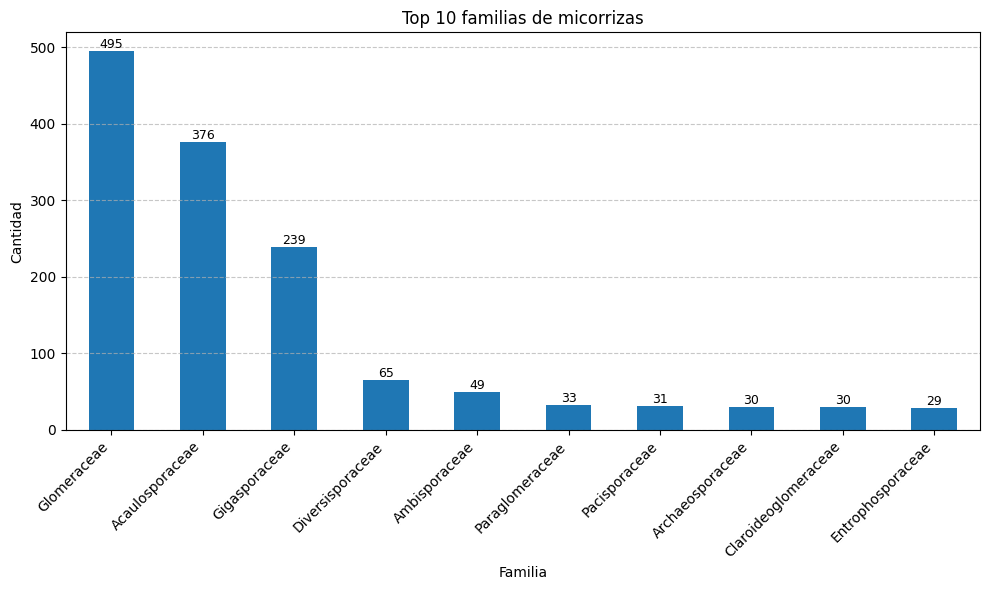

In [88]:
grafica(
    df["familia"].value_counts().head(10),
    "Top 10 familias de micorrizas",
    "Familia"
)

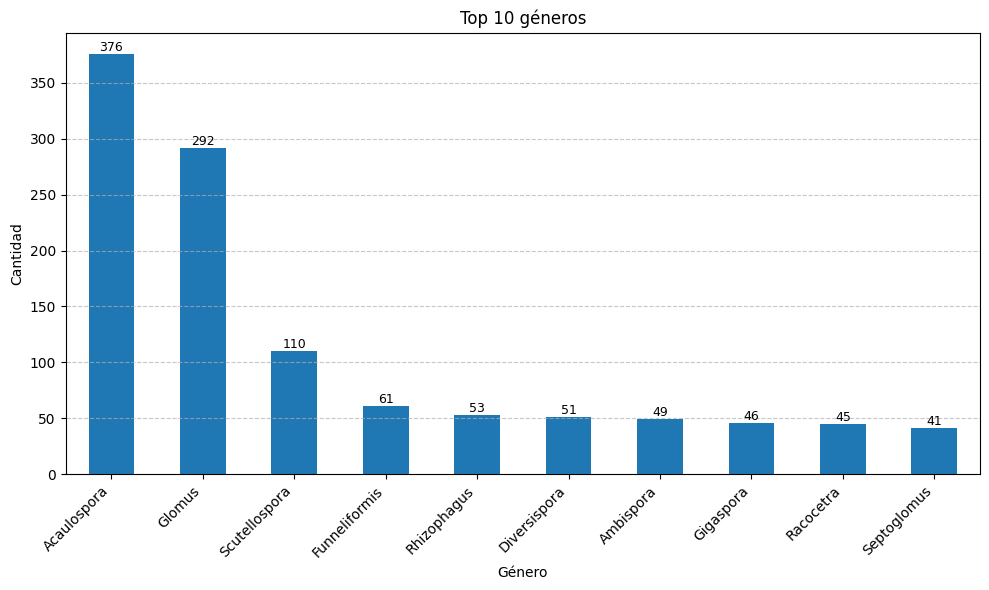

In [89]:
grafica(
    df["genero"].value_counts().head(10),
    "Top 10 géneros",
    "Género"
)

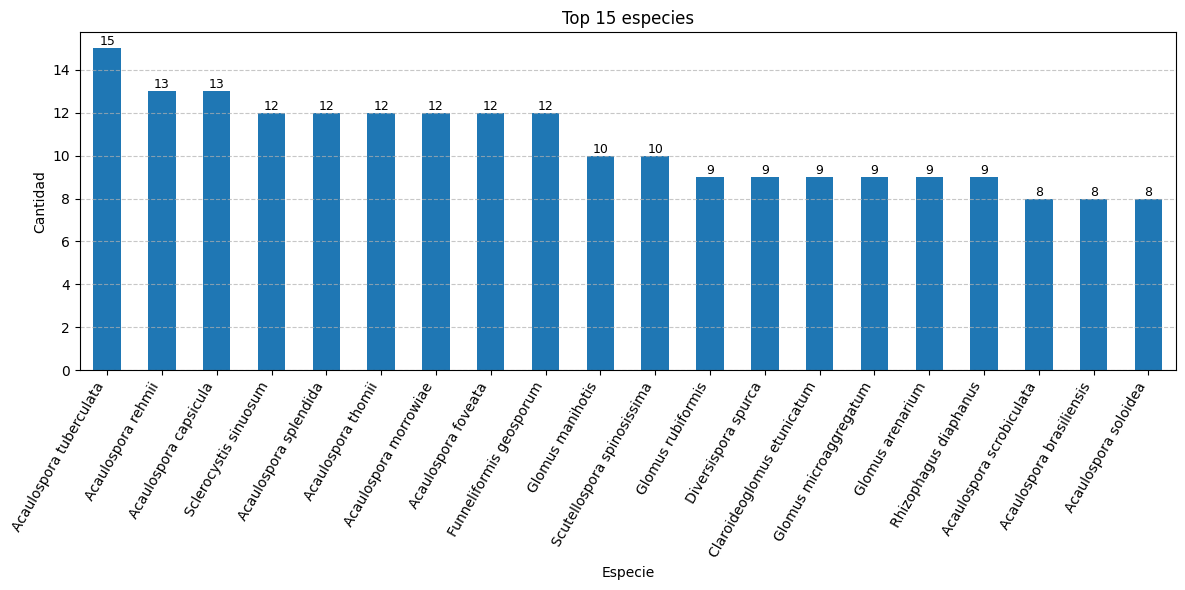

In [90]:
grafica(
    df["nombre_cientifico"].value_counts().head(20),
    "Top 15 especies",
    "Especie",
    figsize=(12,6),
    rotacion=60
)

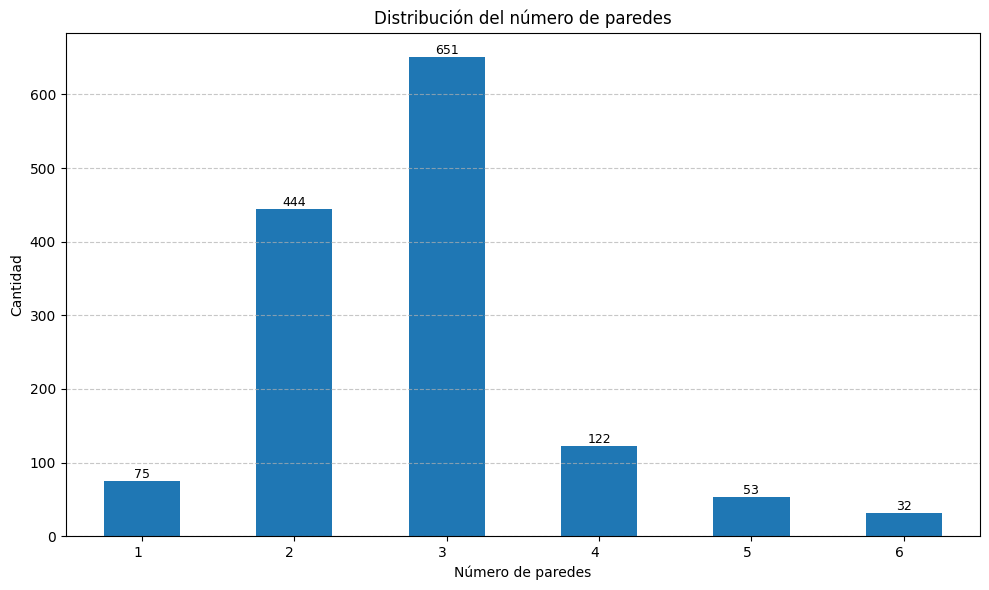

In [91]:
grafica(
    df["numero_paredes"].value_counts().sort_index(),
    "Distribución del número de paredes",
    "Número de paredes",
    rotacion=0
)

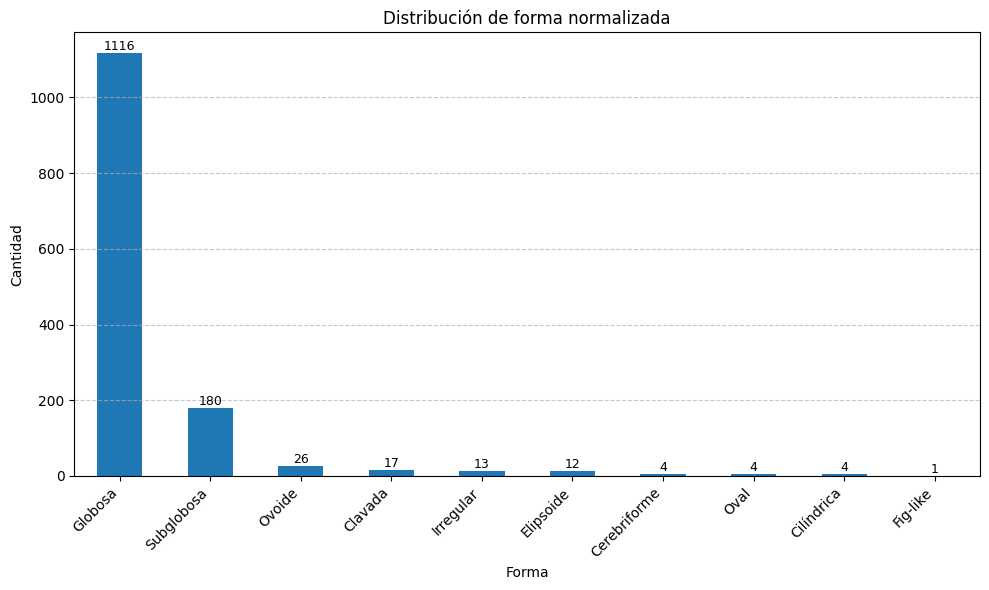

In [92]:
grafica(
    df["forma_std"].value_counts(),
    "Distribución de forma normalizada",
    "Forma"
)

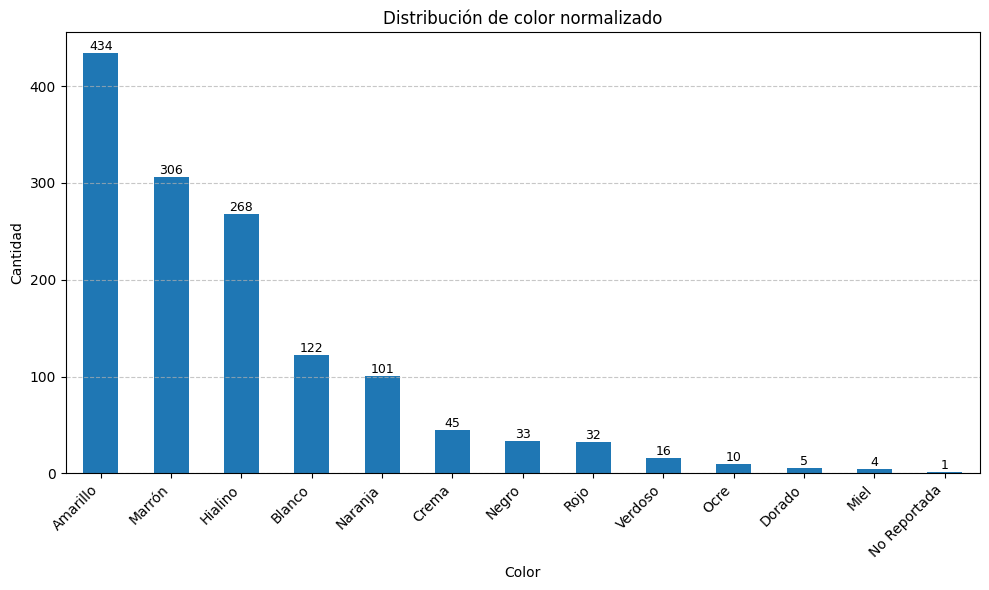

In [93]:
grafica(
    df["color_std"].value_counts(),
    "Distribución de color normalizado",
    "Color"
)

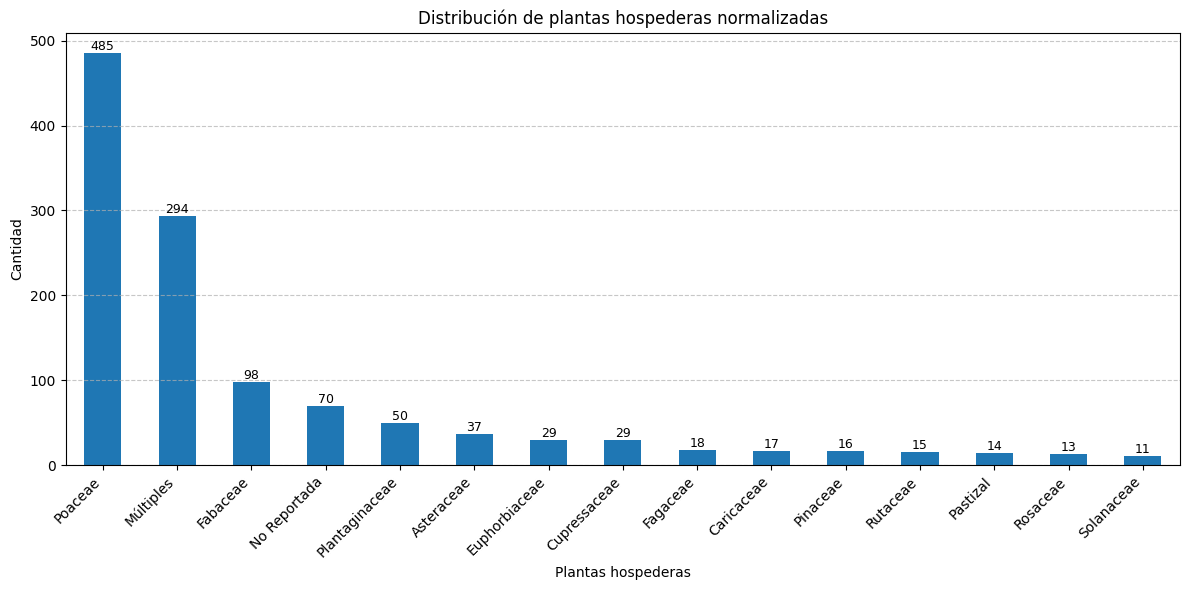

In [94]:
grafica(
    df["plantas_std"].value_counts().head(15),
    "Distribución de plantas hospederas normalizadas",
    "Plantas hospederas",
    figsize=(12,6)
)

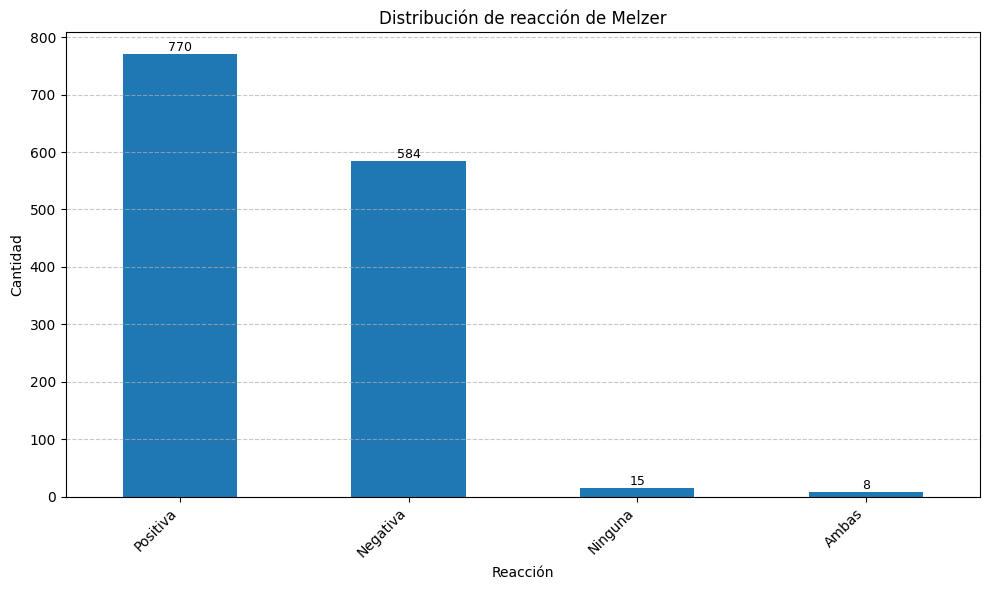

In [95]:
grafica(
    df["reaccion_melzer_std"].value_counts(),
    "Distribución de reacción de Melzer",
    "Reacción"
)

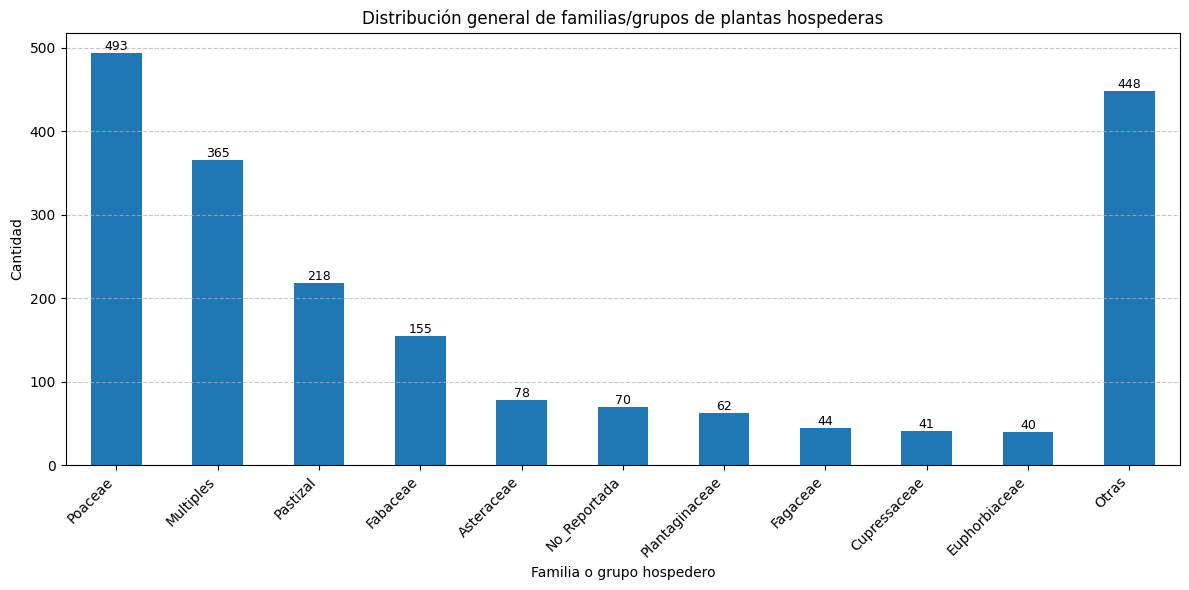

In [96]:
conteo_plantas = df_plantas.sum().sort_values(ascending=False)

top_n = 10
top = conteo_plantas.head(top_n)
otras = conteo_plantas.iloc[top_n:].sum()

conteo_plantas_general = pd.concat([
    top,
    pd.Series({"planta_Otras": otras})
])

conteo_plantas_general.index = conteo_plantas_general.index.str.replace("planta_", "", regex=False)

grafica(
    conteo_plantas_general,
    "Distribución general de familias/grupos de plantas hospederas",
    "Familia o grupo hospedero",
    figsize=(12,6)
)

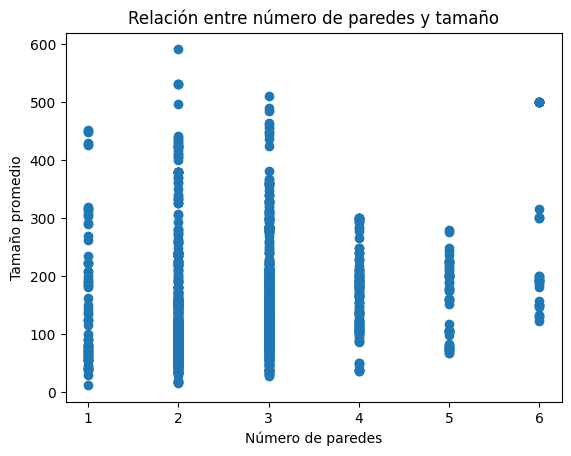

In [97]:
plt.figure()

plt.scatter(df["numero_paredes"], df["tam_promedio"])

plt.title("Relación entre número de paredes y tamaño")
plt.xlabel("Número de paredes")
plt.ylabel("Tamaño promedio")
plt.show()

In [98]:
# =========================================
# ELIMINAR ESPECIES MUY PEQUEÑAS
# =========================================

conteo_especies = df["nombre_cientifico"].value_counts()

especies_validas = conteo_especies[
    conteo_especies >= 4
].index

df = df[
    df["nombre_cientifico"].isin(especies_validas)
].copy()

print("Nueva dimensión:", df.shape)

print("\nCantidad de especies:")
print(df["nombre_cientifico"].nunique())

print("\nDistribución:")
print(df["nombre_cientifico"].value_counts())

Nueva dimensión: (1281, 352)

Cantidad de especies:
204

Distribución:
nombre_cientifico
Acaulospora tuberculata       15
Acaulospora capsicula         13
Acaulospora rehmii            13
Acaulospora morrowiae         12
Acaulospora foveata           12
                              ..
Sclerocystis rubiformis        4
Sclerocystis coremioides       4
Sclerocystis liquidambaris     4
Sclerocystis pubescens         4
Paraglomus laccatum            4
Name: count, Length: 204, dtype: int64


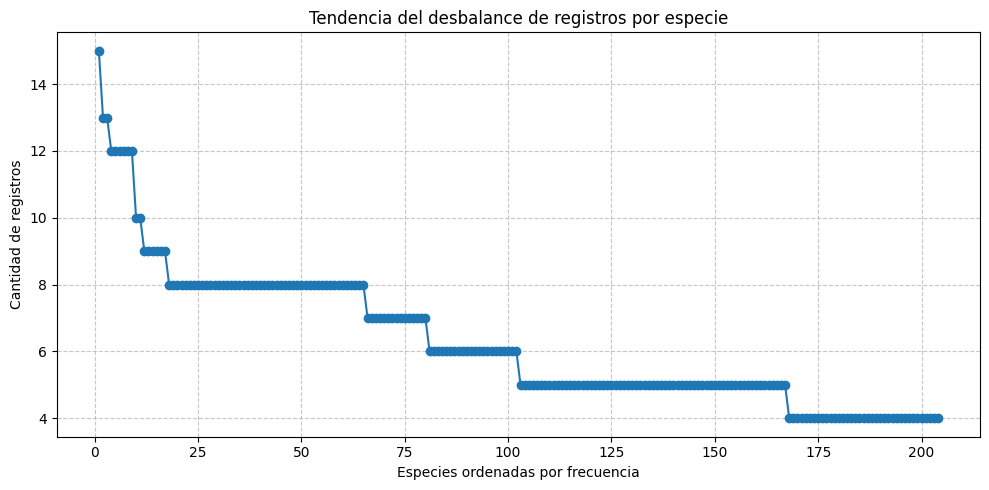

In [99]:
conteo_especies = df["nombre_cientifico"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,5))

plt.plot(range(1, len(conteo_especies)+1), conteo_especies.values, marker="o")

plt.title("Tendencia del desbalance de registros por especie")
plt.xlabel("Especies ordenadas por frecuencia")
plt.ylabel("Cantidad de registros")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

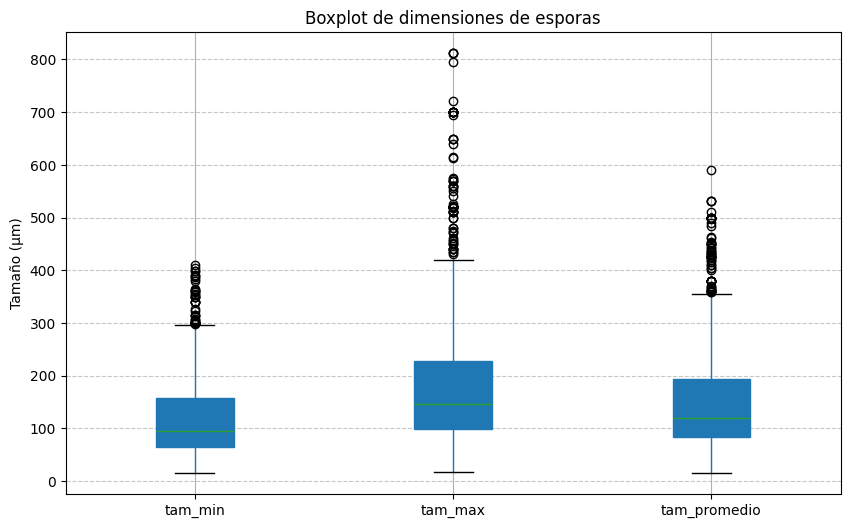

In [100]:
# BOXPLOT - Tamaño de espora
plt.figure(figsize=(10,6))

box = df[
    [
        "tam_min",
        "tam_max",
        "tam_promedio"
    ]
].boxplot(
    patch_artist=True
)

for patch in box.artists:
    patch.set_facecolor("steelblue")

plt.title(
    "Boxplot de dimensiones de esporas"
)

plt.ylabel("Tamaño (µm)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

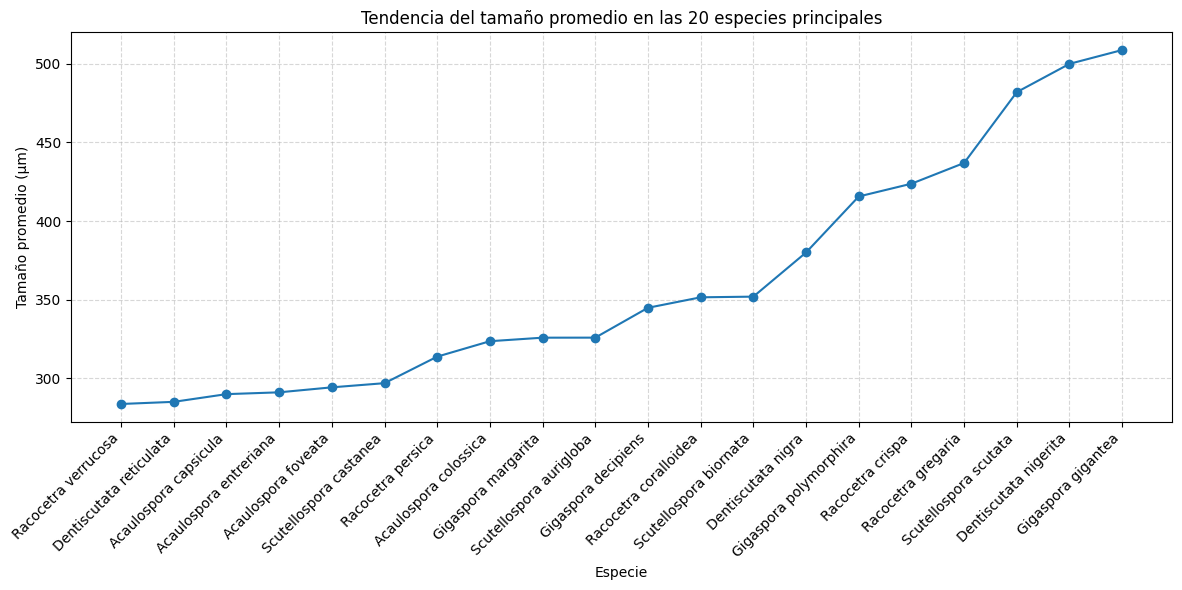

In [101]:
top_especies = (
    df.groupby("nombre_cientifico")["tam_promedio"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12,6))

plt.plot(
    top_especies.index,
    top_especies.values,
    marker="o"
)

plt.title("Tendencia del tamaño promedio en las 20 especies principales")
plt.xlabel("Especie")
plt.ylabel("Tamaño promedio (µm)")

plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

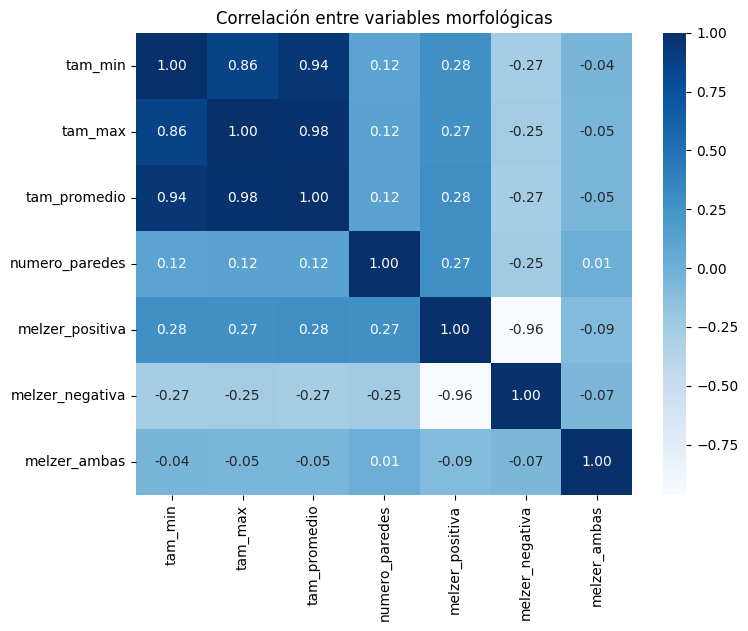

In [102]:
# Heatmap de correlación de variables numéricas + Melzer
columnas_heatmap = [
    "tam_min",
    "tam_max",
    "tam_promedio",
    "numero_paredes",
    "melzer_positiva",
    "melzer_negativa",
    "melzer_ambas"
]

corr = df[columnas_heatmap].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlación entre variables morfológicas")
plt.show()

In [103]:
df.head()

,familia,genero,nombre_cientifico,tamaño_espora,plantas_hospederas,forma,color,numero_paredes,reaccion_melzer,conexion_hifal,...,tex_sup_ondulada,tex_sup_ornamentada,tex_sup_otro,tex_sup_papilada,tex_sup_perforada,tex_sup_reticulada,tex_sup_rigida,tex_sup_rugosa,tex_sup_scrobiculada,tex_sup_verrugosa
0,Acaulosporaceae,Acaulospora,Acaulospora paulinae,60.0-95.0 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,0,0,0,0,1,0,0,0,0,0
1,Acaulosporaceae,Acaulospora,Acaulospora paulinae,60.0-96.0 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,0,0,0,0,1,0,0,0,0,0
4,Acaulosporaceae,Acaulospora,Acaulospora paulinae,63.4-84.3 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,0,0,0,0,1,0,0,0,0,0
5,Acaulosporaceae,Acaulospora,Acaulospora paulinae,68.1-91.9 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,0,0,0,0,1,0,0,0,0,0
6,Acaulosporaceae,Acaulospora,Acaulospora paulinae,60.4-94.4 µm,Múltiples plantas (asociación vesículo-arbuscu...,"Globosa a subglobosa, ovoides",Hialinas a pálido amarillento,3,Positiva,Lateral al saco esporífero,...,0,0,0,0,1,0,0,0,0,0


In [104]:
df.tail()

,familia,genero,nombre_cientifico,tamaño_espora,plantas_hospederas,forma,color,numero_paredes,reaccion_melzer,conexion_hifal,...,tex_sup_ondulada,tex_sup_ornamentada,tex_sup_otro,tex_sup_papilada,tex_sup_perforada,tex_sup_reticulada,tex_sup_rigida,tex_sup_rugosa,tex_sup_scrobiculada,tex_sup_verrugosa
1964,Diversisporaceae,Otospora,Otospora boreai,150-200 µm,"Plantas aromáticas (Lavandula, Thymus, Rosmari...","Globosa, subglobosa",Café amarillenta a café,4,Negativa,Crece lateralmente sobre el cuello hifal del s...,...,0,0,0,0,0,0,0,0,0,0
1969,Diversisporaceae,Otospora,Otospora boreai,151.9-180.1 µm,"Plantas aromáticas (Lavandula, Thymus, Rosmari...","Globosa, subglobosa",Café amarillenta a café,4,Negativa,Crece lateralmente sobre el cuello hifal del s...,...,0,0,0,0,0,0,0,0,0,0
1970,Diversisporaceae,Otospora,Otospora boreai,164.4-196.5 µm,"Plantas aromáticas (Lavandula, Thymus, Rosmari...","Globosa, subglobosa",Café amarillenta a café,4,Negativa,Crece lateralmente sobre el cuello hifal del s...,...,0,0,0,0,0,0,0,0,0,0
1971,Diversisporaceae,Otospora,Otospora boreai,161.4-179.9 µm,"Plantas aromáticas (Lavandula, Thymus, Rosmari...","Globosa, subglobosa",Café amarillenta a café,4,Negativa,Crece lateralmente sobre el cuello hifal del s...,...,0,0,0,0,0,0,0,0,0,0
1972,Diversisporaceae,Otospora,Otospora boreai,160.4-173.4 µm,"Plantas aromáticas (Lavandula, Thymus, Rosmari...","Globosa, subglobosa",Café amarillenta a café,4,Negativa,Crece lateralmente sobre el cuello hifal del s...,...,0,0,0,0,0,0,0,0,0,0


In [105]:
df.to_csv("dataset_limpio.csv", index=False)
df.to_excel("dataset_limpio.xlsx", index=False)

print("Dataset limpio guardado correctamente")

Dataset limpio guardado correctamente


Fase 2: Entrenamiento, evaluación y selección del modelo

In [106]:
!pip install xgboost lightgbm

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [108]:
df = pd.read_excel("dataset_limpio.xlsx")

print("Dataset cargado:")
print("Shape:", df.shape)
print("Columnas:", df.columns)

Dataset cargado:
Shape: (1281, 352)
Columnas: Index(['familia', 'genero', 'nombre_cientifico', 'tamaño_espora',
       'plantas_hospederas', 'forma', 'color', 'numero_paredes',
       'reaccion_melzer', 'conexion_hifal',
       ...
       'tex_sup_ondulada', 'tex_sup_ornamentada', 'tex_sup_otro',
       'tex_sup_papilada', 'tex_sup_perforada', 'tex_sup_reticulada',
       'tex_sup_rigida', 'tex_sup_rugosa', 'tex_sup_scrobiculada',
       'tex_sup_verrugosa'],
      dtype='object', length=352)


Revision de la variable objetiva (especie)

In [109]:
print("Distribución de especie:")
df["nombre_cientifico"].value_counts()

Distribución de especie:


,count
nombre_cientifico,
Acaulospora tuberculata,15
Acaulospora capsicula,13
Acaulospora rehmii,13
Acaulospora morrowiae,12
Acaulospora foveata,12
...,...
Sclerocystis rubiformis,4
Sclerocystis coremioides,4
Sclerocystis liquidambaris,4


Codificar variable objetivo

In [110]:
# =========================================
# CODIFICAR VARIABLE OBJETIVO
# =========================================

label_encoder_especie = LabelEncoder()

df["especie_encoded"] = (
    label_encoder_especie.fit_transform(
        df["nombre_cientifico"]
    )
)

print("Clases del modelo:")
print(label_encoder_especie.classes_)

df[[
    "nombre_cientifico",
    "especie_encoded"
]].head()

Clases del modelo:
['Acaulospora alpina' 'Acaulospora aspera' 'Acaulospora baetica'
 'Acaulospora bireticulata' 'Acaulospora brasiliensis'
 'Acaulospora capsicula' 'Acaulospora cavernata' 'Acaulospora colliculosa'
 'Acaulospora colombiana' 'Acaulospora colossica' 'Acaulospora delicata'
 'Acaulospora denticulata' 'Acaulospora dilatata' 'Acaulospora entreriana'
 'Acaulospora excavata' 'Acaulospora fanjing' 'Acaulospora flava'
 'Acaulospora foveata' 'Acaulospora gedanensis' 'Acaulospora ignota'
 'Acaulospora jejuensis' 'Acaulospora kentinensis' 'Acaulospora koreana'
 'Acaulospora koskei' 'Acaulospora lacunosa' 'Acaulospora laevis'
 'Acaulospora longula' 'Acaulospora mendoncae' 'Acaulospora minuta'
 'Acaulospora morrowiae' 'Acaulospora myriocarpa' 'Acaulospora nicolsonii'
 'Acaulospora papillosa' 'Acaulospora paulinae' 'Acaulospora polonica'
 'Acaulospora punctata' 'Acaulospora reducta' 'Acaulospora rehmii'
 'Acaulospora rugosa' 'Acaulospora scrobiculata'
 'Acaulospora sieverdingii' 'Acaul

,nombre_cientifico,especie_encoded
0,Acaulospora paulinae,33
1,Acaulospora paulinae,33
2,Acaulospora paulinae,33
3,Acaulospora paulinae,33
4,Acaulospora paulinae,33


Seleccion de las variables predictoras

In [111]:
datos_entrada_modelo = []

# 1. tamaño_espora
datos_entrada_modelo += [
    "tam_min",
    "tam_max",
    "tam_promedio"
]

# 2. numero_paredes
datos_entrada_modelo += [
    "numero_paredes"
]

# 3. reaccion_melzer
datos_entrada_modelo += [
    "melzer_positiva",
    "melzer_negativa",
    "melzer_ninguna",
    "melzer_ambas"
]

# 4. forma
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("forma_")
    and col not in ["forma_std", "forma_token"]
]

# 5. color
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("color_")
    and col not in ["color_std", "color_token"]
]

# 6. textura
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("tex_")
]

# 7. conexion_hifal
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("conexion_")
]

# 8. plantas_hospederas opcional
datos_entrada_modelo += [
    col for col in df.columns
    if col.startswith("planta_")
]

# =========================================
# VALIDAR COLUMNAS EXISTENTES
# =========================================

datos_entrada_modelo = [
    col for col in datos_entrada_modelo
    if col in df.columns
]

# =========================================
# QUITAR COLUMNAS QUE METEN RUIDO
# =========================================

columnas_prohibidas = [
    "forma_std",
    "forma_token",
    "color_std",
    "color_token"
]

datos_entrada_modelo = [
    col for col in datos_entrada_modelo
    if col not in columnas_prohibidas
]

# =========================================
# VERIFICACION
# =========================================

print("Total de variables para el modelo:", len(datos_entrada_modelo))

print("\nColumnas de conexión hifal:")
print([
    col for col in datos_entrada_modelo
    if col.startswith("conexion_")
])

print("\nColumnas descriptivas que NO deben estar:")
print([
    col for col in datos_entrada_modelo
    if col.startswith((
        "ph_",
        "alt_",
        "temp_",
        "conductividad",
        "nitrogeno",
        "habitat_",
        "vegetacion_",
        "textura_suelo_"
    ))
])

Total de variables para el modelo: 304

Columnas de conexión hifal:
['conexion_hifal', 'conexion_token', 'conexion_Acampanada', 'conexion_Apendice', 'conexion_Canal', 'conexion_Celula_Bulbosa', 'conexion_Cerrado', 'conexion_Cicatriz', 'conexion_Cicatriz_Basal', 'conexion_Cicatriz_Circular', 'conexion_Cicatriz_Denticulada', 'conexion_Cicatriz_Prominente', 'conexion_Cilindrica', 'conexion_Clavada', 'conexion_Claviforme', 'conexion_Colapso', 'conexion_Con_Septo', 'conexion_Constricta', 'conexion_Curvada', 'conexion_Delgada', 'conexion_Densa', 'conexion_Desprendimiento', 'conexion_Detritos', 'conexion_Doble', 'conexion_Duradera', 'conexion_Elipsoide', 'conexion_Embudo', 'conexion_Ensanchada', 'conexion_Espinosa', 'conexion_Extraradical', 'conexion_Flexible', 'conexion_Glomoide', 'conexion_Gruesa', 'conexion_Hialina', 'conexion_Hifa_Simple', 'conexion_Hifa_Subtendente', 'conexion_Hifa_Suspensora', 'conexion_Hifa_Sustentora', 'conexion_Intrahifal', 'conexion_Intrarradical', 'conexion_Laminad

Preparación de Variables (X, y)

In [112]:
X = df[datos_entrada_modelo].copy()
y = df["especie_encoded"].copy()

X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

print("X:", X.shape)
print("y:", y.shape)
print("Nulos en X:", X.isnull().sum().sum())

X: (1281, 304)
y: (1281,)
Nulos en X: 0


## División del dataset: 80% entrenamiento y 20% prueba

In [113]:
from sklearn.model_selection import train_test_split

# 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("================================")
print("DIVISION DEL DATASET")
print("================================")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

DIVISION DEL DATASET
X_train: (1024, 304)
X_test : (257, 304)
y_train: (1024,)
y_test : (257,)


Manejo del desbalance con sample_weight

In [114]:
from sklearn.utils.class_weight import compute_class_weight

In [115]:
# =========================================
# MANEJO DEL DESBALANCE DE CLASES
# =========================================

clases = np.unique(y_train)

pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=y_train
)

# Diccionario clase -> peso
class_weights = dict(zip(clases, pesos))

# Sample weight para entrenamiento
sample_weight_train = (
    pd.Series(y_train)
    .map(class_weights)
    .values
)

print("Pesos por clase:")
print(class_weights)

print("\nSample weight generado correctamente")

print("Total pesos:",
      len(sample_weight_train))

Pesos por clase:
{np.int64(0): np.float64(0.8366013071895425), np.int64(1): np.float64(0.8366013071895425), np.int64(2): np.float64(0.8366013071895425), np.int64(3): np.float64(1.003921568627451), np.int64(4): np.float64(0.7170868347338936), np.int64(5): np.float64(0.5019607843137255), np.int64(6): np.float64(1.2549019607843137), np.int64(7): np.float64(1.2549019607843137), np.int64(8): np.float64(1.2549019607843137), np.int64(9): np.float64(0.8366013071895425), np.int64(10): np.float64(1.003921568627451), np.int64(11): np.float64(1.2549019607843137), np.int64(12): np.float64(1.2549019607843137), np.int64(13): np.float64(1.2549019607843137), np.int64(14): np.float64(1.2549019607843137), np.int64(15): np.float64(0.8366013071895425), np.int64(16): np.float64(0.8366013071895425), np.int64(17): np.float64(0.5019607843137255), np.int64(18): np.float64(1.003921568627451), np.int64(19): np.float64(0.8366013071895425), np.int64(20): np.float64(0.8366013071895425), np.int64(21): np.float64(1.00

Modelos base

In [116]:
# =========================================
# MODELOS BASE
# =========================================

modelo_rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# =========================================
# XGBOOST
# =========================================

modelo_xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    eval_metric=["mlogloss", "merror"],
    random_state=42,
    n_jobs=-1
)

# =========================================
# LIGHTGBM
# =========================================

modelo_lgbm_base = LGBMClassifier(
    objective="multiclass",
    num_class=len(np.unique(y_train)),
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    min_data_in_leaf=20,
    feature_fraction=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# =========================================
# DICCIONARIO DE MODELOS
# =========================================

modelos_base = {
    "Random Forest": modelo_rf_base,
    "XGBoost": modelo_xgb_base,
    "LightGBM": modelo_lgbm_base
}

print("Modelos base creados correctamente")

Modelos base creados correctamente


Métricas iniciales antes de validación cruzada

In [117]:
# =========================================
# METRICAS INICIALES ANTES DE VALIDACION CRUZADA
# =========================================

resultados_base = []

modelos_base_entrenados = {}

for nombre, modelo in modelos_base.items():

    print(f"\nEntrenando modelo base: {nombre}")

    if nombre == "XGBoost":

        modelo.fit(
            X_train,
            y_train,
            sample_weight=sample_weight_train
        )

    else:
        modelo.fit(
            X_train,
            y_train
        )

    # Predicción sobre el 20% de prueba
    y_pred_test = modelo.predict(X_test)

    resultados_base.append({

        "Modelo": nombre,

        "Accuracy": accuracy_score(
            y_test,
            y_pred_test
        ),

        "Precision": precision_score(
            y_test,
            y_pred_test,
            average="macro",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred_test,
            average="macro",
            zero_division=0
        ),

        "F1-score": f1_score(
            y_test,
            y_pred_test,
            average="macro",
            zero_division=0
        )

    })

    modelos_base_entrenados[nombre] = modelo

# =========================================
# TABLA FINAL
# =========================================

tabla_base = pd.DataFrame(resultados_base)

tabla_base["Accuracy (%)"] = (
    tabla_base["Accuracy"] * 100
).round(2)

tabla_base["Precision (%)"] = (
    tabla_base["Precision"] * 100
).round(2)

tabla_base["Recall (%)"] = (
    tabla_base["Recall"] * 100
).round(2)

tabla_base["F1-score (%)"] = (
    tabla_base["F1-score"] * 100
).round(2)


tabla_base = tabla_base[
    [
        "Modelo",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-score (%)"
    ]
]

display(tabla_base)


Entrenando modelo base: Random Forest

Entrenando modelo base: XGBoost

Entrenando modelo base: LightGBM


,Modelo,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Random Forest,97.67,97.22,97.79,97.27
1,XGBoost,96.89,96.32,97.06,96.36
2,LightGBM,95.33,94.93,95.83,94.84


Gráfica de métricas iniciales

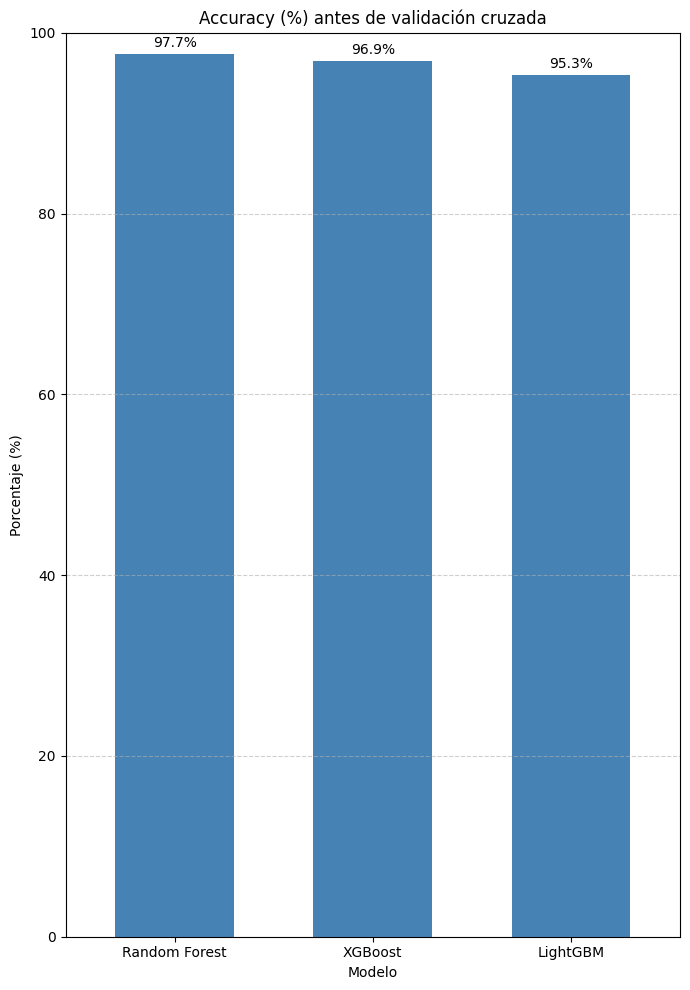

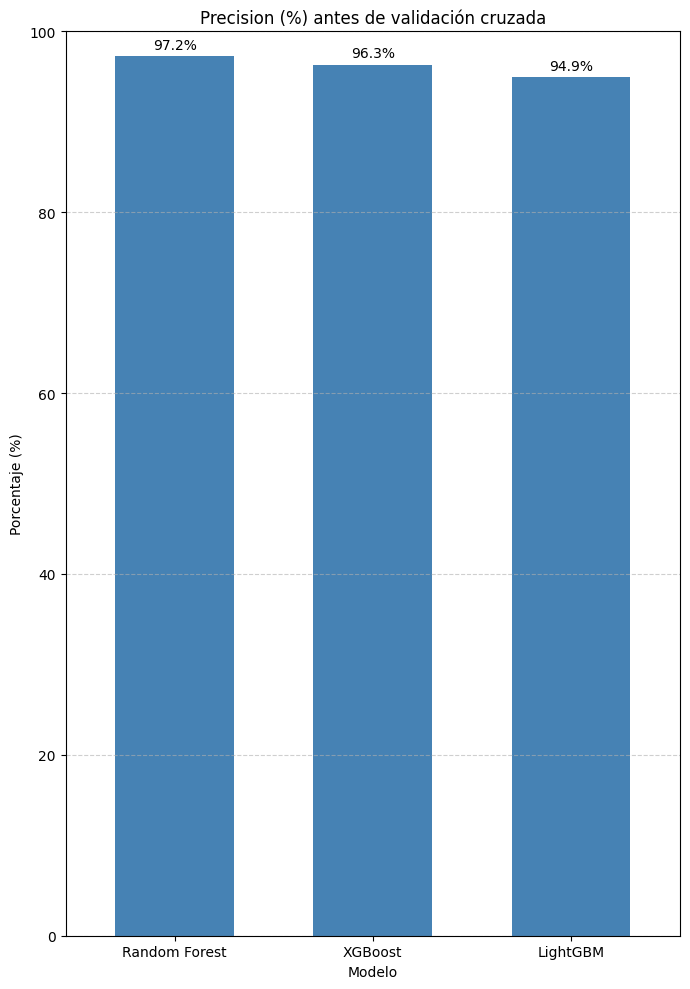

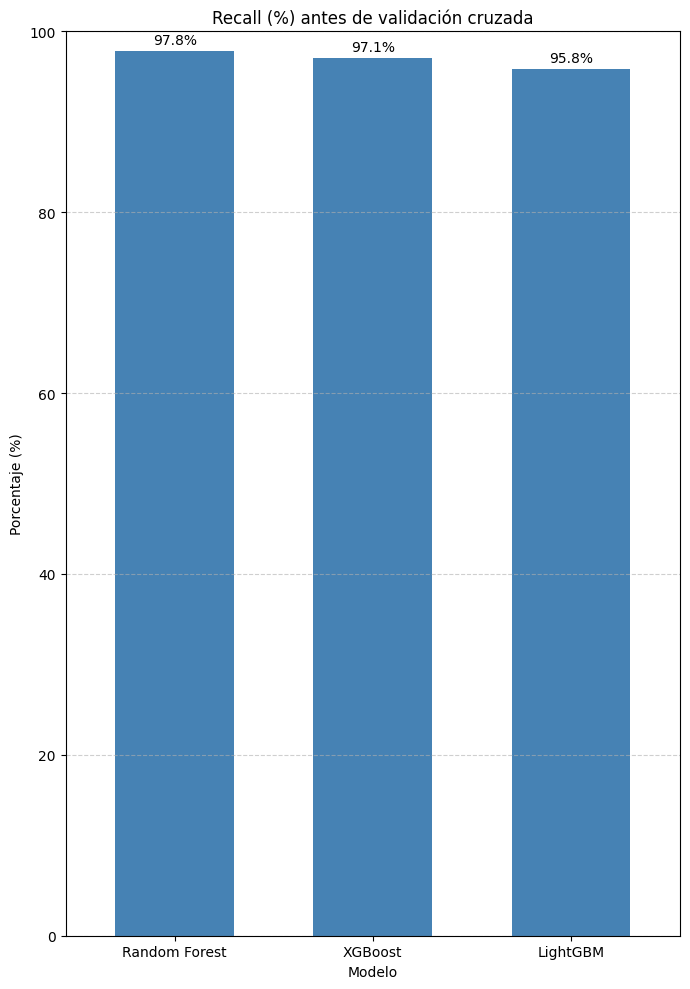

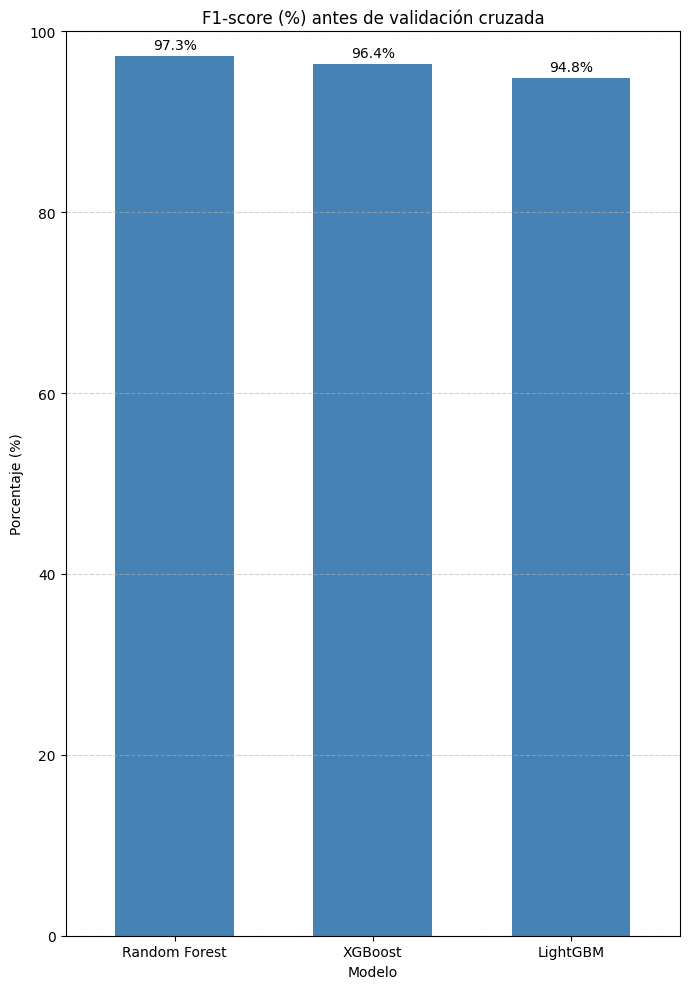

In [118]:
metricas = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]

for metrica in metricas:

    ax = (
        tabla_base
        .set_index("Modelo")[metrica]
        .plot(
            kind="bar",
            figsize=(7,10),
            width=0.6,
            color="steelblue"
        )
    )

    plt.title(
        f"{metrica} antes de validación cruzada"
    )

    plt.ylabel("Porcentaje (%)")
    plt.xlabel("Modelo")

    plt.ylim(0, 100)

    plt.xticks(rotation=0)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.6
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

    plt.tight_layout()
    plt.show()

Hiperparámetros considerados

In [119]:
param_rf = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

In [120]:
param_xgb = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.5, 1, 2, 3, 5]
}

In [121]:
param_lgbm = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    "num_leaves": [20, 31, 50, 80, 100, 150],
    "max_depth": [-1, 10, 20, 30, 40, 50],
    "min_data_in_leaf": [10, 20, 30, 40, 50],
    "feature_fraction": [0.6, 0.7, 0.8, 0.9, 1.0],
    "class_weight": ["balanced"]
}

Validación cruzada estratificada

In [122]:
# =========================================
# VALIDACION CRUZADA ESTRATIFICADA
# =========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Validación cruzada configurada con 5 folds")

Validación cruzada configurada con 5 folds


Ajuste de hiperparámetros Random Forest

In [123]:
# =========================================
# AJUSTE DE HIPERPARAMETROS RF
# VALIDACION CRUZADA 5-FOLD
# =========================================

busqueda_rf = RandomizedSearchCV(

    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=param_rf,

    n_iter=20,

    scoring="f1_macro",

    cv=cv,   # 5 folds = 20% validación dentro del train

    verbose=1,

    random_state=42,

    n_jobs=-1
)

# =========================================
# ENTRENAMIENTO CON 80% TRAIN
# =========================================

busqueda_rf.fit(
    X_train,
    y_train
)

# =========================================
# MEJOR MODELO RF
# =========================================

mejor_rf = busqueda_rf.best_estimator_

print("===================================")
print("MEJORES PARAMETROS RANDOM FOREST")
print("===================================")

print(busqueda_rf.best_params_)

print("\nMejor F1-score promedio en validación cruzada:")
print(busqueda_rf.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


MEJORES PARAMETROS RANDOM FOREST
{'n_estimators': 400, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'class_weight': 'balanced'}

Mejor F1-score promedio en validación cruzada:
0.9527886387923221


Ajuste de hiperparámetros XGBoost con sample_weight

In [124]:
# =========================================
# AJUSTE DE HIPERPARAMETROS XGBOOST
# CON SAMPLE_WEIGHT
# =========================================

busqueda_xgb = RandomizedSearchCV(

    estimator=XGBClassifier(

        objective="multi:softprob",

        num_class=len(np.unique(y_train)),

        eval_metric=["mlogloss", "merror"],

        random_state=42,

        n_jobs=-1
    ),

    param_distributions=param_xgb,

    n_iter=20,

    scoring="f1_macro",

    cv=cv,   # 5 folds = 20% validación dentro del train

    verbose=1,

    random_state=42,

    n_jobs=-1
)

# =========================================
# ENTRENAMIENTO CON SAMPLE_WEIGHT
# =========================================

busqueda_xgb.fit(

    X_train,

    y_train,

    sample_weight=sample_weight_train
)

# =========================================
# MEJOR MODELO XGBOOST
# =========================================

mejor_xgb = busqueda_xgb.best_estimator_

print("===================================")
print("MEJORES PARAMETROS XGBOOST")
print("===================================")

print(busqueda_xgb.best_params_)

print("\nMejor F1-score promedio:")
print(busqueda_xgb.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


MEJORES PARAMETROS XGBOOST
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.3, 'gamma': 0.5, 'colsample_bytree': 0.6}

Mejor F1-score promedio:
0.9433690331084186


Ajuste de hiperparámetros LightGBM

In [125]:
# =========================================
# AJUSTE DE HIPERPARAMETROS LIGHTGBM
# =========================================

busqueda_lgbm = RandomizedSearchCV(

    estimator=LGBMClassifier(

        objective="multiclass",

        num_class=len(np.unique(y_train)),

        class_weight="balanced",

        random_state=42,

        n_jobs=-1,

        verbose=-1
    ),

    param_distributions=param_lgbm,

    n_iter=20,

    scoring="f1_macro",

    cv=cv,   # 5 folds = 20% validación dentro del train

    verbose=1,

    random_state=42,

    n_jobs=-1
)

# =========================================
# ENTRENAMIENTO CON 80% TRAIN
# =========================================

busqueda_lgbm.fit(

    X_train,

    y_train
)

# =========================================
# MEJOR MODELO LIGHTGBM
# =========================================

mejor_lgbm = busqueda_lgbm.best_estimator_

print("===================================")
print("MEJORES PARAMETROS LIGHTGBM")
print("===================================")

print(busqueda_lgbm.best_params_)

print("\nMejor F1-score promedio:")
print(busqueda_lgbm.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


MEJORES PARAMETROS LIGHTGBM
{'num_leaves': 31, 'n_estimators': 400, 'min_data_in_leaf': 10, 'max_depth': 50, 'learning_rate': 0.01, 'feature_fraction': 0.6, 'class_weight': 'balanced'}

Mejor F1-score promedio:
0.9425165041189281


Validación cruzada con modelos ajustados

In [126]:
# =========================================
# VALIDACION CRUZADA CON MODELOS AJUSTADOS
# =========================================

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

modelos_ajustados = {
    "Random Forest Ajustado": mejor_rf,
    "XGBoost Ajustado": mejor_xgb,
    "LightGBM Ajustado": mejor_lgbm
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average="macro", zero_division=0),
    "recall": make_scorer(recall_score, average="macro", zero_division=0),
    "f1": make_scorer(f1_score, average="macro", zero_division=0)
}

resultados_cv_ajustados = []

for nombre, modelo in modelos_ajustados.items():

    print(f"\nValidando modelo ajustado: {nombre}")

    cv_resultados = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,   # 5 folds = 20% validación dentro del train
        scoring=scoring,
        n_jobs=-1
    )

    resultados_cv_ajustados.append({

        "Modelo": nombre,

        "Accuracy CV": cv_resultados["test_accuracy"].mean(),

        "Precision CV": cv_resultados["test_precision"].mean(),

        "Recall CV": cv_resultados["test_recall"].mean(),

        "F1-score CV": cv_resultados["test_f1"].mean()
    })

# =========================================
# TABLA DE RESULTADOS
# =========================================

tabla_cv_ajustados = pd.DataFrame(
    resultados_cv_ajustados
)

tabla_cv_ajustados["Accuracy CV (%)"] = (
    tabla_cv_ajustados["Accuracy CV"] * 100
).round(2)

tabla_cv_ajustados["Precision CV (%)"] = (
    tabla_cv_ajustados["Precision CV"] * 100
).round(2)

tabla_cv_ajustados["Recall CV (%)"] = (
    tabla_cv_ajustados["Recall CV"] * 100
).round(2)

tabla_cv_ajustados["F1-score CV (%)"] = (
    tabla_cv_ajustados["F1-score CV"] * 100
).round(2)

tabla_cv_ajustados = tabla_cv_ajustados[
    [
        "Modelo",
        "Accuracy CV (%)",
        "Precision CV (%)",
        "Recall CV (%)",
        "F1-score CV (%)"
    ]
]

display(tabla_cv_ajustados)


Validando modelo ajustado: Random Forest Ajustado


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Validando modelo ajustado: XGBoost Ajustado


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Validando modelo ajustado: LightGBM Ajustado


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Modelo,Accuracy CV (%),Precision CV (%),Recall CV (%),F1-score CV (%)
0,Random Forest Ajustado,96.10,95.14,96.20,95.28
1,XGBoost Ajustado,95.12,94.40,95.64,94.57
2,LightGBM Ajustado,95.12,94.10,95.37,94.25


Gráfica de validación cruzada

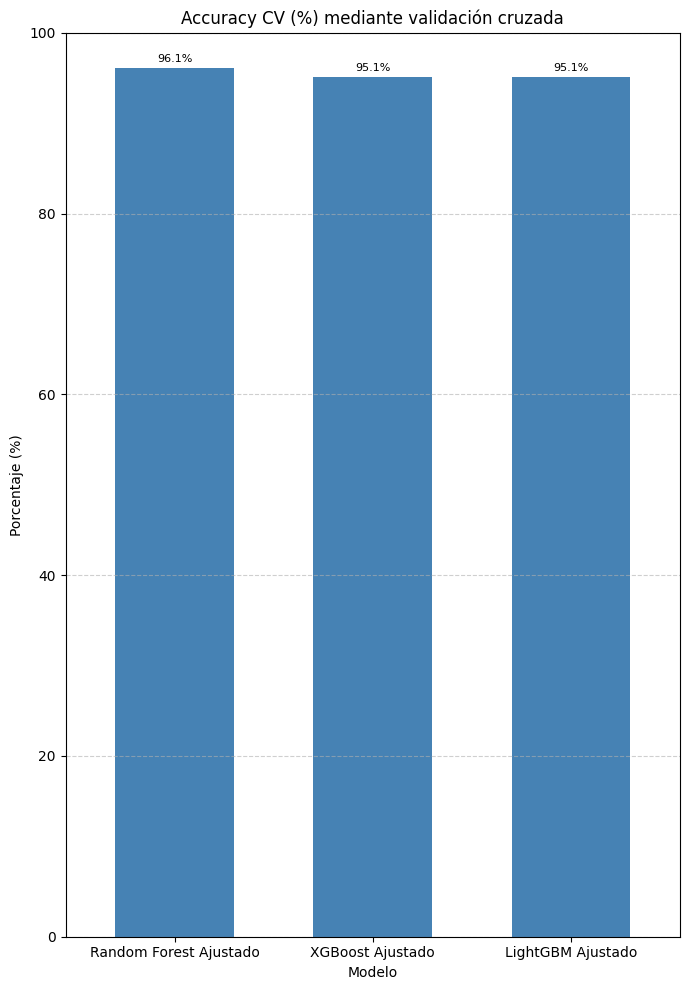

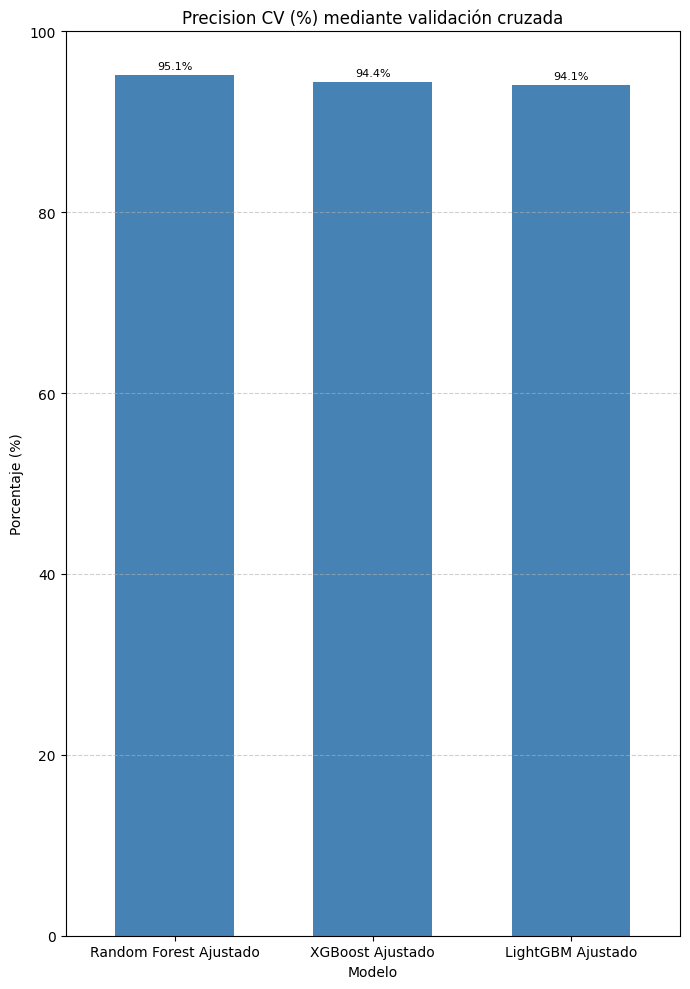

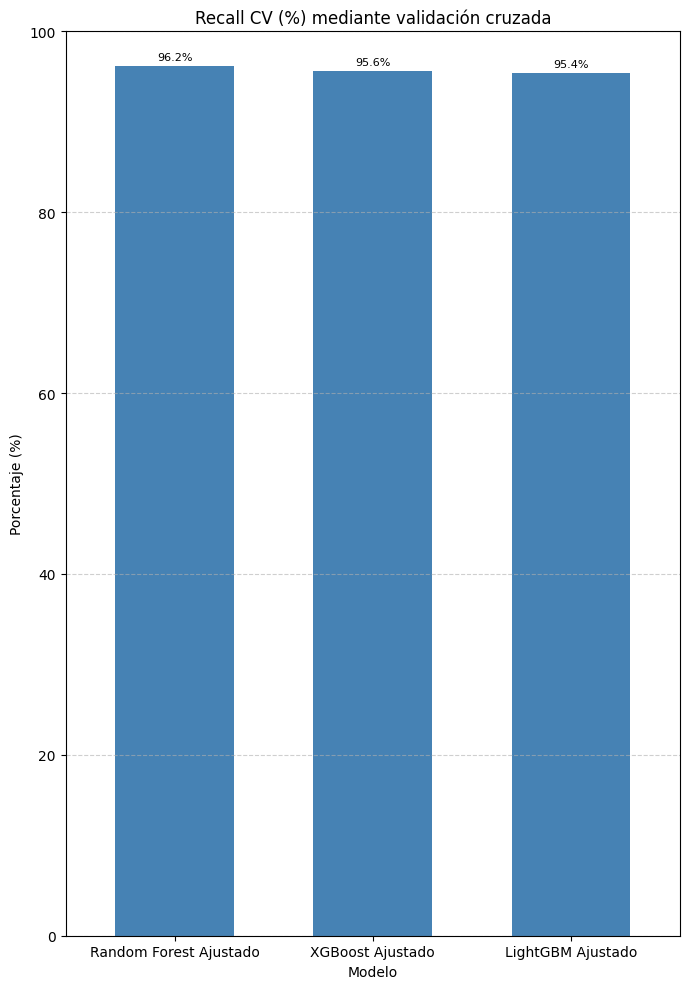

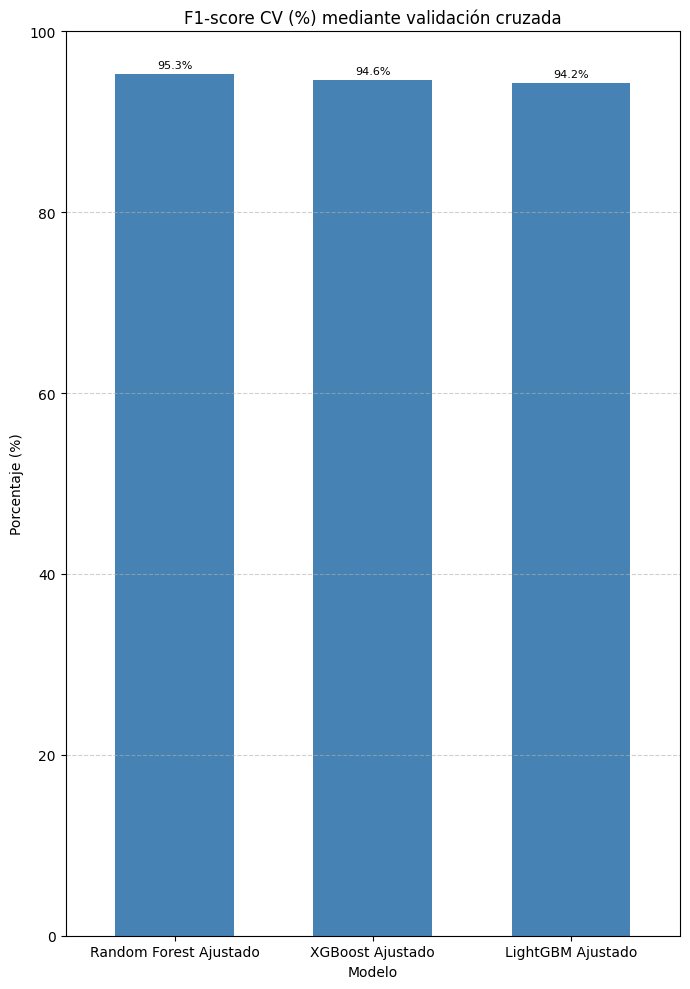

In [127]:
metricas = [
    "Accuracy CV (%)",
    "Precision CV (%)",
    "Recall CV (%)",
    "F1-score CV (%)"
]

for metrica in metricas:

    ax = (
        tabla_cv_ajustados
        .set_index("Modelo")[metrica]
        .plot(
            kind="bar",
            figsize=(7,10),
            width=0.6,
            color="steelblue"
        )
    )

    plt.title(
        f"{metrica} mediante validación cruzada"
    )

    plt.xlabel("Modelo")
    plt.ylabel("Porcentaje (%)")

    plt.ylim(0, 100)

    plt.xticks(rotation=0)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.6
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=8,
            padding=3
        )

    plt.tight_layout()

    plt.show()

Entrenamiento final usando validación

In [128]:
# =========================================
# ENTRENAMIENTO FINAL DE MODELOS
# =========================================

modelos_entrenados = {}

# =========================================
# RANDOM FOREST
# =========================================

mejor_rf.fit(
    X_train,
    y_train
)

modelos_entrenados["Random Forest"] = mejor_rf

# =========================================
# XGBOOST
# =========================================

mejor_xgb.fit(
    X_train,
    y_train,
    sample_weight=sample_weight_train
)

modelos_entrenados["XGBoost"] = mejor_xgb

# =========================================
# LIGHTGBM
# =========================================

mejor_lgbm.fit(
    X_train,
    y_train
)

modelos_entrenados["LightGBM"] = mejor_lgbm

print("Modelos finales entrenados correctamente")

print(modelos_entrenados.keys())

Modelos finales entrenados correctamente
dict_keys(['Random Forest', 'XGBoost', 'LightGBM'])


Evaluación final con conjunto de prueba

In [129]:
# =========================================
# EVALUACION FINAL CON TEST
# =========================================

resultados_test = []

for nombre, modelo in modelos_entrenados.items():

    print(f"\nEvaluando modelo: {nombre}")

    # =====================================
    # PREDICCIONES
    # =====================================

    y_pred_test = modelo.predict(X_test)

    # =====================================
    # METRICAS
    # =====================================

    resultados_test.append({

        "Modelo": nombre,

        "Accuracy": accuracy_score(
            y_test,
            y_pred_test
        ),

        "Precision": precision_score(
            y_test,
            y_pred_test,
            average="macro",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred_test,
            average="macro",
            zero_division=0
        ),

        "F1-score": f1_score(
            y_test,
            y_pred_test,
            average="macro",
            zero_division=0
        )

    })

# =========================================
# TABLA FINAL
# =========================================

tabla_test = pd.DataFrame(resultados_test)

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]:
    tabla_test[col] = (
        tabla_test[col] * 100
    ).round(2)

tabla_test = tabla_test.sort_values(
    by="F1-score",
    ascending=False
)

tabla_test


Evaluando modelo: Random Forest

Evaluando modelo: XGBoost

Evaluando modelo: LightGBM


,Modelo,Accuracy,Precision,Recall,F1-score
0,Random Forest,97.28,96.81,97.39,96.80
1,XGBoost,96.50,96.24,96.81,96.11
2,LightGBM,96.11,95.59,96.32,95.54


Gráfica de métricas finales

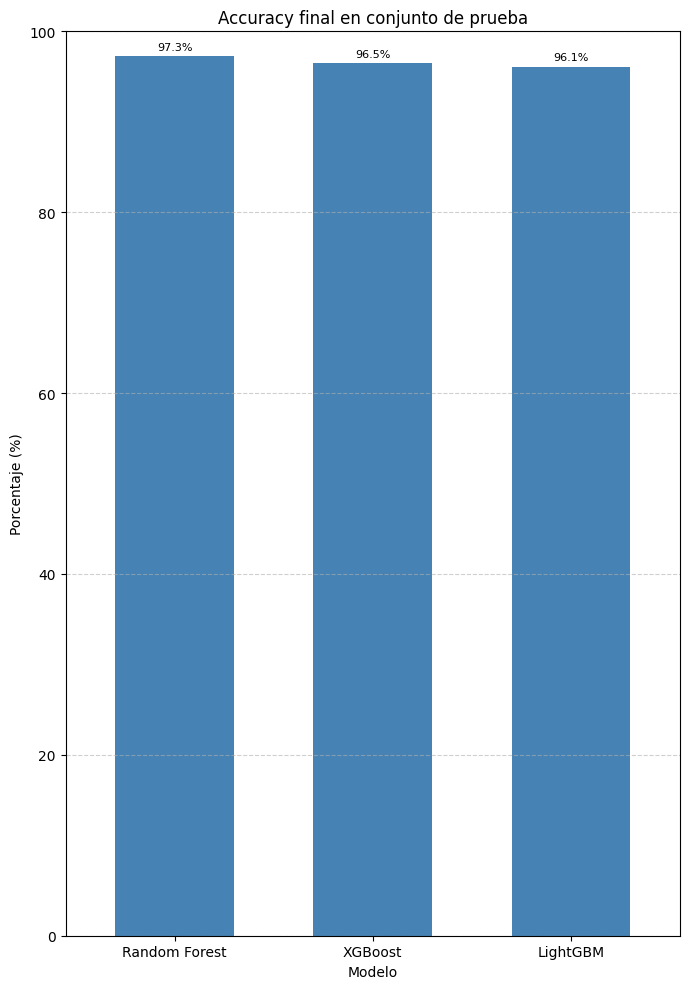

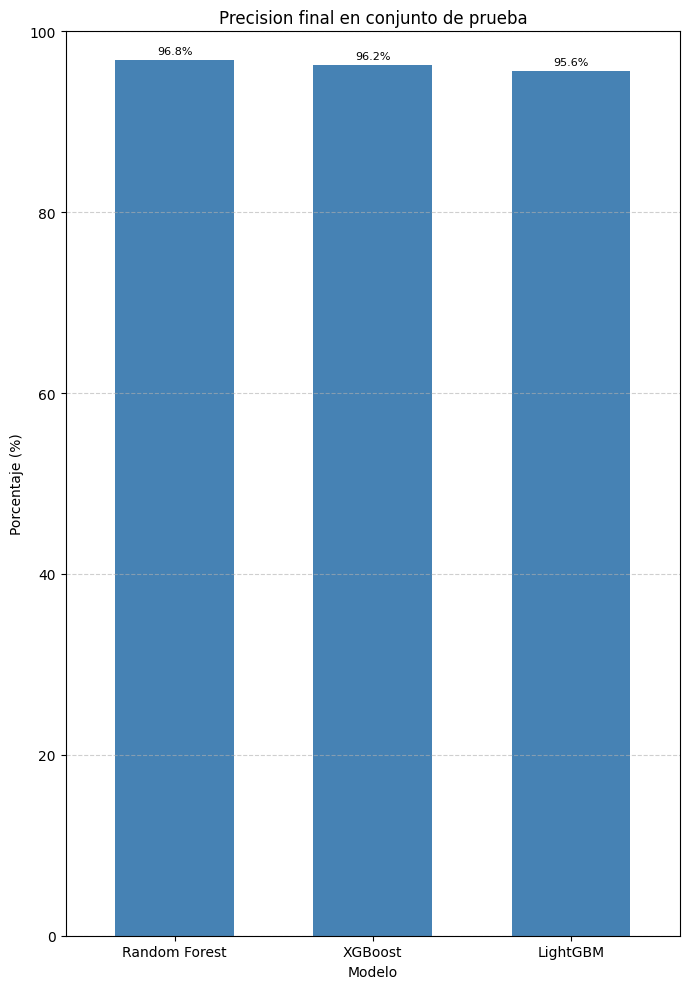

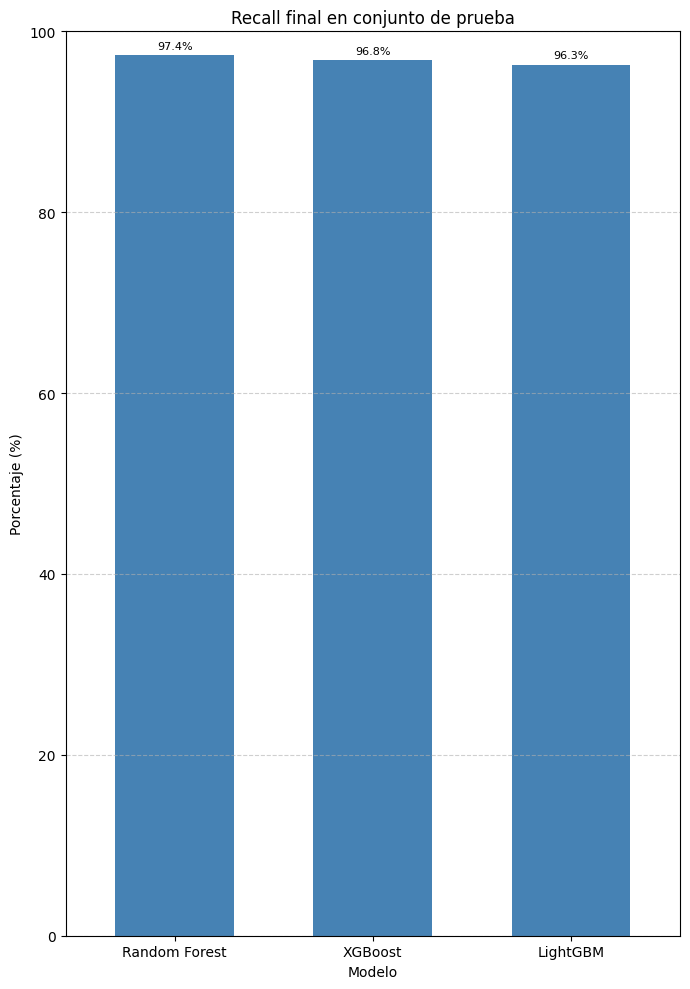

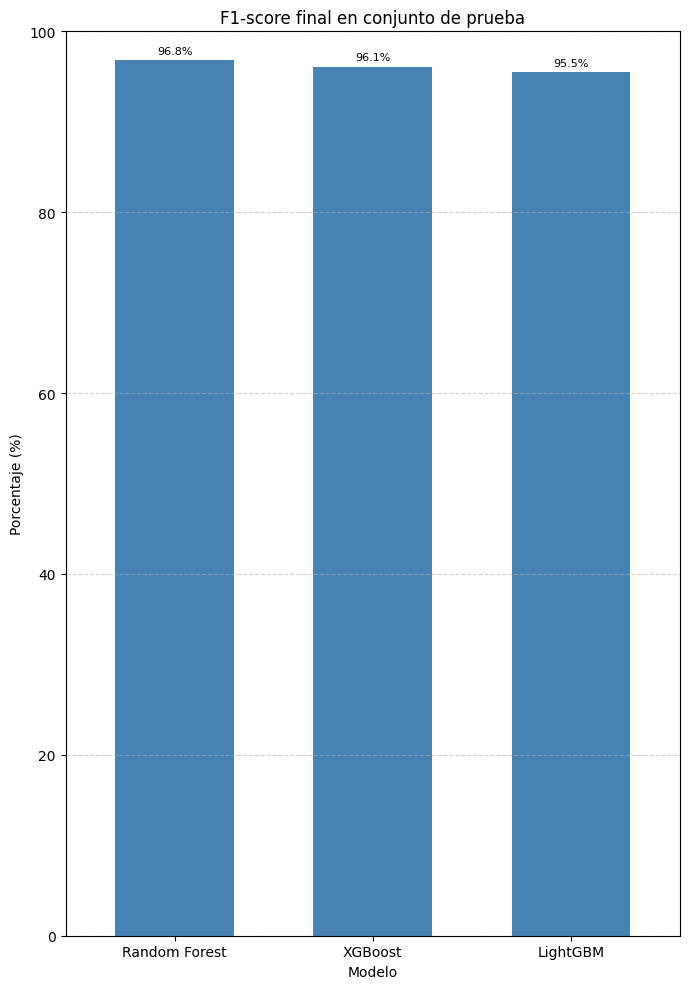

In [130]:
metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

for metrica in metricas:

    ax = (
        tabla_test
        .set_index("Modelo")[metrica]
        .plot(
            kind="bar",
            figsize=(7,10),
            width=0.6,
            color="steelblue"
        )
    )

    plt.title(
        f"{metrica} final en conjunto de prueba"
    )

    plt.xlabel("Modelo")
    plt.ylabel("Porcentaje (%)")

    plt.ylim(0, 100)

    plt.xticks(rotation=0)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.6
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=8,
            padding=3
        )

    plt.tight_layout()
    plt.show()

Gráfica de error final

In [148]:
tabla_test["Error (%)"] = (
    100 - tabla_test["Accuracy"]
)
display(tabla_test)

,Modelo,Accuracy,Precision,Recall,F1-score,Error (%)
0,Random Forest,97.28,96.81,97.39,96.80,2.72
1,XGBoost,96.50,96.24,96.81,96.11,3.50
2,LightGBM,96.11,95.59,96.32,95.54,3.89


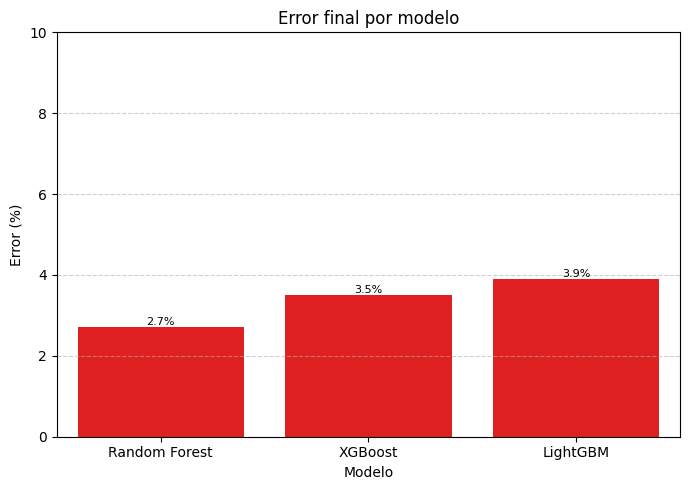

In [152]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=tabla_test,
    x="Modelo",
    y="Error (%)",
    color="red"
)

plt.title("Error final por modelo")

plt.xlabel("Modelo")
plt.ylabel("Error (%)")

plt.ylim(0, 10)

for barra in ax.patches:

    ax.annotate(
        f"{barra.get_height():.1f}%",

        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),

        ha="center",
        va="bottom",
        fontsize=8
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()
plt.show()

Reporte de clasificación

In [153]:
# =========================================
# REPORTE DE CLASIFICACION
# =========================================

for nombre, modelo in modelos_entrenados.items():

    print("\n=====================================")
    print("MODELO:", nombre)
    print("=====================================")

    # =====================================
    # PREDICCIONES
    # =====================================

    y_pred_test = modelo.predict(X_test)

    # =====================================
    # CLASES PRESENTES
    # =====================================

    clases_presentes = np.unique(
        np.concatenate([
            y_test,
            y_pred_test
        ])
    )

    # =====================================
    # NOMBRES REALES
    # =====================================

    nombres_clases = (
        label_encoder_especie
        .inverse_transform(clases_presentes)
    )

    # =====================================
    # REPORTE
    # =====================================

    reporte = classification_report(

        y_test,

        y_pred_test,

        labels=clases_presentes,

        target_names=nombres_clases,

        zero_division=0
    )

    print(reporte)


MODELO: Random Forest
                              precision    recall  f1-score   support

          Acaulospora alpina       1.00      1.00      1.00         2
          Acaulospora aspera       1.00      1.00      1.00         2
         Acaulospora baetica       1.00      1.00      1.00         2
    Acaulospora bireticulata       1.00      1.00      1.00         1
    Acaulospora brasiliensis       1.00      1.00      1.00         1
       Acaulospora capsicula       1.00      0.67      0.80         3
       Acaulospora cavernata       1.00      1.00      1.00         1
     Acaulospora colliculosa       1.00      1.00      1.00         1
      Acaulospora colombiana       1.00      1.00      1.00         1
       Acaulospora colossica       1.00      1.00      1.00         1
        Acaulospora delicata       1.00      1.00      1.00         1
     Acaulospora denticulata       1.00      1.00      1.00         1
        Acaulospora dilatata       1.00      1.00      1.00       

Matriz de confusión Top 15 especies

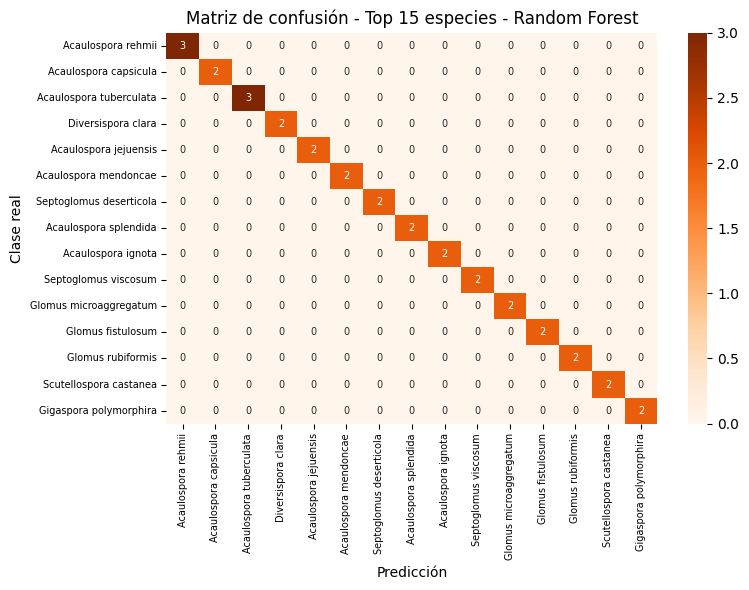

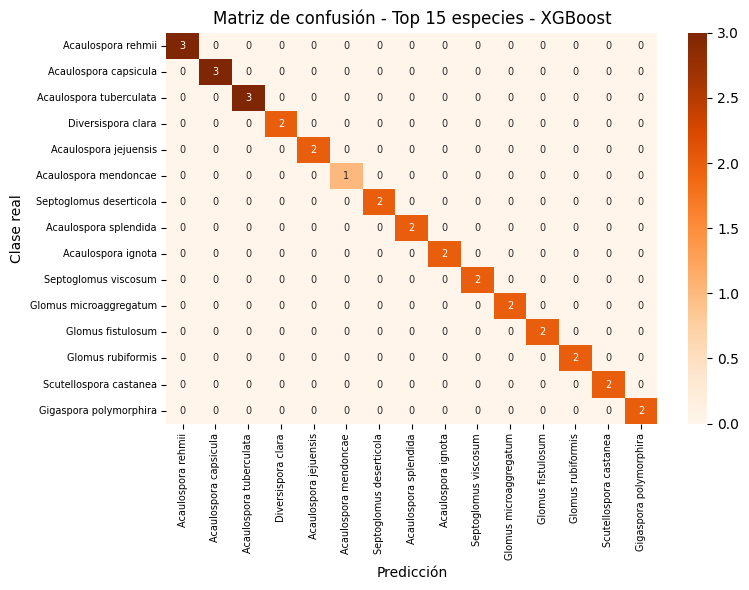

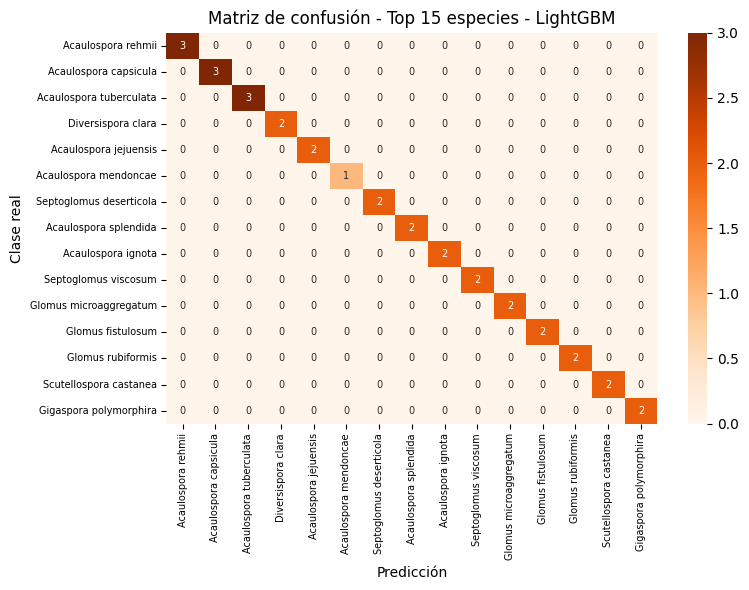

In [154]:
for nombre, modelo in modelos_entrenados.items():

    y_pred_test = modelo.predict(X_test)

    y_test_names = label_encoder_especie.inverse_transform(y_test)
    y_pred_names = label_encoder_especie.inverse_transform(y_pred_test)

    y_test_names = pd.Series(y_test_names).reset_index(drop=True)
    y_pred_names = pd.Series(y_pred_names).reset_index(drop=True)

    top_15 = (
        y_test_names
        .value_counts()
        .head(15)
        .index
        .tolist()
    )

    filtro = y_test_names.isin(top_15)

    y_test_top = y_test_names[filtro]
    y_pred_top = y_pred_names[filtro]

    cm = confusion_matrix(
        y_test_top,
        y_pred_top,
        labels=top_15
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        xticklabels=top_15,
        yticklabels=top_15,
        annot_kws={"size": 7}
    )

    plt.title(f"Matriz de confusión - Top 15 especies - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")

    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)

    plt.tight_layout()
    plt.show()

Ranking final de modelos

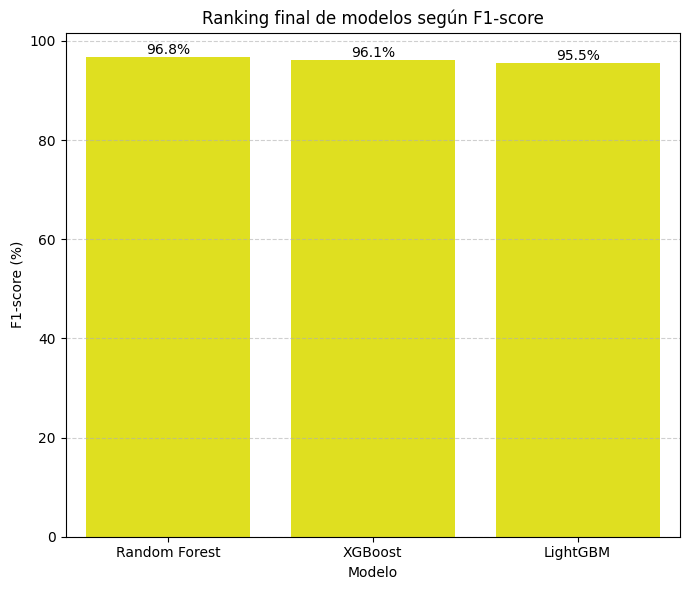

In [156]:
# =========================================
# RANKING FINAL DE MODELOS
# =========================================

ranking_modelos = tabla_test.copy()

ranking_modelos = ranking_modelos.sort_values(
    by="F1-score",
    ascending=False
)

plt.figure(figsize=(7,6))

ax = sns.barplot(
    data=ranking_modelos,
    x="Modelo",
    y="F1-score",
    color="yellow"
)

plt.title(
    "Ranking final de modelos según F1-score"
)

plt.xlabel("Modelo")
plt.ylabel("F1-score (%)")

for barra in ax.patches:

    ax.annotate(
        f"{barra.get_height():.1f}%",

        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),

        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()
plt.show()

Comparación Accuracy vs Error

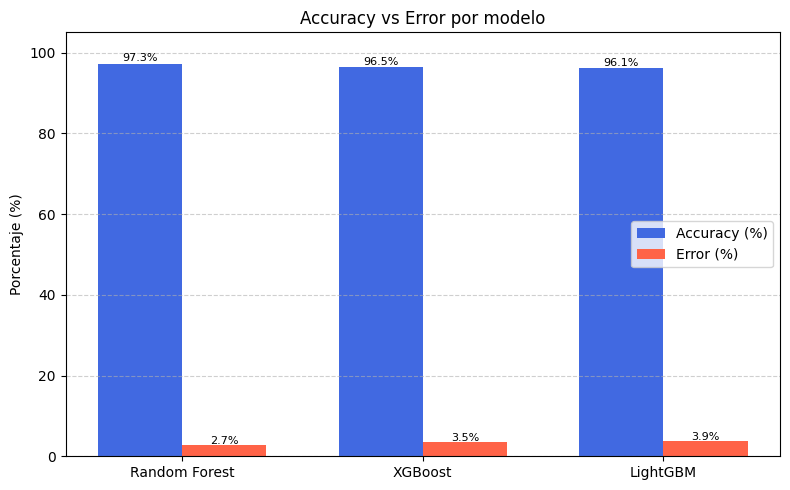

In [158]:
# =========================================
# ACCURACY VS ERROR
# =========================================

comparacion = tabla_test.copy()

fig, ax = plt.subplots(figsize=(8,5))

x = np.arange(len(comparacion))
ancho = 0.35

barras1 = ax.bar(
    x - ancho/2,
    comparacion["Accuracy"],
    width=ancho,
    label="Accuracy (%)",
    color="royalblue"
)

barras2 = ax.bar(
    x + ancho/2,
    comparacion["Error (%)"],
    width=ancho,
    label="Error (%)",
    color="tomato"
)

for barra in barras1:
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 0.5,
        f"{barra.get_height():.1f}%",
        ha="center",
        fontsize=8
    )

for barra in barras2:
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 0.2,
        f"{barra.get_height():.1f}%",
        ha="center",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(comparacion["Modelo"])

ax.set_ylabel("Porcentaje (%)")
ax.set_title("Accuracy vs Error por modelo")

ax.set_ylim(0, 105)

ax.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()
plt.show()

Curva de pérdida XGBoost

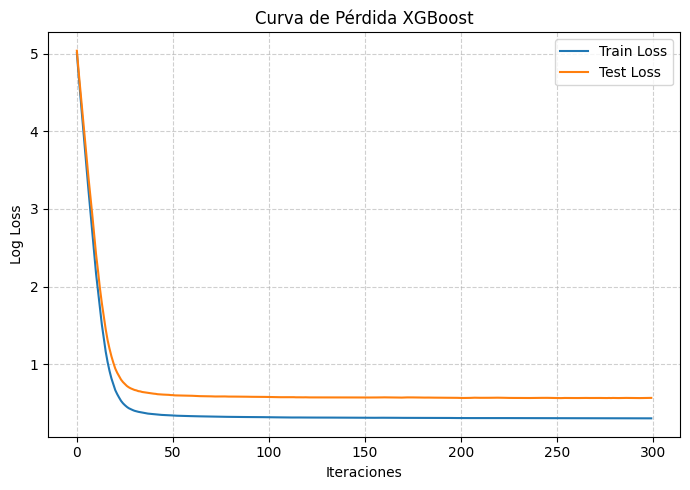

In [159]:
# =========================================
# CURVA DE PERDIDA XGBOOST
# =========================================

modelo_xgb_loss = XGBClassifier(
    **mejor_xgb.get_params()
)

modelo_xgb_loss.fit(
    X_train,
    y_train,
    sample_weight=sample_weight_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=False
)

resultados = modelo_xgb_loss.evals_result()

plt.figure(figsize=(7,5))

plt.plot(
    resultados["validation_0"]["mlogloss"],
    label="Train Loss"
)

plt.plot(
    resultados["validation_1"]["mlogloss"],
    label="Test Loss"
)

plt.title("Curva de Pérdida XGBoost")
plt.xlabel("Iteraciones")
plt.ylabel("Log Loss")
plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()
plt.show()

Curva de accuracy XGBoost

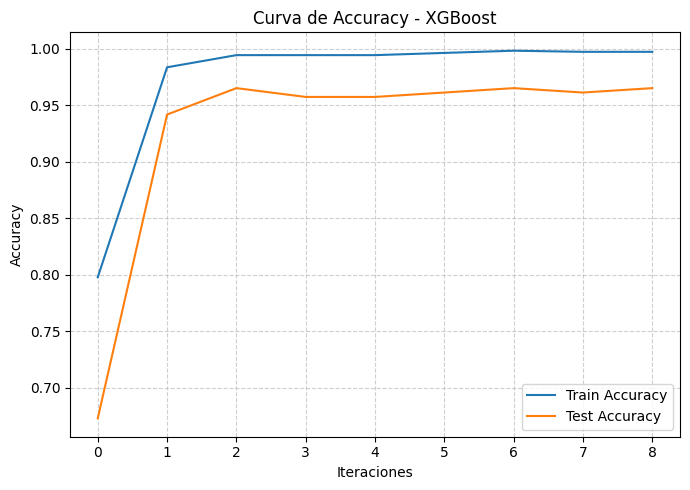

In [160]:
# =========================================
# CURVA DE ACCURACY XGBOOST
# =========================================

from sklearn.metrics import accuracy_score

n_estimators_list = [10, 20, 50, 100, 150, 200, 300, 400, 500]

train_accuracy = []
test_accuracy = []

for n in n_estimators_list:

    modelo_xgb_temp = XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_train)),
        n_estimators=n,
        learning_rate=mejor_xgb.learning_rate,
        max_depth=mejor_xgb.max_depth,
        subsample=mejor_xgb.subsample,
        colsample_bytree=mejor_xgb.colsample_bytree,
        gamma=mejor_xgb.gamma,
        random_state=42,
        n_jobs=-1
    )

    modelo_xgb_temp.fit(
        X_train,
        y_train,
        sample_weight=sample_weight_train
    )

    y_pred_train = modelo_xgb_temp.predict(X_train)
    y_pred_test = modelo_xgb_temp.predict(X_test)

    train_accuracy.append(
        accuracy_score(y_train, y_pred_train)
    )

    test_accuracy.append(
        accuracy_score(y_test, y_pred_test)
    )

# =========================================
# GRAFICA
# =========================================

plt.figure(figsize=(7,5))

plt.plot(
    train_accuracy,
    label="Train Accuracy"
)

plt.plot(
    test_accuracy,
    label="Test Accuracy"
)

plt.title("Curva de Accuracy - XGBoost")

plt.xlabel("Iteraciones")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.show()

Curva de pérdida LightGBM

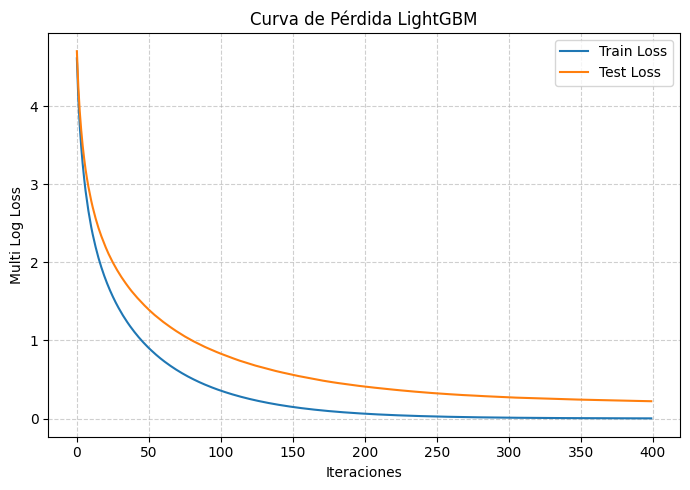

In [161]:
# =========================================
# CURVA DE PERDIDA LIGHTGBM
# =========================================

modelo_lgbm_loss = LGBMClassifier(
    **mejor_lgbm.get_params()
)

modelo_lgbm_loss.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    eval_metric="multi_logloss"
)

resultados = modelo_lgbm_loss.evals_result_

plt.figure(figsize=(7,5))

plt.plot(
    resultados["training"]["multi_logloss"],
    label="Train Loss"
)

plt.plot(
    resultados["valid_1"]["multi_logloss"],
    label="Test Loss"
)

plt.title("Curva de Pérdida LightGBM")
plt.xlabel("Iteraciones")
plt.ylabel("Multi Log Loss")

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()
plt.show()

Curva de error Random Forest


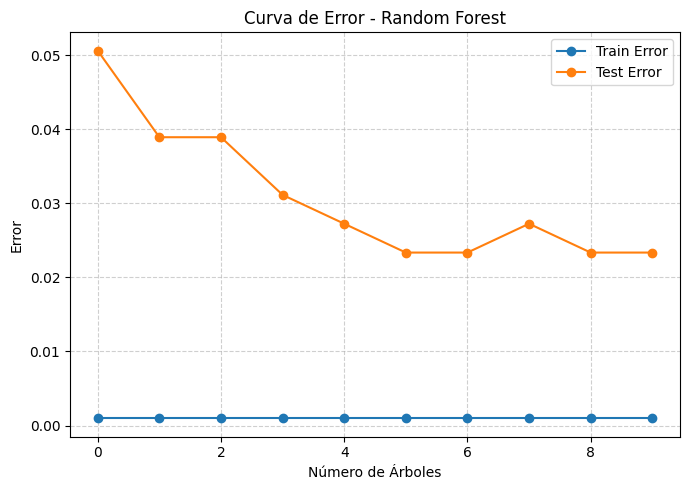

In [162]:
# =========================================
# CURVA DE ERROR RANDOM FOREST
# =========================================

from sklearn.metrics import accuracy_score

n_estimators_list = [10,20,30,40,50,60,70,80,90,100]

train_error = []
test_error = []

for n in n_estimators_list:

    modelo_rf_temp = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    modelo_rf_temp.fit(
        X_train,
        y_train
    )

    y_pred_train = modelo_rf_temp.predict(X_train)
    y_pred_test = modelo_rf_temp.predict(X_test)

    train_error.append(
        1 - accuracy_score(y_train, y_pred_train)
    )

    test_error.append(
        1 - accuracy_score(y_test, y_pred_test)
    )

# =========================================
# GRAFICA
# =========================================

plt.figure(figsize=(7,5))

plt.plot(
    train_error,
    marker="o",
    label="Train Error"
)

plt.plot(
    test_error,
    marker="o",
    label="Test Error"
)

plt.title("Curva de Error - Random Forest")

plt.xlabel("Número de Árboles")
plt.ylabel("Error")

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.show()

Análisis de overfitting / underfitting

In [163]:
# =========================================
# ANALISIS DE OVERFITTING / UNDERFITTING
# =========================================

analisis_overfitting = []

for nombre, modelo in modelos_entrenados.items():

    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    train_acc = accuracy_score(
        y_train,
        y_train_pred
    )

    test_acc = accuracy_score(
        y_test,
        y_test_pred
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        average="macro",
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0
    )

    diff_acc = train_acc - test_acc
    diff_f1 = train_f1 - test_f1

    if diff_f1 > 0.15:
        diagnostico = "Overfitting"

    elif train_f1 < 0.60 and test_f1 < 0.60:
        diagnostico = "Underfitting"

    else:
        diagnostico = "Buen ajuste"

    analisis_overfitting.append({

        "Modelo": nombre,

        "Train Accuracy (%)": train_acc * 100,

        "Test Accuracy (%)": test_acc * 100,

        "Train F1 (%)": train_f1 * 100,

        "Test F1 (%)": test_f1 * 100,

        "Diferencia Accuracy (%)": diff_acc * 100,

        "Diferencia F1 (%)": diff_f1 * 100,

        "Diagnostico": diagnostico
    })

# =========================================
# TABLA FINAL
# =========================================

tabla_overfitting = pd.DataFrame(
    analisis_overfitting
)

tabla_overfitting = tabla_overfitting.round(2)

tabla_overfitting

,Modelo,Train Accuracy (%),Test Accuracy (%),Train F1 (%),Test F1 (%),Diferencia Accuracy (%),Diferencia F1 (%),Diagnostico
0,Random Forest,99.8,97.28,99.81,96.80,2.53,3.01,Buen ajuste
1,XGBoost,99.8,96.50,99.81,96.11,3.31,3.69,Buen ajuste
2,LightGBM,99.9,96.11,99.88,95.54,3.79,4.34,Buen ajuste


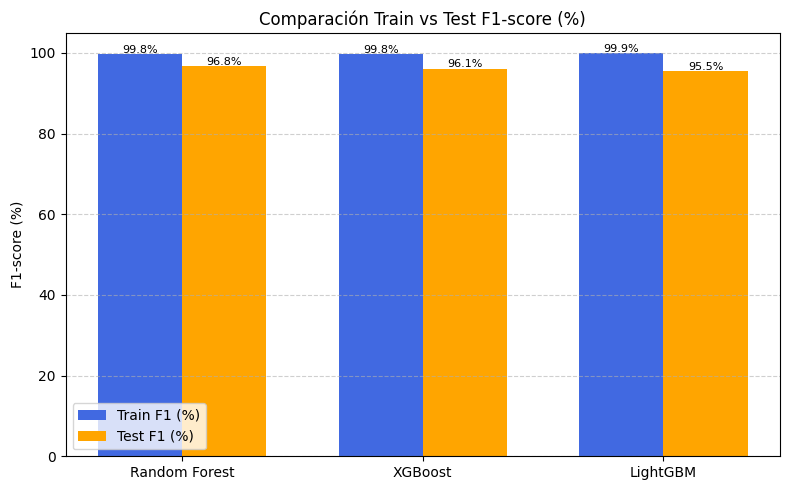

In [166]:
# =========================================
# TRAIN VS TEST F1-SCORE
# =========================================

plt.figure(figsize=(8,5))

x = np.arange(len(tabla_overfitting))

ancho = 0.35

barras_train = plt.bar(
    x - ancho/2,
    tabla_overfitting["Train F1 (%)"],
    width=ancho,
    label="Train F1 (%)",
    color="royalblue"
)

barras_test = plt.bar(
    x + ancho/2,
    tabla_overfitting["Test F1 (%)"],
    width=ancho,
    label="Test F1 (%)",
    color="orange"
)

for barra in barras_train:

    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 0.3,
        f"{barra.get_height():.1f}%",
        ha="center",
        fontsize=8
    )

for barra in barras_test:

    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 0.3,
        f"{barra.get_height():.1f}%",
        ha="center",
        fontsize=8
    )

plt.xticks(
    x,
    tabla_overfitting["Modelo"],
    rotation=0
)

plt.ylabel("F1-score (%)")

plt.title(
    "Comparación Train vs Test F1-score (%)"
)

plt.ylim(0, 105)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()
plt.show()

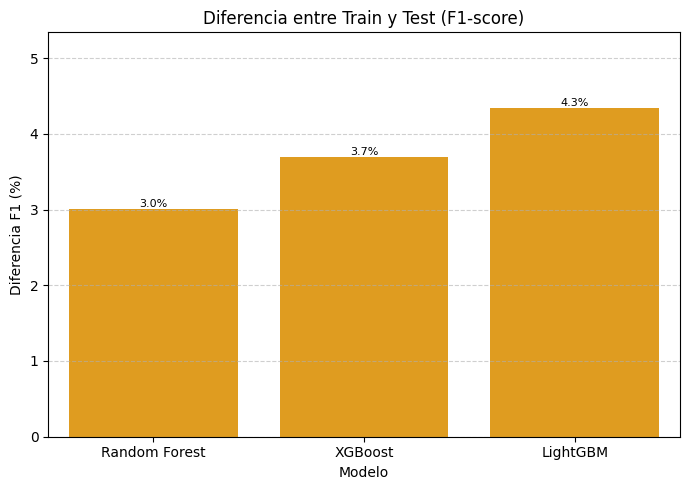

In [171]:
# =========================================
# DIFERENCIA TRAIN - TEST
# =========================================

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=tabla_overfitting,
    x="Modelo",
    y="Diferencia F1 (%)",
    color="orange"
)

plt.title(
    "Diferencia entre Train y Test (F1-score)"
)

plt.xlabel("Modelo")
plt.ylabel("Diferencia F1 (%)")

for barra in ax.patches:

    ax.annotate(
        f"{barra.get_height():.1f}%",

        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),

        ha="center",
        va="bottom",
        fontsize=8
    )

plt.ylim(
    0,
    tabla_overfitting["Diferencia F1 (%)"].max() + 1
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()
plt.show()

Selección del mejor modelo

In [172]:
# =========================================
# SELECCION DEL MEJOR MODELO
# =========================================

mejor_modelo_nombre = (
    tabla_test
    .sort_values(
        by="F1-score",
        ascending=False
    )
    .iloc[0]["Modelo"]
)

mejor_modelo = modelos_entrenados[
    mejor_modelo_nombre
]

print("===================================")
print("MEJOR MODELO SELECCIONADO")
print("===================================")

print("Modelo:", mejor_modelo_nombre)

print("\nMétricas del mejor modelo:")
print(
    tabla_test[
        tabla_test["Modelo"] == mejor_modelo_nombre
    ]
)

MEJOR MODELO SELECCIONADO
Modelo: Random Forest

Métricas del mejor modelo:
          Modelo  Accuracy  Precision  Recall  F1-score  Error (%)
0  Random Forest     97.28      96.81   97.39      96.8       2.72


Importancia de variables

In [176]:
# =========================================
# IMPORTANCIA DE VARIABLES
# =========================================

df_importancias = pd.DataFrame({

    "Variable": X.columns,

    "Importancia (%)":
        mejor_modelo.feature_importances_ * 100

}).sort_values(

    by="Importancia (%)",

    ascending=False
)

df_importancias["Importancia (%)"] = (
    df_importancias["Importancia (%)"]
    .round(2)
)

print("===================================")
print("TOP VARIABLES IMPORTANTES")
print("===================================")

df_importancias.head(20)

TOP VARIABLES IMPORTANTES


,Variable,Importancia (%)
2,tam_promedio,3.81
0,tam_min,3.57
1,tam_max,3.57
3,numero_paredes,2.72
5,melzer_negativa,1.28
4,melzer_positiva,1.25
30,color_Amarillo,1.24
267,planta_Multiples,1.19
36,color_Marron,1.13
35,color_Hialino,1.11


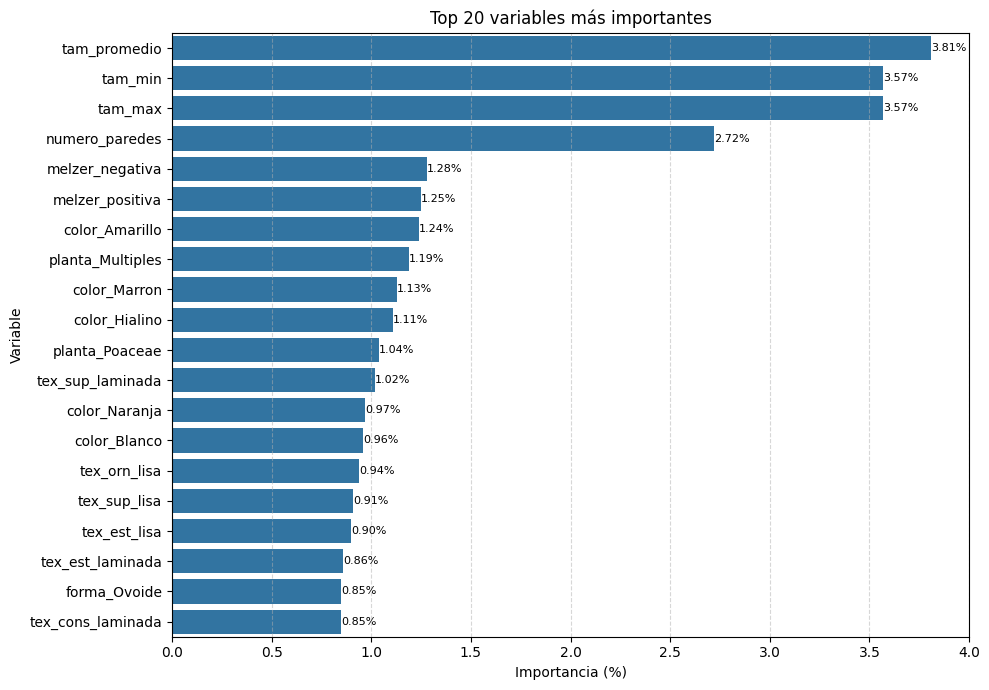

In [177]:
# =========================================
# TOP 20 VARIABLES MAS IMPORTANTES
# =========================================

top20 = df_importancias.head(20)

plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=top20,
    x="Importancia (%)",
    y="Variable"
)

plt.title(
    "Top 20 variables más importantes"
)

plt.xlabel("Importancia (%)")
plt.ylabel("Variable")

for barra in ax.patches:

    ax.annotate(
        f"{barra.get_width():.2f}%",

        (
            barra.get_width(),
            barra.get_y() + barra.get_height()/2
        ),

        ha="left",
        va="center",
        fontsize=8
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

Prueba final: Es predecir la especie de la micorrizar arbuscular

In [196]:
# =========================================
# PRUEBA FINAL DE PREDICCION
# =========================================

indice = 5

# =====================================
# REGISTRO DE PRUEBA
# =====================================

dato_prueba = X_test.iloc[[indice]]

# =====================================
# PREDICCION
# =====================================

prediccion = mejor_modelo.predict(
    dato_prueba
)

# =====================================
# CONVERTIR A NOMBRE REAL
# =====================================

especie_predicha = (
    label_encoder_especie
    .inverse_transform(prediccion)
)[0]

# =====================================
# ESPECIE REAL
# =====================================

especie_real = (
    label_encoder_especie
    .inverse_transform(
        [y_test.iloc[indice]]
    )
)[0]

# =====================================
# MOSTRAR RESULTADOS
# =====================================

print("===================================")
print("RESULTADO DE IDENTIFICACION")
print("===================================")

print("Especie predicha:", especie_predicha)

print("Especie real:", especie_real)

# =====================================
# COMPARACION
# =====================================

if especie_predicha == especie_real:

    print("\nResultado: Predicción correcta")

else:

    print("\nResultado: Predicción incorrecta")

RESULTADO DE IDENTIFICACION
Especie predicha: Dentiscutata reticulata
Especie real: Dentiscutata reticulata

Resultado: Predicción correcta


In [198]:
# =========================================
# INFORMACIÓN COMPLETA DE LA ESPECIE PREDICHA
# =========================================

columnas_info = [

    # Datos generales
    "genero",
    "familia",
    "nombre_cientifico",
    "pais",
    "localidad",

    # Morfología
    "tamaño_espora",
    "forma",
    "color",
    "conexion_hifal",
    "numero_paredes",
    "tipo_pared",

    # Ecología
    "habitat",
    "vegetacion",
    "altitud_msnm",
    "ph_suelo",
    "textura_suelo",
    "temperatura",

    # Genética
    "cluster_ITS",
    "cluster_genetico",
    "genetic_similarity_pct",

    # Extras
    "particularidad",
    "plantas_hospederas",
    "informacion_especie"

]

info_predicha = (
    df[
        df["nombre_cientifico"] == especie_predicha
    ]
    .reindex(
        columns=columnas_info
    )
    .drop_duplicates()
    .head(10)
)

display(info_predicha)

,genero,familia,nombre_cientifico,pais,localidad,tamaño_espora,forma,color,conexion_hifal,numero_paredes,...,altitud_msnm,ph_suelo,textura_suelo,temperatura,cluster_ITS,cluster_genetico,genetic_similarity_pct,particularidad,plantas_hospederas,informacion_especie
473,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Cerrado,180-390 µm,Globosa,Marrón rojizo oscuro a negro,Suspensor bulboso,3,...,200-800,5.0-6.5,Arenoso,24-32 °C,Dentiscutata_reticulata_ITS_01,Dentiscutataceae_ITS_clade,98.2,Presenta superficie poligonal con espinas dens...,Gramíneas,Hongo micorrícico con esporas grandes y pared ...
474,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Goiás,180-390 µm,Subglobosa,Marrón oscuro,Suspensor bulboso,3,...,300-900,5.2-6.3,Franco arenoso,25-33 °C,Dentiscutata_reticulata_ITS_02,Dentiscutataceae_ITS_clade,97.9,Retícula elevada formando estructuras tipo mes...,Gramíneas nativas,Esporas con estructura compleja que dificulta ...
475,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Mato Grosso,180-390 µm,Globosa,Marrón rojizo,Suspensor bulboso,3,...,200-600,5.0-6.0,Franco,26-34 °C,Dentiscutata_reticulata_ITS_03,Dentiscutataceae_ITS_clade,98.0,Espinas internas bien definidas dentro de la r...,Cultivos mixtos,Esporas con ornamentación externa prominente y...
476,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Bahia,180-390 µm,Subglobosa,Negro,Suspensor bulboso,3,...,100-500,5.3-6.2,Arenoso,24-31 °C,Dentiscutata_reticulata_ITS_04,Dentiscutataceae_ITS_clade,97.8,Escudo de germinación con patrón laberíntico c...,Gramíneas,Esporas con capas externas dominantes que ocul...
477,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Tocantins,180-390 µm,Globosa,Marrón oscuro,Suspensor bulboso,3,...,250-700,5.1-6.4,Franco arenoso,25-33 °C,Dentiscutata_reticulata_ITS_05,Dentiscutataceae_ITS_clade,98.3,Reticulación con celdas poligonales bien defin...,Gramíneas tropicales,Esporas con superficie altamente diferenciada ...
478,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Pará,180-390 µm,Subglobosa,Marrón rojizo oscuro,Suspensor bulboso,3,...,150-500,5.0-6.2,Franco,26-34 °C,Dentiscutata_reticulata_ITS_06,Dentiscutataceae_ITS_clade,97.7,Capa intermedia laminada dominante en espesor.,Cultivos,Asociada a suelos tropicales con actividad bio...
479,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Minas Gerais,180-390 µm,Globosa,Negro,Suspensor bulboso,3,...,300-900,5.2-6.3,Arenoso,24-32 °C,Dentiscutata_reticulata_ITS_07,Dentiscutataceae_ITS_clade,98.1,Estructura interna difícil de observar por la ...,Gramíneas,Esporas con fuerte adaptación a suelos ácidos ...
480,Dentiscutata,Gigasporaceae,Dentiscutata reticulata,Brasil,Amazonas,180-390 µm,Subglobosa,Marrón oscuro a negro,Suspensor bulboso,3,...,100-400,5.1-6.5,Franco arenoso,26-34 °C,Dentiscutata_reticulata_ITS_08,Dentiscutataceae_ITS_clade,98.0,Escudo germinativo con invaginaciones tipo lab...,Gramíneas tropicales,Hongo caracterizado por su compleja arquitectu...


Top 3 especies más probables

In [199]:
# =========================================
# TOP 3 ESPECIES MAS PROBABLES
# =========================================

probabilidades = mejor_modelo.predict_proba(
    dato_prueba
)

# =====================================
# TOP 3 INDICES
# =====================================

top_3 = np.argsort(
    probabilidades[0]
)[-3:][::-1]

print("===================================")
print("TOP 3 ESPECIES MAS PROBABLES")
print("===================================")

top_3_resultados = []

for i in top_3:

    especie = (
        label_encoder_especie
        .inverse_transform([i])
    )[0]

    prob = probabilidades[0][i] * 100

    top_3_resultados.append({
        "Especie": especie,
        "Probabilidad (%)": round(prob, 2)
    })

    print(f"{especie}: {prob:.2f}%")

# =====================================
# TABLA FINAL
# =====================================

tabla_top3 = pd.DataFrame(
    top_3_resultados
)

tabla_top3

TOP 3 ESPECIES MAS PROBABLES
Dentiscutata reticulata: 57.01%
Dentiscutata nigerita: 7.29%
Scutellospora tepuiensis: 4.25%


,Especie,Probabilidad (%)
0,Dentiscutata reticulata,57.01
1,Dentiscutata nigerita,7.29
2,Scutellospora tepuiensis,4.25


Generar reporte HTML

In [201]:
mejor_fila = tabla_test.loc[
    tabla_test["Accuracy"].idxmax()
]

mejor_modelo_nombre = mejor_fila["Modelo"]

acc = mejor_fila["Accuracy"]
precision = mejor_fila["Precision"]
recall = mejor_fila["Recall"]
f1 = mejor_fila["F1-score"]

error = mejor_fila["Error (%)"]

diag = tabla_overfitting.loc[
    tabla_overfitting["Modelo"] == mejor_modelo_nombre,
    "Diagnostico"
].values[0]

In [202]:
if diag == "Buen ajuste":

    interpretacion = """
    Esto indica que el modelo seleccionado presenta un comportamiento estable y una adecuada capacidad de generalización sobre datos no observados.
    """

elif diag == "Sobreajuste":

    interpretacion = """
    Esto indica que el modelo presenta una tendencia al sobreajuste, mostrando diferencias elevadas entre entrenamiento y prueba, lo que puede afectar su capacidad de generalización.
    """

elif diag == "Subajuste":

    interpretacion = """
    Esto indica que el modelo presenta subajuste, sugiriendo que no logró aprender adecuadamente los patrones presentes en los datos.
    """

else:

    interpretacion = """
    Esto indica un comportamiento intermedio del modelo y requiere un análisis adicional.
    """

In [203]:
# =========================================
# PORCENTAJES DEL DATASET
# =========================================

total = len(df)

porc_train = (len(X_train) / total) * 100

porc_test = (len(X_test) / total) * 100

In [209]:
# =========================================
# GENERAR REPORTE HTML
# =========================================

html = f"""
<html>

<head>

<meta charset="UTF-8">

<title>Reporte Modelo Micorrizas</title>

<style>

body {{
    font-family: Arial, sans-serif;
    margin:40px;
    background-color:#f5f5f5;
}}

h1 {{
    color:#1b4332;
}}

h2 {{
    color:#2d6a4f;
    margin-top:30px;
}}

table {{
    border-collapse:collapse;
    width:100%;
    background-color:white;
    margin-top:10px;
}}

th,td {{
    border:1px solid #cccccc;
    padding:8px;
    text-align:center;
}}

th {{
    background-color:#95d5b2;
}}

p {{
    font-size:15px;
}}

</style>

</head>

<body>

<h1>
Reporte del Modelo de Identificación de Micorrizas Arbusculares
</h1>

<hr>


<h2>Variable objetivo</h2>

<p>

La variable objetivo utilizada fue:

<b>nombre_cientifico</b>

</p>


<h2>Información general del dataset</h2>

<p>

Total registros:
<b>{df.shape[0]}</b>

<br>

Total especies:
<b>{df["nombre_cientifico"].nunique()}</b>

<br>

Variables predictoras:
<b>{len(datos_entrada_modelo)}</b>

</p>



<h2>División del dataset</h2>

<p>

Entrenamiento:
<b>80%</b>

(
<b>{X_train.shape[0]}</b>
registros
)

<br>

Prueba:
<b>20%</b>

(
<b>{X_test.shape[0]}</b>
registros
)

<br><br>

Validación cruzada:
<b>5-Fold Estratificada</b>

<br>

En cada iteración se utilizó aproximadamente el
<b>20%</b>
del conjunto de entrenamiento para validación.

</p>



<h2>Mejor modelo seleccionado</h2>

<p>

<b>{mejor_modelo_nombre}</b>

</p>


<h2>Métricas iniciales</h2>

{tabla_base.to_html(index=False)}



<h2>Resultados validación cruzada</h2>

{tabla_cv_ajustados.to_html(index=False)}



<h2>Resultados finales en conjunto de prueba</h2>

{tabla_test.to_html(index=False)}



<h2>Análisis Overfitting / Underfitting</h2>

{tabla_overfitting.to_html(index=False)}



<h2>Top 20 variables más importantes</h2>

{df_importancias.head(20).to_html(index=False)}



<h2>Prueba final del modelo</h2>

<p>

<b>Especie predicha:</b>

{especie_predicha}

</p>

<p>

<b>Especie real:</b>

{especie_real}

</p>



<h2>Top 3 especies más probables</h2>

{tabla_top3.to_html(index=False)}



<h2>Información asociada a la especie predicha</h2>

{info_predicha.to_html(index=False)}



<h2>Conclusión final</h2>

<p>
El modelo <b>{mejor_modelo_nombre}</b> presentó el mejor desempeño general durante las pruebas realizadas,
alcanzando un Accuracy de <b>{acc:.2f}%</b>, Precision de <b>{precision:.2f}%</b>,
Recall de <b>{recall:.2f}%</b>, F1-score de <b>{f1:.2f}%</b> y un error de
<b>{error:.2f}%</b>.
</p>

<p>

De acuerdo con el análisis de entrenamiento y prueba, el diagnóstico del modelo fue:

<b>{diag}</b>.

{interpretacion}

</p>


<h2>Nota final</h2>

<p>

Para el entrenamiento del modelo se utilizaron únicamente las variables que estarán disponibles
en la interfaz web, permitiendo que el modelo aprenda utilizando información real ingresada por el usuario.

</p>

<p>

Para el desarrollo de los modelos de aprendizaje automático, el conjunto de datos fue dividido en:
<b>80%</b> para entrenamiento
(<b>{len(X_train)}</b> registros)
y
<b>20%</b> para pruebas
(<b>{len(X_test)}</b> registros),
manteniendo la distribución de clases mediante una partición estratificada.

</p>

<p>

Posteriormente, sobre el conjunto de entrenamiento se aplicó
<b>validación cruzada estratificada de 5 particiones (5-Fold Cross Validation)</b>,
utilizando aproximadamente el
<b>20%</b>
de los datos de entrenamiento para validación en cada iteración.

</p>

<p>

La evaluación se realizó mediante validación cruzada estratificada y métricas de desempeño como
Accuracy, Precision, Recall, F1-score y Error.

</p>


</body>

</html>

"""

# =========================================
# GUARDAR HTML
# =========================================

with open(

    "reporte_modelo_micorrizas.html",

    "w",

    encoding="utf-8"

) as f:

    f.write(html)


print("Reporte HTML generado correctamente")

Reporte HTML generado correctamente


Guardar modelo final

In [211]:
# =========================================
# GUARDAR MODELO FINAL
# =========================================

import joblib

# =====================================
# GUARDAR MEJOR MODELO
# =====================================

joblib.dump(
    mejor_modelo,
    "modelo_micorrizas.pkl"
)

# =====================================
# GUARDAR LABEL ENCODER
# =====================================

joblib.dump(
    label_encoder_especie,
    "label_encoder_especie.pkl"
)

# =====================================
# GUARDAR COLUMNAS DEL MODELO
# =====================================

joblib.dump(
    X.columns.tolist(),
    "columnas_modelo.pkl"
)

# =====================================
# MENSAJE FINAL
# =====================================

print("===================================")
print("ARCHIVOS GENERADOS CORRECTAMENTE")
print("===================================")

print("modelo_micorrizas.pkl")
print("label_encoder_especie.pkl")
print("columnas_modelo.pkl")
print("reporte_modelo_micorrizas.html")

ARCHIVOS GENERADOS CORRECTAMENTE
modelo_micorrizas.pkl
label_encoder_especie.pkl
columnas_modelo.pkl
reporte_modelo_micorrizas.html


**NOTA FINAL:**

- El dataset fue dividido utilizando:
  - 80% para entrenamiento
  - 20% para prueba
  - Validación cruzada estratificada de 5 particiones (5-Fold Cross Validation)

- La división se realizó mediante estratificación (*stratify*) para mantener el equilibrio de especies en los conjuntos de entrenamiento y prueba, evitando sesgos durante el aprendizaje y evaluación del modelo.

- Durante la validación cruzada, aproximadamente el 20% de los datos del conjunto de entrenamiento fue utilizado para validación en cada iteración, permitiendo evaluar la capacidad de generalización del modelo.

- El modelo fue entrenado únicamente con las variables que realmente se utilizarán en la interfaz web, con el fin de mantener coherencia entre el entrenamiento y las predicciones finales del sistema.

- Las variables descriptivas como hábitat, vegetación, país, localidad, pH, altitud y temperatura se conservaron únicamente como información de salida para mostrar detalles adicionales de la especie identificada, pero no fueron utilizadas como variables predictoras.

- Para reducir ruido y mejorar el rendimiento del modelo, no se utilizaron variables textuales como `forma_std`, `forma_token`, `color_std` y `color_token`, empleándose solamente variables procesadas y codificadas mediante técnicas de transformación y codificación tipo One-Hot Encoding.

- El entrenamiento se realizó utilizando características morfológicas y estructurales de las esporas, tales como:
  - Tamaño de espora
  - Forma
  - Color
  - Número de paredes
  - Reacción de Melzer
  - Textura
  - Tipo de hifa de sostén
  - Características de la pared interna y externa

- La evaluación del modelo se realizó mediante métricas de desempeño como Accuracy, Precision, Recall, F1-score y Error, complementadas con validación cruzada estratificada para garantizar la robustez de los resultados obtenidos.